# Consensus hardness: corrected paper run

Canonical universe: prime knots with 3–15 crossings. The identity `00_1` is excluded before every learned transformation. All concordance analyses use `s_invariant_qc` while retaining the source value.

In [172]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [173]:

from pathlib import Path
import sys
import subprocess


PROJECT_DIR = Path(
    "/content/drive/MyDrive/consensus_hardness_refactored"
)

assert (PROJECT_DIR / "pyproject.toml").exists(), (
    f"No encuentro el proyecto en: {PROJECT_DIR}"
)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-e",
    str(PROJECT_DIR),
])
sys.path.append(str(PROJECT_DIR / "src"))
importlib.invalidate_caches()


In [15]:

import consensus_hardness as ch

DATA_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants"
)

OUTPUT_DIR = (
    DATA_DIR
    / "processed_consensus_hardness"
    / "corrected_run_20260819"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = ch.canonical_run_config()

## 00–01. Alignment, identity exclusion, and QC

In [16]:
FILE_MAP = {
    'alex': 'Alexander_upto17.csv',
    'homfly': 'HomflyPt_upto15_MIRRORS.csv',
    'jones': 'Jones_upto17_MIRRORS.csv',
    'theta': 'theta_upto15.csv',
    'kh': 'even_KH_upto17.pkl',
}
REPRESENTATION_SPECS = {
    'Alexander': {'source': 'alex', 'feature_prefixes': ['A']},
    'Jones': {'source': 'jones', 'feature_prefixes': ['J']},
    'HOMFLY-PT': {'source': 'homfly', 'feature_prefixes': ['a']},
    'Theta': {'source': 'theta', 'feature_prefixes': ['T']},
    'Khovanov': {'source': 'kh', 'feature_prefixes': ['F_']},
}
aligned = ch.build_aligned_dataset(
    DATA_DIR, FILE_MAP, REPRESENTATION_SPECS,
    min_crossings=CONFIG.universe.min_crossings,
    max_crossings=CONFIG.universe.max_crossings,
    expected_n=CONFIG.universe.expected_n,
    expected_s_qc_corrections=CONFIG.universe.expected_s_qc_corrections,
    preferred_metadata_sources=['alex', 'jones', 'homfly', 'theta', 'kh'],
    output_dir=OUTPUT_DIR / '00_alignment',
)
meta, X_dict = aligned['meta'], aligned['X_dict']
aligned['universe_audit']

{'n_knots': 313230,
 'n_unique_ids': 313230,
 'crossing_min': 3,
 'crossing_max': 15,
 'identity_rows': 0,
 'duplicate_ids': 0,
 's_qc_corrections': 1}

## 02–03. Primary PCA-SSE consensus and nested nulls

In [ ]:
primary = ch.run_primary_pca_analysis(
    meta, X_dict, OUTPUT_DIR, config=CONFIG, run_nulls=True
)
display(primary['summary'])
display(primary['null_summary'])

## 04+. Robustness modules

Run these after the primary artifacts are frozen: norm diagnostics and matching; EVR-99.9 and fixed-compression PCA; leave-one-representation-out and tail sensitivity; held-out PCA/AE; norm-conditioned and residualized hardness; continuous C_k and external baselines. Do not overwrite the primary tables.

In [33]:
ROBUSTNESS_DIR = ch.stage_directory(
    OUTPUT_DIR,
    4,
    "pca_sensitivities",
)

loo_sets, loo_summary = ch.leave_one_representation_out(
    primary["hard_sets"],
    meta,
    s_col=CONFIG.s_col,
)

display(loo_summary)

loo_summary.to_csv(
    ROBUSTNESS_DIR / "leave_one_representation_out.csv",
    index=False,
)

print("Saved to:")
print(ROBUSTNESS_DIR)

,analysis,n,median_sigma,mean_sigma,median_s,mean_s,sigma_ge_8_n,sigma_ge_8_prop,sigma_ge_10_n,sigma_ge_10_prop,s_ge_10_n,s_ge_10_prop,s_ge_12_n,s_ge_12_prop,crossing15_prop,alternating_prop,nonalternating_n,nonalt_s_gt_sigma_n,nonalt_s_gt_sigma_prop
0,All,292,10.0,9.664384,10.0,10.321918,284,0.972603,231,0.791096,279,0.955479,68,0.232877,0.969178,0.705479,86,84,0.976744
1,Without Alexander,302,10.0,9.569536,10.0,10.205298,288,0.953642,231,0.764901,279,0.923841,68,0.225166,0.970199,0.715232,86,84,0.976744
2,Without HOMFLY-PT,319,10.0,9.561129,10.0,10.319749,311,0.974922,237,0.742947,306,0.959248,72,0.225705,0.971787,0.652038,111,109,0.981982
3,Without Jones,351,10.0,9.413105,10.0,10.222222,338,0.962963,246,0.700855,333,0.948718,75,0.213675,0.968661,0.629630,130,127,0.976923
4,Without Khovanov,409,10.0,9.388753,10.0,10.092910,392,0.958435,281,0.687042,367,0.897311,78,0.190709,0.975550,0.687042,128,126,0.984375
5,Without Theta,552,10.0,9.123188,10.0,9.699275,536,0.971014,306,0.554348,409,0.740942,68,0.123188,0.938406,0.646739,195,140,0.717949


Saved to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/04_pca_sensitivities


# 05. PCA

Esta celda especifica se corre si cerró la sesión despues de correr 04+.

In [17]:
import numpy as np
import pandas as pd

PRIMARY_DIR = OUTPUT_DIR / "02_primary_pca"
NULL_DIR = OUTPUT_DIR / "03_intersection_nulls"

# ------------------------------------------------------------
# Recover PCA scores
# ------------------------------------------------------------

saved_scores = np.load(
    PRIMARY_DIR / "primary_pca_scores.npz",
    allow_pickle=False,
)

dimensions = pd.read_csv(
    PRIMARY_DIR / "primary_pca_dimensions.csv"
).set_index("invariant")

pca_primary_results = {}

for name, X in X_dict.items():
    key = ch.safe_name(name)
    row = dimensions.loc[name]

    pca_primary_results[name] = {
        "sse": saved_scores[f"{key}__sse"],
        "mse": saved_scores[f"{key}__mse"],
        "nre": saved_scores[f"{key}__nre"],
        "k": int(row["k"]),
        "evr": float(row["actual_evr"]),
        "input_dim": int(row["input_dim"]),
        "compression_ratio": float(row["compression_ratio"]),
    }

hard_sets_saved = pd.read_csv(
    PRIMARY_DIR / "hard_sets_by_stable_id.csv"
)

pca_primary_hard_sets = {}

for invariant, group in hard_sets_saved.groupby("invariant"):
    knot_ids = set(group["knot_id_base"].astype(str))

    pca_primary_hard_sets[invariant] = ch.ids_to_indices(
        knot_ids,
        meta,
        id_col="knot_id_base",
    )

pca_primary_consensus = ch.consensus_from_hard_sets(
    pca_primary_hard_sets
)

assert len(pca_primary_consensus) == 292

print("Recovered primary consensus:", len(pca_primary_consensus))

primary_summary = pd.read_csv(
    PRIMARY_DIR / "primary_consensus_summary.csv"
).iloc[0].to_dict()

null_summary = pd.read_csv(
    NULL_DIR / "intersection_null_summary.csv"
)

primary = {
    "fixed_results": pca_primary_results,
    "hard_sets": pca_primary_hard_sets,
    "consensus": pca_primary_consensus,
    "summary": primary_summary,
    "null_summary": null_summary,
}

loo_sets, loo_summary = ch.leave_one_representation_out(
    pca_primary_hard_sets,
    meta,
    s_col=CONFIG.s_col,
)

display(loo_summary)

Recovered primary consensus: 292


,analysis,n,median_sigma,mean_sigma,median_s,mean_s,sigma_ge_8_n,sigma_ge_8_prop,sigma_ge_10_n,sigma_ge_10_prop,s_ge_10_n,s_ge_10_prop,s_ge_12_n,s_ge_12_prop,crossing15_prop,alternating_prop,nonalternating_n,nonalt_s_gt_sigma_n,nonalt_s_gt_sigma_prop
0,All,292,10.0,9.664384,10.0,10.321918,284,0.972603,231,0.791096,279,0.955479,68,0.232877,0.969178,0.705479,86,84,0.976744
1,Without Alexander,302,10.0,9.569536,10.0,10.205298,288,0.953642,231,0.764901,279,0.923841,68,0.225166,0.970199,0.715232,86,84,0.976744
2,Without HOMFLY-PT,319,10.0,9.561129,10.0,10.319749,311,0.974922,237,0.742947,306,0.959248,72,0.225705,0.971787,0.652038,111,109,0.981982
3,Without Jones,351,10.0,9.413105,10.0,10.222222,338,0.962963,246,0.700855,333,0.948718,75,0.213675,0.968661,0.629630,130,127,0.976923
4,Without Khovanov,409,10.0,9.388753,10.0,10.092910,392,0.958435,281,0.687042,367,0.897311,78,0.190709,0.975550,0.687042,128,126,0.984375
5,Without Theta,552,10.0,9.123188,10.0,9.699275,536,0.971014,306,0.554348,409,0.740942,68,0.123188,0.938406,0.646739,195,140,0.717949


In [18]:
# ============================================================
# EVR-99.9 sensitivity
# ============================================================

pca_999_results = ch.run_pca_fixed_k_for_representations(
    X_dict,
    CONFIG.pca.sensitivity_k_999,
)

pca_999_hard_sets = ch.build_hard_sets_from_fixed_results(
    pca_999_results,
    score_name="sse",
    tail_mass=CONFIG.pca.tail_mass,
    stable_ids=meta["knot_id_base"],
)

pca_999_consensus = ch.consensus_from_hard_sets(
    pca_999_hard_sets
)

pca_999_summary = ch.summarize_selected_set(
    "PCA EVR-99.9",
    pca_999_consensus,
    meta,
    s_col=CONFIG.s_col,
)

pca_99_vs_999 = ch.compare_consensus_sets(
    pca_primary_consensus,
    pca_999_consensus,
    name_a="PCA EVR-99",
    name_b="PCA EVR-99.9",
)

display(pca_999_summary)
display(pca_99_vs_999)

Alexander k: 5 EVR: 0.9996781349182129 compression: 3.4
Jones k: 13 EVR: 0.9991118907928467 compression: 3.923076923076923
HOMFLY-PT k: 45 EVR: 0.9990551471710205 compression: 3.3777777777777778
Theta k: 16 EVR: 0.9991497993469238 compression: 52.5625
Khovanov k: 115 EVR: 0.9990562200546265 compression: 3.243478260869565


{'analysis': 'PCA EVR-99.9',
 'n': 85,
 'median_sigma': 10.0,
 'mean_sigma': np.float64(9.788235294117648),
 'median_s': 10.0,
 'mean_s': np.float64(10.047058823529412),
 'sigma_ge_8_n': 84,
 'sigma_ge_8_prop': 0.9882352941176471,
 'sigma_ge_10_n': 66,
 'sigma_ge_10_prop': 0.7764705882352941,
 's_ge_10_n': 73,
 's_ge_10_prop': 0.8588235294117647,
 's_ge_12_n': 15,
 's_ge_12_prop': 0.17647058823529413,
 'crossing15_prop': 0.9647058823529412,
 'alternating_prop': 0.8235294117647058,
 'nonalternating_n': 15,
 'nonalt_s_gt_sigma_n': 10,
 'nonalt_s_gt_sigma_prop': 0.6666666666666666}

{'set_a': 'PCA EVR-99',
 'set_b': 'PCA EVR-99.9',
 'size_a': 292,
 'size_b': 85,
 'overlap': 56,
 'jaccard': 0.17445482866043613,
 'fraction_a_in_b': 0.1917808219178082,
 'fraction_b_in_a': 0.6588235294117647}

In [19]:
# ============================================================
# Fixed-compression sensitivity
# ============================================================

pca_fixed_compression_results = (
    ch.run_pca_fixed_k_for_representations(
        X_dict,
        CONFIG.pca.fixed_compression_k,
    )
)

pca_fixed_compression_hard_sets = (
    ch.build_hard_sets_from_fixed_results(
        pca_fixed_compression_results,
        score_name="sse",
        tail_mass=CONFIG.pca.tail_mass,
        stable_ids=meta["knot_id_base"],
    )
)

pca_fixed_compression_consensus = (
    ch.consensus_from_hard_sets(
        pca_fixed_compression_hard_sets
    )
)

pca_fixed_compression_summary = ch.summarize_selected_set(
    "PCA fixed compression",
    pca_fixed_compression_consensus,
    meta,
    s_col=CONFIG.s_col,
)

pca_99_vs_fixed_compression = ch.compare_consensus_sets(
    pca_primary_consensus,
    pca_fixed_compression_consensus,
    name_a="PCA EVR-99",
    name_b="PCA fixed compression",
)

display(pca_fixed_compression_summary)
display(pca_99_vs_fixed_compression)

Alexander k: 5 EVR: 0.9996781349182129 compression: 3.4
Jones k: 10 EVR: 0.9903849363327026 compression: 5.1
HOMFLY-PT k: 20 EVR: 0.9403750896453857 compression: 7.6
Theta k: 10 EVR: 0.9921095371246338 compression: 84.1
Khovanov k: 50 EVR: 0.9433621764183044 compression: 7.46


{'analysis': 'PCA fixed compression',
 'n': 61,
 'median_sigma': 10.0,
 'mean_sigma': np.float64(10.39344262295082),
 'median_s': 10.0,
 'mean_s': np.float64(10.426229508196721),
 'sigma_ge_8_n': 61,
 'sigma_ge_8_prop': 1.0,
 'sigma_ge_10_n': 60,
 'sigma_ge_10_prop': 0.9836065573770492,
 's_ge_10_n': 60,
 's_ge_10_prop': 0.9836065573770492,
 's_ge_12_n': 14,
 's_ge_12_prop': 0.22950819672131148,
 'crossing15_prop': 0.9672131147540983,
 'alternating_prop': 0.9836065573770492,
 'nonalternating_n': 1,
 'nonalt_s_gt_sigma_n': 1,
 'nonalt_s_gt_sigma_prop': 1.0}

{'set_a': 'PCA EVR-99',
 'set_b': 'PCA fixed compression',
 'size_a': 292,
 'size_b': 61,
 'overlap': 60,
 'jaccard': 0.20477815699658702,
 'fraction_a_in_b': 0.2054794520547945,
 'fraction_b_in_a': 0.9836065573770492}

In [34]:
# Summaries and overlaps
pd.DataFrame([pca_999_summary]).to_csv(
    ROBUSTNESS_DIR / "pca_evr999_summary.csv",
    index=False,
)

pd.DataFrame([pca_99_vs_999]).to_csv(
    ROBUSTNESS_DIR / "pca_99_vs_999_overlap.csv",
    index=False,
)

pd.DataFrame([pca_fixed_compression_summary]).to_csv(
    ROBUSTNESS_DIR / "pca_fixed_compression_summary.csv",
    index=False,
)

pd.DataFrame([pca_99_vs_fixed_compression]).to_csv(
    ROBUSTNESS_DIR / "pca_99_vs_fixed_compression_overlap.csv",
    index=False,
)

# Stable-ID hard sets
ch.save_hard_sets_by_id(
    pca_999_hard_sets,
    meta,
    ROBUSTNESS_DIR / "pca_evr999_hard_sets.csv",
)

ch.save_hard_sets_by_id(
    pca_fixed_compression_hard_sets,
    meta,
    ROBUSTNESS_DIR / "pca_fixed_compression_hard_sets.csv",
)

# Consensus members
ch.consensus_dataframe(
    pca_999_consensus,
    meta,
).to_csv(
    ROBUSTNESS_DIR / "pca_evr999_consensus_members.csv",
    index=False,
)

ch.consensus_dataframe(
    pca_fixed_compression_consensus,
    meta,
).to_csv(
    ROBUSTNESS_DIR / "pca_fixed_compression_consensus_members.csv",
    index=False,
)

## 05.1 Tail sensivity

In [21]:
tail_sets_all5, tail_summary_all5 = ch.tail_mass_sensitivity(
    fixed_results=pca_primary_results,
    meta=meta,
    tail_masses=(0.005, 0.01, 0.02, 0.05),
    score_name="sse",
    s_col=CONFIG.s_col,
)

display(
    tail_summary_all5[
        [
            "tail_percent",
            "n",
            "median_sigma",
            "median_s",
            "sigma_ge_10_prop",
            "s_ge_10_prop",
            "s_ge_12_prop",
            "alternating_prop",
            "nonalt_s_gt_sigma_prop",
        ]
    ]
)

,tail_percent,n,median_sigma,median_s,sigma_ge_10_prop,s_ge_10_prop,s_ge_12_prop,alternating_prop,nonalt_s_gt_sigma_prop
0,0.5,178,10.0,10.0,0.938202,0.983146,0.280899,0.803371,1.000000
1,1.0,292,10.0,10.0,0.791096,0.955479,0.232877,0.705479,0.976744
2,2.0,553,10.0,10.0,0.569620,0.884268,0.162749,0.537071,0.871094
3,5.0,1461,8.0,10.0,0.312799,0.535250,0.062286,0.621492,0.701627


In [22]:
NO_KH = (
    "Alexander",
    "Jones",
    "HOMFLY-PT",
    "Theta",
)

tail_sets_no_kh, tail_summary_no_kh = ch.tail_mass_sensitivity(
    fixed_results=pca_primary_results,
    meta=meta,
    tail_masses=(0.005, 0.01, 0.02, 0.05),
    include=NO_KH,
    score_name="sse",
    s_col=CONFIG.s_col,
)

display(
    tail_summary_no_kh[
        [
            "tail_percent",
            "n",
            "median_sigma",
            "median_s",
            "sigma_ge_10_prop",
            "s_ge_10_prop",
            "s_ge_12_prop",
            "alternating_prop",
            "nonalt_s_gt_sigma_prop",
        ]
    ]
)

,tail_percent,n,median_sigma,median_s,sigma_ge_10_prop,s_ge_10_prop,s_ge_12_prop,alternating_prop,nonalt_s_gt_sigma_prop
0,0.5,272,10.0,10.0,0.838235,0.985294,0.227941,0.742647,1.000000
1,1.0,409,10.0,10.0,0.687042,0.897311,0.190709,0.687042,0.984375
2,2.0,764,8.0,10.0,0.439791,0.672775,0.117801,0.657068,0.874046
3,5.0,2034,8.0,8.0,0.226155,0.388889,0.044739,0.711898,0.672355


In [35]:
tail_summary_all5.to_csv(
    ROBUSTNESS_DIR / "tail_sensitivity_all5.csv",
    index=False,
)

tail_summary_no_kh.to_csv(
    ROBUSTNESS_DIR / "tail_sensitivity_without_khovanov.csv",
    index=False,
)

## 05.2 Enrichment and persistent membership

In [23]:
# Primary and no-Khovanov dataframes
primary_consensus_df = ch.consensus_dataframe(
    pca_primary_consensus,
    meta,
)

no_kh_consensus = loo_sets["Without Khovanov"]

no_kh_consensus_df = ch.consensus_dataframe(
    no_kh_consensus,
    meta,
)

In [24]:
# Enrichment tables
primary_enrichment = ch.standard_knot_enrichment_table(
    selected_df=primary_consensus_df,
    background_df=meta,
    s_col=CONFIG.s_col,
)

no_kh_enrichment = ch.standard_knot_enrichment_table(
    selected_df=no_kh_consensus_df,
    background_df=meta,
    s_col=CONFIG.s_col,
)

display(primary_enrichment)
display(no_kh_enrichment)

,property,background_count,background_total,background_prop,selected_count,selected_total,selected_prop,enrichment,hypergeom_p_value,hypergeom_log_p_value,neg_log10_p
0,signature >= 8,6761,313230,0.021585,284,292,0.972603,45.059659,0.000000e+00,-1060.712151,460.661434
1,signature >= 10,626,313230,0.001999,231,292,0.791096,395.838603,0.000000e+00,-1337.830688,581.012486
2,signature >= 12,21,313230,0.000067,20,292,0.068493,1021.624266,2.651034e-60,-137.180156,59.576585
3,s >= 8,9308,313230,0.029716,284,292,0.972603,32.729733,0.000000e+00,-968.316113,420.534345
4,s >= 10,1464,313230,0.004674,279,292,0.955479,204.429528,0.000000e+00,-1474.349380,640.301800
5,s >= 12,105,313230,0.000335,68,292,0.232877,694.704501,5.440650e-182,-417.376588,181.264349
6,crossing number = 15,253293,313230,0.808649,283,292,0.969178,1.198516,1.144442e-16,-36.706445,15.941406
7,alternating,111528,313230,0.356058,206,292,0.705479,1.981362,6.801707e-34,-76.370720,33.167382


,property,background_count,background_total,background_prop,selected_count,selected_total,selected_prop,enrichment,hypergeom_p_value,hypergeom_log_p_value,neg_log10_p
0,signature >= 8,6761,313230,0.021585,392,409,0.958435,44.403292,0.000000e+00,-1446.894012,628.378085
1,signature >= 10,626,313230,0.001999,281,409,0.687042,343.773210,0.000000e+00,-1570.661573,682.129654
2,signature >= 12,21,313230,0.000067,20,409,0.048900,729.374782,2.717268e-57,-130.247723,56.565868
3,s >= 8,9308,313230,0.029716,392,409,0.958435,32.252972,0.000000e+00,-1318.502683,572.618440
4,s >= 10,1464,313230,0.004674,367,409,0.897311,191.983997,0.000000e+00,-1886.813482,819.432684
5,s >= 12,105,313230,0.000335,78,409,0.190709,568.912330,3.633242e-204,-468.437234,203.439706
6,crossing number = 15,253293,313230,0.808649,399,409,0.975550,1.206396,3.554832e-25,-56.296319,24.449181
7,alternating,111528,313230,0.356058,281,409,0.687042,1.929578,3.919624e-42,-95.342578,41.406756


In [25]:
persistent_rows = []

for minimum in (2, 3, 4, 5):
    selected_df, _ = ch.characterize_persistent_hard(
        pca_primary_hard_sets,
        meta,
        min_membership=minimum,
    )

    selected_indices = set(
        np.flatnonzero(
            selected_df["n_hard_invariant_tails"]
            .ge(minimum)
            .reindex(meta.index, fill_value=False)
            .to_numpy()
        )
    )

In [26]:
membership_df, membership_summary = ch.membership_count_table(
    pca_primary_hard_sets,
    meta,
)

persistent_rows = []

for minimum in (2, 3, 4, 5):
    selected_indices = set(
        np.flatnonzero(
            membership_df["membership_count"].to_numpy() >= minimum
        )
    )

    row = ch.summarize_selected_set(
        f"At least {minimum}/5 tails",
        selected_indices,
        meta,
        s_col=CONFIG.s_col,
    )

    row["min_membership"] = minimum
    persistent_rows.append(row)

persistent_summary = pd.DataFrame(persistent_rows)

display(
    persistent_summary[
        [
            "min_membership",
            "n",
            "median_sigma",
            "median_s",
            "sigma_ge_10_prop",
            "s_ge_10_prop",
            "s_ge_12_prop",
            "alternating_prop",
            "nonalt_s_gt_sigma_prop",
        ]
    ]
)

,min_membership,n,median_sigma,median_s,sigma_ge_10_prop,s_ge_10_prop,s_ge_12_prop,alternating_prop,nonalt_s_gt_sigma_prop
0,2,3457,8.0,8.0,0.173272,0.362164,0.030373,0.599364,0.613718
1,3,1750,8.0,8.0,0.278286,0.478286,0.059429,0.636000,0.671900
2,4,765,8.0,10.0,0.492810,0.755556,0.116340,0.600000,0.816993
3,5,292,10.0,10.0,0.791096,0.955479,0.232877,0.705479,0.976744


# 06. Norms and descriptives models

In [27]:
# ============================================================
# Standardized vector norms
# ============================================================

meta_norm, norm_results = ch.compute_standardized_norms(
    meta=meta,
    X_dict=X_dict,
)

meta_errors = ch.add_consensus_indicator(
    meta_norm,
    pca_primary_consensus,
    output_col="is_consensus_sse_099",
)

Computing standardized norms: Alexander
Computing standardized norms: Jones
Computing standardized norms: HOMFLY-PT
Computing standardized norms: Theta
Computing standardized norms: Khovanov


In [28]:
pca_results_compat = {
    name: {
        0.99: result
    }
    for name, result in pca_primary_results.items()
}

meta_errors, pca_sse_cols, pca_nre_cols = (
    ch.add_pca_errors_to_metadata(
        meta=meta_errors,
        pca_results=pca_results_compat,
        X_dict=X_dict,
        alpha=0.99,
    )
)

In [29]:
sq_norm_cols = [
    f"{ch.safe_name(name)}_sq_norm"
    for name in X_dict
]

log_sq_norm_cols = [
    f"{ch.safe_name(name)}_log_sq_norm"
    for name in X_dict
]

norm_compare_cols = (
    sq_norm_cols
    + log_sq_norm_cols
    + [
        "mean_sq_norm",
        "max_sq_norm",
        "mean_log_sq_norm",
        "max_log_sq_norm",
    ]
)

norm_consensus_comparison = (
    ch.compare_selected_vs_background(
        meta_errors,
        selected_col="is_consensus_sse_099",
        value_cols=norm_compare_cols,
    )
)

display(norm_consensus_comparison)

,feature,selected_mean,background_mean,selected_median,background_median,selected_q90,background_q90,mannwhitney_p,cohen_d
0,Alexander_sq_norm,52.720810,14.964807,39.887920,3.994352,61.761589,31.718124,3.577004e-124,0.047599
1,Jones_sq_norm,3632.725098,28.640188,2274.066895,7.267720,4867.298828,57.021099,2.889271e-179,0.929965
2,HOMFLY_PT_sq_norm,8842.263672,73.825867,2345.236572,15.768711,28907.599609,105.448822,2.079769e-189,1.003617
3,Theta_sq_norm,27916.103516,527.467285,10725.515625,2.290208,69011.179688,641.958191,3.842045e-170,0.599170
4,Khovanov_sq_norm,25711.667969,251.265182,10138.994141,65.321564,26692.201172,407.431519,4.555337e-189,0.585868
5,Alexander_log_sq_norm,3.674900,1.762822,3.710819,1.608308,4.139343,3.487929,3.577004e-124,1.888972
6,Jones_log_sq_norm,7.334071,2.248276,7.729765,2.112359,8.490499,4.060807,2.889271e-179,3.458041
7,HOMFLY_PT_log_sq_norm,8.265960,2.987879,7.760564,2.819515,10.271894,4.667665,2.079769e-189,4.096891
8,Theta_log_sq_norm,9.024145,2.297581,9.280443,1.190951,11.141765,6.466080,3.841941e-170,3.075643
9,Khovanov_log_sq_norm,9.246317,4.366346,9.224240,4.194515,10.192163,6.012324,4.555337e-189,4.059798


In [30]:
norm_sse_correlations = ch.norm_error_correlations(
    meta_norm=meta_errors,
    pca_results=pca_results_compat,
    X_dict=X_dict,
    alpha=0.99,
    s_col=CONFIG.s_col,
)

display(norm_sse_correlations)

,invariant,spearman_sqnorm_sse,spearman_logsqnorm_sse,spearman_signature_sse,spearman_s_invariant_sse,spearman_crossing_sse,spearman_sqnorm_nre,spearman_signature_nre,spearman_s_invariant_nre
0,Alexander,0.071343,0.071343,0.253094,0.256695,0.064414,-0.731481,0.099481,0.094177
1,Jones,0.587583,0.587583,-0.035059,-0.064030,0.205307,-0.664925,-0.080154,-0.089840
2,HOMFLY-PT,0.166329,0.166329,0.334810,0.330668,0.145443,-0.780053,0.087290,0.092961
3,Theta,0.923856,0.923856,0.463834,0.473175,0.234818,-0.583705,-0.257243,-0.248301
4,Khovanov,0.383526,0.383526,0.438571,0.439689,0.152185,-0.578090,0.058424,0.058697


In [31]:
predictors_structural = [
    "signature",
    CONFIG.s_col,
    "is_alternating",
    "number_of_crossings",
]

predictors_norm = [
    "mean_log_sq_norm",
    "max_log_sq_norm",
]

model_specs = {
    "structural": predictors_structural,
    "norm_only": predictors_norm,
    "structural_plus_norm": (
        predictors_structural + predictors_norm
    ),
}

cv_logistic_summary = ch.logistic_model_comparison(
    meta_errors,
    target="is_consensus_sse_099",
    model_specs=model_specs,
    n_splits=5,
    seed=42,
)

display(cv_logistic_summary)

,n,positives,cv_roc_auc,cv_pr_auc,model
0,313230,292,0.997771,0.549242,structural
1,313230,292,0.998094,0.640409,norm_only
2,313230,292,0.999329,0.606489,structural_plus_norm


In [36]:
NORM_DIR = ch.stage_directory(
    OUTPUT_DIR,
    5,
    "norm_diagnostics",
)

norm_consensus_comparison.to_csv(
    NORM_DIR / "norm_consensus_comparison.csv",
    index=False,
)

norm_sse_correlations.to_csv(
    NORM_DIR / "norm_sse_correlations.csv",
    index=False,
)

cv_logistic_summary.to_csv(
    NORM_DIR / "cv_logistic_summary.csv",
    index=False,
)

np.savez_compressed(
    NORM_DIR / "standardized_norm_columns.npz",
    **{
        col: meta_errors[col].to_numpy()
        for col in norm_compare_cols
    },
)

# 07. PCA held-out

In [32]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Frozen target-free split
# ------------------------------------------------------------

assert np.array_equal(
    meta.index.to_numpy(),
    np.arange(len(meta)),
), "meta must have a positional RangeIndex aligned with X_dict"

train_idx, val_idx, test_idx = ch.make_train_val_test_indices(
    meta=meta,
    split_seed=42,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    stratify_col=None,        # primary target-free split
)

assert not set(train_idx) & set(val_idx)
assert not set(train_idx) & set(test_idx)
assert not set(val_idx) & set(test_idx)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nTest signature distribution:")
display(
    meta.iloc[test_idx]["signature"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

print("\nTest s-invariant QC distribution:")
display(
    meta.iloc[test_idx][CONFIG.s_col]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

# ------------------------------------------------------------
# 2. Norms standardized using training data only
# ------------------------------------------------------------

meta_holdout, norm_objects_holdout = ch.compute_standardized_norms(
    meta=meta,
    X_dict=X_dict,
    fit_indices=train_idx,
)

# ------------------------------------------------------------
# 3. PCA fitted only on training knots
# ------------------------------------------------------------

pca_holdout_k99 = ch.run_holdout_pca_for_representations(
    X_dict=X_dict,
    k_dict=CONFIG.pca.primary_k,
    train_idx=train_idx,
    test_idx=test_idx,
)

pca_holdout_reconstruction = ch.summarize_holdout_reconstruction(
    pca_holdout_k99
)

display(pca_holdout_reconstruction)

# ------------------------------------------------------------
# 4. Hard sets defined only within test
# ------------------------------------------------------------

(
    pca_holdout_hard_sets,
    pca_holdout_consensus,
    pca_holdout_summary,
    pca_holdout_enrichment,
) = ch.summarize_heldout_run(
    result_dict=pca_holdout_k99,
    meta=meta,
    label="PCA held-out target-free k99",
    score_name="test_sse",
    tail_mass=CONFIG.pca.tail_mass,
)

print("\nHeld-out consensus summary:")
display(pd.DataFrame([pca_holdout_summary]))

print("\nHeld-out enrichment relative to test background:")
display(pca_holdout_enrichment)

print(
    "\nHeld-out consensus size:",
    len(pca_holdout_consensus),
)

# ------------------------------------------------------------
# 5. Add test errors to metadata for subsequent matching
# ------------------------------------------------------------

meta_holdout = ch.add_holdout_errors_to_meta(
    meta=meta_holdout,
    result_dict=pca_holdout_k99,
    score_prefix="pca_holdout_k99",
    test_idx=test_idx,
)

meta_holdout["is_pca_holdout_k99_consensus"] = False
meta_holdout.loc[
    sorted(pca_holdout_consensus),
    "is_pca_holdout_k99_consensus",
] = True

test_meta = meta_holdout.iloc[test_idx].copy()

print("\nTest metadata shape:", test_meta.shape)
print(
    "Consensus indicators in test:",
    int(test_meta["is_pca_holdout_k99_consensus"].sum()),
)

# ------------------------------------------------------------
# 6. Save checkpoint
# ------------------------------------------------------------

HELDOUT_DIR = OUTPUT_DIR / "06_heldout_pca_target_free"
HELDOUT_DIR.mkdir(parents=True, exist_ok=True)

split_labels = np.full(len(meta), "", dtype=object)
split_labels[train_idx] = "train"
split_labels[val_idx] = "validation"
split_labels[test_idx] = "test"

pd.DataFrame({
    "knot_id_base": meta["knot_id_base"].astype(str),
    "split": split_labels,
}).to_csv(
    HELDOUT_DIR / "frozen_split_seed42.csv",
    index=False,
)

pca_holdout_reconstruction.to_csv(
    HELDOUT_DIR / "reconstruction_summary.csv",
    index=False,
)

pd.DataFrame([pca_holdout_summary]).to_csv(
    HELDOUT_DIR / "consensus_summary.csv",
    index=False,
)

pca_holdout_enrichment.to_csv(
    HELDOUT_DIR / "consensus_enrichment.csv",
    index=False,
)

hard_id_rows = []

for invariant, indices in pca_holdout_hard_sets.items():
    ids = meta.iloc[sorted(indices)]["knot_id_base"].astype(str)

    hard_id_rows.append(
        pd.DataFrame({
            "invariant": invariant,
            "knot_id_base": ids.to_numpy(),
        })
    )

pd.concat(hard_id_rows, ignore_index=True).to_csv(
    HELDOUT_DIR / "hard_sets_by_stable_id.csv",
    index=False,
)

meta.iloc[sorted(pca_holdout_consensus)][
    ["knot_id_base", "signature", CONFIG.s_col,
     "number_of_crossings", "is_alternating"]
].to_csv(
    HELDOUT_DIR / "consensus_members.csv",
    index=False,
)

score_arrays = {}

for invariant, result_i in pca_holdout_k99.items():
    key = ch.safe_name(invariant)

    score_arrays[f"{key}_test_sse"] = result_i["test_sse"]
    score_arrays[f"{key}_test_mse"] = result_i["test_mse"]
    score_arrays[f"{key}_test_nre"] = result_i["test_nre"]

score_arrays["test_idx"] = test_idx

np.savez_compressed(
    HELDOUT_DIR / "heldout_scores.npz",
    **score_arrays,
)

joblib.dump(
    {
        invariant: {
            "scaler": result_i["scaler"],
            "pca": result_i["pca"],
            "k": result_i["k"],
        }
        for invariant, result_i in pca_holdout_k99.items()
    },
    HELDOUT_DIR / "heldout_pca_models.joblib",
)

print("\nSaved checkpoint to:")
print(HELDOUT_DIR)

Train: 219261
Validation: 46984
Test: 46985

Test signature distribution:


,count
signature,
0,11913
2,19292
4,10808
6,4011
8,884
10,76
12,1



Test s-invariant QC distribution:


,count
s_invariant_qc,
0,12428
2,18723
4,10405
6,4103
8,1120
10,191
12,15


Computing standardized norms: Alexander
Computing standardized norms: Jones
Computing standardized norms: HOMFLY-PT
Computing standardized norms: Theta
Computing standardized norms: Khovanov
PCA held-out: Alexander
PCA held-out: Jones
PCA held-out: HOMFLY-PT
PCA held-out: Theta
PCA held-out: Khovanov


...


Held-out consensus summary:


,score,evr_threshold,tail_mass,tail_size_each_invariant,consensus_size,mean_signature,median_signature,max_signature,prop_alternating,prop_crossing_15,sigma_8_or_more,sigma_10_or_more,sigma_12_or_more,s_8_or_more,s_10_or_more,s_12_or_more,background_size,label
0,test_sse,None,0.01,470,39,9.333333,10.0,12,0.589744,1.0,38,26,1,38,37,8,46985,PCA held-out target-free k99



Held-out enrichment relative to test background:


,property,background_count,background_total,background_prop,selected_count,selected_total,selected_prop,enrichment,hypergeom_p_value,hypergeom_log_p_value,neg_log10_p
0,signature >= 8,961,46985,0.020453,38,39,0.974359,47.638144,1.192032e-63,-144.887202,62.923712
1,signature >= 10,77,46985,0.001639,26,39,0.666667,406.796537,2.553365e-65,-148.730619,64.592887
2,signature >= 12,1,46985,0.000021,1,39,0.025641,1204.743590,8.300521e-04,-7.094022,3.080895
3,s >= 8,1326,46985,0.028222,38,39,0.974359,34.525080,2.989167e-58,-132.454941,57.524450
4,s >= 10,206,46985,0.004384,37,39,0.948718,216.385985,1.343646e-86,-197.726931,85.871715
5,s >= 12,15,46985,0.000319,8,39,0.205128,642.529915,6.697505e-22,-48.755137,21.174087
6,crossing number = 15,37991,46985,0.808577,39,39,1.000000,1.236740,2.509087e-04,-8.290421,3.600484
7,alternating,16720,46985,0.355858,23,39,0.589744,1.657243,2.427748e-03,-6.020791,2.614796



Held-out consensus size: 39

Test metadata shape: (46985, 51)
Consensus indicators in test: 39

Saved checkpoint to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/06_heldout_pca_target_free


## 07.1 overlap y matching condicionado por norma

In [37]:
# ------------------------------------------------------------
# 1. Detailed held-out summary
# ------------------------------------------------------------

heldout_detailed_summary = pd.DataFrame([
    ch.summarize_selected_set(
        name="PCA held-out target-free k99",
        selected=pca_holdout_consensus,
        meta=meta,
        s_col=CONFIG.s_col,
    )
])

display(heldout_detailed_summary)

# ------------------------------------------------------------
# 2. Full-data consensus restricted to the frozen test set
# ------------------------------------------------------------

primary_consensus = set(primary["consensus"])
test_index_set = set(map(int, test_idx))

primary_consensus_in_test = (
    primary_consensus & test_index_set
)

heldout_vs_full_test = ch.compare_consensus_sets(
    primary_consensus_in_test,
    pca_holdout_consensus,
    name_a="Full-data PCA consensus restricted to test",
    name_b="Held-out PCA consensus",
)

display(pd.DataFrame([heldout_vs_full_test]))

heldout_detailed_summary.to_csv(
    HELDOUT_DIR / "detailed_consensus_summary.csv",
    index=False,
)

pd.DataFrame([heldout_vs_full_test]).to_csv(
    HELDOUT_DIR / "heldout_vs_full_test_overlap.csv",
    index=False,
)

,analysis,n,median_sigma,mean_sigma,median_s,mean_s,sigma_ge_8_n,sigma_ge_8_prop,sigma_ge_10_n,sigma_ge_10_prop,s_ge_10_n,s_ge_10_prop,s_ge_12_n,s_ge_12_prop,crossing15_prop,alternating_prop,nonalternating_n,nonalt_s_gt_sigma_n,nonalt_s_gt_sigma_prop
0,PCA held-out target-free k99,39,10.0,9.333333,10.0,10.25641,38,0.974359,26,0.666667,37,0.948718,8,0.205128,1.0,0.589744,16,16,1.0


,set_a,set_b,size_a,size_b,overlap,jaccard,fraction_a_in_b,fraction_b_in_a
0,Full-data PCA consensus restricted to test,Held-out PCA consensus,39,39,39,1.0,1.0,1.0


In [38]:
# ------------------------------------------------------------
# 3. Norm-nearest matched controls within the test set
# ------------------------------------------------------------

exact_cols = [
    "number_of_crossings",
    "is_alternating",
    "signature_bin",
]

norm_cols = [
    "mean_log_sq_norm",
    "max_log_sq_norm",
]

holdout_sse_cols = [
    f"{ch.safe_name(name)}_pca_holdout_k99_sse"
    for name in X_dict
]

holdout_nre_cols = [
    f"{ch.safe_name(name)}_pca_holdout_k99_nre"
    for name in X_dict
]

outcome_cols = (
    [
        "mean_pca_holdout_k99_sse",
        "max_pca_holdout_k99_sse",
        "mean_pca_holdout_k99_nre",
        "max_pca_holdout_k99_nre",
    ]
    + holdout_sse_cols
    + holdout_nre_cols
    + [
        "signature",
        CONFIG.s_col,
    ]
)

pca_caliper_summary, pca_caliper_results = (
    ch.run_caliper_sensitivity(
        df=test_meta,
        selected_col="is_pca_holdout_k99_consensus",
        exact_cols=exact_cols,
        norm_cols=norm_cols,
        outcome_cols=outcome_cols,
        ratio=5,
        calipers=(
            0.10,
            0.15,
            0.20,
            0.25,
            0.35,
            0.50,
            None,
        ),
        replace=True,
        seed=42,
    )
)

display(pca_caliper_summary)

pca_caliper_summary.to_csv(
    HELDOUT_DIR / "norm_matching_caliper_sensitivity.csv",
    index=False,
)

,caliper,n_selected_matched,n_controls,n_pairs,n_unmatched,match_coverage,n_unique_controls,max_abs_norm_smd,mean_match_distance,median_match_distance
0,0.1,11,23,23,28,0.282051,20,0.515612,0.069930,0.080523
1,0.15,15,40,40,24,0.384615,30,0.593423,0.091941,0.094276
2,0.2,19,56,56,20,0.487179,40,0.520744,0.115872,0.114789
3,0.25,25,77,77,14,0.641026,45,0.404017,0.145595,0.144087
4,0.35,32,113,113,7,0.820513,51,0.267551,0.193184,0.200859
5,0.5,33,151,151,6,0.846154,54,0.095935,0.244887,0.245018
6,None,38,190,190,1,0.974359,63,0.300581,0.444404,0.291450


In [39]:
# ------------------------------------------------------------
# Recover chosen PCA matching
# ------------------------------------------------------------

chosen_caliper_pca = 0.50

chosen = pca_caliper_results[chosen_caliper_pca]

pca_selected_nn = chosen["selected"]
pca_controls_nn = chosen["controls"]
pca_pairs_nn = chosen["pairs"]
pca_unmatched_nn = chosen["unmatched"]
pca_balance_nn = chosen["balance"]
pca_outcomes_nn = chosen["outcomes"].copy()

print("Selected matched:", len(pca_selected_nn))
print("Control rows:", len(pca_controls_nn))
print(
    "Unique controls:",
    pca_pairs_nn["control_index"].nunique(),
)
print("Pairs:", len(pca_pairs_nn))
print("Unmatched:", len(pca_unmatched_nn))

print("\nNorm balance:")
display(pca_balance_nn)

print("\nMatched outcomes:")
display(pca_outcomes_nn)

Selected matched: 33
Control rows: 151
Unique controls: 54
Pairs: 151
Unmatched: 6

Norm balance:


,feature,selected_mean,control_mean,selected_median,control_median,selected_q25,control_q25,selected_q75,control_q75,smd
0,mean_log_sq_norm,7.098833,7.003380,7.365120,7.300168,6.430153,6.068038,7.839734,7.920474,0.095935
1,max_log_sq_norm,9.412086,9.354476,9.656562,9.499015,8.441669,8.284709,10.051852,10.279620,0.052935



Matched outcomes:


,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd
0,mean_pca_holdout_k99_sse,33,98.047600,83.384390,14.663210,10.719979,0.096953,0.339121
1,max_pca_holdout_k99_sse,33,346.059205,336.263706,9.795498,5.554993,0.879282,0.051629
2,mean_pca_holdout_k99_nre,33,0.061807,0.037410,0.024398,0.008435,0.001187,0.519197
3,max_pca_holdout_k99_nre,33,0.176468,0.109610,0.066857,0.009514,0.010888,0.432229
4,Alexander_pca_holdout_k99_sse,33,1.728998,1.281429,0.447569,0.471366,0.015470,0.700621
5,Jones_pca_holdout_k99_sse,33,19.106954,9.871287,9.235667,4.146849,0.004624,0.769891
6,HOMFLY_PT_pca_holdout_k99_sse,33,49.349569,24.538584,24.810986,15.963937,0.000052,0.720405
7,Theta_pca_holdout_k99_sse,33,340.111653,310.895414,29.216239,40.208079,0.295995,0.145624
8,Khovanov_pca_holdout_k99_sse,33,79.940824,70.335236,9.605588,13.657626,0.234741,0.160360
9,Alexander_pca_holdout_k99_nre,33,0.073307,0.045750,0.027557,0.015720,0.012679,0.642034


In [40]:
from statsmodels.stats.multitest import multipletests

valid = pca_outcomes_nn["paired_wilcoxon_p"].notna()

pca_outcomes_nn["q_value"] = np.nan

_, q_values, _, _ = multipletests(
    pca_outcomes_nn.loc[
        valid,
        "paired_wilcoxon_p",
    ],
    method="fdr_bh",
)

pca_outcomes_nn.loc[valid, "q_value"] = q_values

pca_outcomes_nn["fdr_significant"] = (
    pca_outcomes_nn["q_value"] < 0.05
)

display(
    pca_outcomes_nn.sort_values("q_value")
)

,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd,q_value,fdr_significant
6,HOMFLY_PT_pca_holdout_k99_sse,33,49.349569,24.538584,24.810986,15.963937,0.000052,0.720405,0.000830,True
2,mean_pca_holdout_k99_nre,33,0.061807,0.037410,0.024398,0.008435,0.001187,0.519197,0.008085,True
11,HOMFLY_PT_pca_holdout_k99_nre,33,0.018145,0.010578,0.007567,0.005248,0.001516,0.745903,0.008085,True
5,Jones_pca_holdout_k99_sse,33,19.106954,9.871287,9.235667,4.146849,0.004624,0.769891,0.018497,True
13,Khovanov_pca_holdout_k99_nre,33,0.018533,0.010589,0.007944,0.003036,0.006789,0.435437,0.021724,True
9,Alexander_pca_holdout_k99_nre,33,0.073307,0.045750,0.027557,0.015720,0.012679,0.642034,0.028980,True
3,max_pca_holdout_k99_nre,33,0.176468,0.109610,0.066857,0.009514,0.010888,0.432229,0.028980,True
4,Alexander_pca_holdout_k99_sse,33,1.728998,1.281429,0.447569,0.471366,0.015470,0.700621,0.030129,True
15,s_invariant_qc,33,10.060606,9.696970,0.363636,0.000000,0.016947,0.366399,0.030129,True
12,Theta_pca_holdout_k99_nre,33,0.156611,0.089040,0.067570,0.000117,0.057528,0.408002,0.086425,False


In [41]:
# ------------------------------------------------------------
# Concordance-gap outcome among matched non-alternating knots
# ------------------------------------------------------------

test_meta = test_meta.copy()

test_meta["s_minus_sigma_qc"] = (
    test_meta[CONFIG.s_col]
    - test_meta["signature"]
)

matched_nonalt_indices = pca_selected_nn.index[
    pca_selected_nn["is_alternating"].eq(0)
]

pca_nonalt_pairs_nn = pca_pairs_nn[
    pca_pairs_nn["selected_index"].isin(
        matched_nonalt_indices
    )
].copy()

pca_nonalt_gap_outcomes = (
    ch.compare_matched_outcomes_grouped(
        df=test_meta,
        matched_pairs=pca_nonalt_pairs_nn,
        outcome_cols=[
            "signature",
            CONFIG.s_col,
            "s_minus_sigma_qc",
        ],
    )
)

print(
    "Matched non-alternating selected knots:",
    pca_nonalt_pairs_nn["selected_index"].nunique(),
)

display(pca_nonalt_gap_outcomes)

Matched non-alternating selected knots: 12


,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd
0,signature,12,8.166667,8.166667,0.0,0.0,1.000000,0.000000
1,s_invariant_qc,12,10.500000,9.500000,1.0,1.0,0.015625,0.892052
2,s_minus_sigma_qc,12,2.333333,1.333333,1.0,1.0,0.015625,1.056705


In [42]:
# ------------------------------------------------------------
# Matching audit
# ------------------------------------------------------------

print("Unmatched audit:")

if len(pca_unmatched_nn):
    display(
        pca_unmatched_nn
        .groupby(
            ["reason"] + exact_cols,
            dropna=False,
        )
        .size()
        .reset_index(name="n_unmatched")
    )

control_reuse = (
    pca_pairs_nn["control_index"]
    .value_counts()
    .rename_axis("control_index")
    .reset_index(name="times_used")
)

control_reuse["knot_id_base"] = (
    control_reuse["control_index"]
    .map(test_meta["knot_id_base"])
)

print("\nControl reuse:")
display(control_reuse.head(15))

print("\nControl-reuse distribution:")
display(
    control_reuse["times_used"]
    .value_counts()
    .sort_index()
    .rename_axis("times_used")
    .reset_index(name="n_unique_controls")
)

Unmatched audit:


,reason,number_of_crossings,is_alternating,signature_bin,n_unmatched
0,no candidates within caliper,15,0,10,4
1,no candidates within caliper,15,1,8,1
2,no exact-stratum candidates,15,1,12+,1



Control reuse:


,control_index,times_used,knot_id_base
0,141526,12,15a81590
1,113075,12,15a53139
2,87038,12,15a27102
3,67233,11,15a07297
4,133000,11,15a73064
5,72865,9,15a12929
6,131328,7,15a71392
7,88292,6,15a28356
8,138179,6,15a78243
9,138796,4,15a78860



Control-reuse distribution:


,times_used,n_unique_controls
0,1,30
1,2,11
2,3,3
3,4,1
4,6,2
5,7,1
6,9,1
7,11,2
8,12,3


In [43]:
pca_balance_nn.to_csv(
    HELDOUT_DIR / "chosen_caliper_050_balance.csv",
    index=False,
)

pca_outcomes_nn.to_csv(
    HELDOUT_DIR / "chosen_caliper_050_outcomes_fdr.csv",
    index=False,
)

pca_nonalt_gap_outcomes.to_csv(
    HELDOUT_DIR / "chosen_caliper_050_nonalt_gap.csv",
    index=False,
)

pca_pairs_nn.to_csv(
    HELDOUT_DIR / "chosen_caliper_050_pairs.csv",
    index=False,
)

pca_unmatched_nn.to_csv(
    HELDOUT_DIR / "chosen_caliper_050_unmatched.csv",
    index=False,
)

control_reuse.to_csv(
    HELDOUT_DIR / "chosen_caliper_050_control_reuse.csv",
    index=False,
)

pca_selected_nn.to_csv(
    HELDOUT_DIR / "chosen_caliper_050_selected.csv",
    index=False,
)

pca_controls_nn.to_csv(
    HELDOUT_DIR / "chosen_caliper_050_controls.csv",
    index=False,
)

## One-to-one matching without control replacement

In [44]:
# ------------------------------------------------------------
# One-to-one matching without control replacement
# ------------------------------------------------------------

(
    pca_unique_caliper_summary,
    pca_unique_caliper_results,
) = ch.run_caliper_sensitivity(
    df=test_meta,
    selected_col="is_pca_holdout_k99_consensus",
    exact_cols=exact_cols,
    norm_cols=norm_cols,
    outcome_cols=outcome_cols,
    ratio=1,
    calipers=(
        0.20,
        0.25,
        0.35,
        0.50,
        0.75,
        None,
    ),
    replace=False,
    seed=42,
)

display(pca_unique_caliper_summary)

pca_unique_caliper_summary.to_csv(
    HELDOUT_DIR /
    "unique_control_caliper_sensitivity.csv",
    index=False,
)

,caliper,n_selected_matched,n_controls,n_pairs,n_unmatched,match_coverage,n_unique_controls,max_abs_norm_smd,mean_match_distance,median_match_distance
0,0.2,16,16,16,23,0.410256,16,0.035943,0.102971,0.101447
1,0.25,20,20,20,19,0.512821,20,0.012584,0.133167,0.112800
2,0.35,22,22,22,17,0.564103,22,0.037435,0.177108,0.189825
3,0.5,24,24,24,15,0.615385,24,0.043111,0.199047,0.209153
4,0.75,25,25,25,14,0.641026,25,0.127039,0.233103,0.217446
5,None,31,31,31,8,0.794872,31,0.375298,0.499169,0.260903


In [45]:
for caliper, result_i in pca_unique_caliper_results.items():
    pairs_i = result_i["pairs"]

    if len(pairs_i):
        assert pairs_i["control_index"].is_unique

print("All one-to-one matched controls are unique.")

All one-to-one matched controls are unique.


In [46]:
# ------------------------------------------------------------
# Chosen unique-control matching
# ------------------------------------------------------------

chosen_unique_caliper = 0.50

unique_result = pca_unique_caliper_results[
    chosen_unique_caliper
]

pca_unique_selected = unique_result["selected"]
pca_unique_controls = unique_result["controls"]
pca_unique_pairs = unique_result["pairs"]
pca_unique_unmatched = unique_result["unmatched"]
pca_unique_balance = unique_result["balance"]
pca_unique_outcomes = unique_result["outcomes"].copy()

assert pca_unique_pairs["control_index"].is_unique
assert len(pca_unique_selected) == len(pca_unique_controls)

print("Unique matched pairs:", len(pca_unique_pairs))
print("Unmatched:", len(pca_unique_unmatched))

display(pca_unique_balance)
display(pca_unique_outcomes)

Unique matched pairs: 24
Unmatched: 15


,feature,selected_mean,control_mean,selected_median,control_median,selected_q25,control_q25,selected_q75,control_q75,smd
0,mean_log_sq_norm,6.774128,6.732876,6.920446,6.894647,6.013270,5.927928,7.641895,7.47402,0.043111
1,max_log_sq_norm,9.103732,9.129855,9.187668,9.399750,8.125048,8.207520,9.948055,9.86112,-0.023537


,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd
0,mean_pca_holdout_k99_sse,24,98.118205,74.395899,23.722306,24.673287,0.007921,0.447109
1,max_pca_holdout_k99_sse,24,336.692786,291.614107,45.078678,48.158936,0.229190,0.205244
2,mean_pca_holdout_k99_nre,24,0.079146,0.045025,0.034121,0.016608,0.002815,0.668022
3,max_pca_holdout_k99_nre,24,0.228238,0.133145,0.095093,0.034837,0.005330,0.559009
4,Alexander_pca_holdout_k99_sse,24,1.792574,1.084612,0.707962,0.606946,0.007921,0.938360
5,Jones_pca_holdout_k99_sse,24,21.793311,9.697123,12.096188,7.237072,0.003504,0.879948
6,HOMFLY_PT_pca_holdout_k99_sse,24,51.447461,21.296230,30.151230,23.035651,0.002516,0.742502
7,Theta_pca_holdout_k99_sse,24,332.603878,263.389492,69.214386,48.158936,0.089373,0.320779
8,Khovanov_pca_holdout_k99_sse,24,82.953801,76.512036,6.441765,28.323811,0.031482,0.057745
9,Alexander_pca_holdout_k99_nre,24,0.086699,0.047771,0.038928,0.013188,0.049061,0.729432


In [47]:
valid = pca_unique_outcomes[
    "paired_wilcoxon_p"
].notna()

pca_unique_outcomes["q_value"] = np.nan

_, q_values, _, _ = multipletests(
    pca_unique_outcomes.loc[
        valid,
        "paired_wilcoxon_p",
    ],
    method="fdr_bh",
)

pca_unique_outcomes.loc[
    valid,
    "q_value",
] = q_values

pca_unique_outcomes["fdr_significant"] = (
    pca_unique_outcomes["q_value"] < 0.05
)

display(
    pca_unique_outcomes.sort_values("q_value")
)

,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd,q_value,fdr_significant
2,mean_pca_holdout_k99_nre,24,0.079146,0.045025,0.034121,0.016608,0.002815,0.668022,0.012482,True
5,Jones_pca_holdout_k99_sse,24,21.793311,9.697123,12.096188,7.237072,0.003504,0.879948,0.012482,True
6,HOMFLY_PT_pca_holdout_k99_sse,24,51.447461,21.296230,30.151230,23.035651,0.002516,0.742502,0.012482,True
11,HOMFLY_PT_pca_holdout_k99_nre,24,0.017516,0.009351,0.008165,0.008417,0.003901,0.601526,0.012482,True
13,Khovanov_pca_holdout_k99_nre,24,0.024168,0.010907,0.013261,0.006676,0.001093,0.669205,0.012482,True
3,max_pca_holdout_k99_nre,24,0.228238,0.133145,0.095093,0.034837,0.005330,0.559009,0.014215,True
4,Alexander_pca_holdout_k99_sse,24,1.792574,1.084612,0.707962,0.606946,0.007921,0.938360,0.015841,True
0,mean_pca_holdout_k99_sse,24,98.118205,74.395899,23.722306,24.673287,0.007921,0.447109,0.015841,True
12,Theta_pca_holdout_k99_nre,24,0.210394,0.115093,0.095301,0.013678,0.026928,0.521660,0.043084,True
15,s_invariant_qc,24,10.083333,9.666667,0.416667,0.000000,0.025347,0.337484,0.043084,True


In [48]:
# ------------------------------------------------------------
# Unique-control non-alternating gap
# ------------------------------------------------------------

unique_nonalt_selected_indices = (
    pca_unique_selected.index[
        pca_unique_selected[
            "is_alternating"
        ].eq(0)
    ]
)

pca_unique_nonalt_pairs = pca_unique_pairs[
    pca_unique_pairs["selected_index"].isin(
        unique_nonalt_selected_indices
    )
].copy()

pca_unique_nonalt_gap = (
    ch.compare_matched_outcomes_grouped(
        df=test_meta,
        matched_pairs=pca_unique_nonalt_pairs,
        outcome_cols=[
            "signature",
            CONFIG.s_col,
            "s_minus_sigma_qc",
        ],
    )
)

print(
    "Unique matched non-alternating pairs:",
    pca_unique_nonalt_pairs[
        "selected_index"
    ].nunique(),
)

display(pca_unique_nonalt_gap)

Unique matched non-alternating pairs: 12


,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd
0,signature,12,8.166667,8.166667,0.000000,0.0,1.0000,0.000000
1,s_invariant_qc,12,10.500000,9.666667,0.833333,0.0,0.0625,0.648204
2,s_minus_sigma_qc,12,2.333333,1.500000,0.833333,0.0,0.0625,0.725476


In [49]:
pca_unique_balance.to_csv(
    HELDOUT_DIR /
    "unique_control_caliper_050_balance.csv",
    index=False,
)

pca_unique_outcomes.to_csv(
    HELDOUT_DIR /
    "unique_control_caliper_050_outcomes_fdr.csv",
    index=False,
)

pca_unique_nonalt_gap.to_csv(
    HELDOUT_DIR /
    "unique_control_caliper_050_nonalt_gap.csv",
    index=False,
)

pca_unique_pairs.to_csv(
    HELDOUT_DIR /
    "unique_control_caliper_050_pairs.csv",
    index=False,
)

pca_unique_unmatched.to_csv(
    HELDOUT_DIR /
    "unique_control_caliper_050_unmatched.csv",
    index=False,
)

# 08. Autoencoder held-out multisemilla

In [50]:
import gc
import joblib
import tensorflow as tf

print("GPUs:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError(
        "Activate a GPU runtime before training the autoencoders."
    )

AE_DIR = ch.stage_directory(
    OUTPUT_DIR,
    7,
    "heldout_ae_target_free",
)

AE_MODEL_DIR = AE_DIR / "models"
AE_SCORE_DIR = AE_DIR / "scores"
AE_SCALER_DIR = AE_DIR / "scalers"

AE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
AE_SCORE_DIR.mkdir(parents=True, exist_ok=True)
AE_SCALER_DIR.mkdir(parents=True, exist_ok=True)

AE_SEEDS = (0, 1, 2, 3, 4)

# Store only the objects needed for summaries in memory.
ae_holdout_k99_runs = {}

for seed in AE_SEEDS:

    print("\n" + "#" * 80)
    print("AE HELD-OUT SEED:", seed)
    print("#" * 80)

    seed_runs = ch.train_heldout_autoencoders(
        X_dict=X_dict,
        latent_dims=CONFIG.pca.primary_k,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
        seeds=(seed,),
        epochs=200,
        batch_size=4096,
        patience=20,
        learning_rate=1e-3,
        dropout=0.05,
        l2=1e-6,
        save_dir=AE_MODEL_DIR,
    )

    full_seed_result = seed_runs[seed]

    # Save reconstruction scores immediately.
    score_payload = {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

    for invariant, result_i in full_seed_result.items():
        key = ch.safe_name(invariant)

        score_payload[f"{key}_val_sse"] = result_i["val_sse"]
        score_payload[f"{key}_val_mse"] = result_i["val_mse"]
        score_payload[f"{key}_val_nre"] = result_i["val_nre"]

        score_payload[f"{key}_test_sse"] = result_i["test_sse"]
        score_payload[f"{key}_test_mse"] = result_i["test_mse"]
        score_payload[f"{key}_test_nre"] = result_i["test_nre"]

    np.savez_compressed(
        AE_SCORE_DIR / f"heldout_ae_seed_{seed}.npz",
        **score_payload,
    )

    # Save scalers separately.
    joblib.dump(
        {
            invariant: result_i["scaler"]
            for invariant, result_i
            in full_seed_result.items()
        },
        AE_SCALER_DIR / f"heldout_ae_scalers_seed_{seed}.joblib",
    )

    # Save training histories.
    for invariant, result_i in full_seed_result.items():
        history_df = pd.DataFrame(result_i["history"])

        history_df.to_csv(
            AE_DIR /
            (
                f"history_{ch.safe_name(invariant)}"
                f"_seed_{seed}.csv"
            ),
            index=False,
        )

    # Keep only lightweight information in memory.
    ae_holdout_k99_runs[seed] = {
        invariant: {
            "name": result_i["name"],
            "latent_dim": result_i["latent_dim"],
            "input_dim": result_i["input_dim"],
            "compression_ratio": result_i["compression_ratio"],
            "model_seed": result_i["model_seed"],
            "best_val_loss": result_i["best_val_loss"],
            "final_val_loss": result_i["final_val_loss"],
            "train_idx": result_i["train_idx"],
            "val_idx": result_i["val_idx"],
            "test_idx": result_i["test_idx"],
            "val_sse": result_i["val_sse"],
            "val_mse": result_i["val_mse"],
            "val_nre": result_i["val_nre"],
            "test_sse": result_i["test_sse"],
            "test_mse": result_i["test_mse"],
            "test_nre": result_i["test_nre"],
        }
        for invariant, result_i
        in full_seed_result.items()
    }

    # Completion marker.
    (
        AE_DIR / f"seed_{seed}_complete.txt"
    ).write_text(
        f"Completed seed {seed}\n",
        encoding="utf-8",
    )

    del seed_runs
    del full_seed_result

    tf.keras.backend.clear_session()
    gc.collect()

    print("Saved seed:", seed)

Se truncaron las últimas líneas 5000 del resultado de transmisión.
Epoch 90/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0291 - val_loss: 0.0090 - learning_rate: 7.8125e-06
Epoch 91/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0270 - val_loss: 0.0091 - learning_rate: 7.8125e-06
Epoch 92/200
46/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0322
Epoch 92: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0285 - val_loss: 0.0090 - learning_rate: 7.8125e-06
Epoch 93/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0272 - val_loss: 0.0090 - learning_rate: 3.9063e-06
Epoch 94/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0274 - val_loss: 0.0090 - learning_rate: 3.9063e-06
Epoch 95/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0267 - val_loss: 0.0090 - learning_rate: 3.9063e-06
Epoch 96/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0269 - val_loss: 0.0090 - learning_rate: 3.9063e-06
Epoc

In [53]:
(
    ae_holdout_summary,
    ae_holdout_enrichment,
    ae_holdout_consensus_sets,
    ae_holdout_hard_sets,
) = ch.summarize_heldout_ae_runs(
    ae_runs=ae_holdout_k99_runs,
    meta=meta,
    tail_mass=CONFIG.pca.tail_mass,
)

display(ae_holdout_summary)

ae_jaccard_matrix, ae_pairwise_jaccards = (
    ch.pairwise_jaccard_matrix(
        ae_holdout_consensus_sets
    )
)

display(ae_jaccard_matrix)
display(ae_pairwise_jaccards)

ae_holdout_summary.to_csv(
    AE_DIR / "ae_seed_summary.csv",
    index=False,
)

ae_holdout_enrichment.to_csv(
    AE_DIR / "ae_seed_enrichment.csv",
    index=False,
)

ae_jaccard_matrix.to_csv(
    AE_DIR / "ae_consensus_jaccard_matrix.csv"
)

ae_pairwise_jaccards.to_csv(
    AE_DIR / "ae_consensus_pairwise_jaccards.csv",
    index=False,
)

,score,evr_threshold,tail_mass,tail_size_each_invariant,consensus_size,mean_signature,median_signature,max_signature,prop_alternating,prop_crossing_15,sigma_8_or_more,sigma_10_or_more,sigma_12_or_more,s_8_or_more,s_10_or_more,s_12_or_more,background_size,label
0,test_sse,None,0.01,470,28,9.000000,8.0,12,0.428571,1.0,28,13,1,28,23,11,46985,AE held-out k99 seed 0
1,test_sse,None,0.01,470,38,8.842105,8.0,12,0.473684,1.0,38,15,1,38,29,11,46985,AE held-out k99 seed 1
2,test_sse,None,0.01,470,41,9.219512,10.0,12,0.487805,1.0,41,24,1,41,38,11,46985,AE held-out k99 seed 2
3,test_sse,None,0.01,470,16,9.125000,9.0,12,0.312500,1.0,16,8,1,16,13,11,46985,AE held-out k99 seed 3
4,test_sse,None,0.01,470,20,8.800000,8.0,10,0.400000,1.0,20,8,0,20,14,10,46985,AE held-out k99 seed 4


,0,1,2,3,4
0,1.000000,0.650000,0.533333,0.517241,0.454545
1,0.650000,1.000000,0.580000,0.421053,0.380952
2,0.533333,0.580000,1.000000,0.357143,0.355556
3,0.517241,0.421053,0.357143,1.000000,0.565217
4,0.454545,0.380952,0.355556,0.565217,1.000000


,seed_a,seed_b,size_a,size_b,overlap,jaccard
0,0,1,28,38,26,0.650000
1,0,2,28,41,24,0.533333
2,0,3,28,16,15,0.517241
3,0,4,28,20,15,0.454545
4,1,2,38,41,29,0.580000
5,1,3,38,16,16,0.421053
6,1,4,38,20,16,0.380952
7,2,3,41,16,15,0.357143
8,2,4,41,20,16,0.355556
9,3,4,16,20,13,0.565217


In [52]:
# ------------------------------------------------------------
# AE consensus frequency across seeds
# ------------------------------------------------------------

ae_frequency = pd.Series(
    0,
    index=pd.Index(test_idx, name="row_index"),
    dtype=int,
)

for seed, consensus_set in ae_holdout_consensus_sets.items():
    ae_frequency.loc[list(consensus_set)] += 1

ae_frequency_distribution = (
    ae_frequency
    .value_counts()
    .sort_index()
    .rename_axis("n_ae_seeds")
    .reset_index(name="n_knots")
)

ae_frequency_distribution["percentage_test"] = (
    100
    * ae_frequency_distribution["n_knots"]
    / len(test_idx)
)

display(ae_frequency_distribution)

# Sets appearing in at least k of five seeds
ae_frequency_sets = {
    k: set(
        map(
            int,
            ae_frequency.index[
                ae_frequency >= k
            ].tolist(),
        )
    )
    for k in range(1, 6)
}

ae_frequency_summary = pd.DataFrame([
    ch.summarize_selected_set(
        name=f"AE held-out >= {k}/5 seeds",
        selected=ae_frequency_sets[k],
        meta=meta,
        s_col=CONFIG.s_col,
    )
    for k in range(1, 6)
])

display(ae_frequency_summary)


,n_ae_seeds,n_knots,percentage_test
0,0,46929,99.880813
1,1,24,0.051080
2,2,7,0.014898
3,3,8,0.017027
4,4,4,0.008513
5,5,13,0.027668


,analysis,n,median_sigma,mean_sigma,median_s,mean_s,sigma_ge_8_n,sigma_ge_8_prop,sigma_ge_10_n,sigma_ge_10_prop,s_ge_10_n,s_ge_10_prop,s_ge_12_n,s_ge_12_prop,crossing15_prop,alternating_prop,nonalternating_n,nonalt_s_gt_sigma_n,nonalt_s_gt_sigma_prop
0,AE held-out >= 1/5 seeds,56,8.0,8.928571,10.0,9.892857,56,1.0,25,0.446429,42,0.750000,11,0.196429,1.0,0.571429,24,23,0.958333
1,AE held-out >= 2/5 seeds,32,8.0,9.000000,10.0,10.437500,32,1.0,15,0.468750,28,0.875000,11,0.343750,1.0,0.406250,19,19,1.000000
2,AE held-out >= 3/5 seeds,25,8.0,9.040000,10.0,10.640000,25,1.0,12,0.480000,22,0.880000,11,0.440000,1.0,0.360000,16,16,1.000000
3,AE held-out >= 4/5 seeds,17,10.0,9.176471,12.0,10.941176,17,1.0,9,0.529412,14,0.823529,11,0.647059,1.0,0.352941,11,11,1.000000
4,AE held-out >= 5/5 seeds,13,10.0,9.076923,12.0,11.230769,13,1.0,7,0.538462,11,0.846154,10,0.769231,1.0,0.230769,10,10,1.000000


In [54]:
# ------------------------------------------------------------
# Enrichment of stable AE sets
# ------------------------------------------------------------

test_background = meta.iloc[test_idx].copy()

ae_stable_enrichment_rows = []

for k in (3, 4, 5):

    selected_df = meta.iloc[
        sorted(ae_frequency_sets[k])
    ].copy()

    enrichment_i = (
        ch.standard_knot_enrichment_table(
            selected_df=selected_df,
            background_df=test_background,
            s_col=CONFIG.s_col,
        )
        .assign(min_seed_membership=k)
    )

    ae_stable_enrichment_rows.append(
        enrichment_i
    )

ae_stable_enrichment = pd.concat(
    ae_stable_enrichment_rows,
    ignore_index=True,
)

display(ae_stable_enrichment)

,property,background_count,background_total,background_prop,selected_count,selected_total,selected_prop,enrichment,hypergeom_p_value,hypergeom_log_p_value,neg_log10_p,min_seed_membership
0,signature >= 8,961,46985,0.020453,25,25,1.000000,48.891779,4.316528e-43,-97.548708,42.364865,3
1,signature >= 10,77,46985,0.001639,12,25,0.480000,292.893506,7.789271e-28,-62.419635,27.108503,3
2,signature >= 12,1,46985,0.000021,1,25,0.040000,1879.400000,5.320847e-04,-7.538708,3.274019,3
3,s >= 8,1326,46985,0.028222,25,25,1.000000,35.433635,1.474054e-39,-89.412802,38.831487,3
4,s >= 10,206,46985,0.004384,22,25,0.880000,200.712621,9.463709e-50,-112.881790,49.023939,3
5,s >= 12,15,46985,0.000319,11,25,0.440000,1378.226667,9.859438e-35,-78.302049,34.006148,3
6,crossing number = 15,37991,46985,0.808577,25,25,1.000000,1.236740,4.924710e-03,-5.313490,2.307619,3
7,alternating,16720,46985,0.355858,9,25,0.360000,1.011639,5.576915e-01,-0.583949,0.253606,3
8,signature >= 8,961,46985,0.020453,17,17,1.000000,48.891779,1.668907e-29,-66.262799,28.777568,4
9,signature >= 10,77,46985,0.001639,9,17,0.529412,323.044309,1.263029e-21,-48.120774,20.898587,4


In [55]:
# ------------------------------------------------------------
# PCA overlap with each AE seed and stable AE sets
# ------------------------------------------------------------

pca_ae_overlap_rows = []

for seed, ae_set in ae_holdout_consensus_sets.items():

    row = ch.compare_consensus_sets(
        pca_holdout_consensus,
        ae_set,
        name_a="PCA held-out",
        name_b=f"AE held-out seed {seed}",
    )

    row["analysis"] = f"AE seed {seed}"
    pca_ae_overlap_rows.append(row)

for k in (3, 4, 5):

    row = ch.compare_consensus_sets(
        pca_holdout_consensus,
        ae_frequency_sets[k],
        name_a="PCA held-out",
        name_b=f"AE held-out >= {k}/5",
    )

    row["analysis"] = f"AE >= {k}/5"
    pca_ae_overlap_rows.append(row)

pca_ae_overlap = pd.DataFrame(
    pca_ae_overlap_rows
)

display(pca_ae_overlap)

,set_a,set_b,size_a,size_b,overlap,jaccard,fraction_a_in_b,fraction_b_in_a,analysis
0,PCA held-out,AE held-out seed 0,39,28,19,0.395833,0.487179,0.678571,AE seed 0
1,PCA held-out,AE held-out seed 1,39,38,19,0.327586,0.487179,0.500000,AE seed 1
2,PCA held-out,AE held-out seed 2,39,41,26,0.481481,0.666667,0.634146,AE seed 2
3,PCA held-out,AE held-out seed 3,39,16,9,0.195652,0.230769,0.562500,AE seed 3
4,PCA held-out,AE held-out seed 4,39,20,10,0.204082,0.256410,0.500000,AE seed 4
5,PCA held-out,AE held-out >= 3/5,39,25,18,0.391304,0.461538,0.720000,AE >= 3/5
6,PCA held-out,AE held-out >= 4/5,39,17,11,0.244444,0.282051,0.647059,AE >= 4/5
7,PCA held-out,AE held-out >= 5/5,39,13,8,0.181818,0.205128,0.615385,AE >= 5/5


In [56]:
ae_seed_sets = list(
    ae_holdout_consensus_sets.values()
)

ae_core_all_seeds = set.intersection(
    *ae_seed_sets
)

ae_union_all_seeds = set.union(
    *ae_seed_sets
)

print("AE strict core, 5/5:", len(ae_core_all_seeds))
print("AE majority, >=3/5:", len(ae_frequency_sets[3]))
print("AE union, >=1/5:", len(ae_union_all_seeds))

AE strict core, 5/5: 13
AE majority, >=3/5: 25
AE union, >=1/5: 56


In [57]:
ae_frequency_distribution.to_csv(
    AE_DIR / "ae_seed_membership_distribution.csv",
    index=False,
)

ae_frequency_summary.to_csv(
    AE_DIR / "ae_seed_membership_summary.csv",
    index=False,
)

ae_stable_enrichment.to_csv(
    AE_DIR / "ae_stable_consensus_enrichment.csv",
    index=False,
)

pca_ae_overlap.to_csv(
    AE_DIR / "pca_vs_ae_overlap.csv",
    index=False,
)

ae_frequency_members = (
    meta.iloc[test_idx][
        [
            "knot_id_base",
            "signature",
            CONFIG.s_col,
            "number_of_crossings",
            "is_alternating",
        ]
    ]
    .copy()
)

ae_frequency_members["ae_seed_membership"] = (
    ae_frequency.loc[
        ae_frequency_members.index
    ].to_numpy()
)

ae_frequency_members.query(
    "ae_seed_membership > 0"
).to_csv(
    AE_DIR / "ae_consensus_members_by_frequency.csv",
    index=False,
)

comparar reconstrucción AE contra PCA

In [58]:
# ------------------------------------------------------------
# AE reconstruction performance across seeds
# ------------------------------------------------------------

ae_reconstruction_rows = []

for seed, seed_run in ae_holdout_k99_runs.items():

    for invariant, result_i in seed_run.items():

        ae_reconstruction_rows.append({
            "seed": seed,
            "invariant": invariant,
            "latent_dim": result_i["latent_dim"],
            "best_val_loss": result_i["best_val_loss"],
            "final_val_loss": result_i["final_val_loss"],
            "median_test_mse": float(
                np.median(result_i["test_mse"])
            ),
            "mean_test_mse": float(
                np.mean(result_i["test_mse"])
            ),
            "median_test_sse": float(
                np.median(result_i["test_sse"])
            ),
            "mean_test_sse": float(
                np.mean(result_i["test_sse"])
            ),
        })

ae_reconstruction_by_seed = pd.DataFrame(
    ae_reconstruction_rows
)

ae_reconstruction_summary = (
    ae_reconstruction_by_seed
    .groupby("invariant", as_index=False)
    .agg(
        ae_median_test_mse_mean=(
            "median_test_mse", "mean"
        ),
        ae_median_test_mse_sd=(
            "median_test_mse", "std"
        ),
        ae_mean_test_mse_mean=(
            "mean_test_mse", "mean"
        ),
        ae_mean_test_mse_sd=(
            "mean_test_mse", "std"
        ),
        ae_best_val_loss_mean=(
            "best_val_loss", "mean"
        ),
    )
)

ae_vs_pca_reconstruction = (
    ae_reconstruction_summary
    .merge(
        pca_holdout_reconstruction[
            [
                "invariant",
                "median_test_mse",
                "mean_test_mse",
            ]
        ].rename(columns={
            "median_test_mse":
                "pca_median_test_mse",
            "mean_test_mse":
                "pca_mean_test_mse",
        }),
        on="invariant",
        how="left",
    )
)

ae_vs_pca_reconstruction[
    "ae_to_pca_median_mse_ratio"
] = (
    ae_vs_pca_reconstruction[
        "ae_median_test_mse_mean"
    ]
    / ae_vs_pca_reconstruction[
        "pca_median_test_mse"
    ]
)

ae_vs_pca_reconstruction[
    "ae_to_pca_mean_mse_ratio"
] = (
    ae_vs_pca_reconstruction[
        "ae_mean_test_mse_mean"
    ]
    / ae_vs_pca_reconstruction[
        "pca_mean_test_mse"
    ]
)

display(ae_vs_pca_reconstruction)

ae_reconstruction_by_seed.to_csv(
    AE_DIR / "ae_reconstruction_by_seed.csv",
    index=False,
)

ae_vs_pca_reconstruction.to_csv(
    AE_DIR / "ae_vs_pca_reconstruction.csv",
    index=False,
)

,invariant,ae_median_test_mse_mean,ae_median_test_mse_sd,ae_mean_test_mse_mean,ae_mean_test_mse_sd,ae_best_val_loss_mean,pca_median_test_mse,pca_mean_test_mse,ae_to_pca_median_mse_ratio,ae_to_pca_mean_mse_ratio
0,Alexander,0.001075,0.000310,0.003322,0.000544,0.003599,0.001366,0.003801,0.786699,0.873815
1,HOMFLY-PT,0.002797,0.000515,0.005172,0.000869,0.005602,0.002276,0.005095,1.228544,1.015297
2,Jones,0.000603,0.000048,0.002517,0.000136,0.002333,0.001966,0.005606,0.306538,0.449041
3,Khovanov,0.001586,0.000174,0.007687,0.000519,0.008705,0.001987,0.007064,0.798146,1.088134
4,Theta,0.000165,0.000025,0.004204,0.000755,0.005735,0.000054,0.004607,3.038056,0.912407


Matching del consenso AE mayoritario

In [59]:
# ------------------------------------------------------------
# Add seed-averaged AE errors to test metadata
# ------------------------------------------------------------

test_meta_ae = test_meta.copy()

ae_seeds = sorted(
    ae_holdout_k99_runs.keys()
)

ae_sse_cols = []
ae_nre_cols = []

for invariant in X_dict:

    key = ch.safe_name(invariant)

    for seed in ae_seeds:
        assert np.array_equal(
            ae_holdout_k99_runs[seed][invariant][
                "test_idx"
            ],
            test_idx,
        )

    seed_sse = np.stack([
        ae_holdout_k99_runs[seed][invariant][
            "test_sse"
        ]
        for seed in ae_seeds
    ])

    seed_nre = np.stack([
        ae_holdout_k99_runs[seed][invariant][
            "test_nre"
        ]
        for seed in ae_seeds
    ])

    sse_col = (
        f"{key}_ae_holdout_seedmean_sse"
    )

    nre_col = (
        f"{key}_ae_holdout_seedmean_nre"
    )

    test_meta_ae[sse_col] = seed_sse.mean(axis=0)
    test_meta_ae[nre_col] = seed_nre.mean(axis=0)

    ae_sse_cols.append(sse_col)
    ae_nre_cols.append(nre_col)

test_meta_ae[
    "mean_ae_holdout_seedmean_sse"
] = test_meta_ae[ae_sse_cols].mean(axis=1)

test_meta_ae[
    "max_ae_holdout_seedmean_sse"
] = test_meta_ae[ae_sse_cols].max(axis=1)

test_meta_ae[
    "mean_ae_holdout_seedmean_nre"
] = test_meta_ae[ae_nre_cols].mean(axis=1)

test_meta_ae[
    "max_ae_holdout_seedmean_nre"
] = test_meta_ae[ae_nre_cols].max(axis=1)

test_meta_ae[
    "is_ae_majority_consensus"
] = test_meta_ae.index.isin(
    ae_frequency_sets[3]
)

test_meta_ae["s_minus_sigma_qc"] = (
    test_meta_ae[CONFIG.s_col]
    - test_meta_ae["signature"]
)

assert (
    test_meta_ae[
        "is_ae_majority_consensus"
    ].sum()
    == 25
)

In [60]:
ae_outcome_cols = (
    [
        "mean_ae_holdout_seedmean_sse",
        "max_ae_holdout_seedmean_sse",
        "mean_ae_holdout_seedmean_nre",
        "max_ae_holdout_seedmean_nre",
    ]
    + ae_sse_cols
    + ae_nre_cols
    + [
        "signature",
        CONFIG.s_col,
        "s_minus_sigma_qc",
    ]
)

# Five controls, allowing reuse
(
    ae_caliper_summary,
    ae_caliper_results,
) = ch.run_caliper_sensitivity(
    df=test_meta_ae,
    selected_col="is_ae_majority_consensus",
    exact_cols=exact_cols,
    norm_cols=norm_cols,
    outcome_cols=ae_outcome_cols,
    ratio=5,
    calipers=(
        0.20,
        0.25,
        0.35,
        0.50,
        0.75,
        None,
    ),
    replace=True,
    seed=42,
)

print("Matching with replacement:")
display(ae_caliper_summary)

# One unique control per selected knot
(
    ae_unique_caliper_summary,
    ae_unique_caliper_results,
) = ch.run_caliper_sensitivity(
    df=test_meta_ae,
    selected_col="is_ae_majority_consensus",
    exact_cols=exact_cols,
    norm_cols=norm_cols,
    outcome_cols=ae_outcome_cols,
    ratio=1,
    calipers=(
        0.20,
        0.25,
        0.35,
        0.50,
        0.75,
        None,
    ),
    replace=False,
    seed=42,
)

print("Unique-control matching:")
display(ae_unique_caliper_summary)

ae_caliper_summary.to_csv(
    AE_DIR /
    "ae_majority_caliper_sensitivity.csv",
    index=False,
)

ae_unique_caliper_summary.to_csv(
    AE_DIR /
    "ae_majority_unique_caliper_sensitivity.csv",
    index=False,
)

Matching with replacement:


,caliper,n_selected_matched,n_controls,n_pairs,n_unmatched,match_coverage,n_unique_controls,max_abs_norm_smd,mean_match_distance,median_match_distance
0,0.2,12,48,48,13,0.48,41,0.055645,0.106089,0.098088
1,0.25,12,53,53,13,0.48,44,0.019791,0.117700,0.104300
2,0.35,14,65,65,11,0.56,48,0.030424,0.150083,0.124677
3,0.5,16,71,71,9,0.64,50,0.086808,0.169865,0.160302
4,0.75,18,82,82,7,0.72,55,0.173531,0.229564,0.171608
5,None,24,120,120,1,0.96,68,0.521268,0.630291,0.290937


Unique-control matching:


,caliper,n_selected_matched,n_controls,n_pairs,n_unmatched,match_coverage,n_unique_controls,max_abs_norm_smd,mean_match_distance,median_match_distance
0,0.2,12,12,12,13,0.48,12,0.019689,0.075872,0.072386
1,0.25,12,12,12,13,0.48,12,0.019689,0.075872,0.072386
2,0.35,14,14,14,11,0.56,14,0.037517,0.107252,0.073936
3,0.5,15,15,15,10,0.60,15,0.069103,0.124366,0.075424
4,0.75,18,18,18,7,0.72,18,0.206059,0.223278,0.094790
5,None,24,24,24,1,0.96,24,0.497602,0.592517,0.224940


In [61]:
display(ae_unique_caliper_summary)

,caliper,n_selected_matched,n_controls,n_pairs,n_unmatched,match_coverage,n_unique_controls,max_abs_norm_smd,mean_match_distance,median_match_distance
0,0.2,12,12,12,13,0.48,12,0.019689,0.075872,0.072386
1,0.25,12,12,12,13,0.48,12,0.019689,0.075872,0.072386
2,0.35,14,14,14,11,0.56,14,0.037517,0.107252,0.073936
3,0.5,15,15,15,10,0.60,15,0.069103,0.124366,0.075424
4,0.75,18,18,18,7,0.72,18,0.206059,0.223278,0.094790
5,None,24,24,24,1,0.96,24,0.497602,0.592517,0.224940


In [62]:
# ------------------------------------------------------------
# Recover chosen AE matchings
# ------------------------------------------------------------

AE_CALIPER = 0.50

ae_matched = ae_caliper_results[AE_CALIPER]
ae_unique = ae_unique_caliper_results[AE_CALIPER]

ae_selected_nn = ae_matched["selected"]
ae_controls_nn = ae_matched["controls"]
ae_pairs_nn = ae_matched["pairs"]
ae_unmatched_nn = ae_matched["unmatched"]
ae_balance_nn = ae_matched["balance"]
ae_outcomes_nn = ae_matched["outcomes"].copy()

ae_unique_selected = ae_unique["selected"]
ae_unique_controls = ae_unique["controls"]
ae_unique_pairs = ae_unique["pairs"]
ae_unique_unmatched = ae_unique["unmatched"]
ae_unique_balance = ae_unique["balance"]
ae_unique_outcomes = ae_unique["outcomes"].copy()

assert ae_unique_pairs["control_index"].is_unique

print("With replacement:", len(ae_selected_nn))
print("Unique control:", len(ae_unique_selected))

display(ae_balance_nn)
display(ae_unique_balance)

With replacement: 16
Unique control: 15


,feature,selected_mean,control_mean,selected_median,control_median,selected_q25,control_q25,selected_q75,control_q75,smd
0,mean_log_sq_norm,6.580686,6.501177,6.567588,6.280679,6.106533,5.606891,7.368805,7.432676,0.086808
1,max_log_sq_norm,9.091531,9.038349,9.512360,9.297069,7.971323,7.942437,9.913206,9.987844,0.051232


,feature,selected_mean,control_mean,selected_median,control_median,selected_q25,control_q25,selected_q75,control_q75,smd
0,mean_log_sq_norm,6.563516,6.500443,6.459491,6.280679,5.964828,5.818946,7.372490,7.358106,0.069103
1,max_log_sq_norm,9.059687,9.073287,9.455517,9.297069,7.945699,8.064633,9.915258,9.987844,-0.012946


In [63]:
def add_bh_fdr(table):
    out = table.copy()

    valid = out["paired_wilcoxon_p"].notna()
    out["q_value"] = np.nan

    if valid.any():
        _, qvals, _, _ = multipletests(
            out.loc[
                valid,
                "paired_wilcoxon_p",
            ],
            method="fdr_bh",
        )

        out.loc[valid, "q_value"] = qvals

    out["fdr_significant"] = (
        out["q_value"] < 0.05
    )

    return out


ae_outcomes_nn = add_bh_fdr(
    ae_outcomes_nn
)

ae_unique_outcomes = add_bh_fdr(
    ae_unique_outcomes
)

print("Outcomes with replacement:")
display(
    ae_outcomes_nn.sort_values("q_value")
)

print("Outcomes with unique controls:")
display(
    ae_unique_outcomes.sort_values("q_value")
)

Outcomes with replacement:


,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd,q_value,fdr_significant
13,Khovanov_ae_holdout_seedmean_nre,16,0.029264,0.013271,0.015993,0.005968,0.000153,0.794307,0.002594,True
0,mean_ae_holdout_seedmean_sse,16,57.837848,37.897311,19.940537,18.078604,0.001007,1.005830,0.005577,True
7,Theta_ae_holdout_seedmean_sse,16,174.818203,95.560825,79.257378,75.032570,0.001312,0.848429,0.005577,True
5,Jones_ae_holdout_seedmean_sse,16,5.736147,1.959672,3.776474,3.071038,0.000763,1.197219,0.005577,True
2,mean_ae_holdout_seedmean_nre,16,0.068980,0.036903,0.032077,0.008932,0.002136,0.735596,0.007263,True
4,Alexander_ae_holdout_seedmean_sse,16,1.499027,0.736780,0.762248,0.522213,0.002686,0.927194,0.007609,True
3,max_ae_holdout_seedmean_nre,16,0.209324,0.116790,0.092534,0.028378,0.006287,0.639400,0.015268,True
12,Theta_ae_holdout_seedmean_nre,16,0.199236,0.092842,0.106394,0.025735,0.007629,0.699659,0.016212,True
9,Alexander_ae_holdout_seedmean_nre,16,0.056056,0.031572,0.024483,0.016551,0.009186,0.850187,0.017351,True
15,s_invariant_qc,16,10.250000,9.356250,0.893750,0.000000,0.017756,0.786338,0.027441,True


Outcomes with unique controls:


,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd,q_value,fdr_significant
7,Theta_ae_holdout_seedmean_sse,15,168.537378,90.540739,77.996639,68.508904,0.000610,0.895883,0.005188,True
5,Jones_ae_holdout_seedmean_sse,15,5.758070,1.791430,3.966640,2.887183,0.000610,1.211890,0.005188,True
4,Alexander_ae_holdout_seedmean_sse,15,1.378853,0.745499,0.633354,0.605157,0.001526,0.810236,0.008647,True
13,Khovanov_ae_holdout_seedmean_nre,15,0.030104,0.010111,0.019993,0.006266,0.003357,1.024201,0.014267,True
2,mean_ae_holdout_seedmean_nre,15,0.068575,0.036073,0.032502,0.008457,0.004272,0.707246,0.014526,True
0,mean_ae_holdout_seedmean_sse,15,55.940300,36.759537,19.180763,16.187202,0.006714,0.862046,0.019023,True
12,Theta_ae_holdout_seedmean_nre,15,0.194923,0.079318,0.115604,0.010138,0.008362,0.755493,0.020307,True
3,max_ae_holdout_seedmean_nre,15,0.205684,0.105031,0.100653,0.012392,0.012451,0.697528,0.023519,True
9,Alexander_ae_holdout_seedmean_nre,15,0.056117,0.032132,0.023985,0.014016,0.012451,0.688543,0.023519,True
15,s_invariant_qc,15,10.133333,9.333333,0.800000,0.000000,0.033895,0.683763,0.052383,False


In [64]:
# ------------------------------------------------------------
# Non-alternating concordance gap
# ------------------------------------------------------------

def nonalternating_gap_analysis(
    selected_df,
    pairs_df,
    full_df,
):
    nonalt_indices = selected_df.index[
        selected_df["is_alternating"].eq(0)
    ]

    nonalt_pairs = pairs_df[
        pairs_df["selected_index"].isin(
            nonalt_indices
        )
    ].copy()

    outcomes = ch.compare_matched_outcomes_grouped(
        df=full_df,
        matched_pairs=nonalt_pairs,
        outcome_cols=[
            "signature",
            CONFIG.s_col,
            "s_minus_sigma_qc",
        ],
    )

    return nonalt_pairs, outcomes


ae_nonalt_pairs, ae_nonalt_gap = (
    nonalternating_gap_analysis(
        ae_selected_nn,
        ae_pairs_nn,
        test_meta_ae,
    )
)

(
    ae_unique_nonalt_pairs,
    ae_unique_nonalt_gap,
) = nonalternating_gap_analysis(
    ae_unique_selected,
    ae_unique_pairs,
    test_meta_ae,
)

print(
    "Matched non-alternating, replacement:",
    ae_nonalt_pairs[
        "selected_index"
    ].nunique(),
)

display(ae_nonalt_gap)

print(
    "Matched non-alternating, unique:",
    ae_unique_nonalt_pairs[
        "selected_index"
    ].nunique(),
)

display(ae_unique_nonalt_gap)

Matched non-alternating, replacement: 10


,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd
0,signature,10,8.2,8.20,0.00,0.0,1.000000,0.000000
1,s_invariant_qc,10,10.8,9.37,1.43,1.4,0.015625,1.345201
2,s_minus_sigma_qc,10,2.6,1.17,1.43,1.4,0.015625,1.680551


Matched non-alternating, unique: 9


,feature,n_match_groups,selected_mean,matched_control_mean,mean_paired_difference,median_paired_difference,paired_wilcoxon_p,smd
0,signature,9,8.222222,8.222222,0.000000,0.0,1.0000,0.000000
1,s_invariant_qc,9,10.666667,9.333333,1.333333,2.0,0.0625,1.154701
2,s_minus_sigma_qc,9,2.444444,1.111111,1.333333,2.0,0.0625,1.455214


In [65]:
def unmatched_audit(unmatched_df):
    if not len(unmatched_df):
        return pd.DataFrame()

    return (
        unmatched_df
        .groupby(
            ["reason"] + exact_cols,
            dropna=False,
        )
        .size()
        .reset_index(name="n_unmatched")
    )


ae_unmatched_audit = unmatched_audit(
    ae_unmatched_nn
)

ae_unique_unmatched_audit = unmatched_audit(
    ae_unique_unmatched
)

display(ae_unmatched_audit)
display(ae_unique_unmatched_audit)

,reason,number_of_crossings,is_alternating,signature_bin,n_unmatched
0,no candidates within caliper,15,0,10,5
1,no candidates within caliper,15,0,8,1
2,no candidates within caliper,15,1,10,1
3,no candidates within caliper,15,1,8,1
4,no exact-stratum candidates,15,1,12+,1


,reason,number_of_crossings,is_alternating,signature_bin,n_unmatched
0,no candidates within caliper,15,0,10,5
1,no candidates within caliper,15,0,8,2
2,no candidates within caliper,15,1,10,1
3,no candidates within caliper,15,1,8,1
4,no exact-stratum candidates,15,1,12+,1


In [66]:
ae_outcomes_nn.to_csv(
    AE_DIR / "ae_majority_caliper_050_outcomes_fdr.csv",
    index=False,
)

ae_unique_outcomes.to_csv(
    AE_DIR /
    "ae_majority_unique_caliper_050_outcomes_fdr.csv",
    index=False,
)

ae_nonalt_gap.to_csv(
    AE_DIR / "ae_majority_caliper_050_nonalt_gap.csv",
    index=False,
)

ae_unique_nonalt_gap.to_csv(
    AE_DIR /
    "ae_majority_unique_caliper_050_nonalt_gap.csv",
    index=False,
)

ae_unmatched_audit.to_csv(
    AE_DIR / "ae_majority_caliper_050_unmatched_audit.csv",
    index=False,
)

ae_unique_unmatched_audit.to_csv(
    AE_DIR /
    "ae_majority_unique_caliper_050_unmatched_audit.csv",
    index=False,
)

# 09. hardness condicional por norma

In [67]:
# ------------------------------------------------------------
# Conditional hardness within norm strata
# ------------------------------------------------------------

CONDITIONAL_DIR = ch.stage_directory(
    OUTPUT_DIR,
    8,
    "conditional_norm_hardness",
)

norm_col_map = {
    invariant: (
        f"{ch.safe_name(invariant)}_sq_norm"
    )
    for invariant in X_dict
}

for invariant, norm_col in norm_col_map.items():
    assert norm_col in meta_norm.columns
    assert len(meta_norm[norm_col]) == len(meta)

conditional_results_100, conditional_diagnostics_100 = (
    ch.norm_adjusted_scores(
        fixed_results=primary["fixed_results"],
        norm_meta=meta_norm,
        norm_col_map=norm_col_map,
        method="conditional_percentile",
        n_bins=CONFIG.norm_bins,  # 100
        seed=CONFIG.random_seed,
    )
)

display(conditional_diagnostics_100)

,invariant,method,spearman_norm_sse,spearman_norm_adjusted
0,Alexander,conditional_percentile,0.071343,0.000110
1,Jones,conditional_percentile,0.587583,0.000205
2,HOMFLY-PT,conditional_percentile,0.166329,0.000144
3,Theta,conditional_percentile,0.923856,0.000360
4,Khovanov,conditional_percentile,0.383526,0.000238


In [68]:
conditional_hard_sets_100 = (
    ch.build_hard_sets_from_fixed_results(
        fixed_results=conditional_results_100,
        score_name="sse",
        tail_mass=CONFIG.pca.tail_mass,
        stable_ids=meta[
            CONFIG.universe.id_col
        ],
    )
)

print("Conditional hard-set sizes:")

for invariant, indices in (
    conditional_hard_sets_100.items()
):
    print(invariant, len(indices))

Conditional hard-set sizes:
Alexander 3133
Jones 3133
HOMFLY-PT 3133
Theta 3133
Khovanov 3133


In [69]:
INVARIANTS = tuple(X_dict.keys())

NO_KHOVANOV = tuple(
    name
    for name in INVARIANTS
    if name != "Khovanov"
)

POLYNOMIAL_ONLY = (
    "Alexander",
    "Jones",
    "HOMFLY-PT",
)

CONDITIONAL_FAMILIES = {
    "All 5": {
        "names": INVARIANTS,
        "thresholds": (3, 4, 5),
    },
    "No Khovanov": {
        "names": NO_KHOVANOV,
        "thresholds": (2, 3, 4),
    },
    "Polynomial only": {
        "names": POLYNOMIAL_ONLY,
        "thresholds": (2, 3),
    },
}

In [70]:
INVARIANTS = tuple(X_dict.keys())

NO_KHOVANOV = tuple(
    name
    for name in INVARIANTS
    if name != "Khovanov"
)

POLYNOMIAL_ONLY = (
    "Alexander",
    "Jones",
    "HOMFLY-PT",
)

CONDITIONAL_FAMILIES = {
    "All 5": {
        "names": INVARIANTS,
        "thresholds": (3, 4, 5),
    },
    "No Khovanov": {
        "names": NO_KHOVANOV,
        "thresholds": (2, 3, 4),
    },
    "Polynomial only": {
        "names": POLYNOMIAL_ONLY,
        "thresholds": (2, 3),
    },
}

In [71]:
conditional_membership_sets = {}
conditional_summary_rows = []

for family, specification in (
    CONDITIONAL_FAMILIES.items()
):

    names = specification["names"]
    m = len(names)

    for k in specification["thresholds"]:

        selected_set = ch.at_least_k_consensus(
            hard_sets=conditional_hard_sets_100,
            names=names,
            k=k,
            n_objects=len(meta),
        )

        conditional_membership_sets[
            (family, k)
        ] = selected_set

        row = ch.summarize_selected_set(
            name=f"{family}: >= {k}/{m}",
            selected=selected_set,
            meta=meta,
            s_col=CONFIG.s_col,
        )

        selected_df = meta.iloc[
            sorted(selected_set)
        ]

        nonalt = selected_df[
            selected_df["is_alternating"].eq(0)
        ]

        delta = (
            nonalt[CONFIG.s_col]
            - nonalt["signature"]
        )

        row.update({
            "family": family,
            "k": k,
            "m": m,
            "mean_s_minus_sigma": (
                float(delta.mean())
                if len(delta)
                else np.nan
            ),
            "delta_ge_4_prop": (
                float(delta.ge(4).mean())
                if len(delta)
                else np.nan
            ),
        })

        conditional_summary_rows.append(row)

conditional_membership_summary_100 = pd.DataFrame(
    conditional_summary_rows
)

display(
    conditional_membership_summary_100[
        [
            "family",
            "k",
            "m",
            "n",
            "median_sigma",
            "median_s",
            "sigma_ge_10_prop",
            "s_ge_10_prop",
            "s_ge_12_prop",
            "alternating_prop",
            "nonalternating_n",
            "nonalt_s_gt_sigma_prop",
            "mean_s_minus_sigma",
            "delta_ge_4_prop",
        ]
    ].sort_values(
        ["family", "k"]
    )
)

,family,k,m,n,median_sigma,median_s,sigma_ge_10_prop,s_ge_10_prop,s_ge_12_prop,alternating_prop,nonalternating_n,nonalt_s_gt_sigma_prop,mean_s_minus_sigma,delta_ge_4_prop
0,All 5,3,5,413,8.0,10.0,0.121065,0.605327,0.096852,0.181598,338,0.769231,1.733728,0.097633
1,All 5,4,5,94,8.0,10.0,0.212766,0.702128,0.170213,0.329787,63,0.873016,1.968254,0.111111
2,All 5,5,5,7,10.0,10.0,0.571429,0.857143,0.285714,0.714286,2,1.000000,3.000000,0.500000
3,No Khovanov,2,4,1231,8.0,8.0,0.127539,0.489846,0.062551,0.235581,941,0.664187,1.419766,0.048884
4,No Khovanov,3,4,220,8.0,10.0,0.186364,0.681818,0.181818,0.240909,167,0.868263,2.059880,0.161677
5,No Khovanov,4,4,10,9.0,10.0,0.500000,0.900000,0.300000,0.600000,4,1.000000,3.500000,0.750000
6,Polynomial only,2,3,674,8.0,8.0,0.114243,0.293769,0.059347,0.370920,424,0.495283,1.103774,0.063679
7,Polynomial only,3,3,35,8.0,8.0,0.314286,0.428571,0.085714,0.771429,8,1.000000,2.750000,0.375000


In [72]:
conditional_diagnostics_100.to_csv(
    CONDITIONAL_DIR /
    "conditional_100bins_diagnostics.csv",
    index=False,
)

conditional_membership_summary_100.to_csv(
    CONDITIONAL_DIR /
    "conditional_100bins_membership_summary.csv",
    index=False,
)

ch.save_hard_sets_by_id(
    conditional_hard_sets_100,
    meta,
    CONDITIONAL_DIR /
    "conditional_100bins_hard_sets.csv",
    id_col=CONFIG.universe.id_col,
)

conditional_score_payload = {}

for invariant, result_i in (
    conditional_results_100.items()
):
    key = ch.safe_name(invariant)

    conditional_score_payload[
        f"{key}_conditional_score"
    ] = result_i["sse"]

    conditional_score_payload[
        f"{key}_norm_bin"
    ] = result_i["norm_bin"]

np.savez_compressed(
    CONDITIONAL_DIR /
    "conditional_100bins_scores.npz",
    **conditional_score_payload,
)

Sensibilidad a 50, 100 y 200 estratos

In [73]:
from itertools import combinations

BIN_COUNTS = (50, 100, 200)

conditional_bin_results = {
    100: {
        "adjusted_results": conditional_results_100,
        "diagnostics": conditional_diagnostics_100,
        "hard_sets": conditional_hard_sets_100,
        "membership_sets": conditional_membership_sets,
        "summary": conditional_membership_summary_100,
    }
}


def summarize_conditional_families(
    hard_sets,
    meta,
):
    membership_sets = {}
    rows = []

    for family, specification in (
        CONDITIONAL_FAMILIES.items()
    ):
        names = specification["names"]
        m = len(names)

        for k in specification["thresholds"]:
            selected_set = ch.at_least_k_consensus(
                hard_sets=hard_sets,
                names=names,
                k=k,
                n_objects=len(meta),
            )

            membership_sets[
                (family, k)
            ] = selected_set

            row = ch.summarize_selected_set(
                name=f"{family}: >= {k}/{m}",
                selected=selected_set,
                meta=meta,
                s_col=CONFIG.s_col,
            )

            selected_df = meta.iloc[
                sorted(selected_set)
            ]

            nonalt = selected_df[
                selected_df[
                    "is_alternating"
                ].eq(0)
            ]

            delta = (
                nonalt[CONFIG.s_col]
                - nonalt["signature"]
            )

            row.update({
                "family": family,
                "k": k,
                "m": m,
                "mean_s_minus_sigma": (
                    float(delta.mean())
                    if len(delta)
                    else np.nan
                ),
                "delta_ge_4_prop": (
                    float(delta.ge(4).mean())
                    if len(delta)
                    else np.nan
                ),
            })

            rows.append(row)

    return membership_sets, pd.DataFrame(rows)

In [74]:
for n_bins in (50, 200):

    print("\nNorm bins:", n_bins)

    adjusted_results, diagnostics = (
        ch.norm_adjusted_scores(
            fixed_results=primary["fixed_results"],
            norm_meta=meta_norm,
            norm_col_map=norm_col_map,
            method="conditional_percentile",
            n_bins=n_bins,
            seed=CONFIG.random_seed,
        )
    )

    hard_sets = (
        ch.build_hard_sets_from_fixed_results(
            fixed_results=adjusted_results,
            score_name="sse",
            tail_mass=CONFIG.pca.tail_mass,
            stable_ids=meta[
                CONFIG.universe.id_col
            ],
        )
    )

    membership_sets, summary = (
        summarize_conditional_families(
            hard_sets,
            meta,
        )
    )

    summary["norm_bins"] = n_bins
    diagnostics["norm_bins"] = n_bins

    conditional_bin_results[n_bins] = {
        "adjusted_results": adjusted_results,
        "diagnostics": diagnostics,
        "hard_sets": hard_sets,
        "membership_sets": membership_sets,
        "summary": summary,
    }


Norm bins: 50

Norm bins: 200


In [75]:
conditional_bin_results[100][
    "summary"
] = (
    conditional_bin_results[100]["summary"]
    .assign(norm_bins=100)
)

conditional_bin_results[100][
    "diagnostics"
] = (
    conditional_bin_results[100]["diagnostics"]
    .assign(norm_bins=100)
)

In [76]:
conditional_bin_summary = pd.concat(
    [
        conditional_bin_results[n_bins][
            "summary"
        ]
        for n_bins in BIN_COUNTS
    ],
    ignore_index=True,
)

conditional_bin_diagnostics = pd.concat(
    [
        conditional_bin_results[n_bins][
            "diagnostics"
        ]
        for n_bins in BIN_COUNTS
    ],
    ignore_index=True,
)

display(
    conditional_bin_summary[
        [
            "norm_bins",
            "family",
            "k",
            "m",
            "n",
            "median_sigma",
            "median_s",
            "sigma_ge_10_prop",
            "s_ge_10_prop",
            "s_ge_12_prop",
            "alternating_prop",
            "nonalt_s_gt_sigma_prop",
            "mean_s_minus_sigma",
        ]
    ].sort_values(
        ["family", "k", "norm_bins"]
    )
)

,norm_bins,family,k,m,n,median_sigma,median_s,sigma_ge_10_prop,s_ge_10_prop,s_ge_12_prop,alternating_prop,nonalt_s_gt_sigma_prop,mean_s_minus_sigma
0,50,All 5,3,5,469,8.0,10.0,0.155650,0.652452,0.132196,0.153518,0.788413,1.773300
8,100,All 5,3,5,413,8.0,10.0,0.121065,0.605327,0.096852,0.181598,0.769231,1.733728
16,200,All 5,3,5,376,8.0,10.0,0.103723,0.587766,0.050532,0.175532,0.790323,1.729032
1,50,All 5,4,5,102,8.0,10.0,0.254902,0.764706,0.274510,0.333333,0.838235,2.088235
9,100,All 5,4,5,94,8.0,10.0,0.212766,0.702128,0.170213,0.329787,0.873016,1.968254
17,200,All 5,4,5,71,8.0,10.0,0.112676,0.676056,0.056338,0.295775,0.860000,1.840000
2,50,All 5,5,5,10,11.0,11.0,0.700000,0.900000,0.500000,0.800000,1.000000,3.000000
10,100,All 5,5,5,7,10.0,10.0,0.571429,0.857143,0.285714,0.714286,1.000000,3.000000
18,200,All 5,5,5,4,8.0,10.0,0.000000,0.750000,0.000000,0.250000,1.000000,2.666667
3,50,No Khovanov,2,4,1332,8.0,10.0,0.153904,0.521021,0.065315,0.245495,0.692537,1.474627


In [77]:
conditional_bin_overlap_rows = []

for family, specification in (
    CONDITIONAL_FAMILIES.items()
):
    for k in specification["thresholds"]:

        for bins_a, bins_b in combinations(
            BIN_COUNTS,
            2,
        ):
            set_a = conditional_bin_results[
                bins_a
            ]["membership_sets"][(family, k)]

            set_b = conditional_bin_results[
                bins_b
            ]["membership_sets"][(family, k)]

            row = ch.compare_consensus_sets(
                set_a,
                set_b,
                name_a=f"{family} {k}, {bins_a} bins",
                name_b=f"{family} {k}, {bins_b} bins",
            )

            row.update({
                "family": family,
                "k": k,
                "m": len(
                    specification["names"]
                ),
                "bins_a": bins_a,
                "bins_b": bins_b,
            })

            conditional_bin_overlap_rows.append(
                row
            )

conditional_bin_overlap = pd.DataFrame(
    conditional_bin_overlap_rows
)

display(
    conditional_bin_overlap[
        [
            "family",
            "k",
            "bins_a",
            "bins_b",
            "size_a",
            "size_b",
            "overlap",
            "jaccard",
        ]
    ].sort_values(
        ["family", "k", "bins_a", "bins_b"]
    )
)

,family,k,bins_a,bins_b,size_a,size_b,overlap,jaccard
0,All 5,3,50,100,469,413,349,0.654784
1,All 5,3,50,200,469,376,303,0.559041
2,All 5,3,100,200,413,376,316,0.668076
3,All 5,4,50,100,102,94,77,0.647059
4,All 5,4,50,200,102,71,57,0.491379
5,All 5,4,100,200,94,71,61,0.586538
6,All 5,5,50,100,10,7,6,0.545455
7,All 5,5,50,200,10,4,2,0.166667
8,All 5,5,100,200,7,4,3,0.375000
9,No Khovanov,2,50,100,1332,1231,1091,0.741168


In [78]:
conditional_bin_summary.to_csv(
    CONDITIONAL_DIR /
    "conditional_bin_sensitivity_summary.csv",
    index=False,
)

conditional_bin_diagnostics.to_csv(
    CONDITIONAL_DIR /
    "conditional_bin_sensitivity_diagnostics.csv",
    index=False,
)

conditional_bin_overlap.to_csv(
    CONDITIONAL_DIR /
    "conditional_bin_sensitivity_overlap.csv",
    index=False,
)

for n_bins in (50, 200):
    ch.save_hard_sets_by_id(
        conditional_bin_results[
            n_bins
        ]["hard_sets"],
        meta,
        CONDITIONAL_DIR /
        f"conditional_{n_bins}bins_hard_sets.csv",
        id_col=CONFIG.universe.id_col,
    )

## Null models condicionados

In [79]:
NULL_DIR = ch.stage_directory(
    OUTPUT_DIR,
    9,
    "conditional_nulls",
)

norm_bins_100 = {
    invariant: np.asarray(
        result_i["norm_bin"],
        dtype=np.int32,
    )
    for invariant, result_i
    in conditional_results_100.items()
}

observed_conditional_masks = (
    ch.hard_sets_to_masks(
        conditional_hard_sets_100,
        n=len(meta),
    )
)

joint_strata_exact = (
    ch.build_joint_strata_codes(
        norm_bins_by_invariant=
            norm_bins_100,
        meta=meta,
        extra_cols=(
            "number_of_crossings",
            "is_alternating",
            "signature",
        ),
    )
)

In [80]:
def audit_stratified_null(
    hard_masks,
    strata_codes,
):
    rows = []

    for invariant in hard_masks:

        audit_df = pd.DataFrame({
            "stratum":
                strata_codes[invariant],
            "hard":
                hard_masks[invariant].astype(int),
        })

        grouped = (
            audit_df
            .groupby("stratum")
            .agg(
                n=("hard", "size"),
                hard_n=("hard", "sum"),
            )
            .reset_index()
        )

        grouped["nonhard_n"] = (
            grouped["n"]
            - grouped["hard_n"]
        )

        grouped["fully_fixed"] = (
            grouped["hard_n"]
            == grouped["n"]
        )

        grouped["movable"] = (
            grouped["hard_n"].gt(0)
            & grouped["nonhard_n"].gt(0)
        )

        hard_total = int(
            grouped["hard_n"].sum()
        )

        hard_fixed = int(
            grouped.loc[
                grouped["fully_fixed"],
                "hard_n",
            ].sum()
        )

        hard_movable = int(
            grouped.loc[
                grouped["movable"],
                "hard_n",
            ].sum()
        )

        rows.append({
            "invariant": invariant,
            "n_strata": len(grouped),
            "singleton_strata": int(
                grouped["n"].eq(1).sum()
            ),
            "strata_containing_hard": int(
                grouped["hard_n"].gt(0).sum()
            ),
            "movable_hard_strata": int(
                grouped["movable"].sum()
            ),
            "hard_total": hard_total,
            "hard_in_fixed_strata":
                hard_fixed,
            "hard_in_movable_strata":
                hard_movable,
            "fraction_hard_fixed": (
                hard_fixed / hard_total
            ),
            "fraction_hard_movable": (
                hard_movable / hard_total
            ),
            "movable_candidate_pool": int(
                grouped.loc[
                    grouped["movable"],
                    "n",
                ].sum()
            ),
        })

    return pd.DataFrame(rows)


joint_strata_audit = audit_stratified_null(
    observed_conditional_masks,
    joint_strata_exact,
)

display(joint_strata_audit)

joint_strata_audit.to_csv(
    NULL_DIR /
    "exact_signature_strata_audit.csv",
    index=False,
)

,invariant,n_strata,singleton_strata,strata_containing_hard,movable_hard_strata,hard_total,hard_in_fixed_strata,hard_in_movable_strata,fraction_hard_fixed,fraction_hard_movable,movable_candidate_pool
0,Alexander,2545,231,465,433,3133,153,2980,0.048835,0.951165,106097
1,Jones,3009,422,529,489,3133,66,3067,0.021066,0.978934,121675
2,HOMFLY-PT,3396,448,725,720,3133,6,3127,0.001915,0.998085,152968
3,Theta,2453,307,591,539,3133,192,2941,0.061283,0.938717,163951
4,Khovanov,2599,266,584,513,3133,129,3004,0.041175,0.958825,135467


In [81]:
null_norm_only = (
    ch.run_stratified_membership_null(
        observed_hard_masks=
            observed_conditional_masks,
        strata_codes_by_invariant=
            norm_bins_100,
        families=
            CONDITIONAL_FAMILIES,
        meta=meta,
        n_reps=CONFIG.conditional_null_reps,
        seed=20260730,
        s_col=CONFIG.s_col,
    )
)

null_norm_only_summary = (
    ch.summarize_null_against_observed(
        observed=
            conditional_membership_summary_100,
        null=
            null_norm_only,
    )
)

null_norm_only_summary.insert(
    0,
    "null_model",
    "norm_bin",
)

In [82]:
null_joint_exact = (
    ch.run_stratified_membership_null(
        observed_hard_masks=
            observed_conditional_masks,
        strata_codes_by_invariant=
            joint_strata_exact,
        families=
            CONDITIONAL_FAMILIES,
        meta=meta,
        n_reps=CONFIG.conditional_null_reps,
        seed=20260731,
        s_col=CONFIG.s_col,
    )
)

null_joint_exact_summary = (
    ch.summarize_null_against_observed(
        observed=
            conditional_membership_summary_100,
        null=
            null_joint_exact,
    )
)

null_joint_exact_summary.insert(
    0,
    "null_model",
    "norm_cross_alt_exact_signature",
)

In [83]:
def add_null_fdr(table):
    out = table.copy()

    valid = out["empirical_p"].notna()
    out["q_value"] = np.nan

    _, qvals, _, _ = multipletests(
        out.loc[valid, "empirical_p"],
        method="fdr_bh",
    )

    out.loc[valid, "q_value"] = qvals

    out["fdr_significant"] = (
        out["q_value"] < 0.05
    )

    return out


null_norm_only_summary = add_null_fdr(
    null_norm_only_summary
)

null_joint_exact_summary = add_null_fdr(
    null_joint_exact_summary
)

conditional_null_summary = pd.concat(
    [
        null_norm_only_summary,
        null_joint_exact_summary,
    ],
    ignore_index=True,
)

focus_metrics = [
    "n",
    "s_ge_10_prop",
    "s_ge_12_prop",
    "nonalt_s_gt_sigma_prop",
    "mean_s_minus_sigma",
    "delta_ge_4_prop",
]

display(
    conditional_null_summary[
        conditional_null_summary[
            "metric"
        ].isin(focus_metrics)
    ][
        [
            "null_model",
            "family",
            "k",
            "m",
            "metric",
            "observed",
            "null_mean",
            "null_q95",
            "null_q99",
            "n_ge_observed",
            "empirical_p",
            "q_value",
            "fdr_significant",
        ]
    ].sort_values(
        [
            "null_model",
            "family",
            "k",
            "metric",
        ]
    )
)

,null_model,family,k,m,metric,observed,null_mean,null_q95,null_q99,n_ge_observed,empirical_p,q_value,fdr_significant
7,norm_bin,All 5,3,5,delta_ge_4_prop,0.097633,0.000000,0.000000,0.000000,0,0.001170,0.002746,True
6,norm_bin,All 5,3,5,mean_s_minus_sigma,1.733728,0.032302,1.000000,2.000000,21,0.025731,0.033890,True
0,norm_bin,All 5,3,5,n,413.000000,3.124000,6.000000,8.000000,0,0.000999,0.002452,True
5,norm_bin,All 5,3,5,nonalt_s_gt_sigma_prop,0.769231,0.062630,0.500000,1.000000,21,0.025731,0.033890,True
3,norm_bin,All 5,3,5,s_ge_10_prop,0.605327,0.004247,0.000000,0.170857,1,0.002099,0.003908,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,norm_cross_alt_exact_signature,Polynomial only,3,3,mean_s_minus_sigma,2.750000,0.207028,1.000000,2.000000,0,0.001048,0.003195,True
110,norm_cross_alt_exact_signature,Polynomial only,3,3,n,35.000000,10.332000,14.000000,16.000000,0,0.000999,0.003195,True
115,norm_cross_alt_exact_signature,Polynomial only,3,3,nonalt_s_gt_sigma_prop,1.000000,0.103514,0.500000,1.000000,18,0.019916,0.050985,False
113,norm_cross_alt_exact_signature,Polynomial only,3,3,s_ge_10_prop,0.428571,0.681422,0.888889,1.000000,992,0.992008,1.000000,False


In [84]:
null_norm_only.to_csv(
    NULL_DIR / "norm_bin_null_raw.csv",
    index=False,
)

null_joint_exact.to_csv(
    NULL_DIR /
    "norm_cross_alt_exact_signature_null_raw.csv",
    index=False,
)

conditional_null_summary.to_csv(
    NULL_DIR /
    "conditional_null_summary_fdr.csv",
    index=False,
)

In [85]:
# ------------------------------------------------------------
# Add effective number of valid null replicates
# ------------------------------------------------------------

null_raw_lookup = {
    "norm_bin": null_norm_only,
    "norm_cross_alt_exact_signature":
        null_joint_exact,
}

valid_count_rows = []

for null_model, raw_table in (
    null_raw_lookup.items()
):

    for (
        family,
        k,
    ), group in raw_table.groupby(
        ["family", "k"],
        sort=False,
    ):

        for metric in focus_metrics:

            if metric not in group.columns:
                continue

            n_valid = int(
                group[metric].notna().sum()
            )

            valid_count_rows.append({
                "null_model": null_model,
                "family": family,
                "k": int(k),
                "metric": metric,
                "n_valid_null": n_valid,
                "n_missing_null": (
                    len(group) - n_valid
                ),
            })

valid_counts = pd.DataFrame(
    valid_count_rows
)

conditional_null_summary = (
    conditional_null_summary
    .drop(
        columns=[
            "n_valid_null",
            "n_missing_null",
        ],
        errors="ignore",
    )
    .merge(
        valid_counts,
        on=[
            "null_model",
            "family",
            "k",
            "metric",
        ],
        how="left",
    )
)

In [86]:
primary_null_rows = (
    (
        conditional_null_summary["family"]
        .eq("All 5")
        &
        conditional_null_summary["k"]
        .isin([3, 4])
    )
    |
    (
        conditional_null_summary["family"]
        .eq("No Khovanov")
        &
        conditional_null_summary["k"]
        .eq(3)
    )
    |
    (
        conditional_null_summary["family"]
        .eq("Polynomial only")
        &
        conditional_null_summary["k"]
        .eq(3)
    )
)

primary_conditional_null_results = (
    conditional_null_summary[
        primary_null_rows
        &
        conditional_null_summary[
            "metric"
        ].isin(focus_metrics)
    ][
        [
            "null_model",
            "family",
            "k",
            "m",
            "metric",
            "observed",
            "null_mean",
            "null_q95",
            "null_q99",
            "n_ge_observed",
            "n_valid_null",
            "n_missing_null",
            "empirical_p",
            "q_value",
            "fdr_significant",
        ]
    ]
    .sort_values(
        [
            "null_model",
            "family",
            "k",
            "metric",
        ]
    )
)

print(
    primary_conditional_null_results
    .to_string(index=False)
)

                    null_model          family  k  m                 metric   observed  null_mean   null_q95   null_q99  n_ge_observed  n_valid_null  n_missing_null  empirical_p  q_value  fdr_significant
                      norm_bin           All 5  3  5        delta_ge_4_prop   0.097633   0.000000   0.000000   0.000000              0         854.0           146.0     0.001170 0.002746             True
                      norm_bin           All 5  3  5     mean_s_minus_sigma   1.733728   0.032302   1.000000   2.000000             21         854.0           146.0     0.025731 0.033890             True
                      norm_bin           All 5  3  5                      n 413.000000   3.124000   6.000000   8.000000              0        1000.0             0.0     0.000999 0.002452             True
                      norm_bin           All 5  3  5 nonalt_s_gt_sigma_prop   0.769231   0.062630   0.500000   1.000000             21         854.0           146.0     0.025731 0.0338

In [87]:
conditional_null_summary.to_csv(
    NULL_DIR /
    "conditional_null_summary_fdr_with_valid_counts.csv",
    index=False,
)

primary_conditional_null_results.to_csv(
    NULL_DIR /
    "primary_conditional_null_results.csv",
    index=False,
)

Extensión preespecificada a 5,000 permutaciones

In [88]:
# ------------------------------------------------------------
# Focused 5,000-replicate exact-structure gap null
# ------------------------------------------------------------

GAP_FAMILIES = {
    "All 5": {
        "names": INVARIANTS,
        "thresholds": (3,),
    },
    "No Khovanov": {
        "names": NO_KHOVANOV,
        "thresholds": (3,),
    },
    "Polynomial only": {
        "names": POLYNOMIAL_ONLY,
        "thresholds": (3,),
    },
}

GAP_METRICS = (
    "nonalt_s_gt_sigma_prop",
    "mean_s_minus_sigma",
    "delta_ge_4_prop",
)

observed_gap_primary = (
    conditional_membership_summary_100[
        (
            conditional_membership_summary_100[
                "family"
            ].eq("All 5")
            &
            conditional_membership_summary_100[
                "k"
            ].eq(3)
        )
        |
        (
            conditional_membership_summary_100[
                "family"
            ].eq("No Khovanov")
            &
            conditional_membership_summary_100[
                "k"
            ].eq(3)
        )
        |
        (
            conditional_membership_summary_100[
                "family"
            ].eq("Polynomial only")
            &
            conditional_membership_summary_100[
                "k"
            ].eq(3)
        )
    ]
    .copy()
)

null_gap_exact_5000 = (
    ch.run_stratified_membership_null(
        observed_hard_masks=
            observed_conditional_masks,
        strata_codes_by_invariant=
            joint_strata_exact,
        families=GAP_FAMILIES,
        meta=meta,
        n_reps=CONFIG.gap_null_reps,
        seed=20260731,
        s_col=CONFIG.s_col,
    )
)

gap_exact_5000_summary = (
    ch.summarize_null_against_observed(
        observed=observed_gap_primary,
        null=null_gap_exact_5000,
        metrics=GAP_METRICS,
    )
)

gap_exact_5000_summary.insert(
    0,
    "null_model",
    "norm_cross_alt_exact_signature_5000",
)

In [89]:
gap_valid_rows = []

for (
    family,
    k,
), group in null_gap_exact_5000.groupby(
    ["family", "k"],
    sort=False,
):
    for metric in GAP_METRICS:

        n_valid = int(
            group[metric].notna().sum()
        )

        gap_valid_rows.append({
            "family": family,
            "k": int(k),
            "metric": metric,
            "n_valid_null": n_valid,
            "n_missing_null": (
                len(group) - n_valid
            ),
        })

gap_valid_counts = pd.DataFrame(
    gap_valid_rows
)

gap_exact_5000_summary = (
    gap_exact_5000_summary
    .merge(
        gap_valid_counts,
        on=["family", "k", "metric"],
        how="left",
    )
)

In [90]:
valid = gap_exact_5000_summary[
    "empirical_p"
].notna()

gap_exact_5000_summary["q_value"] = np.nan

_, gap_qvalues, _, _ = multipletests(
    gap_exact_5000_summary.loc[
        valid,
        "empirical_p",
    ],
    method="fdr_bh",
)

gap_exact_5000_summary.loc[
    valid,
    "q_value",
] = gap_qvalues

gap_exact_5000_summary[
    "fdr_significant"
] = (
    gap_exact_5000_summary[
        "q_value"
    ] < 0.05
)

display(
    gap_exact_5000_summary[
        [
            "family",
            "k",
            "m",
            "metric",
            "observed",
            "null_mean",
            "null_q95",
            "null_q99",
            "n_ge_observed",
            "n_valid_null",
            "n_missing_null",
            "empirical_p",
            "q_value",
            "fdr_significant",
        ]
    ].sort_values(
        ["family", "metric"]
    )
)

,family,k,m,metric,observed,null_mean,null_q95,null_q99,n_ge_observed,n_valid_null,n_missing_null,empirical_p,q_value,fdr_significant
2,All 5,3,5,delta_ge_4_prop,0.097633,0.024309,0.038462,0.045455,0,5000,0,0.000200,0.000236,True
1,All 5,3,5,mean_s_minus_sigma,1.733728,0.747633,0.888889,0.948469,0,5000,0,0.000200,0.000236,True
0,All 5,3,5,nonalt_s_gt_sigma_prop,0.769231,0.350172,0.417476,0.447368,0,5000,0,0.000200,0.000236,True
5,No Khovanov,3,4,delta_ge_4_prop,0.161677,0.028983,0.051770,0.065217,0,5000,0,0.000200,0.000236,True
4,No Khovanov,3,4,mean_s_minus_sigma,2.059880,0.742885,0.941176,1.041685,0,5000,0,0.000200,0.000236,True
3,No Khovanov,3,4,nonalt_s_gt_sigma_prop,0.868263,0.342729,0.436364,0.480769,0,5000,0,0.000200,0.000236,True
8,Polynomial only,3,3,delta_ge_4_prop,0.375000,0.000105,0.000000,0.000000,0,4768,232,0.000210,0.000236,True
7,Polynomial only,3,3,mean_s_minus_sigma,2.750000,0.222437,1.000000,2.000000,0,4768,232,0.000210,0.000236,True
6,Polynomial only,3,3,nonalt_s_gt_sigma_prop,1.000000,0.111260,0.500000,1.000000,93,4768,232,0.019711,0.019711,True


In [91]:
null_gap_exact_5000.to_csv(
    NULL_DIR /
    "exact_structure_gap_null_5000_raw.csv",
    index=False,
)

gap_exact_5000_summary.to_csv(
    NULL_DIR /
    "exact_structure_gap_null_5000_summary_fdr.csv",
    index=False,
)

## residualización continua

In [92]:
# ------------------------------------------------------------
# Cross-fitted continuous norm residualization
# ------------------------------------------------------------

RESIDUAL_DIR = ch.stage_directory(
    OUTPUT_DIR,
    10,
    "crossfitted_norm_residual",
)

residual_results, residual_diagnostics = (
    ch.norm_adjusted_scores(
        fixed_results=primary["fixed_results"],
        norm_meta=meta_norm,
        norm_col_map=norm_col_map,
        method="crossfitted_residual",
        seed=CONFIG.random_seed,
    )
)

display(residual_diagnostics)

,invariant,method,spearman_norm_sse,spearman_norm_adjusted
0,Alexander,crossfitted_residual,0.071343,-0.258681
1,Jones,crossfitted_residual,0.587583,-0.233406
2,HOMFLY-PT,crossfitted_residual,0.166329,-0.210969
3,Theta,crossfitted_residual,0.923856,-0.271842
4,Khovanov,crossfitted_residual,0.383526,-0.154338


In [93]:
residual_hard_sets = (
    ch.build_hard_sets_from_fixed_results(
        fixed_results=residual_results,
        score_name="sse",
        tail_mass=CONFIG.pca.tail_mass,
        stable_ids=meta[
            CONFIG.universe.id_col
        ],
    )
)

(
    residual_membership_sets,
    residual_membership_summary,
) = summarize_conditional_families(
    residual_hard_sets,
    meta,
)

residual_membership_summary[
    "adjustment_method"
] = "crossfitted_spline_residual"

display(
    residual_membership_summary[
        [
            "family",
            "k",
            "m",
            "n",
            "median_sigma",
            "median_s",
            "sigma_ge_10_prop",
            "s_ge_10_prop",
            "s_ge_12_prop",
            "alternating_prop",
            "nonalt_s_gt_sigma_prop",
            "mean_s_minus_sigma",
            "delta_ge_4_prop",
        ]
    ].sort_values(
        ["family", "k"]
    )
)

,family,k,m,n,median_sigma,median_s,sigma_ge_10_prop,s_ge_10_prop,s_ge_12_prop,alternating_prop,nonalt_s_gt_sigma_prop,mean_s_minus_sigma,delta_ge_4_prop
0,All 5,3,5,1196,8.0,10.0,0.295987,0.711538,0.059365,0.285117,0.666667,1.410526,0.038596
1,All 5,4,5,435,8.0,10.0,0.349425,0.866667,0.016092,0.266667,0.749216,1.548589,0.025078
2,All 5,5,5,95,8.0,10.0,0.368421,0.884211,0.021053,0.421053,0.890909,1.781818,0.000000
3,No Khovanov,2,4,2654,8.0,8.0,0.208742,0.406933,0.039186,0.521477,0.543307,1.146457,0.029921
4,No Khovanov,3,4,1005,8.0,10.0,0.346269,0.745274,0.070647,0.292537,0.645570,1.369902,0.039381
5,No Khovanov,4,4,332,8.0,10.0,0.391566,0.882530,0.012048,0.292169,0.744681,1.497872,0.004255
6,Polynomial only,2,3,2335,8.0,8.0,0.209850,0.422270,0.033405,0.503212,0.539655,1.136207,0.028448
7,Polynomial only,3,3,620,8.0,10.0,0.291935,0.633871,0.006452,0.388710,0.614776,1.271768,0.021108


In [94]:
residual_vs_binned_rows = []

for family, specification in (
    CONDITIONAL_FAMILIES.items()
):
    for k in specification["thresholds"]:

        binned_set = (
            conditional_membership_sets[
                (family, k)
            ]
        )

        residual_set = (
            residual_membership_sets[
                (family, k)
            ]
        )

        row = ch.compare_consensus_sets(
            binned_set,
            residual_set,
            name_a=(
                f"Binned 100: {family} "
                f">={k}/{len(specification['names'])}"
            ),
            name_b=(
                f"Residual: {family} "
                f">={k}/{len(specification['names'])}"
            ),
        )

        row.update({
            "family": family,
            "k": k,
            "m": len(
                specification["names"]
            ),
        })

        residual_vs_binned_rows.append(row)

residual_vs_binned_overlap = pd.DataFrame(
    residual_vs_binned_rows
)

display(
    residual_vs_binned_overlap[
        [
            "family",
            "k",
            "m",
            "size_a",
            "size_b",
            "overlap",
            "jaccard",
            "fraction_a_in_b",
            "fraction_b_in_a",
        ]
    ].sort_values(
        ["family", "k"]
    )
)

,family,k,m,size_a,size_b,overlap,jaccard,fraction_a_in_b,fraction_b_in_a
0,All 5,3,5,413,1196,215,0.154232,0.520581,0.179766
1,All 5,4,5,94,435,25,0.049603,0.265957,0.057471
2,All 5,5,5,7,95,3,0.030303,0.428571,0.031579
3,No Khovanov,2,4,1231,2654,786,0.253630,0.638505,0.296157
4,No Khovanov,3,4,220,1005,123,0.111615,0.559091,0.122388
5,No Khovanov,4,4,10,332,3,0.008850,0.300000,0.009036
6,Polynomial only,2,3,674,2335,409,0.157308,0.606825,0.175161
7,Polynomial only,3,3,35,620,15,0.023438,0.428571,0.024194


In [95]:
residual_diagnostics.to_csv(
    RESIDUAL_DIR /
    "residual_diagnostics.csv",
    index=False,
)

residual_membership_summary.to_csv(
    RESIDUAL_DIR /
    "residual_membership_summary.csv",
    index=False,
)

residual_vs_binned_overlap.to_csv(
    RESIDUAL_DIR /
    "residual_vs_binned_overlap.csv",
    index=False,
)

ch.save_hard_sets_by_id(
    residual_hard_sets,
    meta,
    RESIDUAL_DIR /
    "residual_hard_sets.csv",
    id_col=CONFIG.universe.id_col,
)

np.savez_compressed(
    RESIDUAL_DIR /
    "residual_scores.npz",
    **{
        f"{ch.safe_name(invariant)}_residual":
            result_i["residual"]
        for invariant, result_i
        in residual_results.items()
    },
)

## score continuo C_k
	​


In [96]:
# ------------------------------------------------------------
# Continuous C_k scores
# ------------------------------------------------------------

CK_DIR = ch.stage_directory(
    OUTPUT_DIR,
    11,
    "continuous_ck",
)

CK_FAMILIES = {
    "All 5": {
        "names": INVARIANTS,
        "k": 3,
    },
    "No Khovanov": {
        "names": NO_KHOVANOV,
        "k": 3,
    },
    "Polynomial only": {
        "names": POLYNOMIAL_ONLY,
        "k": 2,
    },
}

conditional_scores_by_view = {
    invariant: np.asarray(
        conditional_results_100[
            invariant
        ]["sse"],
        dtype=float,
    )
    for invariant in INVARIANTS
}

ck_scores = ch.build_ck_scores(
    scores_by_view=
        conditional_scores_by_view,
    families=CK_FAMILIES,
)

In [97]:
from scipy.stats import spearmanr

ck_diagnostic_rows = []

for family, score in ck_scores.items():

    ck_diagnostic_rows.append({
        "family": family,
        "k": CK_FAMILIES[family]["k"],
        "spearman_ck_mean_log_norm": (
            spearmanr(
                score,
                meta_norm[
                    "mean_log_sq_norm"
                ],
            ).statistic
        ),
        "spearman_ck_max_log_norm": (
            spearmanr(
                score,
                meta_norm[
                    "max_log_sq_norm"
                ],
            ).statistic
        ),
    })

ck_diagnostics = pd.DataFrame(
    ck_diagnostic_rows
)

display(ck_diagnostics)

,family,k,spearman_ck_mean_log_norm,spearman_ck_max_log_norm
0,All 5,3,0.034351,0.176541
1,No Khovanov,3,0.162293,0.234327
2,Polynomial only,2,0.187615,0.238452


In [98]:
ck_fraction_summaries = []

for fraction in (
    0.005,
    0.01,
    0.02,
    0.05,
):

    summary_i = (
        ch.continuous_association_summary(
            ck_scores=ck_scores,
            meta=meta,
            top_fraction=fraction,
            s_col=CONFIG.s_col,
            nonalternating_only=True,
            matching_cols=(
                "number_of_crossings",
                "signature",
            ),
        )
    )

    ck_fraction_summaries.append(
        summary_i
    )

ck_top_fraction_summary = pd.concat(
    ck_fraction_summaries,
    ignore_index=True,
)

display(
    ck_top_fraction_summary[
        [
            "family",
            "top_fraction",
            "n_selected",
            "spearman_ck_delta",
            "selected_mean_delta",
            "selected_median_delta",
            "matched_expected_mean_delta",
            "matched_mean_delta_effect",
            "delta_ge_2_prop",
            "delta_ge_4_prop",
        ]
    ].sort_values(
        ["family", "top_fraction"]
    )
)

,family,top_fraction,n_selected,spearman_ck_delta,selected_mean_delta,selected_median_delta,matched_expected_mean_delta,matched_mean_delta_effect,delta_ge_2_prop,delta_ge_4_prop
0,All 5,0.005,1009,0.115057,1.512389,2.0,0.369804,1.142585,0.709613,0.046581
3,All 5,0.010,2018,0.115057,1.246779,2.0,0.343361,0.903418,0.596630,0.027255
6,All 5,0.020,4035,0.115057,0.987856,0.0,0.306683,0.681173,0.481041,0.014870
9,All 5,0.050,10086,0.115057,0.669641,0.0,0.223741,0.445900,0.343843,0.006048
1,No Khovanov,0.005,1009,0.097961,1.385530,2.0,0.366567,1.018963,0.647175,0.045590
4,No Khovanov,0.010,2018,0.097961,1.086224,2.0,0.349114,0.737110,0.518335,0.026759
7,No Khovanov,0.020,4035,0.097961,0.829740,0.0,0.294861,0.534879,0.404957,0.013879
10,No Khovanov,0.050,10086,0.097961,0.505651,0.0,0.215176,0.290475,0.263633,0.005751
2,Polynomial only,0.005,1009,0.068601,0.945491,0.0,0.323989,0.621501,0.446977,0.036670
5,Polynomial only,0.010,2018,0.068601,0.778989,0.0,0.304546,0.474444,0.378593,0.022299


In [99]:
# ------------------------------------------------------------
# C_k decile dose-response
# ------------------------------------------------------------

meta_delta = ch.add_delta(
    meta,
    s_col=CONFIG.s_col,
    signature_col="signature",
    output_col="delta_s_minus_sigma",
)

ck_decile_rows = []

for family, score in ck_scores.items():

    eligible = (
        meta_delta[
            "is_alternating"
        ].eq(0)
        &
        np.isfinite(score)
        &
        meta_delta[
            "delta_s_minus_sigma"
        ].notna()
    )

    frame = pd.DataFrame({
        "ck_score": score[eligible],
        "delta": meta_delta.loc[
            eligible,
            "delta_s_minus_sigma",
        ].to_numpy(),
        "signature": meta_delta.loc[
            eligible,
            "signature",
        ].to_numpy(),
        "s": meta_delta.loc[
            eligible,
            CONFIG.s_col,
        ].to_numpy(),
    })

    frame["ck_decile"] = pd.qcut(
        frame["ck_score"],
        q=10,
        labels=False,
        duplicates="drop",
    )

    grouped = (
        frame
        .groupby("ck_decile")
        .agg(
            n=("delta", "size"),
            ck_mean=("ck_score", "mean"),
            ck_min=("ck_score", "min"),
            ck_max=("ck_score", "max"),
            mean_delta=("delta", "mean"),
            median_delta=("delta", "median"),
            delta_gt_0_prop=(
                "delta",
                lambda x: x.gt(0).mean(),
            ),
            delta_ge_2_prop=(
                "delta",
                lambda x: x.ge(2).mean(),
            ),
            delta_ge_4_prop=(
                "delta",
                lambda x: x.ge(4).mean(),
            ),
            mean_signature=(
                "signature", "mean"
            ),
            mean_s=("s", "mean"),
        )
        .reset_index()
    )

    grouped.insert(
        0,
        "family",
        family,
    )

    ck_decile_rows.append(grouped)

ck_decile_summary = pd.concat(
    ck_decile_rows,
    ignore_index=True,
)

display(
    ck_decile_summary[
        [
            "family",
            "ck_decile",
            "n",
            "ck_mean",
            "mean_delta",
            "delta_gt_0_prop",
            "delta_ge_2_prop",
            "delta_ge_4_prop",
        ]
    ]
)

,family,ck_decile,n,ck_mean,mean_delta,delta_gt_0_prop,delta_ge_2_prop,delta_ge_4_prop
0,All 5,0,20172,0.170170,0.010410,0.016558,0.016558,0.000000
1,All 5,1,20169,0.286780,-0.008230,0.019287,0.019287,0.000000
2,All 5,2,20172,0.364723,-0.008527,0.026671,0.026671,0.000000
3,All 5,3,20176,0.433263,-0.014076,0.033356,0.033356,0.000000
4,All 5,4,20171,0.498063,-0.041842,0.034555,0.034555,0.000000
5,All 5,5,20161,0.562361,-0.039681,0.046277,0.046277,0.000000
6,All 5,6,20170,0.629043,-0.052256,0.049727,0.049727,0.000000
7,All 5,7,20191,0.700619,-0.014264,0.064187,0.064187,0.000050
8,All 5,8,20155,0.777079,0.061821,0.092632,0.092632,0.000099
9,All 5,9,20165,0.887270,0.436499,0.245128,0.245128,0.003075


In [100]:
ck_diagnostics.to_csv(
    CK_DIR / "ck_norm_diagnostics.csv",
    index=False,
)

ck_top_fraction_summary.to_csv(
    CK_DIR / "ck_top_fraction_summary.csv",
    index=False,
)

ck_decile_summary.to_csv(
    CK_DIR / "ck_decile_dose_response.csv",
    index=False,
)

np.savez_compressed(
    CK_DIR / "ck_scores.npz",
    **{
        ch.safe_name(family): score
        for family, score
        in ck_scores.items()
    },
)

Ajuste continuo adicional por normas familiares

In [ ]:
# ------------------------------------------------------------
# Norm-aware continuous C_k sensitivity
# ------------------------------------------------------------

CK_AGGREGATE_NORM_BINS = 10

meta_ck_norm = meta.copy()

ck_norm_summary_rows = []
ck_partial_rows = []

for family, specification in (
    CK_FAMILIES.items()
):
    names = specification["names"]
    safe_family = ch.safe_name(family)

    family_log_norm_cols = [
        f"{ch.safe_name(name)}_log_sq_norm"
        for name in names
    ]

    family_mean_norm_col = (
        f"{safe_family}_family_mean_log_norm"
    )

    family_max_norm_col = (
        f"{safe_family}_family_max_log_norm"
    )

    mean_bin_col = (
        f"{safe_family}_mean_norm_bin"
    )

    max_bin_col = (
        f"{safe_family}_max_norm_bin"
    )

    meta_ck_norm[family_mean_norm_col] = (
        meta_norm[
            family_log_norm_cols
        ].mean(axis=1)
    )

    meta_ck_norm[family_max_norm_col] = (
        meta_norm[
            family_log_norm_cols
        ].max(axis=1)
    )

    meta_ck_norm[mean_bin_col] = pd.qcut(
        meta_ck_norm[
            family_mean_norm_col
        ],
        q=CK_AGGREGATE_NORM_BINS,
        labels=False,
        duplicates="drop",
    )

    meta_ck_norm[max_bin_col] = pd.qcut(
        meta_ck_norm[
            family_max_norm_col
        ],
        q=CK_AGGREGATE_NORM_BINS,
        labels=False,
        duplicates="drop",
    )

    matching_cols_ck = (
        "number_of_crossings",
        "signature",
        mean_bin_col,
        max_bin_col,
    )

    for fraction in (
        0.005,
        0.01,
        0.02,
        0.05,
    ):
        summary_i = (
            ch.continuous_association_summary(
                ck_scores={
                    family:
                        ck_scores[family]
                },
                meta=meta_ck_norm,
                top_fraction=fraction,
                s_col=CONFIG.s_col,
                nonalternating_only=True,
                matching_cols=
                    matching_cols_ck,
            )
        )

        summary_i[
            "aggregate_norm_bins"
        ] = CK_AGGREGATE_NORM_BINS

        ck_norm_summary_rows.append(
            summary_i
        )

    # Partial Spearman after centering delta
    # within the same exact structural/norm strata.
    work = ch.add_delta(
        meta_ck_norm,
        s_col=CONFIG.s_col,
        output_col="delta_s_minus_sigma",
    )

    eligible = (
        work["is_alternating"].eq(0)
        &
        np.isfinite(ck_scores[family])
    )

    partial_frame = work.loc[
        eligible,
        list(matching_cols_ck)
        + ["delta_s_minus_sigma"],
    ].copy()

    partial_frame["ck_score"] = (
        ck_scores[family][eligible]
    )

    partial_frame[
        "expected_delta_in_stratum"
    ] = (
        partial_frame
        .groupby(
            list(matching_cols_ck),
            dropna=False,
        )["delta_s_minus_sigma"]
        .transform("mean")
    )

    partial_frame[
        "delta_centered"
    ] = (
        partial_frame[
            "delta_s_minus_sigma"
        ]
        -
        partial_frame[
            "expected_delta_in_stratum"
        ]
    )

    ck_partial_rows.append({
        "family": family,
        "spearman_ck_centered_delta": (
            spearmanr(
                partial_frame["ck_score"],
                partial_frame[
                    "delta_centered"
                ],
            ).statistic
        ),
        "n_nonalternating": len(
            partial_frame
        ),
    })

In [104]:
ck_norm_adjusted_summary = pd.concat(
    ck_norm_summary_rows,
    ignore_index=True,
)

ck_partial_association = pd.DataFrame(
    ck_partial_rows
)

ck_comparison = (
    ck_top_fraction_summary[
        [
            "family",
            "top_fraction",
            "selected_mean_delta",
            "matched_expected_mean_delta",
            "matched_mean_delta_effect",
        ]
    ]
    .rename(columns={
        "matched_expected_mean_delta":
            "structural_expected_delta",
        "matched_mean_delta_effect":
            "structural_effect",
    })
    .merge(
        ck_norm_adjusted_summary[
            [
                "family",
                "top_fraction",
                "matched_expected_mean_delta",
                "matched_mean_delta_effect",
            ]
        ].rename(columns={
            "matched_expected_mean_delta":
                "structural_norm_expected_delta",
            "matched_mean_delta_effect":
                "structural_norm_effect",
        }),
        on=["family", "top_fraction"],
        how="left",
    )
    .merge(
        ck_partial_association,
        on="family",
        how="left",
    )
)

display(
    ck_comparison.sort_values(
        ["family", "top_fraction"]
    )
)

,family,top_fraction,selected_mean_delta,structural_expected_delta,structural_effect,structural_norm_expected_delta,structural_norm_effect,spearman_ck_centered_delta,n_nonalternating
0,All 5,0.005,1.512389,0.369804,1.142585,0.558676,0.953712,-0.136644,201702
3,All 5,0.010,1.246779,0.343361,0.903418,0.487235,0.759544,-0.136644,201702
6,All 5,0.020,0.987856,0.306683,0.681173,0.385307,0.602549,-0.136644,201702
9,All 5,0.050,0.669641,0.223741,0.445900,0.265322,0.404319,-0.136644,201702
1,No Khovanov,0.005,1.385530,0.366567,1.018963,0.688266,0.697264,-0.093419,201702
4,No Khovanov,0.010,1.086224,0.349114,0.737110,0.529661,0.556563,-0.093419,201702
7,No Khovanov,0.020,0.829740,0.294861,0.534879,0.374662,0.455078,-0.093419,201702
10,No Khovanov,0.050,0.505651,0.215176,0.290475,0.231031,0.274621,-0.093419,201702
2,Polynomial only,0.005,0.945491,0.323989,0.621501,0.515582,0.429909,-0.095690,201702
5,Polynomial only,0.010,0.778989,0.304546,0.474444,0.447172,0.331817,-0.095690,201702


In [105]:
ck_norm_adjusted_summary.to_csv(
    CK_DIR /
    "ck_structural_norm_adjusted_summary.csv",
    index=False,
)

ck_partial_association.to_csv(
    CK_DIR /
    "ck_partial_association.csv",
    index=False,
)

ck_comparison.to_csv(
    CK_DIR /
    "ck_adjustment_comparison.csv",
    index=False,
)

In [107]:
from scipy.stats import pearsonr

ck_fixed_effect_rows = []

for family in CK_FAMILIES:

    safe_family = ch.safe_name(family)

    matching_cols = [
        "number_of_crossings",
        "signature",
        f"{safe_family}_mean_norm_bin",
        f"{safe_family}_max_norm_bin",
    ]

    work = ch.add_delta(
        meta_ck_norm,
        s_col=CONFIG.s_col,
        output_col="delta_s_minus_sigma",
    )

    eligible = (
        work["is_alternating"].eq(0)
        &
        np.isfinite(ck_scores[family])
    )

    frame = work.loc[
        eligible,
        matching_cols
        + ["delta_s_minus_sigma"],
    ].copy()

    frame["ck_score"] = (
        ck_scores[family][eligible]
    )

    # Spearman = Pearson correlation of ranks.
    frame["ck_rank"] = (
        frame["ck_score"]
        .rank(method="average")
    )

    frame["delta_rank"] = (
        frame["delta_s_minus_sigma"]
        .rank(method="average")
    )

    group = frame.groupby(
        matching_cols,
        dropna=False,
    )

    frame["ck_rank_centered"] = (
        frame["ck_rank"]
        - group["ck_rank"].transform("mean")
    )

    frame["delta_rank_centered"] = (
        frame["delta_rank"]
        - group["delta_rank"].transform("mean")
    )

    usable = (
        frame["ck_rank_centered"].notna()
        &
        frame["delta_rank_centered"].notna()
    )

    rho_fixed, p_fixed = pearsonr(
        frame.loc[
            usable,
            "ck_rank_centered",
        ],
        frame.loc[
            usable,
            "delta_rank_centered",
        ],
    )

    ck_fixed_effect_rows.append({
        "family": family,
        "fixed_effect_partial_spearman":
            rho_fixed,
        "p_value": p_fixed,
        "n": int(usable.sum()),
    })

ck_fixed_effect_association = pd.DataFrame(
    ck_fixed_effect_rows
)

display(ck_fixed_effect_association)

ck_fixed_effect_association.to_csv(
    CK_DIR /
    "ck_fixed_effect_partial_spearman.csv",
    index=False,
)

,family,fixed_effect_partial_spearman,p_value,n
0,All 5,0.057234,6.105761e-146,201702
1,No Khovanov,0.050517,4.272584e-114,201702
2,Polynomial only,0.022677,2.290659e-24,201702


# Atlas del hard regime

In [108]:
# ------------------------------------------------------------
# Master hard-regime atlas
# ------------------------------------------------------------

ATLAS_DIR = ch.stage_directory(
    OUTPUT_DIR,
    12,
    "hard_regime_atlas",
)

atlas = ch.add_delta(
    meta,
    s_col=CONFIG.s_col,
    output_col="delta_s_minus_sigma",
)


def hard_membership_count(
    hard_sets,
    names=None,
):
    names = (
        tuple(hard_sets.keys())
        if names is None
        else tuple(names)
    )

    counts = np.zeros(
        len(meta),
        dtype=np.uint8,
    )

    for name in names:
        indices = np.fromiter(
            hard_sets[name],
            dtype=int,
        )
        counts[indices] += 1

    return counts


atlas["raw_pca_membership"] = (
    hard_membership_count(
        primary["hard_sets"]
    )
)

atlas["conditional_membership"] = (
    hard_membership_count(
        conditional_hard_sets_100
    )
)

atlas["conditional_no_kh_membership"] = (
    hard_membership_count(
        conditional_hard_sets_100,
        NO_KHOVANOV,
    )
)

atlas["conditional_poly_membership"] = (
    hard_membership_count(
        conditional_hard_sets_100,
        POLYNOMIAL_ONLY,
    )
)

atlas["residual_membership"] = (
    hard_membership_count(
        residual_hard_sets
    )
)

In [109]:
atlas["in_frozen_test"] = (
    atlas.index.isin(test_idx)
)

atlas["pca_heldout_consensus"] = (
    atlas.index.isin(
        pca_holdout_consensus
    )
)

atlas["ae_seed_membership"] = 0

atlas.loc[
    ae_frequency.index,
    "ae_seed_membership",
] = ae_frequency.to_numpy()

atlas["ae_majority_consensus"] = (
    atlas["ae_seed_membership"] >= 3
)

atlas["ae_strict_core"] = (
    atlas["ae_seed_membership"] == 5
)

In [110]:
for invariant in INVARIANTS:

    key = ch.safe_name(invariant)

    atlas[
        f"{key}_raw_pca_sse"
    ] = np.asarray(
        primary["fixed_results"][
            invariant
        ]["sse"]
    )

    atlas[
        f"{key}_conditional_percentile"
    ] = np.asarray(
        conditional_results_100[
            invariant
        ]["sse"]
    )

    atlas[
        f"{key}_raw_hard"
    ] = atlas.index.isin(
        primary["hard_sets"][
            invariant
        ]
    )

    atlas[
        f"{key}_conditional_hard"
    ] = atlas.index.isin(
        conditional_hard_sets_100[
            invariant
        ]
    )

    atlas[
        f"{key}_log_sq_norm"
    ] = meta_norm[
        f"{key}_log_sq_norm"
    ].to_numpy()

atlas["mean_log_sq_norm"] = (
    meta_norm["mean_log_sq_norm"]
    .to_numpy()
)

atlas["max_log_sq_norm"] = (
    meta_norm["max_log_sq_norm"]
    .to_numpy()
)

for family, score in ck_scores.items():
    atlas[
        f"ck_{ch.safe_name(family)}"
    ] = score

In [111]:
raw_absolute_hard = (
    atlas["raw_pca_membership"] == 5
)

conditional_hard = (
    atlas["conditional_membership"] >= 3
)

atlas["hard_regime"] = np.select(
    [
        raw_absolute_hard
        & conditional_hard,

        raw_absolute_hard
        & ~conditional_hard,

        ~raw_absolute_hard
        & conditional_hard,
    ],
    [
        "shared_raw_and_conditional",
        "amplitude_hard_only",
        "conditional_hard_only",
    ],
    default="neither",
)

universal_core_test = set(
    atlas.index[
        atlas["pca_heldout_consensus"]
        &
        atlas["ae_majority_consensus"]
        &
        conditional_hard
    ]
)

print(
    "Raw absolute hard:",
    int(raw_absolute_hard.sum()),
)

print(
    "Conditional >=3/5:",
    int(conditional_hard.sum()),
)

print(
    "Shared raw + conditional:",
    int(
        (
            raw_absolute_hard
            & conditional_hard
        ).sum()
    ),
)

print(
    "PCA + AE + conditional test core:",
    len(universal_core_test),
)

Raw absolute hard: 292
Conditional >=3/5: 413
Shared raw + conditional: 46
PCA + AE + conditional test core: 6


In [112]:
def atlas_group_summary(
    label,
    frame,
):
    nonalt = frame[
        frame["is_alternating"].eq(0)
    ]

    return {
        "hard_regime": label,
        "n": len(frame),
        "prop_crossing_15": (
            frame[
                "number_of_crossings"
            ].eq(15).mean()
        ),
        "prop_alternating": (
            frame["is_alternating"].mean()
        ),
        "median_signature": (
            frame["signature"].median()
        ),
        "median_s": (
            frame[CONFIG.s_col].median()
        ),
        "mean_nonalt_delta": (
            nonalt[
                "delta_s_minus_sigma"
            ].mean()
            if len(nonalt)
            else np.nan
        ),
        "nonalt_delta_positive_prop": (
            nonalt[
                "delta_s_minus_sigma"
            ].gt(0).mean()
            if len(nonalt)
            else np.nan
        ),
        "nonalt_delta_ge_4_prop": (
            nonalt[
                "delta_s_minus_sigma"
            ].ge(4).mean()
            if len(nonalt)
            else np.nan
        ),
        "mean_log_sq_norm": (
            frame[
                "mean_log_sq_norm"
            ].mean()
        ),
        "mean_raw_membership": (
            frame[
                "raw_pca_membership"
            ].mean()
        ),
        "mean_conditional_membership": (
            frame[
                "conditional_membership"
            ].mean()
        ),
    }


atlas_regime_summary = pd.DataFrame([
    atlas_group_summary(
        label,
        group,
    )
    for label, group in atlas.groupby(
        "hard_regime",
        sort=False,
    )
])

display(atlas_regime_summary)

,hard_regime,n,prop_crossing_15,prop_alternating,median_signature,median_s,mean_nonalt_delta,nonalt_delta_positive_prop,nonalt_delta_ge_4_prop,mean_log_sq_norm,mean_raw_membership,mean_conditional_membership
0,neither,312571,0.808501,0.355999,2.0,2.0,0.029429,0.061338,0.000139,2.731439,0.043213,0.045020
1,conditional_hard_only,367,0.806540,0.128065,8.0,10.0,1.668750,0.756250,0.078125,3.705158,1.901907,3.212534
2,shared_raw_and_conditional,46,0.956522,0.608696,10.0,12.0,2.888889,1.000000,0.444444,7.800542,5.000000,3.500000
3,amplitude_hard_only,246,0.971545,0.723577,10.0,10.0,2.058824,0.970588,0.058824,7.454577,5.000000,1.028455


In [113]:
universal_core_df = (
    atlas.loc[
        sorted(universal_core_test)
    ][
        [
            "knot_id_base",
            "knot_id",
            "number_of_crossings",
            "is_alternating",
            "signature",
            CONFIG.s_col,
            "delta_s_minus_sigma",
            "raw_pca_membership",
            "conditional_membership",
            "conditional_no_kh_membership",
            "conditional_poly_membership",
            "ae_seed_membership",
            "mean_log_sq_norm",
            "max_log_sq_norm",
            "ck_All_5",
            "ck_No_Khovanov",
            "ck_Polynomial_only",
        ]
    ]
    .sort_values(
        [
            "conditional_membership",
            "ae_seed_membership",
            "delta_s_minus_sigma",
        ],
        ascending=False,
    )
)

display(universal_core_df)

,knot_id_base,knot_id,number_of_crossings,is_alternating,signature,s_invariant_qc,delta_s_minus_sigma,raw_pca_membership,conditional_membership,conditional_no_kh_membership,conditional_poly_membership,ae_seed_membership,mean_log_sq_norm,max_log_sq_norm,ck_All_5,ck_No_Khovanov,ck_Polynomial_only
118551,15a58615,15a58615,15,1,12,12,0,5,4,3,2,4,10.154417,12.584616,0.994400,0.994400,0.994400
304973,15n159774,15n159774,15,0,8,10,2,5,4,3,2,3,5.445979,7.530800,0.998084,0.998084,0.998084
305014,15n159815,15n159815,15,0,8,10,2,5,4,3,2,3,5.279236,7.691743,0.992020,0.992020,0.992020
264682,15n119483,15n119483,15,0,8,12,4,5,3,3,2,5,6.921470,10.114073,0.993457,0.993457,0.993457
288945,15n143746,15n143746,15,0,8,12,4,5,3,3,2,5,6.459680,9.643086,0.992976,0.992976,0.997445
309812,15n164613,15n164613,15,0,8,10,2,5,3,3,2,4,5.683954,8.252608,0.994733,0.994733,0.994733


In [114]:
atlas_regime_summary.to_csv(
    ATLAS_DIR /
    "hard_regime_summary.csv",
    index=False,
)

universal_core_df.to_csv(
    ATLAS_DIR /
    "universal_core_knots.csv",
    index=False,
)

atlas.to_parquet(
    ATLAS_DIR /
    "hard_regime_atlas.parquet",
    index=False,
)

## ATLAS export

In [115]:
# ============================================================
# STEP 13 — FREEZE HARD-REGIME CANDIDATES
# ============================================================

FINAL_CANDIDATES_DIR = ch.stage_directory(
    OUTPUT_DIR,
    13,
    "hard_regime_candidates",
)

# ------------------------------------------------------------
# 1. Detect useful columns safely
# ------------------------------------------------------------

identity_candidates = [
    "knot_id_base",
    "knot_id_clean",
    "knot_id",
]

property_candidates = [
    "number_of_crossings",
    "is_alternating",
    "signature",
    "s_invariant_qc",
    "s_minus_sigma_qc",
    "mean_log_sq_norm",
    "max_log_sq_norm",
    "raw_pca_membership",
    "conditional_membership",
    "conditional_no_khovanov_membership",
    "conditional_polynomial_membership",
    "ae_seed_membership",
    "is_pca_holdout_consensus",
    "is_ae_majority_consensus",
    "hard_regime",
]

ck_cols = [
    col for col in atlas.columns
    if col.lower().startswith("ck_")
]

candidate_cols = [
    col
    for col in (
        identity_candidates
        + property_candidates
        + ck_cols
    )
    if col in atlas.columns
]

print("Candidate columns:")
print(candidate_cols)

# ------------------------------------------------------------
# 2. Define final candidate groups
# ------------------------------------------------------------

raw_absolute_df = atlas.loc[
    atlas["raw_pca_membership"] == 5,
    candidate_cols,
].copy()

conditional_hard_df = atlas.loc[
    atlas["conditional_membership"] >= 3,
    candidate_cols,
].copy()

shared_hard_df = atlas.loc[
    atlas["hard_regime"] == "shared_raw_and_conditional",
    candidate_cols,
].copy()

amplitude_only_df = atlas.loc[
    atlas["hard_regime"] == "amplitude_hard_only",
    candidate_cols,
].copy()

conditional_only_df = atlas.loc[
    atlas["hard_regime"] == "conditional_hard_only",
    candidate_cols,
].copy()

universal_core_export = universal_core_df.loc[
    :,
    [
        col for col in candidate_cols
        if col in universal_core_df.columns
    ],
].copy()

# ------------------------------------------------------------
# 3. Sort by strongest available conditional score
# ------------------------------------------------------------

preferred_rank_cols = [
    col for col in ck_cols
    if "all" in col.lower()
]

if preferred_rank_cols:
    rank_col = preferred_rank_cols[0]

elif ck_cols:
    rank_col = ck_cols[0]

else:
    rank_col = "conditional_membership"

print("Ranking candidates by:", rank_col)

for frame in [
    conditional_hard_df,
    shared_hard_df,
    conditional_only_df,
    universal_core_export,
]:
    if rank_col in frame.columns:
        frame.sort_values(
            rank_col,
            ascending=False,
            inplace=True,
        )

# ------------------------------------------------------------
# 4. Save
# ------------------------------------------------------------

atlas.to_parquet(
    FINAL_CANDIDATES_DIR / "complete_hard_regime_atlas.parquet",
    index=False,
)

raw_absolute_df.to_csv(
    FINAL_CANDIDATES_DIR / "raw_absolute_hard_292.csv",
    index=False,
)

conditional_hard_df.to_csv(
    FINAL_CANDIDATES_DIR / "conditional_hard_413.csv",
    index=False,
)

shared_hard_df.to_csv(
    FINAL_CANDIDATES_DIR / "shared_raw_conditional_46.csv",
    index=False,
)

amplitude_only_df.to_csv(
    FINAL_CANDIDATES_DIR / "amplitude_hard_only_246.csv",
    index=False,
)

conditional_only_df.to_csv(
    FINAL_CANDIDATES_DIR / "conditional_hard_only_367.csv",
    index=False,
)

universal_core_export.to_csv(
    FINAL_CANDIDATES_DIR / "universal_pca_ae_conditional_core_6.csv",
    index=False,
)

# ------------------------------------------------------------
# 5. Final census verification
# ------------------------------------------------------------

candidate_census = pd.DataFrame(
    [
        {
            "candidate_set": "Raw absolute hard",
            "n": len(raw_absolute_df),
        },
        {
            "candidate_set": "Conditional hard >=3/5",
            "n": len(conditional_hard_df),
        },
        {
            "candidate_set": "Shared raw + conditional",
            "n": len(shared_hard_df),
        },
        {
            "candidate_set": "Amplitude hard only",
            "n": len(amplitude_only_df),
        },
        {
            "candidate_set": "Conditional hard only",
            "n": len(conditional_only_df),
        },
        {
            "candidate_set": "PCA + AE + conditional core",
            "n": len(universal_core_export),
        },
    ]
)

candidate_census.to_csv(
    FINAL_CANDIDATES_DIR / "candidate_census.csv",
    index=False,
)

display(candidate_census)

print("\nUniversal six-knot core:")
display(universal_core_export)

print("\nTop 20 shared raw + conditional:")
display(shared_hard_df.head(20))

print("\nTop 20 conditional-only:")
display(conditional_only_df.head(20))

print("\nSaved to:")
print(FINAL_CANDIDATES_DIR)

Candidate columns:
['knot_id_base', 'knot_id_clean', 'knot_id', 'number_of_crossings', 'is_alternating', 'signature', 's_invariant_qc', 'mean_log_sq_norm', 'max_log_sq_norm', 'raw_pca_membership', 'conditional_membership', 'ae_seed_membership', 'hard_regime', 'ck_All_5', 'ck_No_Khovanov', 'ck_Polynomial_only']
Ranking candidates by: ck_All_5


,candidate_set,n
0,Raw absolute hard,292
1,Conditional hard >=3/5,413
2,Shared raw + conditional,46
3,Amplitude hard only,246
4,Conditional hard only,367
5,PCA + AE + conditional core,6



Universal six-knot core:


,knot_id_base,knot_id,number_of_crossings,is_alternating,signature,s_invariant_qc,mean_log_sq_norm,max_log_sq_norm,raw_pca_membership,conditional_membership,ae_seed_membership,ck_All_5,ck_No_Khovanov,ck_Polynomial_only
304973,15n159774,15n159774,15,0,8,10,5.445979,7.530800,5,4,3,0.998084,0.998084,0.998084
309812,15n164613,15n164613,15,0,8,10,5.683954,8.252608,5,3,4,0.994733,0.994733,0.994733
118551,15a58615,15a58615,15,1,12,12,10.154417,12.584616,5,4,4,0.994400,0.994400,0.994400
264682,15n119483,15n119483,15,0,8,12,6.921470,10.114073,5,3,5,0.993457,0.993457,0.993457
288945,15n143746,15n143746,15,0,8,12,6.459680,9.643086,5,3,5,0.992976,0.992976,0.997445
305014,15n159815,15n159815,15,0,8,10,5.279236,7.691743,5,4,3,0.992020,0.992020,0.992020



Top 20 shared raw + conditional:


,knot_id_base,knot_id_clean,knot_id,number_of_crossings,is_alternating,signature,s_invariant_qc,mean_log_sq_norm,max_log_sq_norm,raw_pca_membership,conditional_membership,ae_seed_membership,hard_regime,ck_All_5,ck_No_Khovanov,ck_Polynomial_only
145194,15a85258,15a85258,15a85258,15,1,12,12,9.642298,11.149640,5,4,0,shared_raw_and_conditional,1.000000,1.000000,1.000000
145195,15a85259,15a85259,15a85259,15,1,10,10,6.520211,8.286854,5,5,0,shared_raw_and_conditional,0.999362,0.994574,0.999362
145106,15a85170,15a85170,15a85170,15,1,12,12,9.832510,11.676031,5,3,0,shared_raw_and_conditional,0.999042,0.999042,0.999042
138656,15a78720,15a78720,15a78720,15,1,12,12,9.811792,11.583966,5,4,0,shared_raw_and_conditional,0.998723,0.998723,0.998723
144708,15a84772,15a84772,15a84772,15,1,12,12,9.841494,11.716755,5,3,0,shared_raw_and_conditional,0.998404,0.998404,0.998404
145176,15a85240,15a85240,15a85240,15,1,12,12,9.783992,11.449648,5,3,0,shared_raw_and_conditional,0.998085,0.998085,0.998085
304973,15n159774,15n159774,15n159774,15,0,8,10,5.445979,7.530800,5,4,3,shared_raw_and_conditional,0.998084,0.998084,0.998084
138779,15a78843,15a78843,15a78843,15,1,12,12,10.066096,12.569902,5,3,0,shared_raw_and_conditional,0.997765,0.997765,0.998080
282552,15n137353,15n137353,15n137353,15,0,8,10,5.299100,7.675283,5,4,0,shared_raw_and_conditional,0.997447,0.997447,0.997447
114600,15a54664,15a54664,15a54664,15,1,12,12,9.896514,11.940890,5,4,0,shared_raw_and_conditional,0.996807,0.996800,0.996800



Top 20 conditional-only:


,knot_id_base,knot_id_clean,knot_id,number_of_crossings,is_alternating,signature,s_invariant_qc,mean_log_sq_norm,max_log_sq_norm,raw_pca_membership,conditional_membership,ae_seed_membership,hard_regime,ck_All_5,ck_No_Khovanov,ck_Polynomial_only
295640,15n150441,15n150441,15n150441,15,0,6,10,3.554819,6.790965,4,3,0,conditional_hard_only,0.999681,0.999681,0.999681
145181,15a85245,15a85245,15a85245,15,1,10,10,5.913986,8.270418,4,5,0,conditional_hard_only,0.999681,0.998404,0.999681
145182,15a85246,15a85246,15a85246,15,1,8,8,4.152389,6.017841,3,4,0,conditional_hard_only,0.999681,0.996806,1.000000
145129,15a85193,15a85193,15a85193,15,1,8,8,3.484020,6.006116,3,5,0,conditional_hard_only,0.999680,0.994225,0.999680
144744,15a84808,15a84808,15a84808,15,1,6,6,2.595303,6.161760,2,3,0,conditional_hard_only,0.999361,0.917944,0.999361
240092,15n094893,15n094893,15n094893,15,0,8,10,3.569143,6.767288,4,4,0,conditional_hard_only,0.999202,0.999202,0.999202
293873,15n148674,15n148674,15n148674,15,0,8,10,2.900852,5.771152,2,4,0,conditional_hard_only,0.999043,0.998885,0.998885
252376,15n107177,15n107177,15n107177,15,0,8,10,3.576721,6.772971,4,4,0,conditional_hard_only,0.999042,0.999042,0.999681
252422,15n107223,15n107223,15n107223,15,0,8,10,3.569496,6.767288,4,4,0,conditional_hard_only,0.998723,0.998723,0.999202
232851,15n087652,15n087652,15n087652,15,0,8,10,2.837632,5.746245,3,4,0,conditional_hard_only,0.998723,0.998407,0.998407



Saved to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/13_hard_regime_candidates


In [116]:
# ============================================================
# STEP 13B — ADD EXPLICIT s - sigma GAP
# ============================================================

atlas["s_minus_sigma_qc"] = (
    atlas["s_invariant_qc"]
    - atlas["signature"]
)

# Rebuild the main candidate tables with the new column
candidate_cols_with_delta = [
    col for col in (
        [
            "knot_id_base",
            "knot_id_clean",
            "knot_id",
            "number_of_crossings",
            "is_alternating",
            "signature",
            "s_invariant_qc",
            "s_minus_sigma_qc",
            "mean_log_sq_norm",
            "max_log_sq_norm",
            "raw_pca_membership",
            "conditional_membership",
            "ae_seed_membership",
            "hard_regime",
        ]
        + ck_cols
    )
    if col in atlas.columns
]

raw_absolute_df = atlas.loc[
    atlas["raw_pca_membership"] == 5,
    candidate_cols_with_delta,
].copy()

conditional_hard_df = atlas.loc[
    atlas["conditional_membership"] >= 3,
    candidate_cols_with_delta,
].copy()

shared_hard_df = atlas.loc[
    atlas["hard_regime"] == "shared_raw_and_conditional",
    candidate_cols_with_delta,
].copy()

amplitude_only_df = atlas.loc[
    atlas["hard_regime"] == "amplitude_hard_only",
    candidate_cols_with_delta,
].copy()

conditional_only_df = atlas.loc[
    atlas["hard_regime"] == "conditional_hard_only",
    candidate_cols_with_delta,
].copy()

universal_indices = universal_core_df.index

universal_core_export = atlas.loc[
    universal_indices,
    candidate_cols_with_delta,
].copy()

# Sort
for frame in [
    raw_absolute_df,
    conditional_hard_df,
    shared_hard_df,
    amplitude_only_df,
    conditional_only_df,
    universal_core_export,
]:
    frame.sort_values(
        "ck_All_5",
        ascending=False,
        inplace=True,
    )

# Overwrite corrected exports
raw_absolute_df.to_csv(
    FINAL_CANDIDATES_DIR / "raw_absolute_hard_292.csv",
    index=False,
)

conditional_hard_df.to_csv(
    FINAL_CANDIDATES_DIR / "conditional_hard_413.csv",
    index=False,
)

shared_hard_df.to_csv(
    FINAL_CANDIDATES_DIR / "shared_raw_conditional_46.csv",
    index=False,
)

amplitude_only_df.to_csv(
    FINAL_CANDIDATES_DIR / "amplitude_hard_only_246.csv",
    index=False,
)

conditional_only_df.to_csv(
    FINAL_CANDIDATES_DIR / "conditional_hard_only_367.csv",
    index=False,
)

universal_core_export.to_csv(
    FINAL_CANDIDATES_DIR / "universal_pca_ae_conditional_core_6.csv",
    index=False,
)

atlas.to_parquet(
    FINAL_CANDIDATES_DIR / "complete_hard_regime_atlas.parquet",
    index=False,
)

display(universal_core_export)

,knot_id_base,knot_id_clean,knot_id,number_of_crossings,is_alternating,signature,s_invariant_qc,s_minus_sigma_qc,mean_log_sq_norm,max_log_sq_norm,raw_pca_membership,conditional_membership,ae_seed_membership,hard_regime,ck_All_5,ck_No_Khovanov,ck_Polynomial_only
304973,15n159774,15n159774,15n159774,15,0,8,10,2,5.445979,7.530800,5,4,3,shared_raw_and_conditional,0.998084,0.998084,0.998084
309812,15n164613,15n164613,15n164613,15,0,8,10,2,5.683954,8.252608,5,3,4,shared_raw_and_conditional,0.994733,0.994733,0.994733
118551,15a58615,15a58615,15a58615,15,1,12,12,0,10.154417,12.584616,5,4,4,shared_raw_and_conditional,0.994400,0.994400,0.994400
264682,15n119483,15n119483,15n119483,15,0,8,12,4,6.921470,10.114073,5,3,5,shared_raw_and_conditional,0.993457,0.993457,0.993457
288945,15n143746,15n143746,15n143746,15,0,8,12,4,6.459680,9.643086,5,3,5,shared_raw_and_conditional,0.992976,0.992976,0.997445
305014,15n159815,15n159815,15n159815,15,0,8,10,2,5.279236,7.691743,5,4,3,shared_raw_and_conditional,0.992020,0.992020,0.992020


In [117]:
# ============================================================
# STEP 14A — DOWNLOAD AND INSPECT KNOTINFO DATABASE
# ============================================================

from pathlib import Path
import requests
import subprocess
import sys

TOPOLOGY_DIR = ch.stage_directory(
    OUTPUT_DIR,
    14,
    "topological_characterization",
)

KNOTINFO_URL = (
    "https://knotinfo.org/"
    "knotinfo_data_complete.xls"
)

KNOTINFO_FILE = (
    TOPOLOGY_DIR /
    "knotinfo_data_complete.xls"
)

# xlrd is needed for the legacy .xls format
try:
    import xlrd
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xlrd",
        ]
    )

# Download only if it is not already saved
if not KNOTINFO_FILE.exists():

    print("Downloading KnotInfo database...")

    with requests.get(
        KNOTINFO_URL,
        stream=True,
        timeout=180,
    ) as response:

        response.raise_for_status()

        with open(KNOTINFO_FILE, "wb") as output_file:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    output_file.write(chunk)

else:
    print("Using cached KnotInfo file.")

print("KnotInfo file:")
print(KNOTINFO_FILE)

print(
    "Size MB:",
    KNOTINFO_FILE.stat().st_size / 1024**2,
)

# Inspect workbook structure
knotinfo_excel = pd.ExcelFile(
    KNOTINFO_FILE,
    engine="xlrd",
)

print("\nSheet names:")
print(knotinfo_excel.sheet_names)

# Read just a few rows first
for sheet_name in knotinfo_excel.sheet_names:

    preview = pd.read_excel(
        KNOTINFO_FILE,
        sheet_name=sheet_name,
        nrows=5,
        engine="xlrd",
    )

    print("\n" + "=" * 80)
    print("SHEET:", sheet_name)
    print("Shape of preview:", preview.shape)

    print("\nColumns:")
    for i, col in enumerate(preview.columns):
        print(i, repr(col))

    display(preview.head())

KnotInfo file:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/14_topological_characterization/knotinfo_data_complete.xls
Size MB: 78.90478515625

Sheet names:
['sample_dat']

SHEET: sample_dat
Shape of preview: (5, 248)

Columns:
0 'name'
1 'name_anon'
2 'category'
3 'category_anon'
4 'alternating'
5 'alternating_anon'
6 'name_rank'
7 'name_rank_anon'
8 'dt_name'
9 'dt_name_anon'
10 'dt_rank'
11 'dt_rank_anon'
12 'dt_notation'
13 'dt_notation_anon'
14 'classical_conway_name'
15 'classical_conway_name_anon'
16 'conway_notation'
17 'conway_notation_anon'
18 'two_bridge_notation'
19 'two_bridge_notation_anon'
20 'fibered'
21 'fibered_anon'
22 'gauss_notation'
23 'gauss_notation_anon'
24 'enhanced_gauss_notation'
25 'enhanced_gauss_notation_anon'
26 'pd_notation'
27 'pd_notation_anon'
28 'crossing_number'
29 'crossing_number_anon'
30 'tetrahedral_census_name'
31 'tetrahedral_census_name_anon'
32 'unknotting_number'
33 '

,name,name_anon,category,category_anon,alternating,alternating_anon,name_rank,name_rank_anon,dt_name,dt_name_anon,...,geometric_type,geometric_type_anon,cosmetic_crossing,cosmetic_crossing_anon,q_polynomial,q_polynomial_anon,minkowski_units,minkowski_units_anon,second_alexander_polynomial,second_alexander_polynomial_anon
0,Name,NaN,Category,NaN,Alternating,NaN,Name Rank,NaN,DT Name,NaN,...,Geometric Type,NaN,Cosmetic Crossing,NaN,Q Polynomial,NaN,Minkowski Units,NaN,Second Alex Poly,NaN
1,0_1,diagram_display.php?_1,0,NaN,Y,NaN,1,NaN,0_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3_1,diagram_display.php?3_1,3,NaN,Y,NaN,2,NaN,3a_1,NaN,...,"torus knot T(2,3)",NaN,N,NaN,-3+ 2*x+ 2*x^2,NaN,"[[3, [1, -1]]]",NaN,1,NaN
3,4_1,diagram_display.php?4_1,4,NaN,Y,NaN,3,NaN,4a_1,NaN,...,hyperbolic,NaN,N,NaN,-3-2*x+ 4*x^2+ 2*x^3,NaN,"[[5, [-1, -1]]]",NaN,1,NaN
4,5_1,diagram_display.php?5_1,5,NaN,Y,NaN,4,NaN,5a_2,NaN,...,"torus knot T(2,5)",NaN,N,NaN,5-2*x-6*x^2+ 2*x^3+ 2*x^4,NaN,"[[5, [1, 1]]]",NaN,1,NaN


In [118]:
# ============================================================
# STEP 14B — LOAD SLIM KNOTINFO TABLE AND AUDIT IDENTIFIERS
# ============================================================

import re

KNOTINFO_SLIM_FILE = (
    TOPOLOGY_DIR /
    "knotinfo_topological_annotations.parquet"
)

# ------------------------------------------------------------
# 1. Topological variables of interest
# ------------------------------------------------------------

knotinfo_cols = [
    # Identification
    "name",
    "category",
    "alternating",
    "dt_name",
    "classical_conway_name",
    "conway_notation",

    # Important knot families
    "two_bridge_notation",
    "montesinos_notation",
    "pretzel_notation",
    "geometric_type",

    # Structural properties
    "fibered",
    "adequate",
    "quasi_alternating",
    "almost_alternating",
    "positive_braid",
    "positive",
    "strongly_quasipositive",
    "quasipositive",
    "l_space",
    "ribbon",
    "small_large",

    # Classical numeric invariants
    "crossing_number",
    "three_genus",
    "smooth_four_genus",
    "crosscap_number",
    "bridge_index",
    "braid_index",
    "braid_length",
    "unknotting_number",
    "tunnel_number",
    "nakanishi_index",
    "determinant",
    "turaev_genus",
    "arf_invariant",

    # Concordance invariants for verification
    "signature",
    "rasmussen_invariant",
    "ozsvath_szabo_tau_invariant",

    # Geometry and symmetry
    "volume",
    "symmetry_type",
    "full_symmetry_group",
]

# ------------------------------------------------------------
# 2. Read once, then cache as parquet
# ------------------------------------------------------------

if KNOTINFO_SLIM_FILE.exists():

    print("Loading cached slim KnotInfo table.")

    knotinfo_slim = pd.read_parquet(
        KNOTINFO_SLIM_FILE
    )

else:

    print("Reading selected KnotInfo columns...")

    knotinfo_slim = pd.read_excel(
        KNOTINFO_FILE,
        sheet_name="sample_dat",
        usecols=knotinfo_cols,
        dtype=str,
        engine="xlrd",
    )

    # The first data row contains descriptive labels:
    # Name, Category, Alternating, etc.
    knotinfo_slim["crossing_number_numeric"] = (
        pd.to_numeric(
            knotinfo_slim["crossing_number"],
            errors="coerce",
        )
    )

    knotinfo_slim = knotinfo_slim.loc[
        knotinfo_slim[
            "crossing_number_numeric"
        ].notna()
    ].copy()

    knotinfo_slim.to_parquet(
        KNOTINFO_SLIM_FILE,
        index=False,
    )

print("Slim KnotInfo shape:", knotinfo_slim.shape)

# ------------------------------------------------------------
# 3. Normalize DT identifiers
#
# 15n_159774 -> 15n159774
# 15n159774  -> 15n159774
# ------------------------------------------------------------

def normalize_dt_identifier(value):

    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    # Remove underscores, braces, spaces and punctuation
    value = re.sub(
        r"[^0-9an]",
        "",
        value,
    )

    return value


knotinfo_slim["dt_key"] = (
    knotinfo_slim["dt_name"]
    .map(normalize_dt_identifier)
)

atlas["knot_key"] = (
    atlas["knot_id_base"]
    .map(normalize_dt_identifier)
)

# ------------------------------------------------------------
# 4. Check duplicates before merging
# ------------------------------------------------------------

knotinfo_duplicate_keys = (
    knotinfo_slim.loc[
        knotinfo_slim["dt_key"].duplicated(
            keep=False
        )
        & knotinfo_slim["dt_key"].notna()
    ]
    .sort_values("dt_key")
)

print(
    "Duplicated KnotInfo DT keys:",
    knotinfo_duplicate_keys[
        "dt_key"
    ].nunique(),
)

if len(knotinfo_duplicate_keys):
    display(
        knotinfo_duplicate_keys[
            [
                "name",
                "dt_name",
                "dt_key",
                "crossing_number",
            ]
        ].head(30)
    )

# ------------------------------------------------------------
# 5. Merge complete atlas with KnotInfo
# ------------------------------------------------------------

atlas_knotinfo = atlas.merge(
    knotinfo_slim,
    how="left",
    left_on="knot_key",
    right_on="dt_key",
    suffixes=(
        "_internal",
        "_knotinfo",
    ),
    indicator=True,
    validate="one_to_one",
)

n_matched = int(
    (atlas_knotinfo["_merge"] == "both").sum()
)

n_unmatched = int(
    (atlas_knotinfo["_merge"] == "left_only").sum()
)

print("\nAtlas rows:", len(atlas_knotinfo))
print("Matched to KnotInfo:", n_matched)
print("Unmatched:", n_unmatched)
print("Match fraction:", n_matched / len(atlas_knotinfo))

# ------------------------------------------------------------
# 6. Inspect unmatched identifiers
# ------------------------------------------------------------

unmatched_ids = atlas_knotinfo.loc[
    atlas_knotinfo["_merge"] == "left_only",
    [
        "knot_id_base",
        "knot_id_clean",
        "knot_key",
        "number_of_crossings",
    ],
].copy()

print("\nUnmatched preview:")
display(unmatched_ids.head(30))

# ------------------------------------------------------------
# 7. Crossing and alternating consistency audit
# ------------------------------------------------------------

atlas_knotinfo["crossing_number_knotinfo"] = (
    pd.to_numeric(
        atlas_knotinfo[
            "crossing_number"
        ],
        errors="coerce",
    )
)

crossing_disagreement = atlas_knotinfo.loc[
    atlas_knotinfo["_merge"].eq("both")
    & (
        atlas_knotinfo[
            "number_of_crossings"
        ]
        !=
        atlas_knotinfo[
            "crossing_number_knotinfo"
        ]
    )
]

print(
    "\nCrossing-number disagreements:",
    len(crossing_disagreement),
)

alternating_map = {
    "Y": True,
    "N": False,
    "Yes": True,
    "No": False,
    "1": True,
    "0": False,
}

atlas_knotinfo["alternating_knotinfo_bool"] = (
    atlas_knotinfo["alternating"]
    .map(alternating_map)
)

alternating_disagreement = atlas_knotinfo.loc[
    atlas_knotinfo[
        "alternating_knotinfo_bool"
    ].notna()
    & (
        atlas_knotinfo[
            "alternating_knotinfo_bool"
        ].astype(bool)
        !=
        atlas_knotinfo[
            "is_alternating"
        ].astype(bool)
    )
]

print(
    "Alternating-status disagreements:",
    len(alternating_disagreement),
)

# ------------------------------------------------------------
# 8. Extract the universal six-knot topology
# ------------------------------------------------------------

universal_keys = set(
    universal_core_export[
        "knot_id_base"
    ].map(normalize_dt_identifier)
)

universal_core_topology = (
    atlas_knotinfo.loc[
        atlas_knotinfo[
            "knot_key"
        ].isin(universal_keys),
        [
            "knot_id_base",
            "dt_name",
            "name",
            "number_of_crossings",
            "is_alternating",
            "signature_internal",
            "s_invariant_qc",
            "s_minus_sigma_qc",
            "raw_pca_membership",
            "conditional_membership",
            "ae_seed_membership",
            "ck_All_5",
            "geometric_type",
            "fibered",
            "two_bridge_notation",
            "montesinos_notation",
            "pretzel_notation",
            "adequate",
            "quasi_alternating",
            "almost_alternating",
            "positive",
            "positive_braid",
            "strongly_quasipositive",
            "quasipositive",
            "three_genus",
            "smooth_four_genus",
            "bridge_index",
            "braid_index",
            "unknotting_number",
            "turaev_genus",
            "volume",
            "symmetry_type",
        ],
    ]
    .sort_values(
        "ck_All_5",
        ascending=False,
    )
)

display(universal_core_topology)

# ------------------------------------------------------------
# 9. Save merged atlas
# ------------------------------------------------------------

atlas_knotinfo.to_parquet(
    TOPOLOGY_DIR /
    "complete_atlas_with_knotinfo.parquet",
    index=False,
)

universal_core_topology.to_csv(
    TOPOLOGY_DIR /
    "universal_core_topological_annotations.csv",
    index=False,
)

print("\nSaved merged topology atlas.")

Reading selected KnotInfo columns...
Slim KnotInfo shape: (12966, 41)
Duplicated KnotInfo DT keys: 0

Atlas rows: 313230
Matched to KnotInfo: 9422
Unmatched: 303808
Match fraction: 0.03008013280975641

Unmatched preview:


,knot_id_base,knot_id_clean,knot_key,number_of_crossings
0,03_1,03_1,031,3
1,04_1,04_1,041,4
2,05_1,05_1,051,5
3,05_2,05_2,052,5
4,06_1,06_1,061,6
5,06_2,06_2,062,6
6,06_3,06_3,063,6
7,07_1,07_1,071,7
8,07_2,07_2,072,7
9,07_3,07_3,073,7



Crossing-number disagreements: 0
Alternating-status disagreements: 0


,knot_id_base,dt_name,name,number_of_crossings,is_alternating,signature_internal,s_invariant_qc,s_minus_sigma_qc,raw_pca_membership,conditional_membership,...,strongly_quasipositive,quasipositive,three_genus,smooth_four_genus,bridge_index,braid_index,unknotting_number,turaev_genus,volume,symmetry_type
304973,15n159774,NaN,NaN,15,0,8,10,2,5,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
309812,15n164613,NaN,NaN,15,0,8,10,2,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118551,15a58615,NaN,NaN,15,1,12,12,0,5,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
264682,15n119483,NaN,NaN,15,0,8,12,4,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
288945,15n143746,NaN,NaN,15,0,8,12,4,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305014,15n159815,NaN,NaN,15,0,8,10,2,5,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Saved merged topology atlas.


Caracterizar el núcleo universal con SnapPy

In [119]:
# ============================================================
# STEP 14C — SNAPPY CHARACTERIZATION OF UNIVERSAL CORE
# ============================================================

import sys
import subprocess
import importlib
import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Install SnapPy and the expanded 15-crossing census
# ------------------------------------------------------------

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "snappy",
        "snappy_15_knots",
    ]
)

importlib.invalidate_caches()

import snappy

print("SnapPy version:", snappy.__version__)

# This must equal the complete 15-crossing census
n_15_census = len(
    snappy.HTLinkExteriors(
        crossings=15
    )
)

print(
    "15-crossing knots in SnapPy census:",
    n_15_census,
)

assert n_15_census == 253_293, (
    "The extended 15-crossing database "
    "was not loaded correctly."
)

# ------------------------------------------------------------
# 2. Convert our identifiers to SnapPy names
#
# 15n159774 -> K15n159774
# 15a58615  -> K15a58615
# ------------------------------------------------------------

def to_snappy_name(knot_id):

    knot_id = str(knot_id).strip()

    compact = re.sub(
        r"[^0-9aAnN]",
        "",
        knot_id,
    )

    if re.fullmatch(
        r"\d+[aAnN]\d+",
        compact,
    ):
        return "K" + compact.lower()

    # Legacy identifiers such as 03_1
    match = re.fullmatch(
        r"0*(\d+)_0*(\d+)",
        knot_id,
    )

    if match:
        crossing = int(match.group(1))
        rank = int(match.group(2))
        return f"{crossing}_{rank}"

    return knot_id


# ------------------------------------------------------------
# 3. Safe SnapPy extraction
# ------------------------------------------------------------

def characterize_snappy_knot(
    knot_id,
    verify=True,
):

    snappy_name = to_snappy_name(
        knot_id
    )

    row = {
        "knot_id_base": knot_id,
        "snappy_name": snappy_name,
        "snappy_loaded": False,
        "solution_type": np.nan,
        "hyperbolicity_verified": np.nan,
        "volume": np.nan,
        "num_tetrahedra": np.nan,
        "is_two_bridge": np.nan,
        "two_bridge_fraction": np.nan,
        "symmetry_group": np.nan,
        "symmetry_order": np.nan,
        "symmetry_full_group": np.nan,
        "amphicheiral": np.nan,
        "invertible": np.nan,
        "isometry_signature": np.nan,
        "error": np.nan,
    }

    try:

        manifold = snappy.Manifold(
            snappy_name
        )

        row["snappy_loaded"] = True

        row["solution_type"] = str(
            manifold.solution_type()
        )

        row["volume"] = float(
            manifold.volume()
        )

        row["num_tetrahedra"] = int(
            manifold.num_tetrahedra()
        )

        # Two-bridge recognition
        two_bridge = (
            manifold.is_two_bridge()
        )

        row["is_two_bridge"] = bool(
            two_bridge
        )

        if two_bridge:
            row["two_bridge_fraction"] = str(
                two_bridge
            )

        # Hyperbolic symmetry group
        try:

            symmetry = (
                manifold.symmetry_group()
            )

            row["symmetry_group"] = str(
                symmetry
            )

            row["symmetry_order"] = int(
                symmetry.order()
            )

            row["symmetry_full_group"] = bool(
                symmetry.is_full_group()
            )

            row["amphicheiral"] = bool(
                symmetry.is_amphicheiral()
            )

            row["invertible"] = bool(
                symmetry.is_invertible_knot()
            )

        except Exception:
            pass

        # Complete invariant of the hyperbolic link complement
        try:

            row["isometry_signature"] = (
                manifold.isometry_signature(
                    of_link=True
                )
            )

        except Exception:
            pass

        # Rigorous verification if supported in this environment
        if verify:

            try:

                verified, _ = (
                    manifold.verify_hyperbolicity()
                )

                row[
                    "hyperbolicity_verified"
                ] = bool(verified)

            except Exception:

                # Some pip environments do not include
                # the interval-arithmetic backend.
                row[
                    "hyperbolicity_verified"
                ] = np.nan

    except Exception as error:

        row["error"] = repr(error)

    return row


# ------------------------------------------------------------
# 4. Characterize the universal six-knot core
# ------------------------------------------------------------

snappy_core_rows = []

for knot_id in universal_core_export[
    "knot_id_base"
]:

    print("Processing:", knot_id)

    snappy_core_rows.append(
        characterize_snappy_knot(
            knot_id,
            verify=True,
        )
    )

snappy_core = pd.DataFrame(
    snappy_core_rows
)

universal_core_snappy = (
    universal_core_export.merge(
        snappy_core,
        on="knot_id_base",
        how="left",
        validate="one_to_one",
    )
)

# ------------------------------------------------------------
# 5. Display central geometric information
# ------------------------------------------------------------

core_display_cols = [
    "knot_id_base",
    "is_alternating",
    "signature",
    "s_invariant_qc",
    "s_minus_sigma_qc",
    "conditional_membership",
    "ae_seed_membership",
    "ck_All_5",
    "solution_type",
    "hyperbolicity_verified",
    "volume",
    "num_tetrahedra",
    "is_two_bridge",
    "two_bridge_fraction",
    "symmetry_group",
    "symmetry_order",
    "amphicheiral",
    "invertible",
    "snappy_loaded",
    "error",
]

display(
    universal_core_snappy[
        core_display_cols
    ]
)

# ------------------------------------------------------------
# 6. Save
# ------------------------------------------------------------

universal_core_snappy.to_csv(
    TOPOLOGY_DIR /
    "universal_core_snappy_characterization.csv",
    index=False,
)

print("\nLoaded successfully:")
print(
    universal_core_snappy[
        "snappy_loaded"
    ].value_counts(
        dropna=False
    )
)

SnapPy version: 3.3.2
15-crossing knots in SnapPy census: 253293
Processing: 15n159774
Processing: 15n164613
Processing: 15a58615
Processing: 15n119483
Processing: 15n143746
Processing: 15n159815


,knot_id_base,is_alternating,signature,s_invariant_qc,s_minus_sigma_qc,conditional_membership,ae_seed_membership,ck_All_5,solution_type,hyperbolicity_verified,volume,num_tetrahedra,is_two_bridge,two_bridge_fraction,symmetry_group,symmetry_order,amphicheiral,invertible,snappy_loaded,error
0,15n159774,0,8,10,2,4,3,0.998084,all tetrahedra positively oriented,NaN,19.834313,21,False,NaN,Z/2,2,False,True,True,NaN
1,15n164613,0,8,10,2,3,4,0.994733,all tetrahedra positively oriented,NaN,18.657556,20,False,NaN,Z/2,2,False,True,True,NaN
2,15a58615,1,12,12,0,4,4,0.994400,all tetrahedra positively oriented,NaN,15.071552,17,False,NaN,Z/2 + Z/2,4,False,True,True,NaN
3,15n119483,0,8,12,4,3,5,0.993457,all tetrahedra positively oriented,NaN,14.727949,16,False,NaN,Z/2,2,False,True,True,NaN
4,15n143746,0,8,12,4,3,5,0.992976,all tetrahedra positively oriented,NaN,13.451976,15,False,NaN,Z/2 + Z/2,4,False,True,True,NaN
5,15n159815,0,8,10,2,4,3,0.992020,all tetrahedra positively oriented,NaN,18.512832,20,False,NaN,Z/2,2,False,True,True,NaN



Loaded successfully:
snappy_loaded
True    6
Name: count, dtype: int64


In [120]:
# ============================================================
# STEP 15 — SNAPPY ATLAS FOR RAW ∪ CONDITIONAL HARD KNOTS
# ============================================================

SNAPPY_CANDIDATE_FILE = (
    TOPOLOGY_DIR /
    "snappy_raw_conditional_union_659.parquet"
)

SNAPPY_CANDIDATE_SUMMARY_FILE = (
    TOPOLOGY_DIR /
    "snappy_hard_regime_summary.csv"
)

# ------------------------------------------------------------
# 1. Candidate union
# ------------------------------------------------------------

candidate_union = atlas.loc[
    (atlas["raw_pca_membership"] == 5)
    |
    (atlas["conditional_membership"] >= 3)
].copy()

candidate_union = (
    candidate_union
    .drop_duplicates("knot_id_base")
    .copy()
)

print(
    "Candidate union size:",
    len(candidate_union),
)

assert len(candidate_union) == 659

# ------------------------------------------------------------
# 2. Fast geometric characterization
# ------------------------------------------------------------

def characterize_snappy_fast(knot_id):

    snappy_name = to_snappy_name(
        knot_id
    )

    row = {
        "knot_id_base": knot_id,
        "snappy_name": snappy_name,
        "snappy_loaded": False,
        "solution_type": np.nan,
        "numerically_hyperbolic": np.nan,
        "volume": np.nan,
        "num_tetrahedra": np.nan,
        "is_two_bridge": np.nan,
        "two_bridge_fraction": np.nan,
        "symmetry_group": np.nan,
        "symmetry_order": np.nan,
        "symmetry_full_group": np.nan,
        "amphicheiral": np.nan,
        "invertible": np.nan,
        "error": np.nan,
    }

    try:

        manifold = snappy.Manifold(
            snappy_name
        )

        row["snappy_loaded"] = True

        solution_type = str(
            manifold.solution_type()
        )

        row["solution_type"] = (
            solution_type
        )

        row["numerically_hyperbolic"] = (
            "positively oriented"
            in solution_type.lower()
        )

        try:
            row["volume"] = float(
                manifold.volume()
            )
        except Exception:
            pass

        row["num_tetrahedra"] = int(
            manifold.num_tetrahedra()
        )

        # Two-bridge recognition
        try:

            two_bridge = (
                manifold.is_two_bridge()
            )

            row["is_two_bridge"] = bool(
                two_bridge
            )

            if two_bridge:
                row[
                    "two_bridge_fraction"
                ] = str(two_bridge)

        except Exception:
            pass

        # Hyperbolic symmetry information
        try:

            symmetry = (
                manifold.symmetry_group()
            )

            row["symmetry_group"] = str(
                symmetry
            )

            row["symmetry_order"] = int(
                symmetry.order()
            )

            row["symmetry_full_group"] = bool(
                symmetry.is_full_group()
            )

            row["amphicheiral"] = bool(
                symmetry.is_amphicheiral()
            )

            row["invertible"] = bool(
                symmetry.is_invertible_knot()
            )

        except Exception:
            pass

    except Exception as error:

        row["error"] = repr(error)

    return row


# ------------------------------------------------------------
# 3. Resume from checkpoint if available
# ------------------------------------------------------------

if SNAPPY_CANDIDATE_FILE.exists():

    snappy_candidate_results = (
        pd.read_parquet(
            SNAPPY_CANDIDATE_FILE
        )
    )

    print(
        "Recovered previous SnapPy results:",
        len(snappy_candidate_results),
    )

else:

    snappy_candidate_results = (
        pd.DataFrame()
    )

completed_ids = set()

if len(snappy_candidate_results):

    completed_ids = set(
        snappy_candidate_results[
            "knot_id_base"
        ].astype(str)
    )

remaining_ids = [
    knot_id
    for knot_id
    in candidate_union[
        "knot_id_base"
    ].astype(str)
    if knot_id not in completed_ids
]

print(
    "Remaining knots:",
    len(remaining_ids),
)

# ------------------------------------------------------------
# 4. Process with regular checkpoints
# ------------------------------------------------------------

new_rows = []

for position, knot_id in enumerate(
    remaining_ids,
    start=1,
):

    new_rows.append(
        characterize_snappy_fast(
            knot_id
        )
    )

    if (
        position % 50 == 0
        or
        position == len(remaining_ids)
    ):

        new_df = pd.DataFrame(
            new_rows
        )

        if len(snappy_candidate_results):

            snappy_candidate_results = (
                pd.concat(
                    [
                        snappy_candidate_results,
                        new_df,
                    ],
                    ignore_index=True,
                )
            )

        else:

            snappy_candidate_results = (
                new_df.copy()
            )

        snappy_candidate_results = (
            snappy_candidate_results
            .drop_duplicates(
                "knot_id_base",
                keep="last",
            )
        )

        snappy_candidate_results.to_parquet(
            SNAPPY_CANDIDATE_FILE,
            index=False,
        )

        print(
            f"Checkpoint: "
            f"{len(snappy_candidate_results)} / "
            f"{len(candidate_union)}"
        )

        new_rows = []

# ------------------------------------------------------------
# 5. Merge geometry with hard-regime atlas
# ------------------------------------------------------------

candidate_geometry = (
    candidate_union.merge(
        snappy_candidate_results,
        on="knot_id_base",
        how="left",
        validate="one_to_one",
    )
)

print("\nSnapPy load status:")
print(
    candidate_geometry[
        "snappy_loaded"
    ].value_counts(
        dropna=False
    )
)

print("\nErrors:")
display(
    candidate_geometry.loc[
        candidate_geometry[
            "snappy_loaded"
        ].ne(True),
        [
            "knot_id_base",
            "number_of_crossings",
            "hard_regime",
            "error",
        ],
    ]
)

# ------------------------------------------------------------
# 6. Geometric summary by regime
# ------------------------------------------------------------

snappy_regime_summary = (
    candidate_geometry
    .groupby(
        "hard_regime",
        observed=True,
    )
    .agg(
        n=(
            "knot_id_base",
            "size",
        ),
        snappy_coverage=(
            "snappy_loaded",
            "mean",
        ),
        numerical_hyperbolic_prop=(
            "numerically_hyperbolic",
            "mean",
        ),
        volume_mean=(
            "volume",
            "mean",
        ),
        volume_median=(
            "volume",
            "median",
        ),
        volume_q25=(
            "volume",
            lambda x: x.quantile(0.25),
        ),
        volume_q75=(
            "volume",
            lambda x: x.quantile(0.75),
        ),
        tetrahedra_median=(
            "num_tetrahedra",
            "median",
        ),
        two_bridge_prop=(
            "is_two_bridge",
            "mean",
        ),
        symmetry_order_median=(
            "symmetry_order",
            "median",
        ),
        amphicheiral_prop=(
            "amphicheiral",
            "mean",
        ),
        invertible_prop=(
            "invertible",
            "mean",
        ),
    )
    .reset_index()
)

display(snappy_regime_summary)

# ------------------------------------------------------------
# 7. Universal-core comparison row
# ------------------------------------------------------------

universal_core_summary = pd.DataFrame(
    [
        {
            "hard_regime": (
                "universal_PCA_AE_conditional_core"
            ),
            "n": len(
                universal_core_snappy
            ),
            "snappy_coverage": (
                universal_core_snappy[
                    "snappy_loaded"
                ].mean()
            ),
            "numerical_hyperbolic_prop": (
                universal_core_snappy[
                    "solution_type"
                ]
                .str.lower()
                .str.contains(
                    "positively oriented",
                    na=False,
                )
                .mean()
            ),
            "volume_mean": (
                universal_core_snappy[
                    "volume"
                ].mean()
            ),
            "volume_median": (
                universal_core_snappy[
                    "volume"
                ].median()
            ),
            "volume_q25": (
                universal_core_snappy[
                    "volume"
                ].quantile(0.25)
            ),
            "volume_q75": (
                universal_core_snappy[
                    "volume"
                ].quantile(0.75)
            ),
            "tetrahedra_median": (
                universal_core_snappy[
                    "num_tetrahedra"
                ].median()
            ),
            "two_bridge_prop": (
                universal_core_snappy[
                    "is_two_bridge"
                ].mean()
            ),
            "symmetry_order_median": (
                universal_core_snappy[
                    "symmetry_order"
                ].median()
            ),
            "amphicheiral_prop": (
                universal_core_snappy[
                    "amphicheiral"
                ].mean()
            ),
            "invertible_prop": (
                universal_core_snappy[
                    "invertible"
                ].mean()
            ),
        }
    ]
)

snappy_regime_summary_with_core = (
    pd.concat(
        [
            snappy_regime_summary,
            universal_core_summary,
        ],
        ignore_index=True,
    )
)

display(
    snappy_regime_summary_with_core
)

# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------

candidate_geometry.to_parquet(
    TOPOLOGY_DIR /
    "hard_regime_candidate_geometry.parquet",
    index=False,
)

snappy_regime_summary_with_core.to_csv(
    SNAPPY_CANDIDATE_SUMMARY_FILE,
    index=False,
)

print("\nSaved candidate geometry.")

Candidate union size: 659
Remaining knots: 659
Checkpoint: 50 / 659
Checkpoint: 100 / 659
Checkpoint: 150 / 659
Checkpoint: 200 / 659
Checkpoint: 250 / 659
Checkpoint: 300 / 659
Checkpoint: 350 / 659
Checkpoint: 400 / 659
Checkpoint: 450 / 659
Checkpoint: 500 / 659
Checkpoint: 550 / 659
Checkpoint: 600 / 659
Checkpoint: 650 / 659
Checkpoint: 659 / 659

SnapPy load status:
snappy_loaded
True     439
False    220
Name: count, dtype: int64

Errors:


,knot_id_base,number_of_crossings,hard_regime,error
4,14a02298,14,conditional_hard_only,OSError('The manifold file K14a02298 was not f...
5,14n01604,14,conditional_hard_only,OSError('The manifold file K14n01604 was not f...
6,14n01955,14,conditional_hard_only,OSError('The manifold file K14n01955 was not f...
7,14n02353,14,conditional_hard_only,OSError('The manifold file K14n02353 was not f...
8,14n03580,14,conditional_hard_only,OSError('The manifold file K14n03580 was not f...
...,...,...,...,...
522,15n096562,15,shared_raw_and_conditional,OSError('The manifold file K15n096562 was not ...
523,15n096700,15,conditional_hard_only,OSError('The manifold file K15n096700 was not ...
524,15n096729,15,conditional_hard_only,OSError('The manifold file K15n096729 was not ...
525,15n097029,15,conditional_hard_only,OSError('The manifold file K15n097029 was not ...


,hard_regime,n,snappy_coverage,numerical_hyperbolic_prop,volume_mean,volume_median,volume_q25,volume_q75,tetrahedra_median,two_bridge_prop,symmetry_order_median,amphicheiral_prop,invertible_prop
0,amplitude_hard_only,246,0.800813,1.0,20.544114,20.685722,18.141834,22.597197,23.0,0.086294,2.0,0.0,0.522843
1,conditional_hard_only,367,0.547684,0.995025,15.744168,16.038845,12.985878,19.029489,18.0,0.154229,2.0,0.0,0.535
2,shared_raw_and_conditional,46,0.891304,0.97561,13.484982,13.658509,11.092133,15.781592,15.0,0.341463,4.0,0.0,0.9


,hard_regime,n,snappy_coverage,numerical_hyperbolic_prop,volume_mean,volume_median,volume_q25,volume_q75,tetrahedra_median,two_bridge_prop,symmetry_order_median,amphicheiral_prop,invertible_prop
0,amplitude_hard_only,246,0.800813,1.0,20.544114,20.685722,18.141834,22.597197,23.0,0.086294,2.0,0.0,0.522843
1,conditional_hard_only,367,0.547684,0.995025,15.744168,16.038845,12.985878,19.029489,18.0,0.154229,2.0,0.0,0.535
2,shared_raw_and_conditional,46,0.891304,0.97561,13.484982,13.658509,11.092133,15.781592,15.0,0.341463,4.0,0.0,0.9
3,universal_PCA_AE_conditional_core,6,1.000000,1.0,16.709363,16.792192,14.813850,18.621375,18.5,0.0,2.0,0.0,1.0



Saved candidate geometry.


In [121]:
# ============================================================
# STEP 15B — FIX ZERO-PADDED HT IDENTIFIERS
# ============================================================

def to_snappy_name(knot_id):

    knot_id = str(knot_id).strip()

    compact = re.sub(
        r"[^0-9aAnN]",
        "",
        knot_id,
    ).lower()

    # Hoste–Thistlethwaite identifiers:
    #
    # 14a02298  -> K14a2298
    # 15n096562 -> K15n96562
    # 15n159774 -> K15n159774
    ht_match = re.fullmatch(
        r"0*(\d+)([an])0*(\d+)",
        compact,
    )

    if ht_match:

        crossing = int(
            ht_match.group(1)
        )

        alternating_code = (
            ht_match.group(2)
        )

        rank = int(
            ht_match.group(3)
        )

        return (
            f"K{crossing}"
            f"{alternating_code}"
            f"{rank}"
        )

    # Legacy Rolfsen-style identifiers:
    #
    # 03_1  -> 3_1
    # 08_01 -> 8_1
    legacy_match = re.fullmatch(
        r"0*(\d+)_0*(\d+)",
        knot_id,
    )

    if legacy_match:

        crossing = int(
            legacy_match.group(1)
        )

        rank = int(
            legacy_match.group(2)
        )

        return f"{crossing}_{rank}"

    return knot_id


# Verify the correction
name_audit = pd.DataFrame(
    {
        "internal_name": [
            "14a02298",
            "14n01604",
            "15n096562",
            "15n159774",
            "15a58615",
        ]
    }
)

name_audit["snappy_name"] = (
    name_audit["internal_name"]
    .map(to_snappy_name)
)

display(name_audit)

expected_names = [
    "K14a2298",
    "K14n1604",
    "K15n96562",
    "K15n159774",
    "K15a58615",
]

assert (
    name_audit["snappy_name"].tolist()
    ==
    expected_names
)

# ------------------------------------------------------------
# Retry only failed knots
# ------------------------------------------------------------

failed_ids = (
    snappy_candidate_results.loc[
        snappy_candidate_results[
            "snappy_loaded"
        ].ne(True),
        "knot_id_base",
    ]
    .astype(str)
    .tolist()
)

print(
    "Failed knots to retry:",
    len(failed_ids),
)

retry_rows = []

for position, knot_id in enumerate(
    failed_ids,
    start=1,
):

    retry_rows.append(
        characterize_snappy_fast(
            knot_id
        )
    )

    if (
        position % 50 == 0
        or
        position == len(failed_ids)
    ):

        print(
            f"Retried: "
            f"{position} / {len(failed_ids)}"
        )

retry_df = pd.DataFrame(
    retry_rows
)

# Remove old failed records and replace them
snappy_candidate_results = (
    pd.concat(
        [
            snappy_candidate_results.loc[
                ~snappy_candidate_results[
                    "knot_id_base"
                ]
                .astype(str)
                .isin(failed_ids)
            ],
            retry_df,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        "knot_id_base",
        keep="last",
    )
)

snappy_candidate_results.to_parquet(
    SNAPPY_CANDIDATE_FILE,
    index=False,
)

# ------------------------------------------------------------
# Rebuild merged candidate geometry
# ------------------------------------------------------------

candidate_geometry = (
    candidate_union.merge(
        snappy_candidate_results,
        on="knot_id_base",
        how="left",
        validate="one_to_one",
    )
)

print("\nFinal SnapPy status:")
print(
    candidate_geometry[
        "snappy_loaded"
    ].value_counts(
        dropna=False
    )
)

remaining_errors = (
    candidate_geometry.loc[
        candidate_geometry[
            "snappy_loaded"
        ].ne(True),
        [
            "knot_id_base",
            "snappy_name",
            "number_of_crossings",
            "hard_regime",
            "error",
        ],
    ]
)

print(
    "\nRemaining errors:",
    len(remaining_errors),
)

display(
    remaining_errors.head(30)
)

# ------------------------------------------------------------
# Recompute unbiased regime summary
# ------------------------------------------------------------

snappy_regime_summary = (
    candidate_geometry
    .groupby(
        "hard_regime",
        observed=True,
    )
    .agg(
        n=(
            "knot_id_base",
            "size",
        ),
        snappy_coverage=(
            "snappy_loaded",
            "mean",
        ),
        numerical_hyperbolic_prop=(
            "numerically_hyperbolic",
            "mean",
        ),
        volume_mean=(
            "volume",
            "mean",
        ),
        volume_median=(
            "volume",
            "median",
        ),
        volume_q25=(
            "volume",
            lambda x: x.quantile(0.25),
        ),
        volume_q75=(
            "volume",
            lambda x: x.quantile(0.75),
        ),
        tetrahedra_median=(
            "num_tetrahedra",
            "median",
        ),
        two_bridge_prop=(
            "is_two_bridge",
            "mean",
        ),
        symmetry_order_median=(
            "symmetry_order",
            "median",
        ),
        amphicheiral_prop=(
            "amphicheiral",
            "mean",
        ),
        invertible_prop=(
            "invertible",
            "mean",
        ),
    )
    .reset_index()
)

snappy_regime_summary_with_core = (
    pd.concat(
        [
            snappy_regime_summary,
            universal_core_summary,
        ],
        ignore_index=True,
    )
)

display(
    snappy_regime_summary_with_core
)

# ------------------------------------------------------------
# Save corrected outputs
# ------------------------------------------------------------

candidate_geometry.to_parquet(
    TOPOLOGY_DIR /
    "hard_regime_candidate_geometry.parquet",
    index=False,
)

snappy_regime_summary_with_core.to_csv(
    TOPOLOGY_DIR /
    "snappy_hard_regime_summary.csv",
    index=False,
)

print("\nCorrected geometry saved.")

,internal_name,snappy_name
0,14a02298,K14a2298
1,14n01604,K14n1604
2,15n096562,K15n96562
3,15n159774,K15n159774
4,15a58615,K15a58615


Failed knots to retry: 220
Retried: 50 / 220
Retried: 100 / 220
Retried: 150 / 220
Retried: 200 / 220
Retried: 220 / 220

Final SnapPy status:
snappy_loaded
True    659
Name: count, dtype: int64

Remaining errors: 0


,knot_id_base,snappy_name,number_of_crossings,hard_regime,error


,hard_regime,n,snappy_coverage,numerical_hyperbolic_prop,volume_mean,volume_median,volume_q25,volume_q75,tetrahedra_median,two_bridge_prop,symmetry_order_median,amphicheiral_prop,invertible_prop
0,amplitude_hard_only,246,1.0,1.0,20.210490,20.371230,18.013073,22.258252,22.0,0.069106,2.0,0.0,0.479675
1,conditional_hard_only,367,1.0,0.997275,16.729581,17.335364,14.668996,19.461605,19.0,0.084469,1.0,0.0,0.404372
2,shared_raw_and_conditional,46,1.0,0.978261,13.934487,13.763005,11.925912,16.724964,15.0,0.304348,4.0,0.0,0.844444
3,universal_PCA_AE_conditional_core,6,1.0,1.0,16.709363,16.792192,14.813850,18.621375,18.5,0.0,2.0,0.0,1.0



Corrected geometry saved.


Matching geométrico: sensibilidad de caliper

In [122]:
# ============================================================
# STEP 16A — GEOMETRIC MATCHING DESIGN
# ============================================================

from pathlib import Path

GEOMETRY_MATCH_DIR = ch.stage_directory(
    OUTPUT_DIR,
    16,
    "geometric_matched_controls",
)

# ------------------------------------------------------------
# 1. Inspect the two non-positive initial triangulations
# ------------------------------------------------------------

nonpositive_geometry = candidate_geometry.loc[
    candidate_geometry[
        "numerically_hyperbolic"
    ].ne(True),
    [
        "knot_id_base",
        "number_of_crossings",
        "is_alternating",
        "signature",
        "s_invariant_qc",
        "s_minus_sigma_qc",
        "hard_regime",
        "solution_type",
        "volume",
        "num_tetrahedra",
        "is_two_bridge",
    ],
].copy()

print(
    "Non-positive initial triangulations:",
    len(nonpositive_geometry),
)

display(nonpositive_geometry)

# ------------------------------------------------------------
# 2. Define mutually exclusive regimes
# ------------------------------------------------------------

geometry_match_base = atlas.copy()

geometry_match_base[
    "is_amplitude_only"
] = (
    geometry_match_base[
        "hard_regime"
    ]
    ==
    "amplitude_hard_only"
)

geometry_match_base[
    "is_conditional_only"
] = (
    geometry_match_base[
        "hard_regime"
    ]
    ==
    "conditional_hard_only"
)

geometry_match_base[
    "is_shared_hard"
] = (
    geometry_match_base[
        "hard_regime"
    ]
    ==
    "shared_raw_and_conditional"
)

regime_specs = {
    "amplitude_only": (
        "is_amplitude_only"
    ),
    "conditional_only": (
        "is_conditional_only"
    ),
    "shared": (
        "is_shared_hard"
    ),
}

exact_cols = [
    "number_of_crossings",
    "is_alternating",
    "signature_bin",
]

norm_cols = [
    "mean_log_sq_norm",
    "max_log_sq_norm",
]

for col in exact_cols + norm_cols:

    assert col in geometry_match_base.columns, (
        f"Missing matching column: {col}"
    )

# ------------------------------------------------------------
# 3. Obtain the five nearest controls once
#
# We use caliper=None here and subsequently filter the
# resulting distances. This avoids repeating the expensive
# nearest-neighbor search for every caliper.
# ------------------------------------------------------------

geometry_match_pairs = {}
geometry_unmatched_exact = {}

for regime_name, selected_col in (
    regime_specs.items()
):

    print(
        "\nMatching regime:",
        regime_name,
    )

    (
        matched_selected,
        matched_controls,
        matched_pairs,
        unmatched,
    ) = ch.nearest_norm_matched_controls(
        df=geometry_match_base,
        selected_col=selected_col,
        exact_cols=exact_cols,
        norm_cols=norm_cols,
        ratio=5,
        caliper=None,
        replace=True,
        seed=42,
    )

    geometry_match_pairs[
        regime_name
    ] = matched_pairs.copy()

    geometry_unmatched_exact[
        regime_name
    ] = unmatched.copy()

    matched_pairs.to_csv(
        GEOMETRY_MATCH_DIR /
        f"{regime_name}_nearest5_pairs.csv",
        index=False,
    )

    unmatched.to_csv(
        GEOMETRY_MATCH_DIR /
        f"{regime_name}_exact_unmatched.csv",
        index=False,
    )

    print(
        "Selected:",
        int(
            geometry_match_base[
                selected_col
            ].sum()
        ),
    )

    print(
        "Exact-stratum unmatched:",
        len(unmatched),
    )

    print(
        "Nearest pairs:",
        len(matched_pairs),
    )

# ------------------------------------------------------------
# 4. Balance function
# ------------------------------------------------------------

def standardized_mean_difference_local(
    selected_values,
    control_values,
):

    selected_values = np.asarray(
        selected_values,
        dtype=float,
    )

    control_values = np.asarray(
        control_values,
        dtype=float,
    )

    selected_values = selected_values[
        np.isfinite(selected_values)
    ]

    control_values = control_values[
        np.isfinite(control_values)
    ]

    if (
        len(selected_values) == 0
        or
        len(control_values) == 0
    ):
        return np.nan

    pooled_sd = np.sqrt(
        (
            np.var(selected_values)
            +
            np.var(control_values)
        )
        /
        2
    )

    if pooled_sd == 0:
        return 0.0

    return float(
        (
            np.mean(selected_values)
            -
            np.mean(control_values)
        )
        /
        pooled_sd
    )


# ------------------------------------------------------------
# 5. Derive caliper sensitivity from stored distances
# ------------------------------------------------------------

calipers = [
    0.20,
    0.35,
    0.50,
    0.75,
    None,
]

sensitivity_rows = []

for regime_name, selected_col in (
    regime_specs.items()
):

    pairs_all = (
        geometry_match_pairs[
            regime_name
        ]
    )

    n_selected_total = int(
        geometry_match_base[
            selected_col
        ].sum()
    )

    for caliper in calipers:

        if caliper is None:

            pairs = (
                pairs_all.copy()
            )

        else:

            pairs = pairs_all.loc[
                pairs_all[
                    "match_distance"
                ]
                <=
                caliper
            ].copy()

        selected_indices = (
            pairs[
                "selected_index"
            ]
            .drop_duplicates()
            .to_numpy()
        )

        control_indices = (
            pairs[
                "control_index"
            ]
            .to_numpy()
        )

        selected_matched = (
            geometry_match_base.loc[
                selected_indices
            ]
        )

        controls_matched = (
            geometry_match_base.loc[
                control_indices
            ]
        )

        norm_smds = {}

        for norm_col in norm_cols:

            norm_smds[norm_col] = (
                standardized_mean_difference_local(
                    selected_matched[
                        norm_col
                    ],
                    controls_matched[
                        norm_col
                    ],
                )
            )

        sensitivity_rows.append(
            {
                "regime": regime_name,
                "caliper": (
                    "None"
                    if caliper is None
                    else caliper
                ),
                "n_selected_total": (
                    n_selected_total
                ),
                "n_selected_matched": (
                    len(selected_indices)
                ),
                "match_coverage": (
                    len(selected_indices)
                    /
                    n_selected_total
                ),
                "n_pairs": len(pairs),
                "n_unique_controls": (
                    pairs[
                        "control_index"
                    ].nunique()
                ),
                "mean_match_distance": (
                    pairs[
                        "match_distance"
                    ].mean()
                ),
                "median_match_distance": (
                    pairs[
                        "match_distance"
                    ].median()
                ),
                "mean_norm_smd": (
                    norm_smds[
                        "mean_log_sq_norm"
                    ]
                ),
                "max_norm_smd": (
                    norm_smds[
                        "max_log_sq_norm"
                    ]
                ),
                "max_abs_norm_smd": (
                    np.nanmax(
                        np.abs(
                            list(
                                norm_smds.values()
                            )
                        )
                    )
                ),
            }
        )

geometry_matching_sensitivity = (
    pd.DataFrame(
        sensitivity_rows
    )
)

display(
    geometry_matching_sensitivity
)

geometry_matching_sensitivity.to_csv(
    GEOMETRY_MATCH_DIR /
    "geometry_matching_caliper_sensitivity.csv",
    index=False,
)

print("\nSaved matching sensitivity.")

Non-positive initial triangulations: 2


,knot_id_base,number_of_crossings,is_alternating,signature,s_invariant_qc,s_minus_sigma_qc,hard_regime,solution_type,volume,num_tetrahedra,is_two_bridge
3,13a4878,13,1,12,12,0,shared_raw_and_conditional,contains flat tetrahedra,0.000000,7.0,False
605,15n142188,15,0,6,10,4,conditional_hard_only,contains degenerate tetrahedra,5.333586,11.0,False



Matching regime: amplitude_only
Selected: 246
Exact-stratum unmatched: 0
Nearest pairs: 1230

Matching regime: conditional_only
Selected: 367
Exact-stratum unmatched: 0
Nearest pairs: 1835

Matching regime: shared
Selected: 46
Exact-stratum unmatched: 1
Nearest pairs: 149


,regime,caliper,n_selected_total,n_selected_matched,match_coverage,n_pairs,n_unique_controls,mean_match_distance,median_match_distance,mean_norm_smd,max_norm_smd,max_abs_norm_smd
0,amplitude_only,0.2,246,196,0.796748,852,171,0.106175,0.102675,0.003515,-0.037994,0.037994
1,amplitude_only,0.35,246,215,0.873984,1055,184,0.133155,0.128893,0.028520,-0.000868,0.028520
2,amplitude_only,0.5,246,222,0.902439,1083,187,0.141111,0.130439,0.043709,-0.000207,0.043709
3,amplitude_only,0.75,246,232,0.943089,1133,189,0.162231,0.134204,0.103409,0.041170,0.103409
4,amplitude_only,None,246,246,1.000000,1230,193,0.225975,0.147088,0.186942,0.064107,0.186942
5,conditional_only,0.2,367,352,0.959128,1719,1001,0.048586,0.040401,0.029513,0.043664,0.043664
6,conditional_only,0.35,367,362,0.986376,1761,1027,0.053880,0.041284,0.038290,0.046784,0.046784
7,conditional_only,0.5,367,367,1.000000,1802,1035,0.062258,0.042027,0.006559,0.022897,0.022897
8,conditional_only,0.75,367,367,1.000000,1825,1038,0.068923,0.042809,-0.016192,0.006726,0.016192
9,conditional_only,None,367,367,1.000000,1835,1042,0.077643,0.042949,-0.017660,0.000197,0.017660



Saved matching sensitivity.


Matching limpio contra background

In [123]:
# ============================================================
# STEP 16B — CLEAN GEOMETRIC MATCHING
#
# Controls are restricted to hard_regime == "neither".
# ============================================================

chosen_calipers = {
    "amplitude_only": 0.50,
    "conditional_only": 0.50,
    "shared": 0.35,
}

calipers = [
    0.20,
    0.35,
    0.50,
    0.75,
    None,
]

clean_geometry_match_pairs = {}
clean_geometry_unmatched = {}
clean_sensitivity_rows = []

# ------------------------------------------------------------
# 1. Match each regime only against "neither"
# ------------------------------------------------------------

for regime_name, selected_col in (
    regime_specs.items()
):

    selected_mask = (
        geometry_match_base[
            selected_col
        ]
    )

    background_mask = (
        geometry_match_base[
            "hard_regime"
        ]
        ==
        "neither"
    )

    clean_match_df = (
        geometry_match_base.loc[
            selected_mask
            |
            background_mask
        ]
        .copy()
    )

    print(
        "\nClean matching regime:",
        regime_name,
    )

    (
        matched_selected,
        matched_controls,
        matched_pairs,
        unmatched,
    ) = ch.nearest_norm_matched_controls(
        df=clean_match_df,
        selected_col=selected_col,
        exact_cols=exact_cols,
        norm_cols=norm_cols,
        ratio=5,
        caliper=None,
        replace=True,
        seed=42,
    )

    clean_geometry_match_pairs[
        regime_name
    ] = matched_pairs.copy()

    clean_geometry_unmatched[
        regime_name
    ] = unmatched.copy()

    # Ensure that every control is from neither
    control_regimes = (
        geometry_match_base.loc[
            matched_pairs[
                "control_index"
            ].to_numpy(),
            "hard_regime",
        ]
    )

    assert (
        control_regimes
        ==
        "neither"
    ).all()

    print(
        "Selected:",
        int(selected_mask.sum()),
    )

    print(
        "Exact-stratum unmatched:",
        len(unmatched),
    )

    print(
        "Nearest pairs:",
        len(matched_pairs),
    )

    # Save complete nearest-5 pairs
    matched_pairs.to_csv(
        GEOMETRY_MATCH_DIR /
        f"{regime_name}_clean_nearest5_pairs.csv",
        index=False,
    )

    unmatched.to_csv(
        GEOMETRY_MATCH_DIR /
        f"{regime_name}_clean_exact_unmatched.csv",
        index=False,
    )

    # --------------------------------------------------------
    # 2. Caliper sensitivity
    # --------------------------------------------------------

    n_selected_total = int(
        selected_mask.sum()
    )

    for caliper in calipers:

        if caliper is None:

            pairs = (
                matched_pairs.copy()
            )

        else:

            pairs = matched_pairs.loc[
                matched_pairs[
                    "match_distance"
                ]
                <=
                caliper
            ].copy()

        selected_indices = (
            pairs[
                "selected_index"
            ]
            .drop_duplicates()
            .to_numpy()
        )

        control_indices = (
            pairs[
                "control_index"
            ]
            .to_numpy()
        )

        selected_matched = (
            geometry_match_base.loc[
                selected_indices
            ]
        )

        controls_matched = (
            geometry_match_base.loc[
                control_indices
            ]
        )

        norm_smds = {}

        for norm_col in norm_cols:

            norm_smds[norm_col] = (
                standardized_mean_difference_local(
                    selected_matched[
                        norm_col
                    ],
                    controls_matched[
                        norm_col
                    ],
                )
            )

        clean_sensitivity_rows.append(
            {
                "regime": regime_name,
                "caliper": (
                    "None"
                    if caliper is None
                    else caliper
                ),
                "n_selected_total": (
                    n_selected_total
                ),
                "n_selected_matched": (
                    len(selected_indices)
                ),
                "match_coverage": (
                    len(selected_indices)
                    /
                    n_selected_total
                ),
                "n_pairs": len(pairs),
                "n_unique_controls": (
                    pairs[
                        "control_index"
                    ].nunique()
                ),
                "mean_match_distance": (
                    pairs[
                        "match_distance"
                    ].mean()
                ),
                "median_match_distance": (
                    pairs[
                        "match_distance"
                    ].median()
                ),
                "mean_norm_smd": (
                    norm_smds[
                        "mean_log_sq_norm"
                    ]
                ),
                "max_norm_smd": (
                    norm_smds[
                        "max_log_sq_norm"
                    ]
                ),
                "max_abs_norm_smd": (
                    np.nanmax(
                        np.abs(
                            list(
                                norm_smds.values()
                            )
                        )
                    )
                ),
            }
        )

clean_geometry_matching_sensitivity = (
    pd.DataFrame(
        clean_sensitivity_rows
    )
)

display(
    clean_geometry_matching_sensitivity
)

# ------------------------------------------------------------
# 3. Freeze chosen clean pairs
# ------------------------------------------------------------

geometry_chosen_pairs = {}

chosen_rows = []

for regime_name, chosen_caliper in (
    chosen_calipers.items()
):

    pairs_all = (
        clean_geometry_match_pairs[
            regime_name
        ]
    )

    chosen_pairs = pairs_all.loc[
        pairs_all[
            "match_distance"
        ]
        <=
        chosen_caliper
    ].copy()

    geometry_chosen_pairs[
        regime_name
    ] = chosen_pairs

    chosen_pairs.to_csv(
        GEOMETRY_MATCH_DIR /
        (
            f"{regime_name}_"
            f"chosen_clean_pairs.csv"
        ),
        index=False,
    )

    sensitivity_row = (
        clean_geometry_matching_sensitivity.loc[
            (
                clean_geometry_matching_sensitivity[
                    "regime"
                ]
                ==
                regime_name
            )
            &
            (
                clean_geometry_matching_sensitivity[
                    "caliper"
                ].astype(str)
                ==
                str(chosen_caliper)
            )
        ]
        .copy()
    )

    chosen_rows.append(
        sensitivity_row
    )

chosen_geometry_design = (
    pd.concat(
        chosen_rows,
        ignore_index=True,
    )
)

print("\nChosen clean matching designs:")
display(chosen_geometry_design)

# ------------------------------------------------------------
# 4. Support assertions
# ------------------------------------------------------------

chosen_design_indexed = (
    chosen_geometry_design
    .set_index("regime")
)

assert (
    chosen_design_indexed.loc[
        "amplitude_only",
        "match_coverage",
    ]
    >=
    0.75
)

assert (
    chosen_design_indexed.loc[
        "conditional_only",
        "match_coverage",
    ]
    >=
    0.90
)

assert (
    chosen_design_indexed.loc[
        "shared",
        "match_coverage",
    ]
    >=
    0.45
)

assert (
    chosen_geometry_design[
        "max_abs_norm_smd"
    ].max()
    <
    0.10
)

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

clean_geometry_matching_sensitivity.to_csv(
    GEOMETRY_MATCH_DIR /
    "clean_geometry_matching_caliper_sensitivity.csv",
    index=False,
)

chosen_geometry_design.to_csv(
    GEOMETRY_MATCH_DIR /
    "chosen_clean_geometry_matching_design.csv",
    index=False,
)

print("\nClean matching design saved.")


Clean matching regime: amplitude_only
Selected: 246
Exact-stratum unmatched: 0
Nearest pairs: 1230

Clean matching regime: conditional_only
Selected: 367
Exact-stratum unmatched: 0
Nearest pairs: 1835

Clean matching regime: shared
Selected: 46
Exact-stratum unmatched: 1
Nearest pairs: 149


,regime,caliper,n_selected_total,n_selected_matched,match_coverage,n_pairs,n_unique_controls,mean_match_distance,median_match_distance,mean_norm_smd,max_norm_smd,max_abs_norm_smd
0,amplitude_only,0.2,246,187,0.760163,805,157,0.105409,0.101823,-0.005410,-0.040648,0.040648
1,amplitude_only,0.35,246,213,0.865854,1034,173,0.138227,0.130580,0.027728,-0.034612,0.034612
2,amplitude_only,0.5,246,215,0.873984,1063,176,0.146037,0.133342,0.051325,-0.023132,0.051325
3,amplitude_only,0.75,246,226,0.918699,1101,178,0.162743,0.137501,0.091219,0.017408,0.091219
4,amplitude_only,None,246,246,1.000000,1230,186,0.283415,0.154834,0.237585,0.094887,0.237585
5,conditional_only,0.2,367,350,0.953678,1708,996,0.048807,0.040539,0.034590,0.048719,0.048719
6,conditional_only,0.35,367,358,0.975477,1747,1021,0.053550,0.041286,0.034798,0.042660,0.042660
7,conditional_only,0.5,367,367,1.000000,1776,1027,0.059639,0.041901,0.051974,0.058353,0.058353
8,conditional_only,0.75,367,367,1.000000,1797,1030,0.065857,0.042299,0.031033,0.045109,0.045109
9,conditional_only,None,367,367,1.000000,1835,1039,0.102191,0.043295,0.010866,0.022821,0.022821



Chosen clean matching designs:


,regime,caliper,n_selected_total,n_selected_matched,match_coverage,n_pairs,n_unique_controls,mean_match_distance,median_match_distance,mean_norm_smd,max_norm_smd,max_abs_norm_smd
0,amplitude_only,0.5,246,215,0.873984,1063,176,0.146037,0.133342,0.051325,-0.023132,0.051325
1,conditional_only,0.5,367,367,1.000000,1776,1027,0.059639,0.041901,0.051974,0.058353,0.058353
2,shared,0.35,46,25,0.543478,107,54,0.146573,0.142838,0.288980,0.125248,0.288980


AssertionError: 

In [124]:
# ============================================================
# STEP 16C — UNIQUE ONE-TO-ONE GEOMETRIC MATCHING
# ============================================================

import networkx as nx

# ------------------------------------------------------------
# 1. Shared is explicitly exploratory
# ------------------------------------------------------------

shared_support_limitation = (
    clean_geometry_matching_sensitivity.loc[
        clean_geometry_matching_sensitivity[
            "regime"
        ]
        ==
        "shared"
    ]
    .copy()
)

shared_support_limitation[
    "inferential_status"
] = (
    "insufficient common support; descriptive only"
)

shared_support_limitation.to_csv(
    GEOMETRY_MATCH_DIR /
    "shared_common_support_limitation.csv",
    index=False,
)

# ------------------------------------------------------------
# 2. Valid inferential regimes
# ------------------------------------------------------------

inferential_calipers = {
    "amplitude_only": 0.50,
    "conditional_only": 0.50,
}

inferential_pairs_with_replacement = {}

for regime_name, caliper in (
    inferential_calipers.items()
):

    pairs = (
        clean_geometry_match_pairs[
            regime_name
        ]
        .loc[
            lambda df:
            df["match_distance"]
            <=
            caliper
        ]
        .copy()
    )

    inferential_pairs_with_replacement[
        regime_name
    ] = pairs

# ------------------------------------------------------------
# 3. Maximum-cardinality minimum-distance bipartite matching
#
# Each selected knot and each control can appear only once.
# ------------------------------------------------------------

def maximum_unique_matching(
    pairs,
):

    graph = nx.Graph()

    for row in pairs.itertuples(
        index=False
    ):

        selected_node = (
            "selected",
            int(row.selected_index),
        )

        control_node = (
            "control",
            int(row.control_index),
        )

        # Maximize cardinality first and then prefer
        # smaller matching distance.
        weight = (
            1_000_000.0
            -
            float(row.match_distance)
        )

        graph.add_edge(
            selected_node,
            control_node,
            weight=weight,
            match_distance=float(
                row.match_distance
            ),
        )

    matching = nx.algorithms.matching.max_weight_matching(
        graph,
        maxcardinality=True,
        weight="weight",
    )

    records = []

    for node_a, node_b in matching:

        if node_a[0] == "selected":
            selected_node = node_a
            control_node = node_b
        else:
            selected_node = node_b
            control_node = node_a

        edge_data = graph.get_edge_data(
            selected_node,
            control_node,
        )

        records.append(
            {
                "selected_index": (
                    selected_node[1]
                ),
                "control_index": (
                    control_node[1]
                ),
                "match_group_id": str(
                    selected_node[1]
                ),
                "match_distance": (
                    edge_data[
                        "match_distance"
                    ]
                ),
            }
        )

    return (
        pd.DataFrame(records)
        .sort_values(
            "selected_index"
        )
        .reset_index(
            drop=True
        )
    )


geometry_unique_pairs = {}
unique_design_rows = []

for regime_name, pairs in (
    inferential_pairs_with_replacement.items()
):

    unique_pairs = (
        maximum_unique_matching(
            pairs
        )
    )

    geometry_unique_pairs[
        regime_name
    ] = unique_pairs

    selected_indices = (
        unique_pairs[
            "selected_index"
        ].to_numpy()
    )

    control_indices = (
        unique_pairs[
            "control_index"
        ].to_numpy()
    )

    selected_df = (
        geometry_match_base.loc[
            selected_indices
        ]
    )

    control_df = (
        geometry_match_base.loc[
            control_indices
        ]
    )

    # Verify uniqueness
    assert (
        unique_pairs[
            "selected_index"
        ].is_unique
    )

    assert (
        unique_pairs[
            "control_index"
        ].is_unique
    )

    # Verify pure background controls
    assert (
        control_df[
            "hard_regime"
        ]
        ==
        "neither"
    ).all()

    norm_smds = {
        norm_col:
        standardized_mean_difference_local(
            selected_df[norm_col],
            control_df[norm_col],
        )
        for norm_col in norm_cols
    }

    selected_col = (
        regime_specs[
            regime_name
        ]
    )

    n_total = int(
        geometry_match_base[
            selected_col
        ].sum()
    )

    unique_design_rows.append(
        {
            "regime": regime_name,
            "caliper": (
                inferential_calipers[
                    regime_name
                ]
            ),
            "n_selected_total": n_total,
            "n_unique_pairs": (
                len(unique_pairs)
            ),
            "coverage": (
                len(unique_pairs)
                /
                n_total
            ),
            "mean_match_distance": (
                unique_pairs[
                    "match_distance"
                ].mean()
            ),
            "median_match_distance": (
                unique_pairs[
                    "match_distance"
                ].median()
            ),
            "mean_norm_smd": (
                norm_smds[
                    "mean_log_sq_norm"
                ]
            ),
            "max_norm_smd": (
                norm_smds[
                    "max_log_sq_norm"
                ]
            ),
            "max_abs_norm_smd": (
                max(
                    abs(value)
                    for value
                    in norm_smds.values()
                )
            ),
        }
    )

    unique_pairs.to_csv(
        GEOMETRY_MATCH_DIR /
        (
            f"{regime_name}_"
            "unique_one_to_one_pairs.csv"
        ),
        index=False,
    )

unique_geometry_design = (
    pd.DataFrame(
        unique_design_rows
    )
)

display(unique_geometry_design)

# ------------------------------------------------------------
# 4. Save all design decisions
# ------------------------------------------------------------

clean_geometry_matching_sensitivity.to_csv(
    GEOMETRY_MATCH_DIR /
    "clean_geometry_matching_caliper_sensitivity.csv",
    index=False,
)

unique_geometry_design.to_csv(
    GEOMETRY_MATCH_DIR /
    "unique_geometry_matching_design.csv",
    index=False,
)

matching_decisions = pd.DataFrame(
    [
        {
            "regime": "amplitude_only",
            "status": "inferential",
            "design": (
                "exact structural + nearest norm; "
                "caliper 0.50; unique 1:1"
            ),
        },
        {
            "regime": "conditional_only",
            "status": "inferential",
            "design": (
                "exact structural + nearest norm; "
                "caliper 0.50; unique 1:1"
            ),
        },
        {
            "regime": "shared",
            "status": "descriptive_only",
            "design": (
                "insufficient common support "
                "after norm adjustment"
            ),
        },
        {
            "regime": "universal_core",
            "status": "case_study",
            "design": (
                "six robust PCA + AE + "
                "conditional examples"
            ),
        },
    ]
)

matching_decisions.to_csv(
    GEOMETRY_MATCH_DIR /
    "geometry_inference_decisions.csv",
    index=False,
)

display(matching_decisions)

print("\nInferential design frozen.")

,regime,caliper,n_selected_total,n_unique_pairs,coverage,mean_match_distance,median_match_distance,mean_norm_smd,max_norm_smd,max_abs_norm_smd
0,amplitude_only,0.5,246,109,0.443089,0.107491,0.076840,0.048865,-0.004426,0.048865
1,conditional_only,0.5,367,357,0.972752,0.043551,0.029342,-0.009954,-0.006535,0.009954


,regime,status,design
0,amplitude_only,inferential,exact structural + nearest norm; caliper 0.50;...
1,conditional_only,inferential,exact structural + nearest norm; caliper 0.50;...
2,shared,descriptive_only,insufficient common support after norm adjustment
3,universal_core,case_study,six robust PCA + AE + conditional examples



Inferential design frozen.


In [125]:
# ============================================================
# STEP 16D — FINAL MATCHED GEOMETRIC INFERENCE
# ============================================================

from scipy.stats import wilcoxon, binomtest

SNAPPY_CONTROL_FILE = (
    GEOMETRY_MATCH_DIR /
    "snappy_unique_matched_controls.parquet"
)

# ------------------------------------------------------------
# 1. Collect all unique matched controls
# ------------------------------------------------------------

all_control_indices = sorted(
    set().union(
        *[
            set(
                pairs[
                    "control_index"
                ].astype(int)
            )
            for pairs
            in geometry_unique_pairs.values()
        ]
    )
)

control_metadata = (
    geometry_match_base.loc[
        all_control_indices,
        [
            "knot_id_base",
            "hard_regime",
            "number_of_crossings",
            "is_alternating",
            "signature",
            "s_invariant_qc",
            "s_minus_sigma_qc",
            "mean_log_sq_norm",
            "max_log_sq_norm",
        ],
    ]
    .copy()
)

assert (
    control_metadata[
        "hard_regime"
    ]
    ==
    "neither"
).all()

print(
    "Unique controls to process:",
    len(control_metadata),
)

# ------------------------------------------------------------
# 2. Resume SnapPy control processing
# ------------------------------------------------------------

if SNAPPY_CONTROL_FILE.exists():

    snappy_control_results = (
        pd.read_parquet(
            SNAPPY_CONTROL_FILE
        )
    )

    print(
        "Recovered control results:",
        len(snappy_control_results),
    )

else:

    snappy_control_results = (
        pd.DataFrame()
    )

completed_control_ids = set()

if len(snappy_control_results):

    completed_control_ids = set(
        snappy_control_results[
            "knot_id_base"
        ].astype(str)
    )

remaining_control_ids = [
    knot_id
    for knot_id
    in control_metadata[
        "knot_id_base"
    ].astype(str)
    if knot_id
    not in completed_control_ids
]

print(
    "Remaining controls:",
    len(remaining_control_ids),
)

new_control_rows = []

for position, knot_id in enumerate(
    remaining_control_ids,
    start=1,
):

    new_control_rows.append(
        characterize_snappy_fast(
            knot_id
        )
    )

    if (
        position % 50 == 0
        or
        position
        ==
        len(remaining_control_ids)
    ):

        new_df = pd.DataFrame(
            new_control_rows
        )

        if len(snappy_control_results):

            snappy_control_results = (
                pd.concat(
                    [
                        snappy_control_results,
                        new_df,
                    ],
                    ignore_index=True,
                )
            )

        else:

            snappy_control_results = (
                new_df.copy()
            )

        snappy_control_results = (
            snappy_control_results
            .drop_duplicates(
                "knot_id_base",
                keep="last",
            )
        )

        snappy_control_results.to_parquet(
            SNAPPY_CONTROL_FILE,
            index=False,
        )

        print(
            f"Control checkpoint: "
            f"{len(snappy_control_results)} / "
            f"{len(control_metadata)}"
        )

        new_control_rows = []

print("\nControl load status:")
print(
    snappy_control_results[
        "snappy_loaded"
    ].value_counts(
        dropna=False
    )
)

# ------------------------------------------------------------
# 3. Combine candidate and control geometry
# ------------------------------------------------------------

geometry_lookup = (
    pd.concat(
        [
            snappy_candidate_results,
            snappy_control_results,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        "knot_id_base",
        keep="first",
    )
    .set_index(
        "knot_id_base"
    )
)

# Hyperbolic volume is retained only when the initial
# triangulation has all tetrahedra positively oriented.
geometry_lookup[
    "hyperbolic_volume"
] = geometry_lookup[
    "volume"
].where(
    geometry_lookup[
        "numerically_hyperbolic"
    ].eq(True)
)

# Numeric versions of boolean outcomes
for boolean_col in [
    "numerically_hyperbolic",
    "is_two_bridge",
    "amphicheiral",
    "invertible",
]:

    geometry_lookup[
        boolean_col + "_numeric"
    ] = (
        geometry_lookup[
            boolean_col
        ]
        .map(
            {
                True: 1.0,
                False: 0.0,
            }
        )
    )

# ------------------------------------------------------------
# 4. Inspect non-positive control triangulations
# ------------------------------------------------------------

nonpositive_controls = (
    snappy_control_results.loc[
        snappy_control_results[
            "numerically_hyperbolic"
        ].ne(True),
        [
            "knot_id_base",
            "snappy_name",
            "solution_type",
            "volume",
            "num_tetrahedra",
            "is_two_bridge",
            "error",
        ],
    ]
    .copy()
)

print(
    "\nNon-positive control triangulations:",
    len(nonpositive_controls),
)

display(nonpositive_controls)

# ------------------------------------------------------------
# 5. Benjamini-Hochberg implementation
# ------------------------------------------------------------

def benjamini_hochberg(
    p_values,
):

    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    n_tests = len(p_values)

    order = np.argsort(
        p_values
    )

    ranked_p = p_values[
        order
    ]

    adjusted = (
        ranked_p
        *
        n_tests
        /
        np.arange(
            1,
            n_tests + 1,
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1,
    )

    output = np.empty(
        n_tests,
        dtype=float,
    )

    output[order] = adjusted

    return output


# ------------------------------------------------------------
# 6. Outcome specifications
# ------------------------------------------------------------

continuous_outcomes = {
    "hyperbolic_volume": (
        "Hyperbolic volume"
    ),
    "num_tetrahedra": (
        "Census triangulation tetrahedra"
    ),
    "symmetry_order": (
        "Symmetry-group order"
    ),
}

binary_outcomes = {
    "numerically_hyperbolic_numeric": (
        "Numerically positive hyperbolic solution"
    ),
    "is_two_bridge_numeric": (
        "SnapPy-recognized two-bridge"
    ),
    "invertible_numeric": (
        "Invertible"
    ),
    "amphicheiral_numeric": (
        "Amphicheiral"
    ),
}

# ------------------------------------------------------------
# 7. Paired tests
# ------------------------------------------------------------

paired_geometry_rows = []
paired_geometry_tables = {}

index_to_knot = (
    geometry_match_base[
        "knot_id_base"
    ]
)

for regime_name, pairs in (
    geometry_unique_pairs.items()
):

    pair_table = pairs.copy()

    pair_table[
        "selected_knot_id"
    ] = (
        pair_table[
            "selected_index"
        ]
        .map(index_to_knot)
    )

    pair_table[
        "control_knot_id"
    ] = (
        pair_table[
            "control_index"
        ]
        .map(index_to_knot)
    )

    # Add all outcomes to the pair-level table
    all_outcomes = (
        list(
            continuous_outcomes.keys()
        )
        +
        list(
            binary_outcomes.keys()
        )
    )

    for outcome_col in all_outcomes:

        pair_table[
            "selected_" + outcome_col
        ] = (
            geometry_lookup[
                outcome_col
            ]
            .reindex(
                pair_table[
                    "selected_knot_id"
                ]
            )
            .to_numpy()
        )

        pair_table[
            "control_" + outcome_col
        ] = (
            geometry_lookup[
                outcome_col
            ]
            .reindex(
                pair_table[
                    "control_knot_id"
                ]
            )
            .to_numpy()
        )

    paired_geometry_tables[
        regime_name
    ] = pair_table.copy()

    pair_table.to_csv(
        GEOMETRY_MATCH_DIR /
        f"{regime_name}_final_geometry_pairs.csv",
        index=False,
    )

    # Continuous outcomes: paired Wilcoxon
    for outcome_col, outcome_label in (
        continuous_outcomes.items()
    ):

        selected_values = pd.to_numeric(
            pair_table[
                "selected_" + outcome_col
            ],
            errors="coerce",
        ).to_numpy()

        control_values = pd.to_numeric(
            pair_table[
                "control_" + outcome_col
            ],
            errors="coerce",
        ).to_numpy()

        valid = (
            np.isfinite(selected_values)
            &
            np.isfinite(control_values)
        )

        selected_valid = (
            selected_values[valid]
        )

        control_valid = (
            control_values[valid]
        )

        differences = (
            selected_valid
            -
            control_valid
        )

        if (
            len(differences) == 0
            or
            np.allclose(
                differences,
                0,
            )
        ):

            p_value = 1.0

        else:

            p_value = float(
                wilcoxon(
                    selected_valid,
                    control_valid,
                    alternative="two-sided",
                    zero_method="wilcox",
                ).pvalue
            )

        difference_sd = np.std(
            differences,
            ddof=1,
        )

        paired_smd = (
            np.mean(differences)
            /
            difference_sd
            if difference_sd > 0
            else np.nan
        )

        paired_geometry_rows.append(
            {
                "regime": regime_name,
                "outcome": outcome_label,
                "outcome_type": "continuous",
                "n_valid_pairs": (
                    len(differences)
                ),
                "selected_mean": (
                    np.mean(
                        selected_valid
                    )
                ),
                "control_mean": (
                    np.mean(
                        control_valid
                    )
                ),
                "mean_paired_difference": (
                    np.mean(
                        differences
                    )
                ),
                "median_paired_difference": (
                    np.median(
                        differences
                    )
                ),
                "paired_smd": paired_smd,
                "selected_prop": np.nan,
                "control_prop": np.nan,
                "risk_difference": np.nan,
                "selected_yes_control_no": np.nan,
                "selected_no_control_yes": np.nan,
                "p_value": p_value,
                "test": "paired Wilcoxon",
            }
        )

    # Binary outcomes: exact McNemar/binomial test
    for outcome_col, outcome_label in (
        binary_outcomes.items()
    ):

        selected_values = pd.to_numeric(
            pair_table[
                "selected_" + outcome_col
            ],
            errors="coerce",
        ).to_numpy()

        control_values = pd.to_numeric(
            pair_table[
                "control_" + outcome_col
            ],
            errors="coerce",
        ).to_numpy()

        valid = (
            np.isfinite(selected_values)
            &
            np.isfinite(control_values)
        )

        selected_valid = (
            selected_values[valid]
            .astype(int)
        )

        control_valid = (
            control_values[valid]
            .astype(int)
        )

        selected_yes_control_no = int(
            (
                (selected_valid == 1)
                &
                (control_valid == 0)
            ).sum()
        )

        selected_no_control_yes = int(
            (
                (selected_valid == 0)
                &
                (control_valid == 1)
            ).sum()
        )

        n_discordant = (
            selected_yes_control_no
            +
            selected_no_control_yes
        )

        if n_discordant == 0:

            p_value = 1.0

        else:

            p_value = float(
                binomtest(
                    k=min(
                        selected_yes_control_no,
                        selected_no_control_yes,
                    ),
                    n=n_discordant,
                    p=0.5,
                    alternative="two-sided",
                ).pvalue
            )

        selected_prop = (
            np.mean(selected_valid)
            if len(selected_valid)
            else np.nan
        )

        control_prop = (
            np.mean(control_valid)
            if len(control_valid)
            else np.nan
        )

        paired_geometry_rows.append(
            {
                "regime": regime_name,
                "outcome": outcome_label,
                "outcome_type": "binary",
                "n_valid_pairs": (
                    len(selected_valid)
                ),
                "selected_mean": np.nan,
                "control_mean": np.nan,
                "mean_paired_difference": np.nan,
                "median_paired_difference": np.nan,
                "paired_smd": np.nan,
                "selected_prop": selected_prop,
                "control_prop": control_prop,
                "risk_difference": (
                    selected_prop
                    -
                    control_prop
                ),
                "selected_yes_control_no": (
                    selected_yes_control_no
                ),
                "selected_no_control_yes": (
                    selected_no_control_yes
                ),
                "p_value": p_value,
                "test": (
                    "exact paired McNemar"
                ),
            }
        )

# ------------------------------------------------------------
# 8. FDR correction
# ------------------------------------------------------------

paired_geometry_results = (
    pd.DataFrame(
        paired_geometry_rows
    )
)

paired_geometry_results[
    "q_value"
] = benjamini_hochberg(
    paired_geometry_results[
        "p_value"
    ]
)

paired_geometry_results[
    "fdr_significant"
] = (
    paired_geometry_results[
        "q_value"
    ]
    <
    0.05
)

paired_geometry_results = (
    paired_geometry_results
    .sort_values(
        [
            "regime",
            "q_value",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    paired_geometry_results
)

# ------------------------------------------------------------
# 9. Update final inference decisions
# ------------------------------------------------------------

final_geometry_decisions = pd.DataFrame(
    [
        {
            "regime": "conditional_only",
            "status": "primary_matched_inference",
            "coverage": 357 / 367,
            "interpretation": (
                "Excellent unique-control support "
                "and norm balance."
            ),
        },
        {
            "regime": "amplitude_only",
            "status": "matched_subset_sensitivity",
            "coverage": 109 / 246,
            "interpretation": (
                "Valid for common-support subset; "
                "not generalizable to full regime."
            ),
        },
        {
            "regime": "shared",
            "status": "descriptive_only",
            "coverage": np.nan,
            "interpretation": (
                "Insufficient common support "
                "after amplitude adjustment."
            ),
        },
        {
            "regime": "universal_core",
            "status": "case_study",
            "coverage": np.nan,
            "interpretation": (
                "Six highly robust examples; "
                "not a population-level test."
            ),
        },
    ]
)

display(
    final_geometry_decisions
)

# ------------------------------------------------------------
# 10. Save final experimental outputs
# ------------------------------------------------------------

paired_geometry_results.to_csv(
    GEOMETRY_MATCH_DIR /
    "final_paired_geometry_results.csv",
    index=False,
)

final_geometry_decisions.to_csv(
    GEOMETRY_MATCH_DIR /
    "final_geometry_inference_decisions.csv",
    index=False,
)

nonpositive_controls.to_csv(
    GEOMETRY_MATCH_DIR /
    "nonpositive_control_triangulations.csv",
    index=False,
)

print()
print("=" * 80)
print("EXPERIMENTAL ANALYSIS COMPLETE")
print("=" * 80)

Unique controls to process: 460
Remaining controls: 460
Control checkpoint: 50 / 460
Control checkpoint: 100 / 460
Control checkpoint: 150 / 460
Control checkpoint: 200 / 460
Control checkpoint: 250 / 460
Control checkpoint: 300 / 460
Control checkpoint: 350 / 460
Control checkpoint: 400 / 460
Control checkpoint: 450 / 460
Control checkpoint: 460 / 460

Control load status:
snappy_loaded
True    460
Name: count, dtype: int64

Non-positive control triangulations: 1


,knot_id_base,snappy_name,solution_type,volume,num_tetrahedra,is_two_bridge,error
57,14n21881,K14n21881,contains flat tetrahedra,0.0,4,False,NaN


,regime,outcome,outcome_type,n_valid_pairs,selected_mean,control_mean,mean_paired_difference,median_paired_difference,paired_smd,selected_prop,control_prop,risk_difference,selected_yes_control_no,selected_no_control_yes,p_value,test,q_value,fdr_significant
0,amplitude_only,Census triangulation tetrahedra,continuous,109,22.348624,22.201835,0.146789,0.000000,0.064949,NaN,NaN,NaN,NaN,NaN,2.516469e-01,paired Wilcoxon,0.572563,False
1,amplitude_only,Symmetry-group order,continuous,109,1.596330,1.761468,-0.165138,0.000000,-0.102373,NaN,NaN,NaN,NaN,NaN,2.862814e-01,paired Wilcoxon,0.572563,False
2,amplitude_only,Hyperbolic volume,continuous,109,20.540225,20.390978,0.149246,-0.136968,0.065928,NaN,NaN,NaN,NaN,NaN,8.905898e-01,paired Wilcoxon,1.000000,False
3,amplitude_only,Numerically positive hyperbolic solution,binary,109,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,0.0,0.0,1.000000e+00,exact paired McNemar,1.000000,False
4,amplitude_only,SnapPy-recognized two-bridge,binary,109,NaN,NaN,NaN,NaN,NaN,0.036697,0.027523,0.009174,4.0,3.0,1.000000e+00,exact paired McNemar,1.000000,False
5,amplitude_only,Invertible,binary,109,NaN,NaN,NaN,NaN,NaN,0.385321,0.357798,0.027523,20.0,17.0,7.428294e-01,exact paired McNemar,1.000000,False
6,amplitude_only,Amphicheiral,binary,109,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.0,1.000000e+00,exact paired McNemar,1.000000,False
7,conditional_only,Hyperbolic volume,continuous,355,16.996740,17.775405,-0.778665,-0.649303,-0.264309,NaN,NaN,NaN,NaN,NaN,3.739127e-07,paired Wilcoxon,0.000005,True
8,conditional_only,Census triangulation tetrahedra,continuous,357,18.551821,19.305322,-0.753501,-1.000000,-0.247101,NaN,NaN,NaN,NaN,NaN,8.807891e-07,paired Wilcoxon,0.000006,True
9,conditional_only,Symmetry-group order,continuous,355,1.723944,1.535211,0.188732,0.000000,0.133421,NaN,NaN,NaN,NaN,NaN,3.280152e-03,paired Wilcoxon,0.015307,True


,regime,status,coverage,interpretation
0,conditional_only,primary_matched_inference,0.972752,Excellent unique-control support and norm bala...
1,amplitude_only,matched_subset_sensitivity,0.443089,Valid for common-support subset; not generaliz...
2,shared,descriptive_only,NaN,Insufficient common support after amplitude ad...
3,universal_core,case_study,NaN,Six highly robust examples; not a population-l...



EXPERIMENTAL ANALYSIS COMPLETE


In [126]:
# ============================================================
# STEP 17 — FREEZE FINAL PAPER RUN
# ============================================================

from pathlib import Path
import json
import sys
import platform
import importlib.metadata

FINAL_PAPER_DIR = ch.stage_directory(
    OUTPUT_DIR,
    17,
    "final_paper_outputs",
)

RUN_ROOT = FINAL_CANDIDATES_DIR.parent

# ------------------------------------------------------------
# 1. Central quantitative claims
# ------------------------------------------------------------

central_results = pd.DataFrame(
    [
        {
            "result": "Raw PCA strict consensus",
            "value": 292,
            "interpretation": (
                "Top 1% raw SSE in all five representations."
            ),
        },
        {
            "result": "Conditional >=3/5 regime",
            "value": 413,
            "interpretation": (
                "Norm-conditioned multiview hard regime."
            ),
        },
        {
            "result": "Raw and conditional overlap",
            "value": 46,
            "interpretation": (
                "Small extreme intersection of both regimes."
            ),
        },
        {
            "result": "PCA + AE + conditional universal core",
            "value": 6,
            "interpretation": (
                "Highly robust case-study knots."
            ),
        },
        {
            "result": "Held-out PCA consensus",
            "value": 39,
            "interpretation": (
                "Exact replication of full-data consensus "
                "restricted to the frozen test set."
            ),
        },
        {
            "result": "AE majority consensus >=3/5",
            "value": 25,
            "interpretation": (
                "Held-out nonlinear reconstruction regime."
            ),
        },
        {
            "result": "All-5 conditional nonalternating s>sigma",
            "value": 0.769231,
            "interpretation": (
                "Exact-signature null mean 0.350; "
                "focused-null q=0.000236."
            ),
        },
        {
            "result": "No-Khovanov conditional nonalternating s>sigma",
            "value": 0.868263,
            "interpretation": (
                "Exact-signature null mean 0.343; "
                "focused-null q=0.000236."
            ),
        },
        {
            "result": "All-5 fixed-effect partial Spearman",
            "value": 0.057234,
            "interpretation": (
                "Weak continuous bulk association; "
                "effect concentrated in extreme tail."
            ),
        },
        {
            "result": "Conditional matched volume difference",
            "value": -0.778665,
            "interpretation": (
                "357 unique pairs; q approximately 5e-6."
            ),
        },
        {
            "result": "Conditional matched symmetry-order difference",
            "value": 0.188732,
            "interpretation": (
                "Modestly greater symmetry; q=0.0153."
            ),
        },
        {
            "result": "Amplitude matched volume difference",
            "value": 0.149246,
            "interpretation": (
                "No evidence of an independent difference; "
                "matched-subset sensitivity only."
            ),
        },
    ]
)

central_results.to_csv(
    FINAL_PAPER_DIR /
    "central_results.csv",
    index=False,
)

display(central_results)

# ------------------------------------------------------------
# 2. Freeze important in-memory result tables
# ------------------------------------------------------------

tables_to_freeze = {
    "hard_regime_summary":
        atlas_regime_summary,

    "fixed_effect_continuous_association":
        ck_fixed_effect_association,

    "universal_core":
        universal_core_export,

    "universal_core_snappy":
        universal_core_snappy,

    "snappy_regime_summary":
        snappy_regime_summary_with_core,

    "unique_geometry_matching_design":
        unique_geometry_design,

    "final_paired_geometry_results":
        paired_geometry_results,

    "final_geometry_inference_decisions":
        final_geometry_decisions,

    "clean_geometry_matching_sensitivity":
        clean_geometry_matching_sensitivity,
}

for table_name, table in (
    tables_to_freeze.items()
):

    if not isinstance(
        table,
        pd.DataFrame,
    ):
        raise TypeError(
            f"{table_name} is not a DataFrame."
        )

    table.to_csv(
        FINAL_PAPER_DIR /
        f"{table_name}.csv",
        index=False,
    )

# Large final atlas
atlas.to_parquet(
    FINAL_PAPER_DIR /
    "final_hard_regime_atlas.parquet",
    index=False,
)

candidate_geometry.to_parquet(
    FINAL_PAPER_DIR /
    "final_candidate_geometry.parquet",
    index=False,
)

# ------------------------------------------------------------
# 3. Record methodological decisions
# ------------------------------------------------------------

methodological_decisions = pd.DataFrame(
    [
        {
            "topic": "Primary absolute hardness",
            "decision": (
                "Raw PCA SSE, EVR 99%, top 1%, "
                "strict five-view intersection."
            ),
            "status": "primary descriptive regime",
        },
        {
            "topic": "Structural hardness",
            "decision": (
                "Conditional-percentile scores with "
                "100 norm bins; membership >=3/5."
            ),
            "status": "primary conditional regime",
        },
        {
            "topic": "Conditional inference",
            "decision": (
                "Exact crossing, alternation and signature "
                "stratified null; 5000 focused repetitions."
            ),
            "status": "confirmatory",
        },
        {
            "topic": "Continuous sensitivity",
            "decision": (
                "Fixed-effect partial rank association "
                "and extreme-tail matched effects."
            ),
            "status": "supporting",
        },
        {
            "topic": "Held-out PCA",
            "decision": (
                "Frozen 70/15/15 split; PCA fit on train only."
            ),
            "status": "confirmatory",
        },
        {
            "topic": "Held-out autoencoder",
            "decision": (
                "Five seeds; majority >=3/5 and strict core."
            ),
            "status": "model-class sensitivity",
        },
        {
            "topic": "Conditional-only geometry",
            "decision": (
                "Unique one-to-one controls, exact structural "
                "matching and norm caliper 0.50."
            ),
            "status": "primary matched inference",
        },
        {
            "topic": "Amplitude-only geometry",
            "decision": (
                "Unique one-to-one matched subset; "
                "44.3% common-support coverage."
            ),
            "status": "limited sensitivity",
        },
        {
            "topic": "Shared geometry",
            "decision": (
                "No adequate common support after "
                "norm adjustment."
            ),
            "status": "descriptive only",
        },
        {
            "topic": "Universal six-knot core",
            "decision": (
                "Raw PCA + held-out PCA + AE majority "
                "+ conditional membership."
            ),
            "status": "case study",
        },
        {
            "topic": "SnapPy tetrahedra",
            "decision": (
                "Number in census triangulation is not "
                "treated as a minimal triangulation invariant."
            ),
            "status": "supplementary only",
        },
    ]
)

methodological_decisions.to_csv(
    FINAL_PAPER_DIR /
    "methodological_decisions.csv",
    index=False,
)

# ------------------------------------------------------------
# 4. Software versions
# ------------------------------------------------------------

def package_version(
    package_name,
):

    try:
        return importlib.metadata.version(
            package_name
        )
    except Exception:
        return "not available"


software_versions = pd.DataFrame(
    [
        {
            "software": "Python",
            "version": sys.version.split()[0],
        },
        {
            "software": "Platform",
            "version": platform.platform(),
        },
        {
            "software": "numpy",
            "version": package_version("numpy"),
        },
        {
            "software": "pandas",
            "version": package_version("pandas"),
        },
        {
            "software": "scipy",
            "version": package_version("scipy"),
        },
        {
            "software": "scikit-learn",
            "version": package_version(
                "scikit-learn"
            ),
        },
        {
            "software": "TensorFlow",
            "version": package_version(
                "tensorflow"
            ),
        },
        {
            "software": "SnapPy",
            "version": package_version(
                "snappy"
            ),
        },
        {
            "software": "snappy_15_knots",
            "version": package_version(
                "snappy_15_knots"
            ),
        },
        {
            "software": "consensus_hardness",
            "version": getattr(
                ch,
                "__version__",
                "local source version",
            ),
        },
    ]
)

software_versions.to_csv(
    FINAL_PAPER_DIR /
    "software_versions.csv",
    index=False,
)

display(software_versions)

# ------------------------------------------------------------
# 5. Machine-readable final manifest
# ------------------------------------------------------------

final_manifest = {
    "run_name": "corrected_run_20260819",
    "analysis_status": (
        "experimental analysis complete"
    ),
    "universe": {
        "n_knots": 313230,
        "crossing_min": 3,
        "crossing_max": 15,
        "identity_excluded": True,
        "duplicate_ids": 0,
        "s_qc_corrections": 1,
    },
    "seeds": {
        "primary": 42,
        "autoencoders": [0, 1, 2, 3, 4],
    },
    "primary_configuration": {
        "pca_evr": 0.99,
        "tail_mass": 0.01,
        "raw_consensus_requirement": "5 of 5",
        "conditional_norm_bins": 100,
        "conditional_membership_requirement": (
            "at least 3 of 5"
        ),
    },
    "principal_set_sizes": {
        "raw_absolute": 292,
        "conditional_3_of_5": 413,
        "shared": 46,
        "amplitude_only": 246,
        "conditional_only": 367,
        "heldout_pca": 39,
        "ae_majority": 25,
        "ae_strict_core": 13,
        "universal_pca_ae_conditional": 6,
    },
    "geometry_inference": {
        "conditional_unique_pairs": 357,
        "conditional_coverage": (
            357 / 367
        ),
        "amplitude_unique_pairs": 109,
        "amplitude_coverage": (
            109 / 246
        ),
        "shared_status": (
            "descriptive only; "
            "insufficient common support"
        ),
    },
}

with open(
    FINAL_PAPER_DIR /
    "final_run_manifest.json",
    "w",
    encoding="utf-8",
) as manifest_file:

    json.dump(
        final_manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False,
    )

# ------------------------------------------------------------
# 6. Create result-file registry
# ------------------------------------------------------------

registry_rows = []

for path in sorted(
    RUN_ROOT.rglob("*")
):

    if (
        path.is_file()
        and
        path.suffix.lower()
        in {
            ".csv",
            ".parquet",
            ".json",
            ".md",
        }
    ):

        registry_rows.append(
            {
                "relative_path": str(
                    path.relative_to(
                        RUN_ROOT
                    )
                ),
                "suffix": path.suffix.lower(),
                "size_bytes": path.stat().st_size,
            }
        )

result_registry = pd.DataFrame(
    registry_rows
)

result_registry.to_csv(
    FINAL_PAPER_DIR /
    "result_file_registry.csv",
    index=False,
)

print(
    "Registered result files:",
    len(result_registry),
)

# ------------------------------------------------------------
# 7. Human-readable README
# ------------------------------------------------------------

final_readme = """# Final consensus-hardness paper run

Status: experimental analysis complete.

## Main conclusion

Multiview reconstruction hardness separates into two partially
independent regimes.

1. Raw SSE hardness predominantly captures large invariant amplitude,
15-crossing knots, and alternating structure.

2. Norm-conditioned hardness identifies a predominantly nonalternating
regime with an anomalously large Rasmussen-signature gap.

The nonalternating gap survives exact matching on crossing number,
alternation, and signature. It is reproduced across PCA and
autoencoder reconstruction and under held-out evaluation.

After structural and norm matching, conditional-hard knots have
slightly lower hyperbolic volume and modestly greater symmetry.
Therefore, conditional reconstruction hardness is not equivalent
to greater hyperbolic geometric complexity.

## Inferential hierarchy

- Confirmatory:
  held-out PCA, exact conditional nulls, conditional-only geometry.

- Supporting:
  held-out autoencoders, continuous tail effects, bin sensitivity.

- Descriptive:
  raw amplitude regime and shared-regime geometry.

- Case studies:
  six-knot PCA + AE + conditional universal core.

## Important limitations

- Raw SSE is strongly affected by invariant amplitude.
- Strict conditional intersections are small and bin-sensitive.
- AE membership varies across random seeds.
- Shared hard knots lack sufficient matched common support.
- SnapPy hyperbolicity was numerical rather than interval-certified
  in the Colab environment.
- Census triangulation size is not assumed minimal.
"""

(
    FINAL_PAPER_DIR /
    "README_FINAL_RUN.md"
).write_text(
    final_readme,
    encoding="utf-8",
)

print()
print("=" * 80)
print("FINAL RUN FROZEN")
print("=" * 80)
print(FINAL_PAPER_DIR)

,result,value,interpretation
0,Raw PCA strict consensus,292.000000,Top 1% raw SSE in all five representations.
1,Conditional >=3/5 regime,413.000000,Norm-conditioned multiview hard regime.
2,Raw and conditional overlap,46.000000,Small extreme intersection of both regimes.
3,PCA + AE + conditional universal core,6.000000,Highly robust case-study knots.
4,Held-out PCA consensus,39.000000,Exact replication of full-data consensus restr...
5,AE majority consensus >=3/5,25.000000,Held-out nonlinear reconstruction regime.
6,All-5 conditional nonalternating s>sigma,0.769231,Exact-signature null mean 0.350; focused-null ...
7,No-Khovanov conditional nonalternating s>sigma,0.868263,Exact-signature null mean 0.343; focused-null ...
8,All-5 fixed-effect partial Spearman,0.057234,Weak continuous bulk association; effect conce...
9,Conditional matched volume difference,-0.778665,357 unique pairs; q approximately 5e-6.


,software,version
0,Python,3.12.13
1,Platform,Linux-6.6.122+-x86_64-with-glibc2.35
2,numpy,2.0.2
3,pandas,2.2.3
4,scipy,1.16.3
5,scikit-learn,1.6.1
6,TensorFlow,2.20.0
7,SnapPy,3.3.2
8,snappy_15_knots,1.2.1
9,consensus_hardness,local source version


Registered result files: 186

FINAL RUN FROZEN
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/17_final_paper_outputs


# Figures

,hard_regime,label,n,prop_crossing_15,prop_alternating,median_signature,median_s,median_mean_log_norm,nonalternating_n,nonalt_delta_positive_prop,nonalt_delta_ge_4_prop,nonalt_mean_delta
0,neither,Background,312571,0.808501,0.355999,2.0,2.0,2.469207,201296,0.061338,0.000139,0.029429
1,amplitude_hard_only,Amplitude\nonly,246,0.971545,0.723577,10.0,10.0,7.643325,68,0.970588,0.058824,2.058824
2,conditional_hard_only,Conditional\nonly,367,0.806540,0.128065,8.0,10.0,3.567514,320,0.756250,0.078125,1.668750
3,shared_raw_and_conditional,Shared,46,0.956522,0.608696,10.0,12.0,6.825840,18,1.000000,0.444444,2.888889


/tmp/ipykernel_666/2742221081.py:273: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax_b.boxplot(


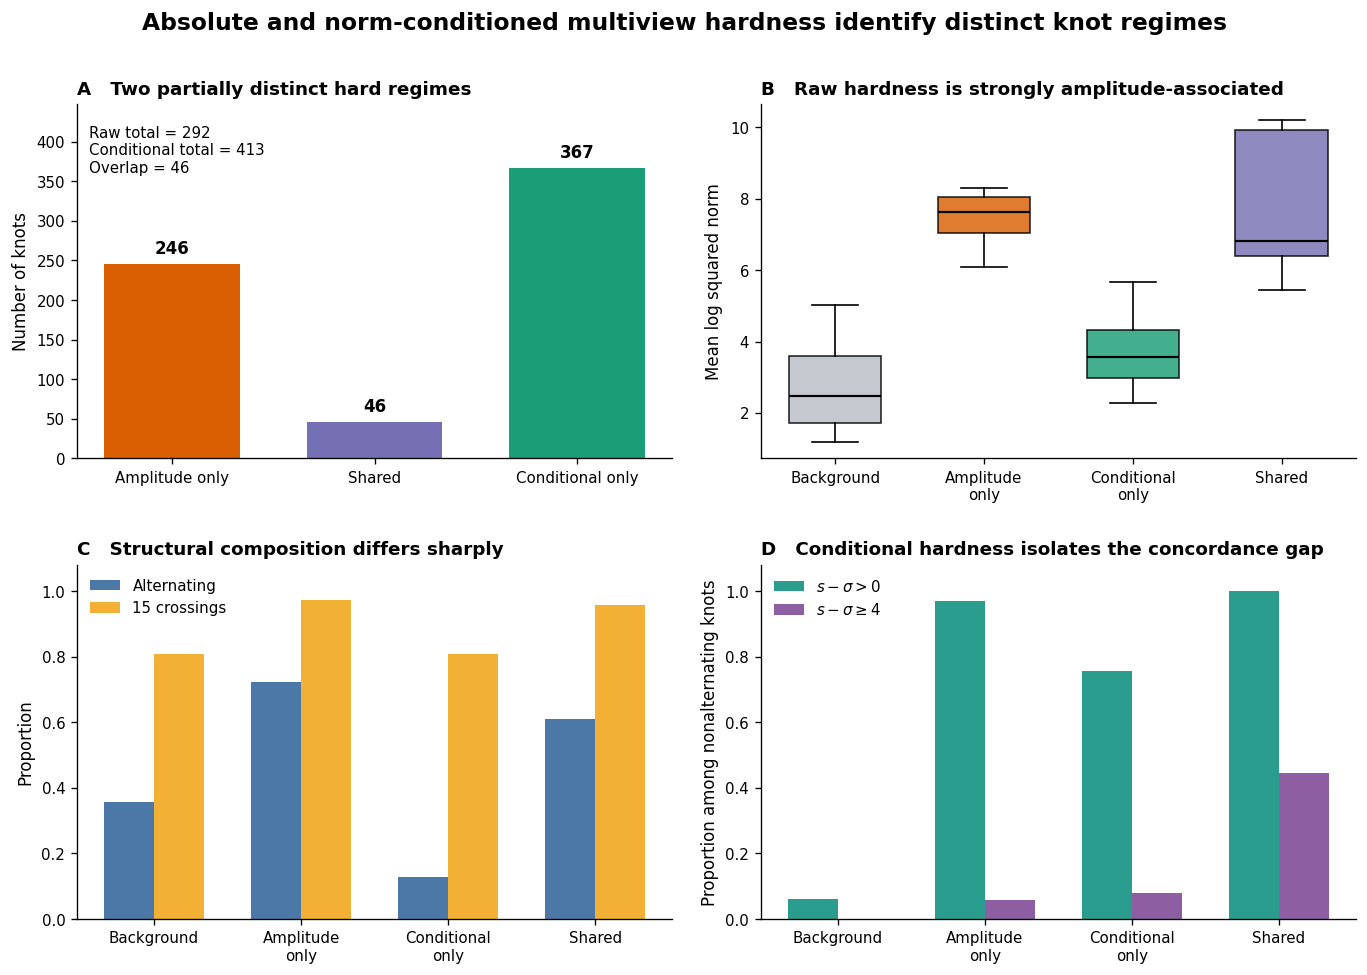

Saved:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18_paper_figures/figure1_two_hardness_regimes.png
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18_paper_figures/figure1_two_hardness_regimes.pdf


In [127]:
# ============================================================
# STEP 18A — FIGURE 1: TWO HARDNESS REGIMES
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

FIGURE_DIR = ch.stage_directory(
    OUTPUT_DIR,
    18,
    "paper_figures",
)

FIGURE_SOURCE_DIR = (
    FIGURE_DIR /
    "source_data"
)

FIGURE_SOURCE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# 1. Publication style
# ------------------------------------------------------------

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 120,
        "savefig.dpi": 400,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

regime_order = [
    "neither",
    "amplitude_hard_only",
    "conditional_hard_only",
    "shared_raw_and_conditional",
]

regime_labels = {
    "neither": "Background",
    "amplitude_hard_only": "Amplitude\nonly",
    "conditional_hard_only": "Conditional\nonly",
    "shared_raw_and_conditional": "Shared",
}

regime_colors = {
    "neither": "#B8BDC6",
    "amplitude_hard_only": "#D95F02",
    "conditional_hard_only": "#1B9E77",
    "shared_raw_and_conditional": "#7570B3",
}

# ------------------------------------------------------------
# 2. Build figure source summary
# ------------------------------------------------------------

figure1_rows = []

for regime in regime_order:

    group = atlas.loc[
        atlas["hard_regime"] == regime
    ].copy()

    nonalternating = group.loc[
        ~group["is_alternating"].astype(bool)
    ]

    figure1_rows.append(
        {
            "hard_regime": regime,
            "label": regime_labels[regime],
            "n": len(group),
            "prop_crossing_15": (
                group[
                    "number_of_crossings"
                ]
                .eq(15)
                .mean()
            ),
            "prop_alternating": (
                group[
                    "is_alternating"
                ]
                .astype(bool)
                .mean()
            ),
            "median_signature": (
                group[
                    "signature"
                ].median()
            ),
            "median_s": (
                group[
                    "s_invariant_qc"
                ].median()
            ),
            "median_mean_log_norm": (
                group[
                    "mean_log_sq_norm"
                ].median()
            ),
            "nonalternating_n": (
                len(nonalternating)
            ),
            "nonalt_delta_positive_prop": (
                nonalternating[
                    "s_minus_sigma_qc"
                ]
                .gt(0)
                .mean()
                if len(nonalternating)
                else np.nan
            ),
            "nonalt_delta_ge_4_prop": (
                nonalternating[
                    "s_minus_sigma_qc"
                ]
                .ge(4)
                .mean()
                if len(nonalternating)
                else np.nan
            ),
            "nonalt_mean_delta": (
                nonalternating[
                    "s_minus_sigma_qc"
                ].mean()
                if len(nonalternating)
                else np.nan
            ),
        }
    )

figure1_source = pd.DataFrame(
    figure1_rows
)

figure1_source.to_csv(
    FIGURE_SOURCE_DIR /
    "figure1_two_regimes_summary.csv",
    index=False,
)

display(figure1_source)

# ------------------------------------------------------------
# 3. Build Figure 1
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 8.0),
)

ax_a, ax_b, ax_c, ax_d = (
    axes.flatten()
)

# ------------------------------------------------------------
# Panel A — Hard-regime census
# ------------------------------------------------------------

hard_only_order = [
    "amplitude_hard_only",
    "shared_raw_and_conditional",
    "conditional_hard_only",
]

hard_counts = [
    int(
        figure1_source.loc[
            figure1_source[
                "hard_regime"
            ].eq(regime),
            "n",
        ].iloc[0]
    )
    for regime in hard_only_order
]

bars = ax_a.bar(
    np.arange(3),
    hard_counts,
    color=[
        regime_colors[regime]
        for regime
        in hard_only_order
    ],
    width=0.67,
)

ax_a.set_xticks(
    np.arange(3)
)

ax_a.set_xticklabels(
    [
        "Amplitude only",
        "Shared",
        "Conditional only",
    ]
)

ax_a.set_ylabel("Number of knots")

ax_a.set_title(
    "A   Two partially distinct hard regimes",
    loc="left",
    fontweight="bold",
)

for bar, value in zip(
    bars,
    hard_counts,
):

    ax_a.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        bar.get_height() + 8,
        f"{value}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax_a.text(
    0.02,
    0.94,
    "Raw total = 292\nConditional total = 413\nOverlap = 46",
    transform=ax_a.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

ax_a.set_ylim(
    0,
    max(hard_counts) * 1.22,
)

# ------------------------------------------------------------
# Panel B — Norm/amplitude distributions
# ------------------------------------------------------------

box_data = [
    atlas.loc[
        atlas["hard_regime"].eq(regime),
        "mean_log_sq_norm",
    ]
    .dropna()
    .to_numpy()
    for regime
    in regime_order
]

boxplot = ax_b.boxplot(
    box_data,
    labels=[
        regime_labels[regime]
        for regime
        in regime_order
    ],
    patch_artist=True,
    showfliers=False,
    whis=(5, 95),
    widths=0.62,
    medianprops={
        "color": "black",
        "linewidth": 1.3,
    },
)

for patch, regime in zip(
    boxplot["boxes"],
    regime_order,
):

    patch.set_facecolor(
        regime_colors[regime]
    )

    patch.set_alpha(0.82)

ax_b.set_ylabel(
    "Mean log squared norm"
)

ax_b.set_title(
    "B   Raw hardness is strongly amplitude-associated",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------
# Panel C — Structural composition
# ------------------------------------------------------------

x = np.arange(
    len(regime_order)
)

width = 0.34

alternating_values = (
    figure1_source
    .set_index("hard_regime")
    .loc[
        regime_order,
        "prop_alternating",
    ]
    .to_numpy()
)

crossing15_values = (
    figure1_source
    .set_index("hard_regime")
    .loc[
        regime_order,
        "prop_crossing_15",
    ]
    .to_numpy()
)

ax_c.bar(
    x - width / 2,
    alternating_values,
    width,
    label="Alternating",
    color="#4C78A8",
)

ax_c.bar(
    x + width / 2,
    crossing15_values,
    width,
    label="15 crossings",
    color="#F2B134",
)

ax_c.set_xticks(x)

ax_c.set_xticklabels(
    [
        regime_labels[regime]
        for regime
        in regime_order
    ]
)

ax_c.set_ylim(0, 1.08)
ax_c.set_ylabel("Proportion")
ax_c.legend(
    frameon=False,
    loc="upper left",
)

ax_c.set_title(
    "C   Structural composition differs sharply",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------
# Panel D — Nonalternating Rasmussen–signature gap
# ------------------------------------------------------------

delta_positive = (
    figure1_source
    .set_index("hard_regime")
    .loc[
        regime_order,
        "nonalt_delta_positive_prop",
    ]
    .to_numpy()
)

delta_ge_4 = (
    figure1_source
    .set_index("hard_regime")
    .loc[
        regime_order,
        "nonalt_delta_ge_4_prop",
    ]
    .to_numpy()
)

ax_d.bar(
    x - width / 2,
    delta_positive,
    width,
    label=r"$s-\sigma>0$",
    color="#2A9D8F",
)

ax_d.bar(
    x + width / 2,
    delta_ge_4,
    width,
    label=r"$s-\sigma\geq4$",
    color="#8E5EA2",
)

ax_d.set_xticks(x)

ax_d.set_xticklabels(
    [
        regime_labels[regime]
        for regime
        in regime_order
    ]
)

ax_d.set_ylim(0, 1.08)
ax_d.set_ylabel(
    "Proportion among nonalternating knots"
)

ax_d.legend(
    frameon=False,
    loc="upper left",
)

ax_d.set_title(
    "D   Conditional hardness isolates the concordance gap",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------
# 4. Final layout and save
# ------------------------------------------------------------

fig.suptitle(
    "Absolute and norm-conditioned multiview hardness identify distinct knot regimes",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

fig.tight_layout(
    h_pad=2.3,
    w_pad=1.7,
)

figure1_png = (
    FIGURE_DIR /
    "figure1_two_hardness_regimes.png"
)

figure1_pdf = (
    FIGURE_DIR /
    "figure1_two_hardness_regimes.pdf"
)

fig.savefig(
    figure1_png,
    bbox_inches="tight",
)

fig.savefig(
    figure1_pdf,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(figure1_png)
print(figure1_pdf)

## correcta imagen

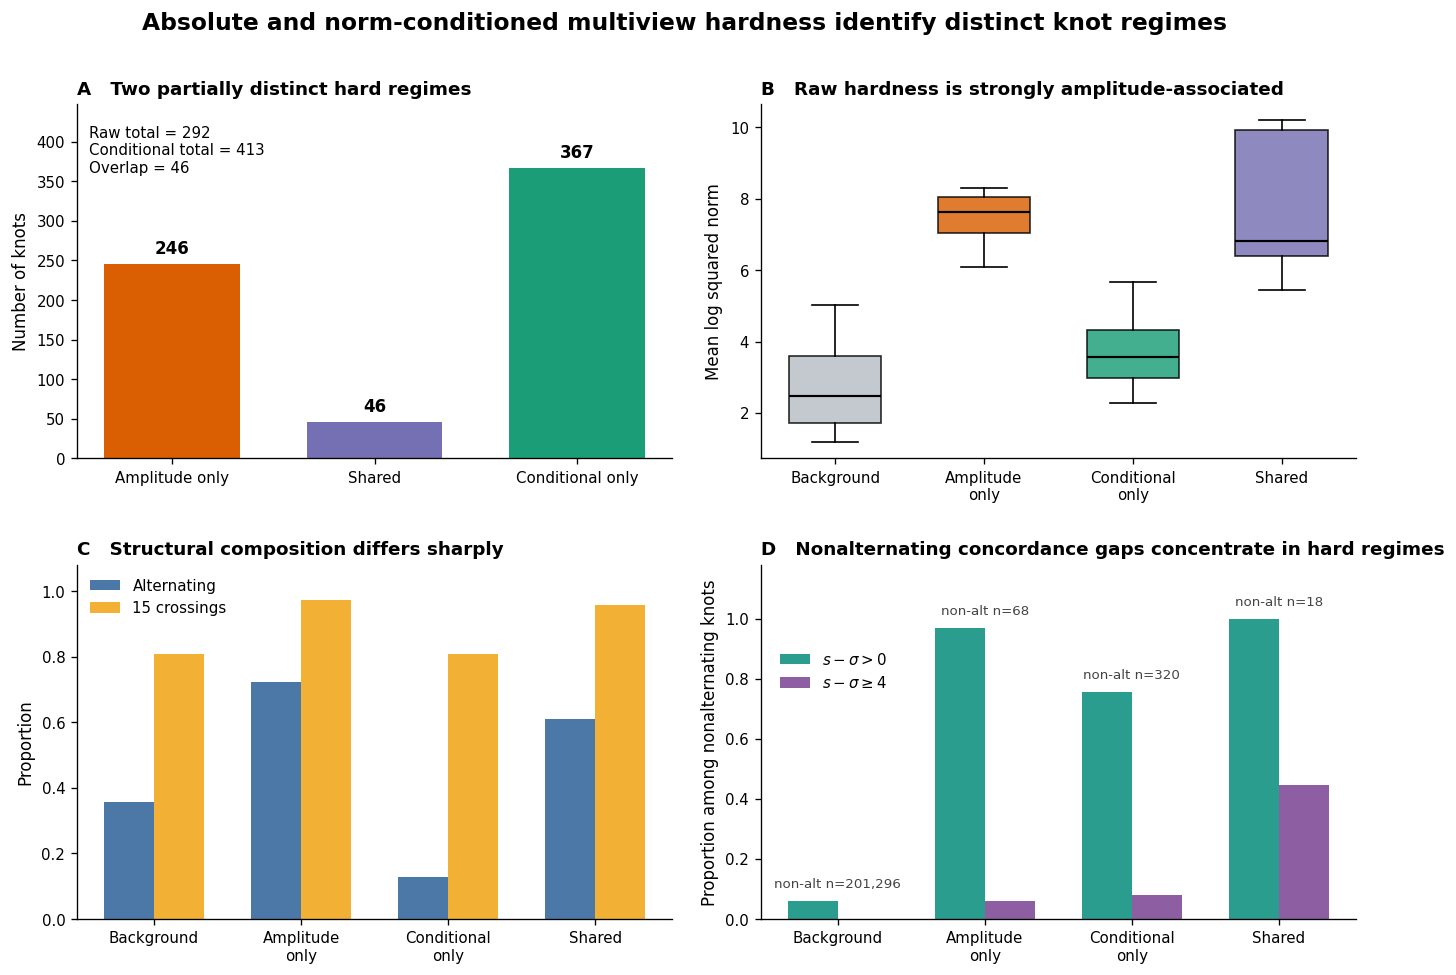

In [128]:
# More neutral and statistically faithful Panel D title
ax_d.set_title(
    "D   Nonalternating concordance gaps concentrate in hard regimes",
    loc="left",
    fontweight="bold",
)

ax_d.set_ylim(0, 1.18)

nonalternating_counts = (
    figure1_source
    .set_index("hard_regime")
    .loc[
        regime_order,
        "nonalternating_n",
    ]
    .astype(int)
    .to_numpy()
)

for position, (
    n_nonalt,
    positive_prop,
    large_gap_prop,
) in enumerate(
    zip(
        nonalternating_counts,
        delta_positive,
        delta_ge_4,
    )
):

    height = max(
        positive_prop,
        large_gap_prop,
    )

    ax_d.text(
        position,
        height + 0.035,
        f"non-alt n={n_nonalt:,}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#444444",
    )

ax_d.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(0.01, 0.70),
)

fig.savefig(
    figure1_png,
    bbox_inches="tight",
)

fig.savefig(
    figure1_pdf,
    bbox_inches="tight",
)

display(fig)

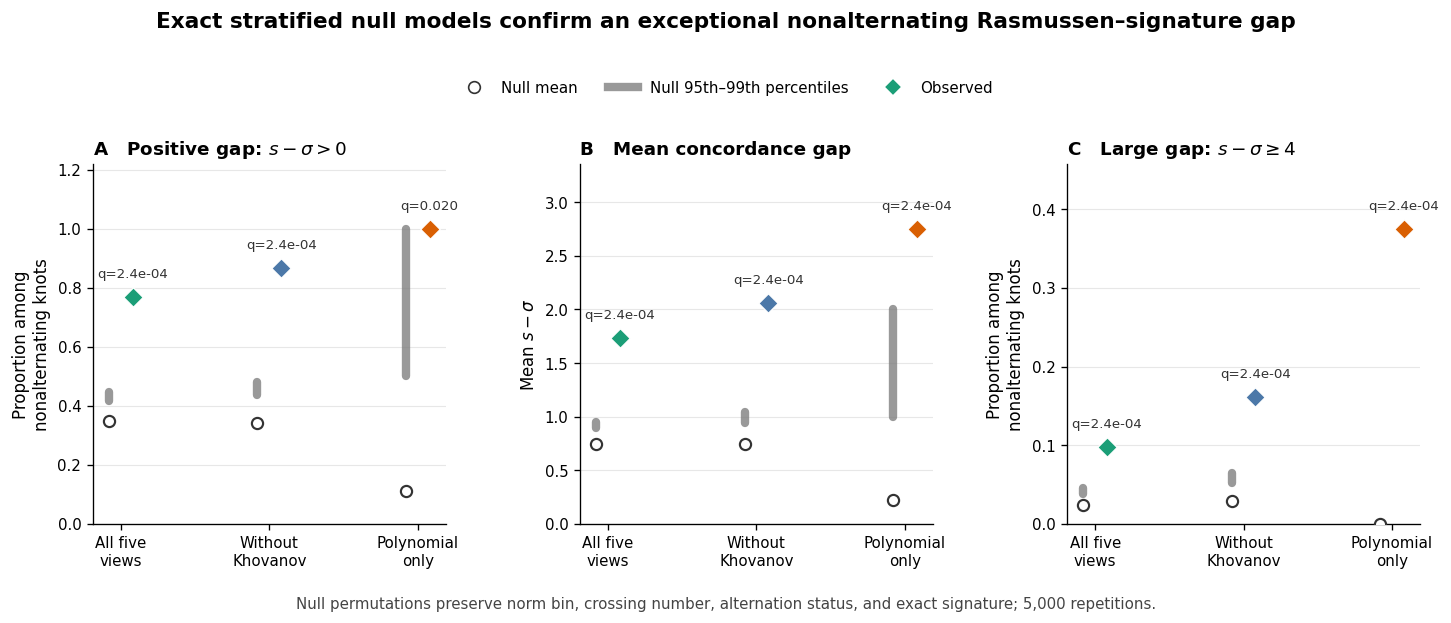

Saved:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18_paper_figures/figure2_exact_conditional_nulls.png
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18_paper_figures/figure2_exact_conditional_nulls.pdf


In [129]:
# ============================================================
# STEP 18B — FIGURE 2: EXACT CONDITIONAL NULLS
# ============================================================

from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Frozen source data from the 5000-repetition focused null
# ------------------------------------------------------------

focused_gap_null_summary = pd.DataFrame(
    [
        # All five views
        {
            "family": "All 5",
            "metric": "nonalt_s_gt_sigma_prop",
            "observed": 0.769231,
            "null_mean": 0.350172,
            "null_q95": 0.417476,
            "null_q99": 0.447368,
            "n_ge_observed": 0,
            "n_valid_null": 5000,
            "n_missing_null": 0,
            "empirical_p": 0.000200,
            "q_value": 0.000236,
        },
        {
            "family": "All 5",
            "metric": "mean_s_minus_sigma",
            "observed": 1.733728,
            "null_mean": 0.747633,
            "null_q95": 0.888889,
            "null_q99": 0.948469,
            "n_ge_observed": 0,
            "n_valid_null": 5000,
            "n_missing_null": 0,
            "empirical_p": 0.000200,
            "q_value": 0.000236,
        },
        {
            "family": "All 5",
            "metric": "delta_ge_4_prop",
            "observed": 0.097633,
            "null_mean": 0.024309,
            "null_q95": 0.038462,
            "null_q99": 0.045455,
            "n_ge_observed": 0,
            "n_valid_null": 5000,
            "n_missing_null": 0,
            "empirical_p": 0.000200,
            "q_value": 0.000236,
        },

        # Without Khovanov
        {
            "family": "No Khovanov",
            "metric": "nonalt_s_gt_sigma_prop",
            "observed": 0.868263,
            "null_mean": 0.342729,
            "null_q95": 0.436364,
            "null_q99": 0.480769,
            "n_ge_observed": 0,
            "n_valid_null": 5000,
            "n_missing_null": 0,
            "empirical_p": 0.000200,
            "q_value": 0.000236,
        },
        {
            "family": "No Khovanov",
            "metric": "mean_s_minus_sigma",
            "observed": 2.059880,
            "null_mean": 0.742885,
            "null_q95": 0.941176,
            "null_q99": 1.041685,
            "n_ge_observed": 0,
            "n_valid_null": 5000,
            "n_missing_null": 0,
            "empirical_p": 0.000200,
            "q_value": 0.000236,
        },
        {
            "family": "No Khovanov",
            "metric": "delta_ge_4_prop",
            "observed": 0.161677,
            "null_mean": 0.028983,
            "null_q95": 0.051770,
            "null_q99": 0.065217,
            "n_ge_observed": 0,
            "n_valid_null": 5000,
            "n_missing_null": 0,
            "empirical_p": 0.000200,
            "q_value": 0.000236,
        },

        # Polynomial-only
        {
            "family": "Polynomial only",
            "metric": "nonalt_s_gt_sigma_prop",
            "observed": 1.000000,
            "null_mean": 0.111260,
            "null_q95": 0.500000,
            "null_q99": 1.000000,
            "n_ge_observed": 93,
            "n_valid_null": 4768,
            "n_missing_null": 232,
            "empirical_p": 0.019711,
            "q_value": 0.019711,
        },
        {
            "family": "Polynomial only",
            "metric": "mean_s_minus_sigma",
            "observed": 2.750000,
            "null_mean": 0.222437,
            "null_q95": 1.000000,
            "null_q99": 2.000000,
            "n_ge_observed": 0,
            "n_valid_null": 4768,
            "n_missing_null": 232,
            "empirical_p": 0.000210,
            "q_value": 0.000236,
        },
        {
            "family": "Polynomial only",
            "metric": "delta_ge_4_prop",
            "observed": 0.375000,
            "null_mean": 0.000105,
            "null_q95": 0.000000,
            "null_q99": 0.000000,
            "n_ge_observed": 0,
            "n_valid_null": 4768,
            "n_missing_null": 232,
            "empirical_p": 0.000210,
            "q_value": 0.000236,
        },
    ]
)

focused_gap_null_summary.to_csv(
    FIGURE_SOURCE_DIR /
    "figure2_exact_conditional_nulls.csv",
    index=False,
)

# ------------------------------------------------------------
# 2. Plot definitions
# ------------------------------------------------------------

family_order = [
    "All 5",
    "No Khovanov",
    "Polynomial only",
]

family_labels = {
    "All 5": "All five\nviews",
    "No Khovanov": "Without\nKhovanov",
    "Polynomial only": "Polynomial\nonly",
}

family_colors = {
    "All 5": "#1B9E77",
    "No Khovanov": "#4C78A8",
    "Polynomial only": "#D95F02",
}

metric_specs = [
    {
        "metric": "nonalt_s_gt_sigma_prop",
        "title": r"A   Positive gap: $s-\sigma>0$",
        "ylabel": (
            "Proportion among\n"
            "nonalternating knots"
        ),
    },
    {
        "metric": "mean_s_minus_sigma",
        "title": r"B   Mean concordance gap",
        "ylabel": r"Mean $s-\sigma$",
    },
    {
        "metric": "delta_ge_4_prop",
        "title": r"C   Large gap: $s-\sigma\geq4$",
        "ylabel": (
            "Proportion among\n"
            "nonalternating knots"
        ),
    },
]

# ------------------------------------------------------------
# 3. Draw exact-null comparison
# ------------------------------------------------------------

fig2, axes2 = plt.subplots(
    1,
    3,
    figsize=(12.2, 4.2),
)

for axis, spec in zip(
    axes2,
    metric_specs,
):

    metric_df = (
        focused_gap_null_summary.loc[
            focused_gap_null_summary[
                "metric"
            ].eq(spec["metric"])
        ]
        .set_index("family")
        .loc[family_order]
        .reset_index()
    )

    x = np.arange(
        len(family_order)
    )

    null_x = x - 0.08
    observed_x = x + 0.08

    # Null 95th–99th percentile segment
    for position, row in zip(
        null_x,
        metric_df.itertuples(
            index=False
        ),
    ):

        axis.plot(
            [
                position,
                position,
            ],
            [
                row.null_q95,
                row.null_q99,
            ],
            color="#777777",
            linewidth=5,
            solid_capstyle="round",
            alpha=0.75,
            zorder=2,
        )

    # Null means
    axis.scatter(
        null_x,
        metric_df["null_mean"],
        marker="o",
        s=45,
        facecolor="white",
        edgecolor="#333333",
        linewidth=1.3,
        zorder=3,
    )

    # Observed values
    for position, family, observed in zip(
        observed_x,
        family_order,
        metric_df["observed"],
    ):

        axis.scatter(
            position,
            observed,
            marker="D",
            s=68,
            color=family_colors[family],
            edgecolor="white",
            linewidth=0.8,
            zorder=4,
        )

    maximum_value = max(
        metric_df["observed"].max(),
        metric_df["null_q99"].max(),
    )

    annotation_offset = (
        0.055 * maximum_value
        if maximum_value > 0
        else 0.03
    )

    for position, row in zip(
        observed_x,
        metric_df.itertuples(
            index=False
        ),
    ):

        q_text = (
            f"q={row.q_value:.1e}"
            if row.q_value < 0.001
            else
            f"q={row.q_value:.3f}"
        )

        axis.text(
            position,
            row.observed
            +
            annotation_offset,
            q_text,
            ha="center",
            va="bottom",
            fontsize=8,
            color="#333333",
        )

    axis.set_xticks(x)

    axis.set_xticklabels(
        [
            family_labels[family]
            for family
            in family_order
        ]
    )

    axis.set_ylabel(
        spec["ylabel"]
    )

    axis.set_title(
        spec["title"],
        loc="left",
        fontweight="bold",
    )

    axis.set_ylim(
        0,
        maximum_value * 1.22,
    )

    axis.grid(
        axis="y",
        color="#DDDDDD",
        linewidth=0.7,
        alpha=0.7,
    )

# ------------------------------------------------------------
# 4. Shared legend and explanatory title
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="#333333",
        markersize=7,
        label="Null mean",
    ),
    Line2D(
        [0],
        [0],
        color="#777777",
        linewidth=5,
        alpha=0.75,
        label="Null 95th–99th percentiles",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        color="none",
        markerfacecolor="#1B9E77",
        markeredgecolor="white",
        markersize=8,
        label="Observed",
    ),
]

fig2.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    frameon=False,
)

fig2.suptitle(
    "Exact stratified null models confirm an exceptional nonalternating Rasmussen–signature gap",
    fontsize=13,
    fontweight="bold",
    y=1.14,
)

fig2.text(
    0.5,
    -0.02,
    (
        "Null permutations preserve norm bin, crossing number, "
        "alternation status, and exact signature; 5,000 repetitions."
    ),
    ha="center",
    va="top",
    fontsize=9,
    color="#444444",
)

fig2.tight_layout(
    w_pad=2.0,
)

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

figure2_png = (
    FIGURE_DIR /
    "figure2_exact_conditional_nulls.png"
)

figure2_pdf = (
    FIGURE_DIR /
    "figure2_exact_conditional_nulls.pdf"
)

fig2.savefig(
    figure2_png,
    bbox_inches="tight",
)

fig2.savefig(
    figure2_pdf,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(figure2_png)
print(figure2_pdf)

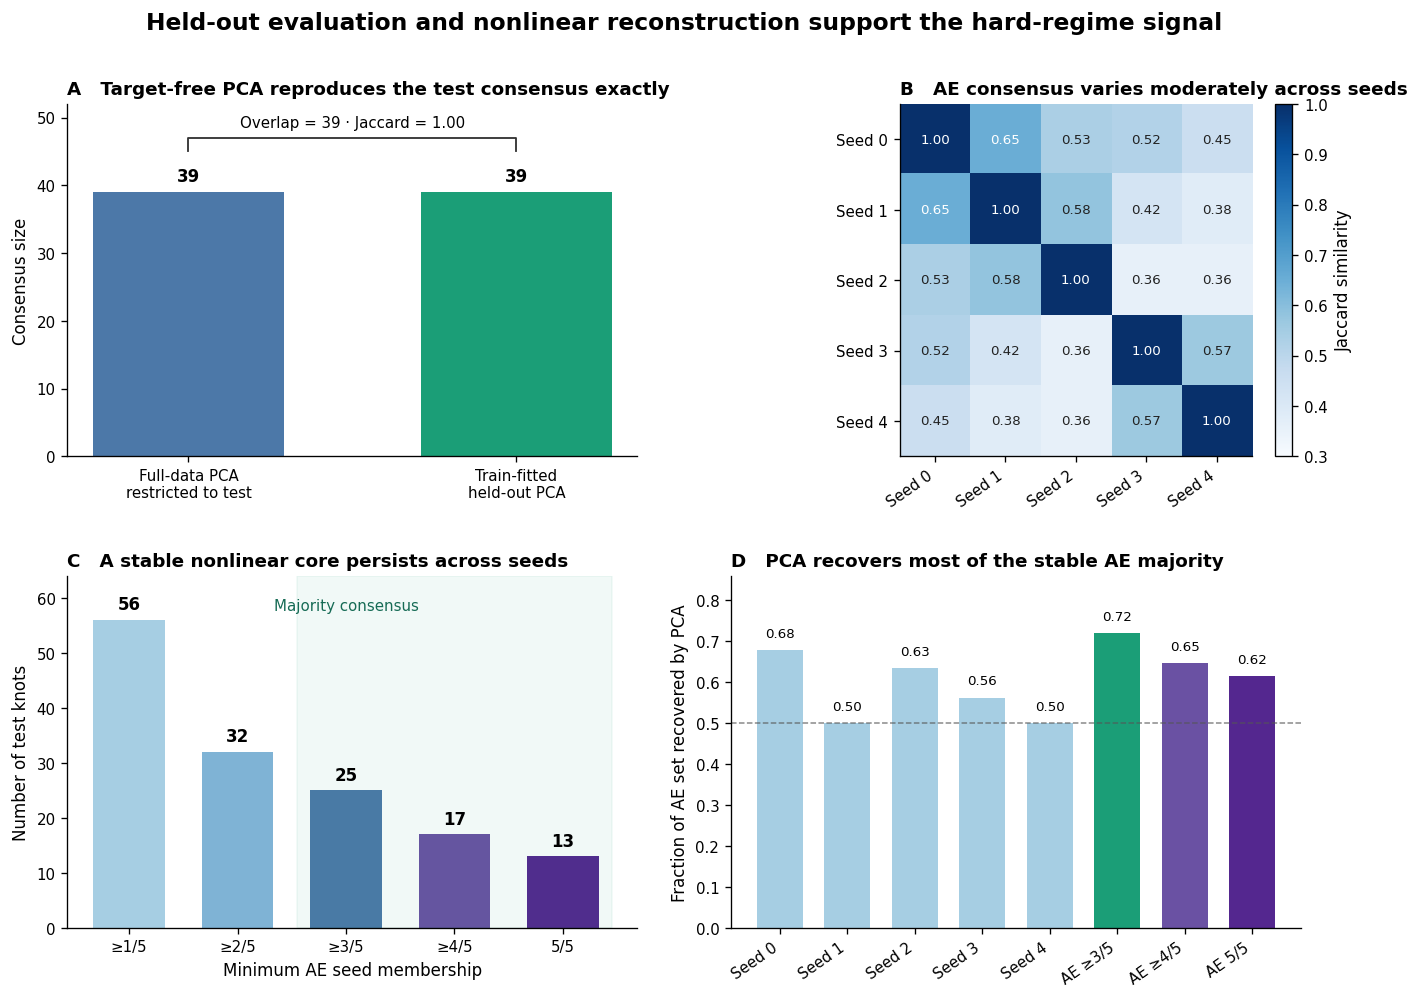

Saved:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18_paper_figures/figure3_heldout_ae_robustness.png
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18_paper_figures/figure3_heldout_ae_robustness.pdf


In [130]:
# ============================================================
# STEP 18C — FIGURE 3: HELD-OUT AND MODEL-CLASS ROBUSTNESS
# ============================================================

# ------------------------------------------------------------
# 1. Frozen source data
# ------------------------------------------------------------

ae_seed_sizes = pd.DataFrame(
    {
        "seed": [0, 1, 2, 3, 4],
        "consensus_size": [28, 38, 41, 16, 20],
        "pca_overlap": [19, 19, 26, 9, 10],
    }
)

ae_seed_sizes[
    "fraction_ae_in_pca"
] = (
    ae_seed_sizes[
        "pca_overlap"
    ]
    /
    ae_seed_sizes[
        "consensus_size"
    ]
)

ae_jaccard_values = np.array(
    [
        [
            1.000000,
            0.650000,
            0.533333,
            0.517241,
            0.454545,
        ],
        [
            0.650000,
            1.000000,
            0.580000,
            0.421053,
            0.380952,
        ],
        [
            0.533333,
            0.580000,
            1.000000,
            0.357143,
            0.355556,
        ],
        [
            0.517241,
            0.421053,
            0.357143,
            1.000000,
            0.565217,
        ],
        [
            0.454545,
            0.380952,
            0.355556,
            0.565217,
            1.000000,
        ],
    ]
)

ae_membership_tiers = pd.DataFrame(
    {
        "minimum_seed_membership": [
            "≥1/5",
            "≥2/5",
            "≥3/5",
            "≥4/5",
            "5/5",
        ],
        "n_knots": [
            56,
            32,
            25,
            17,
            13,
        ],
    }
)

pca_ae_overlap_summary = pd.DataFrame(
    {
        "analysis": [
            "Seed 0",
            "Seed 1",
            "Seed 2",
            "Seed 3",
            "Seed 4",
            "AE ≥3/5",
            "AE ≥4/5",
            "AE 5/5",
        ],
        "ae_size": [
            28,
            38,
            41,
            16,
            20,
            25,
            17,
            13,
        ],
        "overlap_with_pca": [
            19,
            19,
            26,
            9,
            10,
            18,
            11,
            8,
        ],
    }
)

pca_ae_overlap_summary[
    "fraction_ae_in_pca"
] = (
    pca_ae_overlap_summary[
        "overlap_with_pca"
    ]
    /
    pca_ae_overlap_summary[
        "ae_size"
    ]
)

# Long-format Jaccard source data
jaccard_source_rows = []

for seed_a in range(5):
    for seed_b in range(5):

        jaccard_source_rows.append(
            {
                "seed_a": seed_a,
                "seed_b": seed_b,
                "jaccard": (
                    ae_jaccard_values[
                        seed_a,
                        seed_b,
                    ]
                ),
            }
        )

ae_jaccard_source = pd.DataFrame(
    jaccard_source_rows
)

# Save source data
ae_seed_sizes.to_csv(
    FIGURE_SOURCE_DIR /
    "figure3_ae_seed_sizes.csv",
    index=False,
)

ae_membership_tiers.to_csv(
    FIGURE_SOURCE_DIR /
    "figure3_ae_membership_tiers.csv",
    index=False,
)

pca_ae_overlap_summary.to_csv(
    FIGURE_SOURCE_DIR /
    "figure3_pca_ae_overlap.csv",
    index=False,
)

ae_jaccard_source.to_csv(
    FIGURE_SOURCE_DIR /
    "figure3_ae_jaccard_matrix.csv",
    index=False,
)

# ------------------------------------------------------------
# 2. Figure canvas
# ------------------------------------------------------------

fig3, axes3 = plt.subplots(
    2,
    2,
    figsize=(11.5, 8.2),
)

ax_a, ax_b, ax_c, ax_d = (
    axes3.flatten()
)

# ------------------------------------------------------------
# Panel A — Exact held-out PCA replication
# ------------------------------------------------------------

pca_labels = [
    "Full-data PCA\nrestricted to test",
    "Train-fitted\nheld-out PCA",
]

pca_sizes = [
    39,
    39,
]

pca_bars = ax_a.bar(
    [0, 1],
    pca_sizes,
    color=[
        "#4C78A8",
        "#1B9E77",
    ],
    width=0.58,
)

ax_a.set_xticks(
    [0, 1]
)

ax_a.set_xticklabels(
    pca_labels
)

ax_a.set_ylabel(
    "Consensus size"
)

ax_a.set_ylim(
    0,
    52,
)

for bar, value in zip(
    pca_bars,
    pca_sizes,
):

    ax_a.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        value + 1.0,
        str(value),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Overlap bracket
ax_a.plot(
    [0, 0, 1, 1],
    [45, 47, 47, 45],
    color="#333333",
    linewidth=1.1,
)

ax_a.text(
    0.5,
    48.2,
    "Overlap = 39 · Jaccard = 1.00",
    ha="center",
    va="bottom",
    fontsize=9,
)

ax_a.set_title(
    "A   Target-free PCA reproduces the test consensus exactly",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------
# Panel B — AE seed Jaccard matrix
# ------------------------------------------------------------

heatmap = ax_b.imshow(
    ae_jaccard_values,
    cmap="Blues",
    vmin=0.30,
    vmax=1.00,
    aspect="equal",
)

ax_b.set_xticks(
    np.arange(5)
)

ax_b.set_yticks(
    np.arange(5)
)

ax_b.set_xticklabels(
    [
        f"Seed {seed}"
        for seed in range(5)
    ],
    rotation=35,
    ha="right",
)

ax_b.set_yticklabels(
    [
        f"Seed {seed}"
        for seed in range(5)
    ]
)

for row in range(5):
    for col in range(5):

        value = (
            ae_jaccard_values[
                row,
                col,
            ]
        )

        ax_b.text(
            col,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if value >= 0.65
                else "#222222"
            ),
        )

colorbar = fig3.colorbar(
    heatmap,
    ax=ax_b,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Jaccard similarity"
)

ax_b.set_title(
    "B   AE consensus varies moderately across seeds",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------
# Panel C — AE seed-membership stability
# ------------------------------------------------------------

tier_x = np.arange(
    len(ae_membership_tiers)
)

tier_colors = [
    "#A6CEE3",
    "#7FB3D5",
    "#4C78A8",
    "#6A51A3",
    "#54278F",
]

tier_bars = ax_c.bar(
    tier_x,
    ae_membership_tiers[
        "n_knots"
    ],
    color=tier_colors,
    width=0.66,
)

ax_c.set_xticks(
    tier_x
)

ax_c.set_xticklabels(
    ae_membership_tiers[
        "minimum_seed_membership"
    ]
)

ax_c.set_xlabel(
    "Minimum AE seed membership"
)

ax_c.set_ylabel(
    "Number of test knots"
)

ax_c.set_ylim(
    0,
    64,
)

for bar, value in zip(
    tier_bars,
    ae_membership_tiers[
        "n_knots"
    ],
):

    ax_c.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        value + 1.2,
        str(value),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax_c.axvspan(
    1.55,
    4.45,
    color="#1B9E77",
    alpha=0.06,
)

ax_c.text(
    2.0,
    58.5,
    "Majority consensus",
    ha="center",
    va="center",
    fontsize=9,
    color="#166B55",
)

ax_c.set_title(
    "C   A stable nonlinear core persists across seeds",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------
# Panel D — Fraction of each AE set recovered by PCA
# ------------------------------------------------------------

overlap_x = np.arange(
    len(
        pca_ae_overlap_summary
    )
)

overlap_colors = [
    "#A6CEE3",
    "#A6CEE3",
    "#A6CEE3",
    "#A6CEE3",
    "#A6CEE3",
    "#1B9E77",
    "#6A51A3",
    "#54278F",
]

overlap_bars = ax_d.bar(
    overlap_x,
    pca_ae_overlap_summary[
        "fraction_ae_in_pca"
    ],
    color=overlap_colors,
    width=0.68,
)

ax_d.set_xticks(
    overlap_x
)

ax_d.set_xticklabels(
    pca_ae_overlap_summary[
        "analysis"
    ],
    rotation=35,
    ha="right",
)

ax_d.set_ylim(
    0,
    0.86,
)

ax_d.set_ylabel(
    "Fraction of AE set recovered by PCA"
)

for bar, fraction in zip(
    overlap_bars,
    pca_ae_overlap_summary[
        "fraction_ae_in_pca"
    ],
):

    ax_d.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        fraction + 0.025,
        f"{fraction:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax_d.axhline(
    0.5,
    color="#555555",
    linestyle="--",
    linewidth=0.9,
    alpha=0.7,
)

ax_d.set_title(
    "D   PCA recovers most of the stable AE majority",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------
# 3. Final layout and save
# ------------------------------------------------------------

fig3.suptitle(
    "Held-out evaluation and nonlinear reconstruction support the hard-regime signal",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

fig3.tight_layout(
    h_pad=2.5,
    w_pad=2.0,
)

figure3_png = (
    FIGURE_DIR /
    "figure3_heldout_ae_robustness.png"
)

figure3_pdf = (
    FIGURE_DIR /
    "figure3_heldout_ae_robustness.pdf"
)

fig3.savefig(
    figure3_png,
    bbox_inches="tight",
)

fig3.savefig(
    figure3_pdf,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(figure3_png)
print(figure3_pdf)

/tmp/ipykernel_666/2925414322.py:265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  volume_boxplot = ax_a.boxplot(
/tmp/ipykernel_666/2925414322.py:364: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  paired_boxplot = ax_b.boxplot(
/tmp/ipykernel_666/2925414322.py:761: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_d.legend(


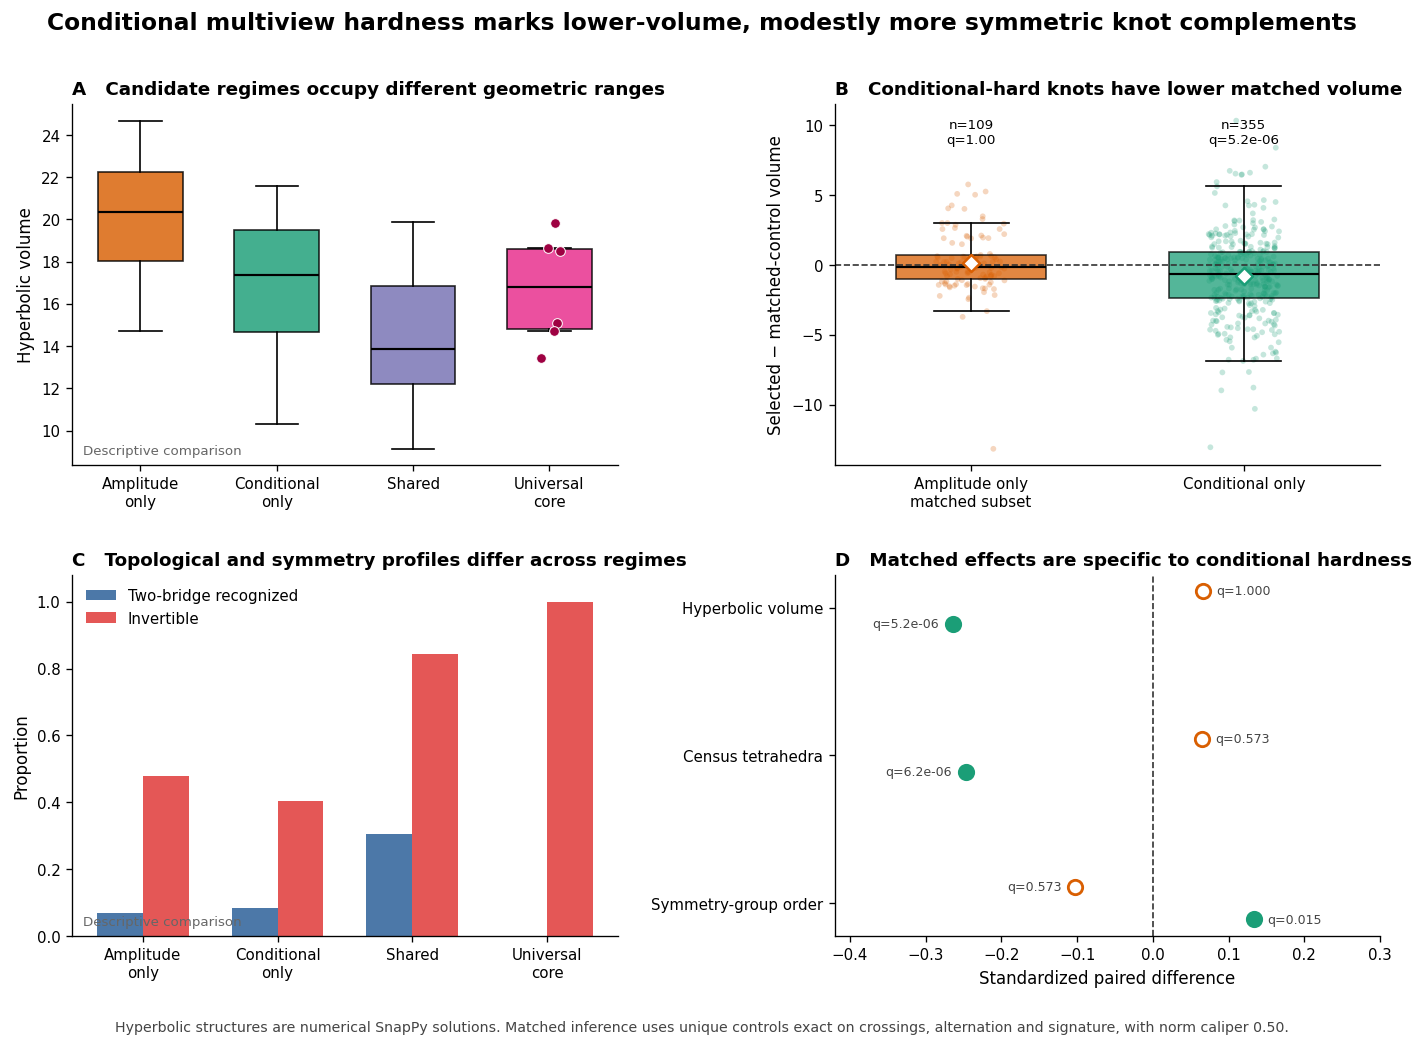

Saved:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18_paper_figures/figure4_geometric_characterization.png
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18_paper_figures/figure4_geometric_characterization.pdf


In [132]:
# ============================================================
# STEP 18D — FIGURE 4: GEOMETRIC CHARACTERIZATION
# ============================================================

# ------------------------------------------------------------
# 1. Descriptive hyperbolic-volume source data
# ------------------------------------------------------------

descriptive_regime_order = [
    "amplitude_hard_only",
    "conditional_hard_only",
    "shared_raw_and_conditional",
]

descriptive_labels = {
    "amplitude_hard_only": "Amplitude\nonly",
    "conditional_hard_only": "Conditional\nonly",
    "shared_raw_and_conditional": "Shared",
    "universal_core": "Universal\ncore",
}

descriptive_colors = {
    "amplitude_hard_only": "#D95F02",
    "conditional_hard_only": "#1B9E77",
    "shared_raw_and_conditional": "#7570B3",
    "universal_core": "#E7298A",
}

volume_source_frames = []

for regime in descriptive_regime_order:

    frame = candidate_geometry.loc[
        candidate_geometry[
            "hard_regime"
        ].eq(regime)
        &
        candidate_geometry[
            "numerically_hyperbolic"
        ].eq(True),
        [
            "knot_id_base",
            "hard_regime",
            "volume",
        ],
    ].copy()

    frame["plot_regime"] = regime

    volume_source_frames.append(
        frame
    )

core_volume_source = (
    universal_core_snappy.loc[
        universal_core_snappy[
            "solution_type"
        ]
        .str.lower()
        .str.contains(
            "positively oriented",
            na=False,
        ),
        [
            "knot_id_base",
            "volume",
        ],
    ]
    .copy()
)

core_volume_source[
    "hard_regime"
] = "universal_core"

core_volume_source[
    "plot_regime"
] = "universal_core"

volume_source_frames.append(
    core_volume_source
)

figure4_volume_source = pd.concat(
    volume_source_frames,
    ignore_index=True,
)

figure4_volume_source.to_csv(
    FIGURE_SOURCE_DIR /
    "figure4_descriptive_volumes.csv",
    index=False,
)

# ------------------------------------------------------------
# 2. Pair-level matched differences
# ------------------------------------------------------------

continuous_columns = [
    "hyperbolic_volume",
    "num_tetrahedra",
    "symmetry_order",
]

paired_difference_rows = []

for regime_name in [
    "amplitude_only",
    "conditional_only",
]:

    pair_table = (
        paired_geometry_tables[
            regime_name
        ]
    )

    for outcome in continuous_columns:

        selected_values = pd.to_numeric(
            pair_table[
                "selected_" + outcome
            ],
            errors="coerce",
        )

        control_values = pd.to_numeric(
            pair_table[
                "control_" + outcome
            ],
            errors="coerce",
        )

        valid = (
            selected_values.notna()
            &
            control_values.notna()
        )

        for selected_index, difference in zip(
            pair_table.loc[
                valid,
                "selected_index",
            ],
            (
                selected_values[valid]
                -
                control_values[valid]
            ),
        ):

            paired_difference_rows.append(
                {
                    "regime": regime_name,
                    "selected_index": (
                        selected_index
                    ),
                    "outcome": outcome,
                    "paired_difference": (
                        difference
                    ),
                }
            )

figure4_paired_differences = pd.DataFrame(
    paired_difference_rows
)

figure4_paired_differences.to_csv(
    FIGURE_SOURCE_DIR /
    "figure4_paired_geometry_differences.csv",
    index=False,
)

# ------------------------------------------------------------
# 3. Descriptive geometry proportions
# ------------------------------------------------------------

geometry_proportion_source = (
    snappy_regime_summary_with_core[
        [
            "hard_regime",
            "n",
            "two_bridge_prop",
            "invertible_prop",
            "amphicheiral_prop",
            "symmetry_order_median",
        ]
    ]
    .copy()
)

geometry_proportion_source.to_csv(
    FIGURE_SOURCE_DIR /
    "figure4_geometry_proportions.csv",
    index=False,
)

# ------------------------------------------------------------
# 4. Matched standardized effects
# ------------------------------------------------------------

effect_source = (
    paired_geometry_results.loc[
        paired_geometry_results[
            "outcome_type"
        ].eq("continuous"),
        [
            "regime",
            "outcome",
            "n_valid_pairs",
            "paired_smd",
            "p_value",
            "q_value",
            "fdr_significant",
        ],
    ]
    .copy()
)

effect_source.to_csv(
    FIGURE_SOURCE_DIR /
    "figure4_matched_standardized_effects.csv",
    index=False,
)

# ------------------------------------------------------------
# 5. Figure canvas
# ------------------------------------------------------------

fig4, axes4 = plt.subplots(
    2,
    2,
    figsize=(11.8, 8.2),
)

ax_a, ax_b, ax_c, ax_d = (
    axes4.flatten()
)

# ------------------------------------------------------------
# Panel A — Descriptive volume distributions
# ------------------------------------------------------------

plot_volume_order = [
    "amplitude_hard_only",
    "conditional_hard_only",
    "shared_raw_and_conditional",
    "universal_core",
]

volume_arrays = [
    figure4_volume_source.loc[
        figure4_volume_source[
            "plot_regime"
        ].eq(regime),
        "volume",
    ]
    .dropna()
    .to_numpy()
    for regime
    in plot_volume_order
]

volume_boxplot = ax_a.boxplot(
    volume_arrays,
    labels=[
        descriptive_labels[regime]
        for regime
        in plot_volume_order
    ],
    patch_artist=True,
    showfliers=False,
    whis=(5, 95),
    widths=0.62,
    medianprops={
        "color": "black",
        "linewidth": 1.3,
    },
)

for patch, regime in zip(
    volume_boxplot["boxes"],
    plot_volume_order,
):

    patch.set_facecolor(
        descriptive_colors[regime]
    )

    patch.set_alpha(0.82)

# Show all six universal-core values
core_values = volume_arrays[-1]

rng = np.random.default_rng(42)

ax_a.scatter(
    4
    +
    rng.uniform(
        -0.08,
        0.08,
        size=len(core_values),
    ),
    core_values,
    color="#9E0142",
    edgecolor="white",
    linewidth=0.6,
    s=34,
    zorder=4,
)

ax_a.set_ylabel(
    "Hyperbolic volume"
)

ax_a.set_title(
    "A   Candidate regimes occupy different geometric ranges",
    loc="left",
    fontweight="bold",
)

ax_a.text(
    0.02,
    0.03,
    "Descriptive comparison",
    transform=ax_a.transAxes,
    fontsize=8,
    color="#666666",
)

# ------------------------------------------------------------
# Panel B — Paired hyperbolic-volume differences
# ------------------------------------------------------------

volume_difference_order = [
    "amplitude_only",
    "conditional_only",
]

volume_differences = [
    figure4_paired_differences.loc[
        figure4_paired_differences[
            "regime"
        ].eq(regime)
        &
        figure4_paired_differences[
            "outcome"
        ].eq("hyperbolic_volume"),
        "paired_difference",
    ]
    .dropna()
    .to_numpy()
    for regime
    in volume_difference_order
]

paired_colors = [
    "#D95F02",
    "#1B9E77",
]

paired_boxplot = ax_b.boxplot(
    volume_differences,
    labels=[
        "Amplitude only\nmatched subset",
        "Conditional only",
    ],
    patch_artist=True,
    showfliers=False,
    widths=0.55,
    medianprops={
        "color": "black",
        "linewidth": 1.3,
    },
)

for patch, color in zip(
    paired_boxplot["boxes"],
    paired_colors,
):

    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for position, (
    values,
    color,
) in enumerate(
    zip(
        volume_differences,
        paired_colors,
    ),
    start=1,
):

    jitter = rng.uniform(
        -0.13,
        0.13,
        size=len(values),
    )

    ax_b.scatter(
        position + jitter,
        values,
        color=color,
        alpha=0.25,
        s=12,
        edgecolor="none",
        zorder=1,
    )

    ax_b.scatter(
        position,
        np.mean(values),
        marker="D",
        color="white",
        edgecolor=color,
        linewidth=1.5,
        s=52,
        zorder=5,
    )

ax_b.axhline(
    0,
    color="#333333",
    linestyle="--",
    linewidth=1.0,
)

volume_q_values = {}

for regime in volume_difference_order:

    volume_q_values[regime] = float(
        paired_geometry_results.loc[
            paired_geometry_results[
                "regime"
            ].eq(regime)
            &
            paired_geometry_results[
                "outcome"
            ].eq(
                "Hyperbolic volume"
            ),
            "q_value",
        ].iloc[0]
    )

ax_b.text(
    1,
    ax_b.get_ylim()[1] * 0.91,
    (
        f"n={len(volume_differences[0])}\n"
        f"q={volume_q_values['amplitude_only']:.2f}"
    ),
    ha="center",
    va="top",
    fontsize=8,
)

ax_b.text(
    2,
    ax_b.get_ylim()[1] * 0.91,
    (
        f"n={len(volume_differences[1])}\n"
        f"q={volume_q_values['conditional_only']:.1e}"
    ),
    ha="center",
    va="top",
    fontsize=8,
)

ax_b.set_ylabel(
    "Selected − matched-control volume"
)

ax_b.set_title(
    "B   Conditional-hard knots have lower matched volume",
    loc="left",
    fontweight="bold",
)

# ------------------------------------------------------------
# Panel C — Descriptive topology proportions
# ------------------------------------------------------------

summary_index = (
    snappy_regime_summary_with_core
    .set_index("hard_regime")
)

summary_names = [
    "amplitude_hard_only",
    "conditional_hard_only",
    "shared_raw_and_conditional",
    "universal_PCA_AE_conditional_core",
]

summary_labels = [
    "Amplitude\nonly",
    "Conditional\nonly",
    "Shared",
    "Universal\ncore",
]

two_bridge_values = (
    summary_index.loc[
        summary_names,
        "two_bridge_prop",
    ]
    .to_numpy()
)

invertible_values = (
    summary_index.loc[
        summary_names,
        "invertible_prop",
    ]
    .to_numpy()
)

x = np.arange(
    len(summary_names)
)

width = 0.34

ax_c.bar(
    x - width / 2,
    two_bridge_values,
    width,
    color="#4C78A8",
    label="Two-bridge recognized",
)

ax_c.bar(
    x + width / 2,
    invertible_values,
    width,
    color="#E45756",
    label="Invertible",
)

ax_c.set_xticks(x)
ax_c.set_xticklabels(
    summary_labels
)

ax_c.set_ylim(
    0,
    1.08,
)

ax_c.set_ylabel(
    "Proportion"
)

ax_c.legend(
    frameon=False,
    loc="upper left",
)

# Panel C: “two-bridge” no es estrictamente una simetría
ax_c.set_title(
    "C   Topological and symmetry profiles differ across regimes",
    loc="left",
    fontweight="bold",
)

ax_c.text(
    0.02,
    0.03,
    "Descriptive comparison",
    transform=ax_c.transAxes,
    fontsize=8,
    color="#666666",
)

# ------------------------------------------------------------
# Panel D — Matched standardized continuous effects
# ------------------------------------------------------------

effect_outcome_order = [
    "Hyperbolic volume",
    "Census triangulation tetrahedra",
    "Symmetry-group order",
]

effect_labels = {
    "Hyperbolic volume": "Hyperbolic volume",
    "Census triangulation tetrahedra": (
        "Census tetrahedra"
    ),
    "Symmetry-group order": (
        "Symmetry-group order"
    ),
}

effect_y = np.arange(
    len(effect_outcome_order)
)[::-1]

effect_regime_specs = [
    {
        "regime": "amplitude_only",
        "label": "Amplitude-only subset",
        "color": "#D95F02",
        "offset": 0.11,
    },
    {
        "regime": "conditional_only",
        "label": "Conditional-only",
        "color": "#1B9E77",
        "offset": -0.11,
    },
]

ax_d.axvline(
    0,
    color="#333333",
    linewidth=1.0,
    linestyle="--",
)

for regime_spec in effect_regime_specs:

    regime_df = (
        effect_source.loc[
            effect_source[
                "regime"
            ].eq(
                regime_spec["regime"]
            )
        ]
        .set_index("outcome")
        .loc[
            effect_outcome_order
        ]
        .reset_index()
    )

    y_positions = (
        effect_y
        +
        regime_spec["offset"]
    )

    for y_position, row in zip(
        y_positions,
        regime_df.itertuples(
            index=False
        ),
    ):

        significant = bool(
            row.fdr_significant
        )

        ax_d.scatter(
            row.paired_smd,
            y_position,
            marker="o",
            s=74,
            facecolor=(
                regime_spec["color"]
                if significant
                else "white"
            ),
            edgecolor=regime_spec["color"],
            linewidth=1.7,
            zorder=4,
        )

        q_text = (
            f"q={row.q_value:.1e}"
            if row.q_value < 0.001
            else
            f"q={row.q_value:.3f}"
        )

        horizontal_alignment = (
            "left"
            if row.paired_smd >= 0
            else
            "right"
        )

        text_offset = (
            0.018
            if row.paired_smd >= 0
            else
            -0.018
        )

        ax_d.text(
            row.paired_smd
            +
            text_offset,
            y_position,
            q_text,
            ha=horizontal_alignment,
            va="center",
            fontsize=7.5,
            color="#444444",
        )

ax_d.set_yticks(
    effect_y
)

ax_d.set_yticklabels(
    [
        effect_labels[outcome]
        for outcome
        in effect_outcome_order
    ]
)

ax_d.set_xlabel(
    "Standardized paired difference"
)

ax_d.set_xlim(
    -0.42,
    0.30,
)

ax_d.set_title(
    "D   Matched effects are specific to conditional hardness",
    loc="left",
    fontweight="bold",
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="#D95F02",
        markeredgewidth=1.7,
        markersize=7,
        label="Amplitude-only subset",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#1B9E77",
        markeredgecolor="#1B9E77",
        markersize=7,
        label="Conditional-only",
    ),
]

# Panel D: mover la leyenda para que no tape el punto ni q=0.015
ax_d.legend(
    loc="center right",
    bbox_to_anchor=(0.99, 0.58),
    frameon=False,
)

# ------------------------------------------------------------
# 6. Final layout and save
# ------------------------------------------------------------

fig4.suptitle(
    "Conditional multiview hardness marks lower-volume, modestly more symmetric knot complements",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

fig4.text(
    0.5,
    -0.015,
    (
        "Hyperbolic structures are numerical SnapPy solutions. "
        "Matched inference uses unique controls exact on crossings, "
        "alternation and signature, with norm caliper 0.50."
    ),
    ha="center",
    va="top",
    fontsize=8.5,
    color="#444444",
)

fig4.tight_layout(
    h_pad=2.5,
    w_pad=2.0,
)

figure4_png = (
    FIGURE_DIR /
    "figure4_geometric_characterization.png"
)

figure4_pdf = (
    FIGURE_DIR /
    "figure4_geometric_characterization.pdf"
)

fig4.savefig(
    figure4_png,
    bbox_inches="tight",
)

fig4.savefig(
    figure4_pdf,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(figure4_png)
print(figure4_pdf)

In [133]:
from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# Directories
# ------------------------------------------------------------------
RUN_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/data_invariants/"
    "Invariants/processed_consensus_hardness/"
    "corrected_run_20260819"
)

TABLE_DIR = RUN_DIR / "19_paper_tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

TOTAL_KNOTS = 313_230


# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def formatted_copy(df, formats=None):
    """Format only the paper-facing copy; preserve numeric source CSV."""
    out = df.copy()

    if formats:
        for column, formatter in formats.items():
            if column in out.columns:
                out[column] = out[column].map(
                    lambda x: formatter(x) if pd.notna(x) else ""
                )

    return out


def save_paper_table(
    df,
    stem,
    caption,
    label,
    formats=None,
    column_format=None,
):
    # Numeric/auditable source
    csv_path = TABLE_DIR / f"{stem}_source.csv"
    df.to_csv(csv_path, index=False)

    # Paper-formatted version
    paper_df = formatted_copy(df, formats)

    display_path = TABLE_DIR / f"{stem}_display.csv"
    paper_df.to_csv(display_path, index=False)

    latex = paper_df.to_latex(
        index=False,
        escape=True,
        caption=caption,
        label=label,
        position="t",
        column_format=column_format,
    )

    tex_path = TABLE_DIR / f"{stem}.tex"
    tex_path.write_text(latex, encoding="utf-8")

    print("\n" + "=" * 90)
    print(stem)
    print("=" * 90)
    display(paper_df)

    return {
        "source_csv": csv_path,
        "display_csv": display_path,
        "latex": tex_path,
    }


# ==================================================================
# TABLE 1 — Representation and PCA design
# ==================================================================
table1 = pd.DataFrame(
    [
        ["Alexander", 17, 4, 0.995566],
        ["Jones", 51, 10, 0.990385],
        ["HOMFLY-PT", 152, 32, 0.990028],
        ["Theta", 841, 10, 0.992110],
        ["Khovanov", 373, 77, 0.990368],
    ],
    columns=[
        "Representation",
        "Input dimension",
        "Components k99",
        "Cumulative explained variance",
    ],
)

table1["Compression ratio"] = (
    table1["Input dimension"] / table1["Components k99"]
)

files_table1 = save_paper_table(
    table1,
    stem="table1_representation_pca_design",
    caption=(
        "Dimensions and PCA compression of the five knot-invariant "
        "representations. The retained dimension k99 is the smallest "
        "number of components explaining at least 99 percent of the variance."
    ),
    label="tab:pca-design",
    formats={
        "Cumulative explained variance": lambda x: f"{x:.4f}",
        "Compression ratio": lambda x: f"{x:.2f}",
    },
    column_format="lrrrr",
)


# ==================================================================
# TABLE 2 — Hard-regime summary
# ==================================================================
table2 = pd.DataFrame(
    [
        [
            "Background", 312571, 0.808501, 0.355999,
            2, 2, 2.469207, 201296,
            0.061338, 0.000139, 0.029429,
        ],
        [
            "Amplitude only", 246, 0.971545, 0.723577,
            10, 10, 7.643325, 68,
            0.970588, 0.058824, 2.058824,
        ],
        [
            "Conditional only", 367, 0.806540, 0.128065,
            8, 10, 3.567514, 320,
            0.756250, 0.078125, 1.668750,
        ],
        [
            "Shared", 46, 0.956522, 0.608696,
            10, 12, 6.825840, 18,
            1.000000, 0.444444, 2.888889,
        ],
    ],
    columns=[
        "Regime",
        "n",
        "Crossing 15 proportion",
        "Alternating proportion",
        "Median signature",
        "Median s",
        "Median mean log norm",
        "Nonalternating n",
        "Positive gap proportion",
        "Large gap proportion",
        "Mean gap",
    ],
)

table2.insert(2, "Atlas proportion", table2["n"] / TOTAL_KNOTS)

files_table2 = save_paper_table(
    table2,
    stem="table2_hard_regime_summary",
    caption=(
        "Structural, amplitude, and concordance characteristics of the "
        "background, amplitude-only, conditional-only, and shared regimes. "
        "Gap statistics are computed among nonalternating knots, with "
        "gap defined as s minus signature."
    ),
    label="tab:regime-summary",
    formats={
        "Atlas proportion": lambda x: f"{100*x:.3f}%",
        "Crossing 15 proportion": lambda x: f"{x:.3f}",
        "Alternating proportion": lambda x: f"{x:.3f}",
        "Median mean log norm": lambda x: f"{x:.3f}",
        "Positive gap proportion": lambda x: f"{x:.3f}",
        "Large gap proportion": lambda x: f"{x:.3f}",
        "Mean gap": lambda x: f"{x:.3f}",
    },
    column_format="lrrrrrrrrrrr",
)


# ==================================================================
# TABLE 3 — Focused exact-stratified null tests
# ==================================================================
table3 = pd.DataFrame(
    [
        [
            "All five views", "At least 3 of 5", 413, 338,
            "Positive gap proportion",
            0.769231, 0.350172, 0.417476, 0.447368,
            5000, 0, 0.000200, 0.000236,
        ],
        [
            "All five views", "At least 3 of 5", 413, 338,
            "Mean gap",
            1.733728, 0.747633, 0.888889, 0.948469,
            5000, 0, 0.000200, 0.000236,
        ],
        [
            "All five views", "At least 3 of 5", 413, 338,
            "Large gap proportion",
            0.097633, 0.024309, 0.038462, 0.045455,
            5000, 0, 0.000200, 0.000236,
        ],
        [
            "Without Khovanov", "At least 3 of 4", 220, 167,
            "Positive gap proportion",
            0.868263, 0.342729, 0.436364, 0.480769,
            5000, 0, 0.000200, 0.000236,
        ],
        [
            "Without Khovanov", "At least 3 of 4", 220, 167,
            "Mean gap",
            2.059880, 0.742885, 0.941176, 1.041685,
            5000, 0, 0.000200, 0.000236,
        ],
        [
            "Without Khovanov", "At least 3 of 4", 220, 167,
            "Large gap proportion",
            0.161677, 0.028983, 0.051770, 0.065217,
            5000, 0, 0.000200, 0.000236,
        ],
        [
            "Polynomial only", "All 3 of 3", 35, 8,
            "Positive gap proportion",
            1.000000, 0.111260, 0.500000, 1.000000,
            4768, 232, 0.019711, 0.019711,
        ],
        [
            "Polynomial only", "All 3 of 3", 35, 8,
            "Mean gap",
            2.750000, 0.222437, 1.000000, 2.000000,
            4768, 232, 0.000210, 0.000236,
        ],
        [
            "Polynomial only", "All 3 of 3", 35, 8,
            "Large gap proportion",
            0.375000, 0.000105, 0.000000, 0.000000,
            4768, 232, 0.000210, 0.000236,
        ],
    ],
    columns=[
        "View family",
        "Selection rule",
        "Selected n",
        "Nonalternating n",
        "Metric",
        "Observed",
        "Null mean",
        "Null q95",
        "Null q99",
        "Valid nulls",
        "Missing nulls",
        "Empirical p",
        "FDR q",
    ],
)

files_table3 = save_paper_table(
    table3,
    stem="table3_exact_conditional_nulls",
    caption=(
        "Focused exact-stratified null tests for the nonalternating "
        "Rasmussen-signature gap. Null permutations preserve norm bin, "
        "crossing number, alternation status, and exact signature. "
        "FDR correction is applied across the nine focused tests."
    ),
    label="tab:exact-nulls",
    formats={
        "Observed": lambda x: f"{x:.3f}",
        "Null mean": lambda x: f"{x:.3f}",
        "Null q95": lambda x: f"{x:.3f}",
        "Null q99": lambda x: f"{x:.3f}",
        "Empirical p": lambda x: (
            f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
        ),
        "FDR q": lambda x: (
            f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
        ),
    },
    column_format="llrrlrrrrrrrr",
)


# ==================================================================
# TABLE 4 — Matched geometric inference
# ==================================================================
table4 = pd.DataFrame(
    [
        [
            "Amplitude-only matched subset",
            "Hyperbolic volume",
            109, 20.540225, 20.390978,
            0.149246, 0.065928,
            0.890590, 1.000000, False,
        ],
        [
            "Amplitude-only matched subset",
            "Census tetrahedra",
            109, 22.348624, 22.201835,
            0.146789, 0.064949,
            0.251647, 0.572563, False,
        ],
        [
            "Amplitude-only matched subset",
            "Symmetry-group order",
            109, 1.596330, 1.761468,
            -0.165138, -0.102373,
            0.286281, 0.572563, False,
        ],
        [
            "Conditional only",
            "Hyperbolic volume",
            355, 16.996740, 17.775405,
            -0.778665, -0.264309,
            3.739127e-7, 5.234778e-6, True,
        ],
        [
            "Conditional only",
            "Census tetrahedra",
            357, 18.551821, 19.305322,
            -0.753501, -0.247101,
            8.807891e-7, 6.165524e-6, True,
        ],
        [
            "Conditional only",
            "Symmetry-group order",
            355, 1.723944, 1.535211,
            0.188732, 0.133421,
            0.003280, 0.015307, True,
        ],
    ],
    columns=[
        "Regime",
        "Outcome",
        "Valid pairs",
        "Selected mean",
        "Control mean",
        "Paired difference",
        "Paired SMD",
        "p value",
        "FDR q",
        "FDR significant",
    ],
)

files_table4 = save_paper_table(
    table4,
    stem="table4_matched_geometric_inference",
    caption=(
        "Unique-control matched comparisons of geometric properties. "
        "Matching is exact on crossing number, alternation status, and "
        "signature stratum, followed by nearest matching on vector-norm "
        "covariates with caliper 0.50. The amplitude-only analysis applies "
        "to its common-support subset."
    ),
    label="tab:matched-geometry",
    formats={
        "Selected mean": lambda x: f"{x:.3f}",
        "Control mean": lambda x: f"{x:.3f}",
        "Paired difference": lambda x: f"{x:+.3f}",
        "Paired SMD": lambda x: f"{x:+.3f}",
        "p value": lambda x: (
            f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
        ),
        "FDR q": lambda x: (
            f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
        ),
        "FDR significant": lambda x: "Yes" if x else "No",
    },
    column_format="llrrrrrrrl",
)


# ==================================================================
# SUPPLEMENTARY TABLE — Universal six-knot core
# ==================================================================
table_s1 = pd.DataFrame(
    [
        [
            "15n159774", False, 8, 10, 2,
            5.445979, 7.530800, 5, 4, 3, 0.998084,
        ],
        [
            "15n164613", False, 8, 10, 2,
            5.683954, 8.252608, 5, 3, 4, 0.994733,
        ],
        [
            "15a58615", True, 12, 12, 0,
            10.154417, 12.584616, 5, 4, 4, 0.994400,
        ],
        [
            "15n119483", False, 8, 12, 4,
            6.921470, 10.114073, 5, 3, 5, 0.993457,
        ],
        [
            "15n143746", False, 8, 12, 4,
            6.459680, 9.643086, 5, 3, 5, 0.992976,
        ],
        [
            "15n159815", False, 8, 10, 2,
            5.279236, 7.691743, 5, 4, 3, 0.992020,
        ],
    ],
    columns=[
        "Knot",
        "Alternating",
        "Signature",
        "s invariant",
        "Gap",
        "Mean log norm",
        "Maximum log norm",
        "Raw PCA membership",
        "Conditional membership",
        "AE seed membership",
        "All-view conditional score",
    ],
)

files_table_s1 = save_paper_table(
    table_s1,
    stem="tableS1_universal_six_knot_core",
    caption=(
        "Universal six-knot case-study core recovered by full-data PCA, "
        "held-out PCA, held-out autoencoders, and norm-conditioned "
        "multiview hardness."
    ),
    label="tab:universal-core",
    formats={
        "Alternating": lambda x: "Yes" if x else "No",
        "Mean log norm": lambda x: f"{x:.3f}",
        "Maximum log norm": lambda x: f"{x:.3f}",
        "All-view conditional score": lambda x: f"{x:.4f}",
    },
    column_format="llrrrrrrrrr",
)


# ------------------------------------------------------------------
# Registry
# ------------------------------------------------------------------
registry_rows = []

for table_name, collection in [
    ("Table 1", files_table1),
    ("Table 2", files_table2),
    ("Table 3", files_table3),
    ("Table 4", files_table4),
    ("Table S1", files_table_s1),
]:
    registry_rows.append(
        {
            "table": table_name,
            "source_csv": str(collection["source_csv"]),
            "display_csv": str(collection["display_csv"]),
            "latex": str(collection["latex"]),
        }
    )

table_registry = pd.DataFrame(registry_rows)
table_registry.to_csv(TABLE_DIR / "paper_table_registry.csv", index=False)

print("\nSaved paper tables to:")
print(TABLE_DIR)
print("\nRegistry:")
display(table_registry)


table1_representation_pca_design


,Representation,Input dimension,Components k99,Cumulative explained variance,Compression ratio
0,Alexander,17,4,0.9956,4.25
1,Jones,51,10,0.9904,5.10
2,HOMFLY-PT,152,32,0.9900,4.75
3,Theta,841,10,0.9921,84.10
4,Khovanov,373,77,0.9904,4.84



table2_hard_regime_summary


,Regime,n,Atlas proportion,Crossing 15 proportion,Alternating proportion,Median signature,Median s,Median mean log norm,Nonalternating n,Positive gap proportion,Large gap proportion,Mean gap
0,Background,312571,99.790%,0.809,0.356,2,2,2.469,201296,0.061,0.000,0.029
1,Amplitude only,246,0.079%,0.972,0.724,10,10,7.643,68,0.971,0.059,2.059
2,Conditional only,367,0.117%,0.807,0.128,8,10,3.568,320,0.756,0.078,1.669
3,Shared,46,0.015%,0.957,0.609,10,12,6.826,18,1.000,0.444,2.889



table3_exact_conditional_nulls


...

,Regime,Outcome,Valid pairs,Selected mean,Control mean,Paired difference,Paired SMD,p value,FDR q,FDR significant
0,Amplitude-only matched subset,Hyperbolic volume,109,20.540,20.391,+0.149,+0.066,0.8906,1.0000,No
1,Amplitude-only matched subset,Census tetrahedra,109,22.349,22.202,+0.147,+0.065,0.2516,0.5726,No
2,Amplitude-only matched subset,Symmetry-group order,109,1.596,1.761,-0.165,-0.102,0.2863,0.5726,No
3,Conditional only,Hyperbolic volume,355,16.997,17.775,-0.779,-0.264,3.74e-07,5.23e-06,Yes
4,Conditional only,Census tetrahedra,357,18.552,19.305,-0.754,-0.247,8.81e-07,6.17e-06,Yes
5,Conditional only,Symmetry-group order,355,1.724,1.535,+0.189,+0.133,0.0033,0.0153,Yes



tableS1_universal_six_knot_core


,Knot,Alternating,Signature,s invariant,Gap,Mean log norm,Maximum log norm,Raw PCA membership,Conditional membership,AE seed membership,All-view conditional score
0,15n159774,No,8,10,2,5.446,7.531,5,4,3,0.9981
1,15n164613,No,8,10,2,5.684,8.253,5,3,4,0.9947
2,15a58615,Yes,12,12,0,10.154,12.585,5,4,4,0.9944
3,15n119483,No,8,12,4,6.921,10.114,5,3,5,0.9935
4,15n143746,No,8,12,4,6.460,9.643,5,3,5,0.9930
5,15n159815,No,8,10,2,5.279,7.692,5,4,3,0.9920



Saved paper tables to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/19_paper_tables

Registry:


,table,source_csv,display_csv,latex
0,Table 1,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...
1,Table 2,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...
2,Table 3,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...
3,Table 4,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...
4,Table S1,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...,/content/drive/MyDrive/Colab Notebooks/data_in...


In [135]:
from pathlib import Path
import pandas as pd

TABLE_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/data_invariants/"
    "Invariants/processed_consensus_hardness/"
    "corrected_run_20260819/19_paper_tables"
)


def save_compact_table(df, stem, caption, label, column_format):
    display_path = TABLE_DIR / f"{stem}_display.csv"
    tex_path = TABLE_DIR / f"{stem}.tex"

    df.to_csv(display_path, index=False)

    latex = df.to_latex(
        index=False,
        escape=False,
        caption=caption,
        label=label,
        position="t",
        column_format=column_format,
    )

    tex_path.write_text(latex, encoding="utf-8")

    print("\n" + "=" * 90)
    print(stem)
    print("=" * 90)
    display(df)


# ==============================================================
# TABLE 1 — Compact PCA design
# ==============================================================

t1 = pd.read_csv(
    TABLE_DIR / "table1_representation_pca_design_source.csv"
)

t1_paper = pd.DataFrame({
    "Representation": t1["Representation"],
    "Input dimension": t1["Input dimension"],
    "$k_{99}$": t1["Components k99"],
    "Explained variance": t1["Cumulative explained variance"].map(
        lambda x: f"{100*x:.2f}\\%"
    ),
    "Compression": t1["Compression ratio"].map(
        lambda x: f"{x:.2f}$\\times$"
    ),
})

save_compact_table(
    t1_paper,
    stem="table1_representation_pca_design_paper",
    caption=(
        "Dimensions and PCA compression of the five invariant "
        "representations. Here, $k_{99}$ is the smallest number of "
        "components explaining at least 99\\% of the variance."
    ),
    label="tab:pca-design",
    column_format="lrrrr",
)


# ==============================================================
# TABLE 2 — Compact regime summary
# ==============================================================

t2 = pd.read_csv(
    TABLE_DIR / "table2_hard_regime_summary_source.csv"
)

t2_paper = pd.DataFrame({
    "Regime": t2["Regime"],
    "$n$": t2["n"],
    "15 crossings": t2["Crossing 15 proportion"].map(
        lambda x: f"{100*x:.1f}\\%"
    ),
    "Alternating": t2["Alternating proportion"].map(
        lambda x: f"{100*x:.1f}\\%"
    ),
    "Median $\\sigma$": t2["Median signature"].map(
        lambda x: f"{x:g}"
    ),
    "Median $s$": t2["Median s"].map(
        lambda x: f"{x:g}"
    ),
    "Median log norm": t2["Median mean log norm"].map(
        lambda x: f"{x:.3f}"
    ),
    "Nonalt. $n$": t2["Nonalternating n"],
    "$P(\\Delta>0)$": t2["Positive gap proportion"].map(
        lambda x: f"{100*x:.1f}\\%"
    ),
    "$P(\\Delta\\geq4)$": t2["Large gap proportion"].map(
        lambda x: f"{100*x:.3f}\\%"
    ),
    "Mean $\\Delta$": t2["Mean gap"].map(
        lambda x: f"{x:.3f}"
    ),
})

save_compact_table(
    t2_paper,
    stem="table2_hard_regime_summary_paper",
    caption=(
        "Structural, amplitude, and concordance characteristics of the "
        "four regimes. Gap statistics are restricted to nonalternating "
        "knots and use $\\Delta=s-\\sigma$."
    ),
    label="tab:regime-summary",
    column_format="lrrrrrrrrrr",
)


# ==============================================================
# TABLE 3 — Compact exact-null results
# ==============================================================

t3 = pd.read_csv(
    TABLE_DIR / "table3_exact_conditional_nulls_source.csv"
)

family_labels = {
    "All five views": "All five ($\\geq3/5$)",
    "Without Khovanov": "Without Khovanov ($\\geq3/4$)",
    "Polynomial only": "Polynomial only ($3/3$)",
}

metric_labels = {
    "Positive gap proportion": "$P(\\Delta>0)$",
    "Mean gap": "Mean $\\Delta$",
    "Large gap proportion": "$P(\\Delta\\geq4)$",
}

t3_paper = pd.DataFrame({
    "View family": t3["View family"].map(family_labels),
    "Selected $n$": t3["Selected n"],
    "Nonalt. $n$": t3["Nonalternating n"],
    "Metric": t3["Metric"].map(metric_labels),
    "Observed": t3["Observed"].map(lambda x: f"{x:.3f}"),
    "Null mean": t3["Null mean"].map(lambda x: f"{x:.3f}"),
    "Null 95--99\\%": [
        f"[{q95:.3f}, {q99:.3f}]"
        for q95, q99 in zip(t3["Null q95"], t3["Null q99"])
    ],
    "$p_{\\mathrm{emp}}$": t3["Empirical p"].map(
        lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
    ),
    "FDR $q$": t3["FDR q"].map(
        lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
    ),
})

save_compact_table(
    t3_paper,
    stem="table3_exact_conditional_nulls_paper",
    caption=(
        "Focused exact-stratified null tests for the nonalternating "
        "concordance gap $\\Delta=s-\\sigma$. Permutations preserve norm "
        "bin, crossing number, alternation status, and exact signature. "
        "Tests used 5,000 permutations; polynomial-only metrics had "
        "4,768 valid null realizations."
    ),
    label="tab:exact-nulls",
    column_format="lrrlrrrrr",
)


# ==============================================================
# TABLE 4 — Matched geometric inference
# ==============================================================

t4 = pd.read_csv(
    TABLE_DIR / "table4_matched_geometric_inference_source.csv"
)

t4["Outcome"] = t4["Outcome"].replace({
    "Census tetrahedra": "Census triangulation tetrahedra"
})

t4_paper = pd.DataFrame({
    "Regime": t4["Regime"],
    "Outcome": t4["Outcome"],
    "Pairs": t4["Valid pairs"],
    "Selected": t4["Selected mean"].map(lambda x: f"{x:.3f}"),
    "Control": t4["Control mean"].map(lambda x: f"{x:.3f}"),
    "Difference": t4["Paired difference"].map(lambda x: f"{x:+.3f}"),
    "Paired SMD": t4["Paired SMD"].map(lambda x: f"{x:+.3f}"),
    "FDR $q$": t4["FDR q"].map(
        lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
    ),
})

save_compact_table(
    t4_paper,
    stem="table4_matched_geometric_inference_paper",
    caption=(
        "Unique-control matched geometric comparisons. Matching is exact "
        "on crossing number, alternation status, and signature stratum, "
        "with nearest matching on norm covariates and caliper 0.50. "
        "Census tetrahedron counts describe the stored triangulations "
        "and are not minimal-triangulation invariants."
    ),
    label="tab:matched-geometry",
    column_format="llrrrrrr",
)


print("\nPaper-facing tables saved to:")
print(TABLE_DIR)


table1_representation_pca_design_paper


,Representation,Input dimension,$k_{99}$,Explained variance,Compression
0,Alexander,17,4,99.56\%,4.25$\times$
1,Jones,51,10,99.04\%,5.10$\times$
2,HOMFLY-PT,152,32,99.00\%,4.75$\times$
3,Theta,841,10,99.21\%,84.10$\times$
4,Khovanov,373,77,99.04\%,4.84$\times$



table2_hard_regime_summary_paper


,Regime,$n$,15 crossings,Alternating,Median $\sigma$,Median $s$,Median log norm,Nonalt. $n$,$P(\Delta>0)$,$P(\Delta\geq4)$,Mean $\Delta$
0,Background,312571,80.9\%,35.6\%,2,2,2.469,201296,6.1\%,0.014\%,0.029
1,Amplitude only,246,97.2\%,72.4\%,10,10,7.643,68,97.1\%,5.882\%,2.059
2,Conditional only,367,80.7\%,12.8\%,8,10,3.568,320,75.6\%,7.812\%,1.669
3,Shared,46,95.7\%,60.9\%,10,12,6.826,18,100.0\%,44.444\%,2.889



table3_exact_conditional_nulls_paper


,View family,Selected $n$,Nonalt. $n$,Metric,Observed,Null mean,Null 95--99\%,$p_{\mathrm{emp}}$,FDR $q$
0,All five ($\geq3/5$),413,338,$P(\Delta>0)$,0.769,0.350,"[0.417, 0.447]",2.00e-04,2.36e-04
1,All five ($\geq3/5$),413,338,Mean $\Delta$,1.734,0.748,"[0.889, 0.948]",2.00e-04,2.36e-04
2,All five ($\geq3/5$),413,338,$P(\Delta\geq4)$,0.098,0.024,"[0.038, 0.045]",2.00e-04,2.36e-04
3,Without Khovanov ($\geq3/4$),220,167,$P(\Delta>0)$,0.868,0.343,"[0.436, 0.481]",2.00e-04,2.36e-04
4,Without Khovanov ($\geq3/4$),220,167,Mean $\Delta$,2.060,0.743,"[0.941, 1.042]",2.00e-04,2.36e-04
5,Without Khovanov ($\geq3/4$),220,167,$P(\Delta\geq4)$,0.162,0.029,"[0.052, 0.065]",2.00e-04,2.36e-04
6,Polynomial only ($3/3$),35,8,$P(\Delta>0)$,1.000,0.111,"[0.500, 1.000]",0.0197,0.0197
7,Polynomial only ($3/3$),35,8,Mean $\Delta$,2.750,0.222,"[1.000, 2.000]",2.10e-04,2.36e-04
8,Polynomial only ($3/3$),35,8,$P(\Delta\geq4)$,0.375,0.000,"[0.000, 0.000]",2.10e-04,2.36e-04



table4_matched_geometric_inference_paper


,Regime,Outcome,Pairs,Selected,Control,Difference,Paired SMD,FDR $q$
0,Amplitude-only matched subset,Hyperbolic volume,109,20.540,20.391,+0.149,+0.066,1.0000
1,Amplitude-only matched subset,Census triangulation tetrahedra,109,22.349,22.202,+0.147,+0.065,0.5726
2,Amplitude-only matched subset,Symmetry-group order,109,1.596,1.761,-0.165,-0.102,0.5726
3,Conditional only,Hyperbolic volume,355,16.997,17.775,-0.779,-0.264,5.23e-06
4,Conditional only,Census triangulation tetrahedra,357,18.552,19.305,-0.754,-0.247,6.17e-06
5,Conditional only,Symmetry-group order,355,1.724,1.535,+0.189,+0.133,0.0153



Paper-facing tables saved to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/19_paper_tables


In [144]:
%run -i "/content/drive/MyDrive/consensus_hardness_refactored/notebooks/stage18A_mirror_invariant_gap.py"

,family,k,m,n,nonalternating_n,abs_delta_positive_prop,mean_abs_delta,abs_delta_ge_4_prop
0,All 5,3,5,413,338,0.769231,1.733728,0.097633
1,No Khovanov,3,4,220,167,0.868263,2.059880,0.161677
2,Polynomial only,3,3,35,8,1.000000,2.750000,0.375000


,null_model,per_view_norm_bin,crossing_exact,alternation_exact,signature_stratum,mirror_invariant_strata,n_reps
0,signed_exact_sigma,True,True,True,signed exact sigma,False,5000
1,absolute_exact_abs_sigma,True,True,True,exact |sigma|,True,5000


Running abs_gap_signed_exact_sigma: 5,000 repetitions
Running abs_gap_exact_abs_sigma: 5,000 repetitions


,null_model,family,k,m,metric,observed,null_mean,null_q95,null_q99,n_ge_observed,...,n_missing_null,mc_corrected_p,mc_p_floor,zero_exceedances,q_bh,q_by,p_holm,bh_significant,by_significant,holm_significant
2,own-view norm + crossing + alt + exact sigma,All 5,3,5,abs_delta_ge_4_prop,0.097633,0.024314,0.038095,0.044944,0,...,0,0.000200,0.000200,True,0.000269,0.000760,0.001800,True,True,True
0,own-view norm + crossing + alt + exact sigma,All 5,3,5,abs_delta_positive_prop,0.769231,0.351048,0.419643,0.448276,0,...,0,0.000200,0.000200,True,0.000269,0.000760,0.001800,True,True,True
1,own-view norm + crossing + alt + exact sigma,All 5,3,5,mean_abs_delta,1.733728,0.750724,0.895833,0.957450,0,...,0,0.000200,0.000200,True,0.000269,0.000760,0.001800,True,True,True
5,own-view norm + crossing + alt + exact sigma,No Khovanov,3,4,abs_delta_ge_4_prop,0.161677,0.029023,0.051724,0.065217,0,...,0,0.000200,0.000200,True,0.000269,0.000760,0.001800,True,True,True
3,own-view norm + crossing + alt + exact sigma,No Khovanov,3,4,abs_delta_positive_prop,0.868263,0.343211,0.437500,0.476201,0,...,0,0.000200,0.000200,True,0.000269,0.000760,0.001800,True,True,True
4,own-view norm + crossing + alt + exact sigma,No Khovanov,3,4,mean_abs_delta,2.059880,0.744468,0.941176,1.035714,0,...,0,0.000200,0.000200,True,0.000269,0.000760,0.001800,True,True,True
8,own-view norm + crossing + alt + exact sigma,Polynomial only,3,3,abs_delta_ge_4_prop,0.375000,0.000160,0.000000,0.000000,1,...,215,0.000418,0.000209,False,0.000470,0.001330,0.001800,True,True,True
6,own-view norm + crossing + alt + exact sigma,Polynomial only,3,3,abs_delta_positive_prop,1.000000,0.116065,0.500000,1.000000,97,...,215,0.020476,0.000209,False,0.020476,0.057927,0.020476,True,False,True
7,own-view norm + crossing + alt + exact sigma,Polynomial only,3,3,mean_abs_delta,2.750000,0.232451,1.000000,2.000000,0,...,215,0.000209,0.000209,True,0.000269,0.000760,0.001800,True,True,True
11,own-view norm + crossing + alt + exact |sigma|,All 5,3,5,abs_delta_ge_4_prop,0.097633,0.024227,0.037512,0.044949,0,...,0,0.000200,0.000200,True,0.000269,0.000760,0.001800,True,True,True


,null_model,family,k,n_reps,n_reps_without_nonalternating_selected,valid_gap_reps
0,signed_exact_sigma,All 5,3,5000,0,5000
1,signed_exact_sigma,No Khovanov,3,5000,0,5000
2,signed_exact_sigma,Polynomial only,3,5000,215,4785
3,exact_abs_sigma,All 5,3,5000,0,5000
4,exact_abs_sigma,No Khovanov,3,5000,0,5000
5,exact_abs_sigma,Polynomial only,3,5000,217,4783


,family,metric,observed,random_orientation_mean,random_orientation_q95,random_orientation_q99,n_ge_observed,mc_corrected_p,interpretation
0,All 5,signed_positive_prop,0.769231,0.384196,0.423077,0.437870,0,0.000200,sign-convention diagnostic only; representatio...
1,All 5,mean_signed_delta,1.733728,-0.002253,0.183432,0.254438,0,0.000200,sign-convention diagnostic only; representatio...
2,All 5,signed_delta_ge_4_prop,0.097633,0.048673,0.062130,0.068047,0,0.000200,sign-convention diagnostic only; representatio...
3,No Khovanov,signed_positive_prop,0.868263,0.434178,0.491018,0.515030,0,0.000200,sign-convention diagnostic only; representatio...
4,No Khovanov,mean_signed_delta,2.059880,0.000168,0.287425,0.431138,0,0.000200,sign-convention diagnostic only; representatio...
5,No Khovanov,signed_delta_ge_4_prop,0.161677,0.080834,0.107784,0.113832,0,0.000200,sign-convention diagnostic only; representatio...
6,Polynomial only,signed_positive_prop,1.000000,0.498925,0.750000,0.875000,20,0.004199,sign-convention diagnostic only; representatio...
7,Polynomial only,mean_signed_delta,2.750000,-0.006400,1.750000,2.250000,20,0.004199,sign-convention diagnostic only; representatio...
8,Polynomial only,signed_delta_ge_4_prop,0.375000,0.186975,0.375000,0.375000,667,0.133573,sign-convention diagnostic only; representatio...



STAGE 18A COMPLETE
{
  "stage": "18A_mirror_invariant_gap",
  "primary_endpoint_family": [
    "P(|Delta| > 0)",
    "mean |Delta|",
    "P(|Delta| >= 4)"
  ],
  "primary_null": "own-view norm bin + crossing number + alternation + exact |sigma|",
  "n_reps": 5000,
  "all_primary_by_significant": false,
  "all_primary_holm_significant": true,
  "warning": "Orientation randomization with fixed representations is only a sign-convention diagnostic. A full mirror robustness analysis must transform the invariant representations and rerun the scoring pipeline."
}

Saved to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18A_mirror_invariant_gap


<Figure size 768x576 with 0 Axes>

In [145]:
orientation_audit = pd.DataFrame([
    {
        "quantity": "signature < 0",
        "n": int((meta_mirror["signature"] < 0).sum()),
    },
    {
        "quantity": "signature = 0",
        "n": int((meta_mirror["signature"] == 0).sum()),
    },
    {
        "quantity": "signature > 0",
        "n": int((meta_mirror["signature"] > 0).sum()),
    },
    {
        "quantity": "delta < 0",
        "n": int((meta_mirror["delta_signed"] < 0).sum()),
    },
    {
        "quantity": "delta = 0",
        "n": int((meta_mirror["delta_signed"] == 0).sum()),
    },
    {
        "quantity": "delta > 0",
        "n": int((meta_mirror["delta_signed"] > 0).sum()),
    },
])

display(orientation_audit)

strata_comparison = pd.DataFrame([
    {
        "invariant": invariant,
        "signed_and_absolute_strata_identical": bool(
            np.array_equal(
                joint_strata_signed_sigma[invariant],
                joint_strata_abs_sigma[invariant],
            )
        ),
    }
    for invariant in INVARIANTS
])

display(strata_comparison)

,quantity,n
0,signature < 0,0
1,signature = 0,80015
2,signature > 0,233215
3,delta < 0,9413
4,delta = 0,291144
5,delta > 0,12673


,invariant,signed_and_absolute_strata_identical
0,Alexander,True
1,Jones,True
2,HOMFLY-PT,True
3,Theta,True
4,Khovanov,True


In [146]:
import numpy as np
import pandas as pd

assert "aligned" in globals()
assert "REPRESENTATION_SPECS" in globals()

cleaned_tables = aligned["cleaned_tables"]
aligned_tables = aligned["aligned_tables"]
common_ids = set(meta[CONFIG.universe.id_col].astype(str))

rows = []

for invariant, spec in REPRESENTATION_SPECS.items():
    source = spec["source"]
    df = cleaned_tables[source].copy()

    df["knot_id_base"] = df["knot_id_base"].astype(str)
    df = df[df["knot_id_base"].isin(common_ids)].copy()

    df["_is_mirror"] = (
        df["knot_id_clean"]
        .astype(str)
        .str.contains("!", regex=False)
    )

    sig = pd.to_numeric(df["signature"], errors="coerce")
    df["_sig"] = sig

    by_base = (
        df.groupby("knot_id_base", sort=False)
        .agg(
            n_rows=("knot_id_clean", "size"),
            has_plain=("_is_mirror", lambda x: (~x).any()),
            has_mirror=("_is_mirror", "any"),
            sig_min=("_sig", "min"),
            sig_max=("_sig", "max"),
        )
    )

    pairable = by_base["has_plain"] & by_base["has_mirror"]
    strict_sign_pair = (
        pairable
        & by_base["sig_min"].lt(0)
        & by_base["sig_max"].gt(0)
    )
    zero_signature_pair = (
        pairable
        & by_base["sig_min"].eq(0)
        & by_base["sig_max"].eq(0)
    )

    current = aligned_tables[source].copy()
    current["_is_mirror"] = (
        current["knot_id_clean"]
        .astype(str)
        .str.contains("!", regex=False)
    )

    rows.append({
        "invariant": invariant,
        "source": source,
        "common_base_knots": len(by_base),
        "bases_with_plain_and_mirror": int(pairable.sum()),
        "mirror_pair_coverage": float(pairable.mean()),
        "strict_positive_negative_pairs": int(strict_sign_pair.sum()),
        "zero_signature_pairs": int(zero_signature_pair.sum()),
        "currently_selected_mirror_rows":
            int(current["_is_mirror"].sum()),
    })

mirror_representation_preflight = pd.DataFrame(rows)

display(mirror_representation_preflight)


,invariant,source,common_base_knots,bases_with_plain_and_mirror,mirror_pair_coverage,strict_positive_negative_pairs,zero_signature_pairs,currently_selected_mirror_rows
0,Alexander,alex,313230,0,0.0,0,0,0
1,Jones,jones,313230,313230,1.0,233215,80015,0
2,HOMFLY-PT,homfly,313230,313230,1.0,233215,80015,0
3,Theta,theta,313230,0,0.0,0,0,0
4,Khovanov,kh,313230,0,0.0,0,0,0


In [147]:
import numpy as np
import pandas as pd

feature_cols_dict = aligned["feature_cols_dict"]
cleaned_tables = aligned["cleaned_tables"]

# ------------------------------------------------------------
# 1. Esquema de coordenadas de cada representación
# ------------------------------------------------------------
schema_rows = []

for invariant, spec in REPRESENTATION_SPECS.items():
    cols = list(feature_cols_dict[invariant])

    schema_rows.append({
        "invariant": invariant,
        "source": spec["source"],
        "n_features": len(cols),
        "first_features": " | ".join(map(str, cols[:12])),
        "last_features": " | ".join(map(str, cols[-12:])),
    })

feature_schema_audit = pd.DataFrame(schema_rows)

pd.set_option("display.max_colwidth", 500)
display(feature_schema_audit)


# ------------------------------------------------------------
# 2. ¿El espejo explícito es una permutación/reversión?
#    Diagnóstico para Jones y HOMFLY-PT
# ------------------------------------------------------------
def paired_mirror_diagnostic(invariant, sample_size=2000, seed=20260819):
    source = REPRESENTATION_SPECS[invariant]["source"]
    cols = list(feature_cols_dict[invariant])

    df = cleaned_tables[source].copy()
    df["knot_id_base"] = df["knot_id_base"].astype(str)
    df["_is_mirror"] = (
        df["knot_id_clean"]
        .astype(str)
        .str.contains("!", regex=False)
    )

    plain_ids = set(
        df.loc[~df["_is_mirror"], "knot_id_base"]
    )
    mirror_ids = set(
        df.loc[df["_is_mirror"], "knot_id_base"]
    )
    paired_ids = sorted(plain_ids & mirror_ids)

    rng = np.random.default_rng(seed)
    if len(paired_ids) > sample_size:
        paired_ids = sorted(
            rng.choice(
                paired_ids,
                size=sample_size,
                replace=False,
            )
        )

    plain = (
        df[
            (~df["_is_mirror"])
            & df["knot_id_base"].isin(paired_ids)
        ]
        .drop_duplicates("knot_id_base")
        .set_index("knot_id_base")
        .loc[paired_ids]
    )

    mirror = (
        df[
            df["_is_mirror"]
            & df["knot_id_base"].isin(paired_ids)
        ]
        .drop_duplicates("knot_id_base")
        .set_index("knot_id_base")
        .loc[paired_ids]
    )

    A = (
        plain[cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy(float)
    )

    B = (
        mirror[cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy(float)
    )

    norm_a = np.linalg.norm(A, axis=1)
    norm_b = np.linalg.norm(B, axis=1)

    same_rows = np.all(
        np.isclose(A, B, atol=1e-10, rtol=1e-10),
        axis=1,
    )

    reversed_rows = np.all(
        np.isclose(A[:, ::-1], B, atol=1e-10, rtol=1e-10),
        axis=1,
    )

    nonzero = (norm_a > 0) & (norm_b > 0)

    return {
        "invariant": invariant,
        "n_sample_pairs": len(paired_ids),
        "same_vector_prop": float(same_rows.mean()),
        "full_reverse_prop": float(reversed_rows.mean()),
        "norm_preserved_prop": float(
            np.isclose(
                norm_a,
                norm_b,
                atol=1e-8,
                rtol=1e-8,
            ).mean()
        ),
        "median_mirror_to_plain_norm_ratio": float(
            np.median(norm_b[nonzero] / norm_a[nonzero])
        ),
        "direct_flat_correlation": float(
            np.corrcoef(A.ravel(), B.ravel())[0, 1]
        ),
        "reversed_flat_correlation": float(
            np.corrcoef(A[:, ::-1].ravel(), B.ravel())[0, 1]
        ),
    }


paired_diagnostics = pd.DataFrame([
    paired_mirror_diagnostic("Jones"),
    paired_mirror_diagnostic("HOMFLY-PT"),
])

display(paired_diagnostics)

,invariant,source,n_features,first_features,last_features
0,Alexander,alex,17,A0 | A1 | A2 | A3 | A4 | A5 | A6 | A7 | A8 | A9 | A10 | A11,A5 | A6 | A7 | A8 | A9 | A10 | A11 | A12 | A13 | A14 | A15 | A16
1,Jones,jones,51,J-25 | J-24 | J-23 | J-22 | J-21 | J-20 | J-19 | J-18 | J-17 | J-16 | J-15 | J-14,J14 | J15 | J16 | J17 | J18 | J19 | J20 | J21 | J22 | J23 | J24 | J25
2,HOMFLY-PT,homfly,152,a18_z0 | a18_z2 | a18_z4 | a18_z6 | a18_z8 | a18_z10 | a18_z12 | a18_z14 | a16_z0 | a16_z2 | a16_z4 | a16_z6,a-16_z8 | a-16_z10 | a-16_z12 | a-16_z14 | a-18_z0 | a-18_z2 | a-18_z4 | a-18_z6 | a-18_z8 | a-18_z10 | a-18_z12 | a-18_z14
3,Theta,theta,841,T1-14_T2-14 | T1-14_T2-13 | T1-14_T2-12 | T1-14_T2-11 | T1-14_T2-10 | T1-14_T2-9 | T1-14_T2-8 | T1-14_T2-7 | T1-14_T2-6 | T1-14_T2-5 | T1-14_T2-4 | T1-14_T2-3,T114_T23 | T114_T24 | T114_T25 | T114_T26 | T114_T27 | T114_T28 | T114_T29 | T114_T210 | T114_T211 | T114_T212 | T114_T213 | T114_T214
4,Khovanov,kh,373,F_q-35_t-13 | F_q-33_t-13 | F_q-33_t-12 | F_q-31_t-13 | F_q-31_t-12 | F_q-31_t-11 | F_q-29_t-13 | F_q-29_t-12 | F_q-29_t-11 | F_q-29_t-10 | F_q-27_t-12 | F_q-27_t-11,F_q31_t7 | F_q35_t9 | F_q39_t11 | F_q43_t13 | F_q47_t15 | F_q51_t17 | F_q-25_t-5 | F_q-21_t-3 | F_q-15_t-1 | F_q-15_t0 | F_q-11_t1 | F_q-5_t3


,invariant,n_sample_pairs,same_vector_prop,full_reverse_prop,norm_preserved_prop,median_mirror_to_plain_norm_ratio,direct_flat_correlation,reversed_flat_correlation
0,Jones,2000,0.0035,1.0,1.0,1.0,0.390754,1.000000
1,HOMFLY-PT,2000,0.0035,0.0,1.0,1.0,0.216285,0.197657


In [148]:
import re
import numpy as np
import pandas as pd

# ============================================================
# A. Comprobar que la canonicalización actual coincide
#    exactamente con "elegir siempre la fila sin !"
# ============================================================
target_free_rows = []

common_order = (
    meta[CONFIG.universe.id_col]
    .astype(str)
    .tolist()
)

for invariant, spec in REPRESENTATION_SPECS.items():
    source = spec["source"]
    cols = list(feature_cols_dict[invariant])

    clean = aligned["cleaned_tables"][source].copy()
    clean["knot_id_base"] = clean["knot_id_base"].astype(str)

    plain = clean.loc[
        ~clean["knot_id_clean"]
        .astype(str)
        .str.contains("!", regex=False)
    ].copy()

    duplicate_plain = int(
        plain["knot_id_base"].duplicated().sum()
    )

    plain = (
        plain
        .drop_duplicates("knot_id_base")
        .set_index("knot_id_base")
        .reindex(common_order)
    )

    missing_plain = int(
        plain["knot_id_clean"].isna().sum()
    )

    X_plain = (
        plain[cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy(np.float32)
    )

    X_current = np.asarray(X_dict[invariant])

    target_free_rows.append({
        "invariant": invariant,
        "duplicate_plain_rows": duplicate_plain,
        "missing_plain_knots": missing_plain,
        "same_shape": X_plain.shape == X_current.shape,
        "exact_feature_matrix_match":
            bool(np.array_equal(X_plain, X_current)),
        "max_abs_difference": float(
            np.max(np.abs(X_plain - X_current))
        ),
    })

target_free_canonicalization_audit = pd.DataFrame(
    target_free_rows
)

display(target_free_canonicalization_audit)

assert (
    target_free_canonicalization_audit[
        "exact_feature_matrix_match"
    ].all()
), "La canonicalización target-free no reproduce la matriz actual."


# ============================================================
# B. Funciones para interpretar coordenadas
# ============================================================
def parse_homfly(col):
    match = re.fullmatch(r"a(-?\d+)_z(-?\d+)", str(col))
    return tuple(map(int, match.groups())) if match else None


def parse_theta(col):
    match = re.fullmatch(
        r"T1(-?\d+)_T2(-?\d+)",
        str(col),
    )
    return tuple(map(int, match.groups())) if match else None


def parse_khovanov(col):
    match = re.fullmatch(
        r"F_q(-?\d+)_t(-?\d+)",
        str(col),
    )
    return tuple(map(int, match.groups())) if match else None


def transformation_closure(
    invariant,
    parser,
    transform,
):
    cols = list(feature_cols_dict[invariant])
    coordinates = [parser(col) for col in cols]

    if any(coord is None for coord in coordinates):
        raise ValueError(
            f"No pude interpretar todas las columnas de {invariant}"
        )

    coordinate_set = set(coordinates)
    transformed = [transform(*coord) for coord in coordinates]
    missing = sorted(set(transformed) - coordinate_set)

    return {
        "invariant": invariant,
        "n_features": len(cols),
        "n_transformed_coordinates_missing": len(missing),
        "closed_under_candidate_transform":
            len(missing) == 0,
        "missing_examples": missing[:15],
    }


closure_audit = pd.DataFrame([
    transformation_closure(
        "HOMFLY-PT",
        parse_homfly,
        lambda a, z: (-a, z),
    ),
    transformation_closure(
        "Theta",
        parse_theta,
        lambda t1, t2: (-t1, -t2),
    ),
    transformation_closure(
        "Khovanov",
        parse_khovanov,
        lambda q, t: (-q, -t),
    ),
])

display(closure_audit)


# ============================================================
# C. Validar empíricamente la transformación HOMFLY
# ============================================================
def validate_homfly_mirror(sample_size=5000, seed=20260819):
    invariant = "HOMFLY-PT"
    source = REPRESENTATION_SPECS[invariant]["source"]
    cols = list(feature_cols_dict[invariant])

    coordinates = [parse_homfly(col) for col in cols]
    coordinate_to_index = {
        coordinate: index
        for index, coordinate in enumerate(coordinates)
    }

    permutation = np.array([
        coordinate_to_index[(-a, z)]
        for a, z in coordinates
    ])

    df = aligned["cleaned_tables"][source].copy()
    df["knot_id_base"] = df["knot_id_base"].astype(str)
    df["_mirror"] = (
        df["knot_id_clean"]
        .astype(str)
        .str.contains("!", regex=False)
    )

    plain_ids = set(
        df.loc[~df["_mirror"], "knot_id_base"]
    )
    mirror_ids = set(
        df.loc[df["_mirror"], "knot_id_base"]
    )
    paired_ids = sorted(plain_ids & mirror_ids)

    rng = np.random.default_rng(seed)
    if len(paired_ids) > sample_size:
        paired_ids = sorted(
            rng.choice(
                paired_ids,
                size=sample_size,
                replace=False,
            )
        )

    def matrix_for(mirror):
        return (
            df.loc[
                df["_mirror"].eq(mirror)
                & df["knot_id_base"].isin(paired_ids)
            ]
            .drop_duplicates("knot_id_base")
            .set_index("knot_id_base")
            .loc[paired_ids, cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .to_numpy(float)
        )

    plain = matrix_for(False)
    observed_mirror = matrix_for(True)
    predicted_mirror = plain[:, permutation]

    row_matches = np.all(
        np.isclose(
            predicted_mirror,
            observed_mirror,
            atol=1e-10,
            rtol=1e-10,
        ),
        axis=1,
    )

    return pd.DataFrame([{
        "invariant": invariant,
        "n_pairs_tested": len(paired_ids),
        "exact_row_match_prop": float(row_matches.mean()),
        "max_abs_error": float(
            np.max(
                np.abs(
                    predicted_mirror
                    - observed_mirror
                )
            )
        ),
        "transformation": "(a,z) -> (-a,z)",
    }])


homfly_mirror_validation = validate_homfly_mirror()
display(homfly_mirror_validation)

assert (
    homfly_mirror_validation[
        "exact_row_match_prop"
    ].iloc[0] == 1.0
)

,invariant,duplicate_plain_rows,missing_plain_knots,same_shape,exact_feature_matrix_match,max_abs_difference
0,Alexander,0,0,True,True,0.0
1,Jones,0,0,True,True,0.0
2,HOMFLY-PT,0,0,True,True,0.0
3,Theta,0,0,True,True,0.0
4,Khovanov,0,0,True,True,0.0


,invariant,n_features,n_transformed_coordinates_missing,closed_under_candidate_transform,missing_examples
0,HOMFLY-PT,152,0,True,[]
1,Theta,841,0,True,[]
2,Khovanov,373,25,False,"[(-51, -17), (-49, -17), (-47, -16), (-47, -15), (-45, -15), (-43, -14), (-43, -13), (-41, -13), (-39, -12), (-39, -11), (-37, -17), (-37, -11), (-35, -10), (-35, -9), (-33, -16)]"


,invariant,n_pairs_tested,exact_row_match_prop,max_abs_error,transformation
0,HOMFLY-PT,5000,1.0,0.0,"(a,z) -> (-a,z)"


In [149]:
import numpy as np
import pandas as pd

# ============================================================
# 1. ¿Theta ya es simétrico bajo (T1,T2) -> (T1^-1,T2^-1)?
#    Se procesa por bloques para no duplicar la matriz completa.
# ============================================================
theta_cols = list(feature_cols_dict["Theta"])
theta_coords = [parse_theta(col) for col in theta_cols]
theta_index = {
    coord: i
    for i, coord in enumerate(theta_coords)
}

theta_inversion_perm = np.array([
    theta_index[(-t1, -t2)]
    for t1, t2 in theta_coords
])

X_theta = np.asarray(X_dict["Theta"])

theta_equal_rows = 0
theta_max_abs_difference = 0.0
chunk_size = 5000

for start in range(0, len(X_theta), chunk_size):
    stop = min(start + chunk_size, len(X_theta))

    original = X_theta[start:stop]
    inverted = original[:, theta_inversion_perm]

    difference = np.abs(original - inverted)

    theta_equal_rows += int(
        np.all(
            np.isclose(
                original,
                inverted,
                atol=1e-10,
                rtol=1e-10,
            ),
            axis=1,
        ).sum()
    )

    theta_max_abs_difference = max(
        theta_max_abs_difference,
        float(difference.max()),
    )

theta_inversion_audit = pd.DataFrame([{
    "n_knots": len(X_theta),
    "equal_under_simultaneous_inversion":
        theta_equal_rows,
    "equal_prop":
        theta_equal_rows / len(X_theta),
    "max_abs_difference":
        theta_max_abs_difference,
    "candidate_transform":
        "(T1,T2) -> (T1^-1,T2^-1)",
}])

display(theta_inversion_audit)


# ============================================================
# 2. Construir el espacio cerrado de Khovanov
# ============================================================
kh_cols = list(feature_cols_dict["Khovanov"])
kh_coords = [parse_khovanov(col) for col in kh_cols]

kh_original_set = set(kh_coords)
kh_reflected_set = {
    (-q, -t)
    for q, t in kh_coords
}
kh_union_set = kh_original_set | kh_reflected_set

# Orden reproducible: primero los 373 originales,
# después únicamente las coordenadas reflejadas faltantes.
kh_missing_reflections = sorted(
    kh_reflected_set - kh_original_set
)

kh_union_coords = (
    kh_coords
    + kh_missing_reflections
)

kh_union_index = {
    coord: i
    for i, coord in enumerate(kh_union_coords)
}

# Posiciones en el espacio ampliado para una fila original
kh_original_positions = np.array([
    kh_union_index[(q, t)]
    for q, t in kh_coords
])

# Posiciones en el espacio ampliado para su espejo
kh_mirror_positions = np.array([
    kh_union_index[(-q, -t)]
    for q, t in kh_coords
])

# La reflexión debe ser inyectiva e involutiva
assert len(np.unique(kh_original_positions)) == len(kh_coords)
assert len(np.unique(kh_mirror_positions)) == len(kh_coords)

for q, t in kh_union_coords:
    assert (-q, -t) in kh_union_index

kh_union_audit = pd.DataFrame([{
    "original_dimension": len(kh_coords),
    "missing_reflected_coordinates":
        len(kh_missing_reflections),
    "mirror_closed_dimension":
        len(kh_union_coords),
    "reflection_is_involution": True,
    "expected_dimension": 398,
}])

display(kh_union_audit)

print("Missing Khovanov coordinates:")
print(kh_missing_reflections)


# ============================================================
# 3. Verificar preservación de norma sin construir 313k x 398
# ============================================================
X_kh = np.asarray(X_dict["Khovanov"])

original_sq_norm = np.sum(
    X_kh.astype(np.float64) ** 2,
    axis=1,
)

# La reflexión solo recoloca los mismos coeficientes.
mirrored_sq_norm = original_sq_norm.copy()

kh_norm_audit = pd.DataFrame([{
    "n_knots": len(X_kh),
    "raw_norm_preserved_prop": float(
        np.isclose(
            original_sq_norm,
            mirrored_sq_norm,
            atol=1e-12,
            rtol=1e-12,
        ).mean()
    ),
    "maximum_sq_norm_difference": float(
        np.max(
            np.abs(
                original_sq_norm
                - mirrored_sq_norm
            )
        )
    ),
}])

display(kh_norm_audit)


# ============================================================
# 4. Guardar los audits
# ============================================================
MIRROR_B_DIR = (
    Path(OUTPUT_DIR)
    / "18B_mirror_representation_robustness"
)
MIRROR_B_DIR.mkdir(parents=True, exist_ok=True)

target_free_canonicalization_audit.to_csv(
    MIRROR_B_DIR
    / "target_free_canonicalization_audit.csv",
    index=False,
)

closure_audit.to_csv(
    MIRROR_B_DIR
    / "mirror_coordinate_closure_audit.csv",
    index=False,
)

homfly_mirror_validation.to_csv(
    MIRROR_B_DIR
    / "homfly_exact_mirror_validation.csv",
    index=False,
)

theta_inversion_audit.to_csv(
    MIRROR_B_DIR
    / "theta_inversion_symmetry_audit.csv",
    index=False,
)

kh_union_audit.to_csv(
    MIRROR_B_DIR
    / "khovanov_mirror_union_audit.csv",
    index=False,
)

print("Saved to:", MIRROR_B_DIR)

,n_knots,equal_under_simultaneous_inversion,equal_prop,max_abs_difference,candidate_transform
0,313230,313230,1.0,0.0,"(T1,T2) -> (T1^-1,T2^-1)"


,original_dimension,missing_reflected_coordinates,mirror_closed_dimension,reflection_is_involution,expected_dimension
0,373,25,398,True,398


Missing Khovanov coordinates:
[(-51, -17), (-49, -17), (-47, -16), (-47, -15), (-45, -15), (-43, -14), (-43, -13), (-41, -13), (-39, -12), (-39, -11), (-37, -17), (-37, -11), (-35, -10), (-35, -9), (-33, -16), (-33, -9), (-31, -8), (-31, -7), (-29, -7), (-27, -6), (-27, -5), (-23, -4), (-23, -3), (-19, -2), (-17, 0)]


,n_knots,raw_norm_preserved_prop,maximum_sq_norm_difference
0,313230,1.0,0.0


Saved to: /content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18B_mirror_representation_robustness


In [152]:
%run -i "/content/drive/MyDrive/consensus_hardness_refactored/notebooks/stage18B_random_mirror_selection.py"


Orientation run: global_all_mirrored
Mirror fraction: 1.0
[global_all_mirrored] Jones: building matrix; mirrored rows=313,230/313,230
[global_all_mirrored] Jones: PCA k=10, shape=(313230, 51)
[global_all_mirrored] HOMFLY-PT: building matrix; mirrored rows=313,230/313,230
[global_all_mirrored] HOMFLY-PT: PCA k=32, shape=(313230, 152)
[global_all_mirrored] Khovanov: building matrix; mirrored rows=313,230/313,230
[global_all_mirrored] Khovanov: PCA k=77, shape=(313230, 398)
Saved checkpoint: orientation_global_all_mirrored_checkpoint.npz

Orientation run: random_seed_20260830
Mirror fraction: 0.5000031925422214
[random_seed_20260830] Jones: building matrix; mirrored rows=156,616/313,230
[random_seed_20260830] Jones: PCA k=10, shape=(313230, 51)
[random_seed_20260830] HOMFLY-PT: building matrix; mirrored rows=156,616/313,230
[random_seed_20260830] HOMFLY-PT: PCA k=32, shape=(313230, 152)
[random_seed_20260830] Khovanov: building matrix; mirrored rows=156,616/313,230
[random_seed_20260830]

,run,seed,mirror_fraction,analysis,baseline_size,selected_size,overlap,jaccard,baseline_recovered_prop,selected_in_baseline_prop,nonalternating_n,abs_delta_positive_prop,mean_abs_delta,abs_delta_ge_4_prop
1,global_all_mirrored,NaN,1.000000,conditional_all5_ge3,413,414,413,0.997585,1.000000,0.997585,338,0.769231,1.733728,0.097633
5,random_seed_20260830,20260830.0,0.500003,conditional_all5_ge3,413,589,332,0.495522,0.803874,0.563667,540,0.735185,1.607407,0.068519
9,random_seed_20260831,20260831.0,0.500753,conditional_all5_ge3,413,590,324,0.477172,0.784504,0.549153,545,0.737615,1.622018,0.073394
13,random_seed_20260832,20260832.0,0.498758,conditional_all5_ge3,413,594,335,0.498512,0.811138,0.563973,548,0.750000,1.649635,0.074818
17,random_seed_20260833,20260833.0,0.500945,conditional_all5_ge3,413,583,333,0.502262,0.806295,0.571184,537,0.741155,1.631285,0.074488
21,random_seed_20260834,20260834.0,0.500409,conditional_all5_ge3,413,584,340,0.517504,0.823245,0.582192,533,0.741088,1.639775,0.078799
2,global_all_mirrored,NaN,1.000000,conditional_no_theta_ge3,173,174,172,0.982857,0.994220,0.988506,115,0.634783,1.391304,0.060870
6,random_seed_20260830,20260830.0,0.500003,conditional_no_theta_ge3,173,244,101,0.319620,0.583815,0.413934,210,0.628571,1.314286,0.028571
10,random_seed_20260831,20260831.0,0.500753,conditional_no_theta_ge3,173,222,93,0.307947,0.537572,0.418919,192,0.625000,1.291667,0.020833
14,random_seed_20260832,20260832.0,0.498758,conditional_no_theta_ge3,173,233,98,0.318182,0.566474,0.420601,201,0.671642,1.393035,0.024876


,run,seed,mirror_fraction,invariant,score_type,baseline_size,selected_size,overlap,jaccard,baseline_recovered_prop,selected_in_baseline_prop
1,global_all_mirrored,NaN,1.000000,Alexander,conditional,3133,3133,3133,1.000000,1.000000,1.000000
11,random_seed_20260830,20260830.0,0.500003,Alexander,conditional,3133,3133,3133,1.000000,1.000000,1.000000
21,random_seed_20260831,20260831.0,0.500753,Alexander,conditional,3133,3133,3133,1.000000,1.000000,1.000000
31,random_seed_20260832,20260832.0,0.498758,Alexander,conditional,3133,3133,3133,1.000000,1.000000,1.000000
41,random_seed_20260833,20260833.0,0.500945,Alexander,conditional,3133,3133,3133,1.000000,1.000000,1.000000
51,random_seed_20260834,20260834.0,0.500409,Alexander,conditional,3133,3133,3133,1.000000,1.000000,1.000000
5,global_all_mirrored,NaN,1.000000,HOMFLY-PT,conditional,3133,3133,3131,0.998724,0.999362,0.999362
15,random_seed_20260830,20260830.0,0.500003,HOMFLY-PT,conditional,3133,3133,1226,0.243254,0.391318,0.391318
25,random_seed_20260831,20260831.0,0.500753,HOMFLY-PT,conditional,3133,3133,1220,0.241776,0.389403,0.389403
35,random_seed_20260832,20260832.0,0.498758,HOMFLY-PT,conditional,3133,3133,1199,0.236629,0.382700,0.382700


,analysis,selected_size_mean,selected_size_min,selected_size_max,jaccard_mean,jaccard_min,baseline_recovered_mean,abs_delta_positive_prop_mean,mean_abs_delta_mean,abs_delta_ge_4_prop_mean
0,conditional_all5_ge3,588.0,583,594,0.498195,0.477172,0.805811,0.741009,1.630024,0.074004
1,conditional_no_theta_ge3,232.4,222,244,0.326795,0.307947,0.576879,0.642911,1.337869,0.026024
2,conditional_polynomial_all3,31.2,28,34,0.084886,0.067797,0.148571,0.804467,1.608933,0.000000
3,raw_all5_strict,385.8,380,388,0.703049,0.695761,0.958219,1.000000,2.182192,0.091096



Saved Stage 18B outputs to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18B_mirror_representation_robustness


In [155]:
%run -i "/content/drive/MyDrive/consensus_hardness_refactored/notebooks/stage18C_random_mirror_exact_nulls.py"

,invariant,row_index,knot_id,baseline_hard,global_mirror_hard,baseline_norm_bin,global_norm_bin
0,Jones,42400,14n09900,True,False,22,22
1,Jones,45691,14n13191,False,True,78,78
2,Jones,145133,15a85197,False,True,72,72
3,Jones,206691,15n061492,True,False,22,22
4,Jones,239184,15n093985,False,True,61,61
5,Jones,248721,15n103522,False,True,0,0
6,Jones,270669,15n125470,True,False,31,31
7,Jones,310075,15n164876,True,False,61,61
8,HOMFLY-PT,122770,15a62834,False,True,19,19
9,HOMFLY-PT,136104,15a76168,False,True,19,19



Exact mirror null: baseline_canonical


,run,family,k,m,n,nonalternating_n,abs_delta_positive_prop,mean_abs_delta,abs_delta_ge_4_prop
0,baseline_canonical,All 5,3,5,413,338,0.769231,1.733728,0.097633
1,baseline_canonical,No Khovanov,3,4,220,167,0.868263,2.059880,0.161677
2,baseline_canonical,No Theta,3,4,173,114,0.631579,1.385965,0.061404
3,baseline_canonical,Polynomial only,3,3,35,8,1.000000,2.750000,0.375000


,run,family,k,m,metric,observed,null_mean,null_sd,null_q95,null_q99,n_ge_observed,empirical_p,n_valid_null,mc_corrected_p,metric_internal
0,baseline_canonical,All 5,3,5,abs_delta_positive_prop,0.769231,0.351635,0.040799,0.418367,0.450560,0,0.000200,5000,0.000200,nonalt_s_gt_sigma_prop
1,baseline_canonical,All 5,3,5,mean_abs_delta,1.733728,0.751953,0.085245,0.893617,0.960000,0,0.000200,5000,0.000200,mean_s_minus_sigma
2,baseline_canonical,All 5,3,5,abs_delta_ge_4_prop,0.097633,0.024341,0.008044,0.037500,0.044944,0,0.000200,5000,0.000200,delta_ge_4_prop
3,baseline_canonical,No Khovanov,3,4,abs_delta_positive_prop,0.868263,0.343028,0.055431,0.436364,0.477273,0,0.000200,5000,0.000200,nonalt_s_gt_sigma_prop
4,baseline_canonical,No Khovanov,3,4,mean_abs_delta,2.059880,0.744405,0.117414,0.943396,1.022222,0,0.000200,5000,0.000200,mean_s_minus_sigma
5,baseline_canonical,No Khovanov,3,4,abs_delta_ge_4_prop,0.161677,0.029174,0.012251,0.052632,0.065217,0,0.000200,5000,0.000200,delta_ge_4_prop
6,baseline_canonical,No Theta,3,4,abs_delta_positive_prop,0.631579,0.276479,0.095515,0.444444,0.521760,2,0.000600,5000,0.000600,nonalt_s_gt_sigma_prop
7,baseline_canonical,No Theta,3,4,mean_abs_delta,1.385965,0.599069,0.211228,0.956696,1.142857,3,0.000800,5000,0.000800,mean_s_minus_sigma
8,baseline_canonical,No Theta,3,4,abs_delta_ge_4_prop,0.061404,0.023055,0.028456,0.071429,0.100000,423,0.084783,5000,0.084783,delta_ge_4_prop
9,baseline_canonical,Polynomial only,3,3,abs_delta_positive_prop,1.000000,0.111616,0.202578,0.500000,1.000000,83,0.017584,5000,0.017584,nonalt_s_gt_sigma_prop



Exact mirror null: random_seed_20260830


...


Exact mirror null: random_seed_20260834


,run,family,k,m,n,nonalternating_n,abs_delta_positive_prop,mean_abs_delta,abs_delta_ge_4_prop
0,random_seed_20260834,All 5,3,5,584,533,0.741088,1.639775,0.078799
1,random_seed_20260834,No Khovanov,3,4,368,328,0.850610,1.890244,0.094512
2,random_seed_20260834,No Theta,3,4,232,197,0.659898,1.370558,0.025381
3,random_seed_20260834,Polynomial only,3,3,28,11,0.818182,1.636364,0.000000


,run,family,k,m,metric,observed,null_mean,null_sd,null_q95,null_q99,n_ge_observed,empirical_p,n_valid_null,mc_corrected_p,metric_internal
0,random_seed_20260834,All 5,3,5,abs_delta_positive_prop,0.741088,0.275896,0.026645,0.319767,0.340782,0,0.0002,5000,0.0002,nonalt_s_gt_sigma_prop
1,random_seed_20260834,All 5,3,5,mean_abs_delta,1.639775,0.582216,0.055969,0.674556,0.721314,0,0.0002,5000,0.0002,mean_s_minus_sigma
2,random_seed_20260834,All 5,3,5,abs_delta_ge_4_prop,0.078799,0.015212,0.005342,0.023952,0.028411,0,0.0002,5000,0.0002,delta_ge_4_prop
3,random_seed_20260834,No Khovanov,3,4,abs_delta_positive_prop,0.850610,0.269338,0.035792,0.327815,0.357149,0,0.0002,5000,0.0002,nonalt_s_gt_sigma_prop
4,random_seed_20260834,No Khovanov,3,4,mean_abs_delta,1.890244,0.587700,0.076479,0.714286,0.770848,0,0.0002,5000,0.0002,mean_s_minus_sigma
5,random_seed_20260834,No Khovanov,3,4,abs_delta_ge_4_prop,0.094512,0.024513,0.008472,0.039216,0.043478,0,0.0002,5000,0.0002,delta_ge_4_prop
6,random_seed_20260834,No Theta,3,4,abs_delta_positive_prop,0.659898,0.212085,0.052809,0.302326,0.340909,0,0.0002,5000,0.0002,nonalt_s_gt_sigma_prop
7,random_seed_20260834,No Theta,3,4,mean_abs_delta,1.370558,0.424737,0.105878,0.604651,0.682927,0,0.0002,5000,0.0002,mean_s_minus_sigma
8,random_seed_20260834,No Theta,3,4,abs_delta_ge_4_prop,0.025381,0.000283,0.002397,0.000000,0.018185,2,0.0006,5000,0.0006,delta_ge_4_prop
9,random_seed_20260834,Polynomial only,3,3,abs_delta_positive_prop,0.818182,0.095764,0.087094,0.250000,0.333333,0,0.0002,5000,0.0002,nonalt_s_gt_sigma_prop


,family,metric,observed_min,observed_mean,observed_max,null_mean_min,null_mean_max,empirical_p_min,empirical_p_max,q_by_max,p_holm_max,n_random_seeds,all_five_raw_p_lt_0_05,all_five_by_q_lt_0_05,all_five_holm_lt_0_05
0,All 5,abs_delta_ge_4_prop,0.068519,0.074004,0.078799,0.014843,0.016511,0.0002,0.000200,0.001250,0.014397,5,True,True,True
1,All 5,abs_delta_positive_prop,0.735185,0.741009,0.750000,0.270781,0.286193,0.0002,0.000200,0.001250,0.014397,5,True,True,True
2,All 5,mean_abs_delta,1.607407,1.630024,1.649635,0.571774,0.604289,0.0002,0.000200,0.001250,0.014397,5,True,True,True
3,No Khovanov,abs_delta_ge_4_prop,0.082067,0.087226,0.094512,0.023679,0.026234,0.0002,0.000200,0.001250,0.014397,5,True,True,True
4,No Khovanov,abs_delta_positive_prop,0.850000,0.850735,0.851393,0.264762,0.277641,0.0002,0.000200,0.001250,0.014397,5,True,True,True
5,No Khovanov,mean_abs_delta,1.866261,1.875924,1.890244,0.581993,0.607313,0.0002,0.000200,0.001250,0.014397,5,True,True,True
6,No Theta,abs_delta_ge_4_prop,0.020833,0.026024,0.030457,0.000283,0.000423,0.0004,0.006799,0.036606,0.054389,5,True,True,False
7,No Theta,abs_delta_positive_prop,0.625000,0.642911,0.671642,0.184105,0.220802,0.0002,0.000200,0.001250,0.014397,5,True,True,True
8,No Theta,mean_abs_delta,1.291667,1.337869,1.393035,0.368964,0.442351,0.0002,0.000200,0.001250,0.014397,5,True,True,True
9,Polynomial only,abs_delta_ge_4_prop,0.000000,0.000000,0.000000,0.000000,0.000121,1.0000,1.000000,1.000000,1.000000,5,False,False,False



Saved Stage 18C to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/18C_random_mirror_exact_nulls


In [156]:
display(mirror_random_decision)
display(global_positive_control_audit)

,family,metric,observed_min,observed_mean,observed_max,null_mean_min,null_mean_max,empirical_p_min,empirical_p_max,q_by_max,p_holm_max,n_random_seeds,all_five_raw_p_lt_0_05,all_five_by_q_lt_0_05,all_five_holm_lt_0_05
0,All 5,abs_delta_ge_4_prop,0.068519,0.074004,0.078799,0.014843,0.016511,0.0002,0.000200,0.001250,0.014397,5,True,True,True
1,All 5,abs_delta_positive_prop,0.735185,0.741009,0.750000,0.270781,0.286193,0.0002,0.000200,0.001250,0.014397,5,True,True,True
2,All 5,mean_abs_delta,1.607407,1.630024,1.649635,0.571774,0.604289,0.0002,0.000200,0.001250,0.014397,5,True,True,True
3,No Khovanov,abs_delta_ge_4_prop,0.082067,0.087226,0.094512,0.023679,0.026234,0.0002,0.000200,0.001250,0.014397,5,True,True,True
4,No Khovanov,abs_delta_positive_prop,0.850000,0.850735,0.851393,0.264762,0.277641,0.0002,0.000200,0.001250,0.014397,5,True,True,True
5,No Khovanov,mean_abs_delta,1.866261,1.875924,1.890244,0.581993,0.607313,0.0002,0.000200,0.001250,0.014397,5,True,True,True
6,No Theta,abs_delta_ge_4_prop,0.020833,0.026024,0.030457,0.000283,0.000423,0.0004,0.006799,0.036606,0.054389,5,True,True,False
7,No Theta,abs_delta_positive_prop,0.625000,0.642911,0.671642,0.184105,0.220802,0.0002,0.000200,0.001250,0.014397,5,True,True,True
8,No Theta,mean_abs_delta,1.291667,1.337869,1.393035,0.368964,0.442351,0.0002,0.000200,0.001250,0.014397,5,True,True,True
9,Polynomial only,abs_delta_ge_4_prop,0.000000,0.000000,0.000000,0.000000,0.000121,1.0000,1.000000,1.000000,1.000000,5,False,False,False


,invariant,row_index,knot_id,baseline_hard,global_mirror_hard,baseline_norm_bin,global_norm_bin
0,Jones,42400,14n09900,True,False,22,22
1,Jones,45691,14n13191,False,True,78,78
2,Jones,145133,15a85197,False,True,72,72
3,Jones,206691,15n061492,True,False,22,22
4,Jones,239184,15n093985,False,True,61,61
5,Jones,248721,15n103522,False,True,0,0
6,Jones,270669,15n125470,True,False,31,31
7,Jones,310075,15n164876,True,False,61,61
8,HOMFLY-PT,122770,15a62834,False,True,19,19
9,HOMFLY-PT,136104,15a76168,False,True,19,19


In [157]:
%run -i "/content/drive/MyDrive/consensus_hardness_refactored/notebooks/stage19_conditional_heldout_validation.py"

Using held-out PCA object: pca_holdout_k99


,method,invariant,n_validation,n_test,n_selected,selected_prop,percentile_threshold,n_effective_norm_bins,seed
0,heldout_PCA,Alexander,46984,46985,366,0.007790,0.99,100,NaN
1,heldout_PCA,Jones,46984,46985,403,0.008577,0.99,100,NaN
2,heldout_PCA,HOMFLY-PT,46984,46985,378,0.008045,0.99,100,NaN
3,heldout_PCA,Theta,46984,46985,360,0.007662,0.99,100,NaN
4,heldout_PCA,Khovanov,46984,46985,387,0.008237,0.99,100,NaN
5,heldout_AE_seed_0,Alexander,46984,46985,374,0.007960,0.99,100,0.0
6,heldout_AE_seed_0,Jones,46984,46985,395,0.008407,0.99,100,0.0
7,heldout_AE_seed_0,HOMFLY-PT,46984,46985,404,0.008598,0.99,100,0.0
8,heldout_AE_seed_0,Theta,46984,46985,358,0.007619,0.99,100,0.0
9,heldout_AE_seed_0,Khovanov,46984,46985,413,0.008790,0.99,100,0.0


,family,method,n
0,All 5 >=3,frozen_full_fit_restricted_to_test,63
1,All 5 >=3,heldout_PCA_conditional,39
2,All 5 >=3,heldout_AE_majority_3of5,40
3,All 5 >=3,heldout_AE_strict_5of5,20
4,No Khovanov >=3/4,frozen_full_fit_restricted_to_test,31
5,No Khovanov >=3/4,heldout_PCA_conditional,20
6,No Khovanov >=3/4,heldout_AE_majority_3of5,24
7,No Khovanov >=3/4,heldout_AE_strict_5of5,10


,family,set_a,set_b,size_a,size_b,overlap,jaccard,fraction_a_in_b,fraction_b_in_a
0,All 5 >=3,frozen_test,heldout_PCA,63,39,36,0.545455,0.571429,0.923077
1,All 5 >=3,frozen_test,AE_majority,63,40,26,0.337662,0.412698,0.650000
2,All 5 >=3,heldout_PCA,AE_majority,39,40,24,0.436364,0.615385,0.600000
3,All 5 >=3,heldout_PCA,AE_seed_0,39,57,24,0.333333,0.615385,0.421053
4,All 5 >=3,heldout_PCA,AE_seed_1,39,51,25,0.384615,0.641026,0.490196
5,All 5 >=3,heldout_PCA,AE_seed_2,39,56,26,0.376812,0.666667,0.464286
6,All 5 >=3,heldout_PCA,AE_seed_3,39,43,23,0.389831,0.589744,0.534884
7,All 5 >=3,heldout_PCA,AE_seed_4,39,66,25,0.312500,0.641026,0.378788
8,No Khovanov >=3/4,frozen_test,heldout_PCA,31,20,17,0.500000,0.548387,0.850000
9,No Khovanov >=3/4,frozen_test,AE_majority,31,24,11,0.250000,0.354839,0.458333


,family,analysis,n,nonalternating_n,abs_delta_positive_prop,mean_abs_delta,abs_delta_ge_4_prop
0,All 5 >=3,frozen_test,63,53,0.792453,1.849057,0.132075
1,All 5 >=3,heldout_PCA,39,33,0.727273,1.757576,0.151515
2,All 5 >=3,AE_majority,40,34,0.647059,1.470588,0.088235
3,All 5 >=3,AE_strict,20,16,0.750000,1.750000,0.125000
4,No Khovanov >=3/4,frozen_test,31,27,0.925926,2.296296,0.222222
5,No Khovanov >=3/4,heldout_PCA,20,19,0.789474,2.000000,0.210526
6,No Khovanov >=3/4,AE_majority,24,22,0.636364,1.454545,0.090909
7,No Khovanov >=3/4,AE_strict,10,9,1.000000,2.222222,0.111111



Saved Stage 19 to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/19_conditional_heldout_validation


In [158]:
display(conditional_heldout_family_summary)
display(conditional_heldout_overlap)
display(conditional_heldout_phenotype)

,family,method,n
0,All 5 >=3,frozen_full_fit_restricted_to_test,63
1,All 5 >=3,heldout_PCA_conditional,39
2,All 5 >=3,heldout_AE_majority_3of5,40
3,All 5 >=3,heldout_AE_strict_5of5,20
4,No Khovanov >=3/4,frozen_full_fit_restricted_to_test,31
5,No Khovanov >=3/4,heldout_PCA_conditional,20
6,No Khovanov >=3/4,heldout_AE_majority_3of5,24
7,No Khovanov >=3/4,heldout_AE_strict_5of5,10


,family,set_a,set_b,size_a,size_b,overlap,jaccard,fraction_a_in_b,fraction_b_in_a
0,All 5 >=3,frozen_test,heldout_PCA,63,39,36,0.545455,0.571429,0.923077
1,All 5 >=3,frozen_test,AE_majority,63,40,26,0.337662,0.412698,0.650000
2,All 5 >=3,heldout_PCA,AE_majority,39,40,24,0.436364,0.615385,0.600000
3,All 5 >=3,heldout_PCA,AE_seed_0,39,57,24,0.333333,0.615385,0.421053
4,All 5 >=3,heldout_PCA,AE_seed_1,39,51,25,0.384615,0.641026,0.490196
5,All 5 >=3,heldout_PCA,AE_seed_2,39,56,26,0.376812,0.666667,0.464286
6,All 5 >=3,heldout_PCA,AE_seed_3,39,43,23,0.389831,0.589744,0.534884
7,All 5 >=3,heldout_PCA,AE_seed_4,39,66,25,0.312500,0.641026,0.378788
8,No Khovanov >=3/4,frozen_test,heldout_PCA,31,20,17,0.500000,0.548387,0.850000
9,No Khovanov >=3/4,frozen_test,AE_majority,31,24,11,0.250000,0.354839,0.458333


,family,analysis,n,nonalternating_n,abs_delta_positive_prop,mean_abs_delta,abs_delta_ge_4_prop
0,All 5 >=3,frozen_test,63,53,0.792453,1.849057,0.132075
1,All 5 >=3,heldout_PCA,39,33,0.727273,1.757576,0.151515
2,All 5 >=3,AE_majority,40,34,0.647059,1.470588,0.088235
3,All 5 >=3,AE_strict,20,16,0.750000,1.750000,0.125000
4,No Khovanov >=3/4,frozen_test,31,27,0.925926,2.296296,0.222222
5,No Khovanov >=3/4,heldout_PCA,20,19,0.789474,2.000000,0.210526
6,No Khovanov >=3/4,AE_majority,24,22,0.636364,1.454545,0.090909
7,No Khovanov >=3/4,AE_strict,10,9,1.000000,2.222222,0.111111


In [161]:
%run -i "/content/drive/MyDrive/consensus_hardness_refactored/notebooks/stage20_mathematical_phenotype_tests.py"

Khovanov phenotype: 20,000 / 313,230
Khovanov phenotype: 40,000 / 313,230
Khovanov phenotype: 60,000 / 313,230
Khovanov phenotype: 80,000 / 313,230
Khovanov phenotype: 100,000 / 313,230
Khovanov phenotype: 120,000 / 313,230
Khovanov phenotype: 140,000 / 313,230
Khovanov phenotype: 160,000 / 313,230
Khovanov phenotype: 180,000 / 313,230
Khovanov phenotype: 200,000 / 313,230
Khovanov phenotype: 220,000 / 313,230
Khovanov phenotype: 240,000 / 313,230
Khovanov phenotype: 260,000 / 313,230
Khovanov phenotype: 280,000 / 313,230
Khovanov phenotype: 300,000 / 313,230
Khovanov phenotype: 313,230 / 313,230


,hard_regime,n,alexander_monic_prop,alexander_breadth_median,alexander_breadth_q25,alexander_breadth_q75,alexander_slack_median,kh_support_median,kh_diagonal_count_median,kh_diagonal_count_mean
0,amplitude_hard_only,246,0.162602,10.0,10.0,10.0,0.0,30.0,2.0,2.292683
1,conditional_hard_only,367,0.392371,10.0,8.0,10.0,2.0,30.0,3.0,2.994550
2,neither,312571,0.403259,8.0,8.0,10.0,6.0,28.0,2.0,2.213449
3,shared_raw_and_conditional,46,0.195652,12.0,10.0,12.0,0.0,30.0,2.0,2.565217


,regime,outcome,outcome_type,n_valid_pairs,selected_mean,control_mean,mean_paired_difference,median_paired_difference,paired_smd,p_value,test,selected_prop,control_prop,risk_difference,selected_yes_control_no,selected_no_control_yes,q_bh,p_holm,holm_significant
0,amplitude_only,Alexander support breadth,continuous,109,9.926606,10.110092,-0.183486,0.0,-0.136536,6.347656e-03,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,1.057943e-02,4.443359e-02,True
1,amplitude_only,Alexander breadth minus absolute signature,continuous,109,0.770642,0.954128,-0.183486,0.0,-0.147992,6.347656e-03,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,1.057943e-02,4.443359e-02,True
2,amplitude_only,Khovanov support size,continuous,109,31.146789,30.220183,0.926606,0.0,0.309637,5.936720e-05,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,1.978907e-04,4.749376e-04,True
3,amplitude_only,Khovanov q-2t diagonal count,continuous,109,2.403670,2.339450,0.064220,0.0,0.117359,3.125000e-02,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,3.261191e-02,7.345974e-02,False
4,amplitude_only,Alexander monic proxy,binary,109,NaN,NaN,NaN,NaN,NaN,6.347656e-03,exact paired McNemar,0.110092,0.201835,-0.091743,1.0,11.0,1.057943e-02,4.443359e-02,True
5,conditional_only,Alexander support breadth,continuous,357,9.036415,9.176471,-0.140056,0.0,-0.100805,1.836494e-02,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,2.623562e-02,7.345974e-02,False
6,conditional_only,Alexander breadth minus absolute signature,continuous,357,1.540616,1.663866,-0.123249,0.0,-0.099143,3.261191e-02,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,3.261191e-02,7.345974e-02,False
7,conditional_only,Khovanov support size,continuous,357,30.033613,28.347339,1.686275,0.0,0.363120,1.192019e-06,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,5.960097e-06,1.072817e-05,True
8,conditional_only,Khovanov q-2t diagonal count,continuous,357,3.005602,2.565826,0.439776,0.0,0.843171,8.761782e-29,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,8.761782e-28,8.761782e-28,True
9,conditional_only,Alexander monic proxy,binary,357,NaN,NaN,NaN,NaN,NaN,2.348800e-02,exact paired McNemar,0.389356,0.324930,0.064426,59.0,36.0,2.936000e-02,7.345974e-02,False


,regime,property,n_total_pairs,n_valid_pairs,coverage,selected_prop,control_prop,risk_difference,p_value,test,selected_yes_control_no,selected_no_control_yes,q_bh,p_holm,holm_significant
0,amplitude_only,fibered,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
1,amplitude_only,positive_braid,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
2,amplitude_only,positive,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
3,amplitude_only,strongly_quasipositive,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
4,amplitude_only,quasipositive,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
5,amplitude_only,adequate,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
6,amplitude_only,quasi_alternating,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
7,amplitude_only,almost_alternating,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
8,amplitude_only,l_space,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
9,conditional_only,fibered,357,3,0.008403,0.0,0.0,0.0,1.0,exact paired McNemar,0.0,0.0,1.0,1.0,False



Saved Stage 20 to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/20_mathematical_phenotype


In [162]:
display(mathematical_phenotype_by_regime)
display(matched_mathematical_phenotype)
display(knotinfo_phenotype_tests)

,hard_regime,n,alexander_monic_prop,alexander_breadth_median,alexander_breadth_q25,alexander_breadth_q75,alexander_slack_median,kh_support_median,kh_diagonal_count_median,kh_diagonal_count_mean
0,amplitude_hard_only,246,0.162602,10.0,10.0,10.0,0.0,30.0,2.0,2.292683
1,conditional_hard_only,367,0.392371,10.0,8.0,10.0,2.0,30.0,3.0,2.994550
2,neither,312571,0.403259,8.0,8.0,10.0,6.0,28.0,2.0,2.213449
3,shared_raw_and_conditional,46,0.195652,12.0,10.0,12.0,0.0,30.0,2.0,2.565217


,regime,outcome,outcome_type,n_valid_pairs,selected_mean,control_mean,mean_paired_difference,median_paired_difference,paired_smd,p_value,test,selected_prop,control_prop,risk_difference,selected_yes_control_no,selected_no_control_yes,q_bh,p_holm,holm_significant
0,amplitude_only,Alexander support breadth,continuous,109,9.926606,10.110092,-0.183486,0.0,-0.136536,6.347656e-03,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,1.057943e-02,4.443359e-02,True
1,amplitude_only,Alexander breadth minus absolute signature,continuous,109,0.770642,0.954128,-0.183486,0.0,-0.147992,6.347656e-03,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,1.057943e-02,4.443359e-02,True
2,amplitude_only,Khovanov support size,continuous,109,31.146789,30.220183,0.926606,0.0,0.309637,5.936720e-05,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,1.978907e-04,4.749376e-04,True
3,amplitude_only,Khovanov q-2t diagonal count,continuous,109,2.403670,2.339450,0.064220,0.0,0.117359,3.125000e-02,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,3.261191e-02,7.345974e-02,False
4,amplitude_only,Alexander monic proxy,binary,109,NaN,NaN,NaN,NaN,NaN,6.347656e-03,exact paired McNemar,0.110092,0.201835,-0.091743,1.0,11.0,1.057943e-02,4.443359e-02,True
5,conditional_only,Alexander support breadth,continuous,357,9.036415,9.176471,-0.140056,0.0,-0.100805,1.836494e-02,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,2.623562e-02,7.345974e-02,False
6,conditional_only,Alexander breadth minus absolute signature,continuous,357,1.540616,1.663866,-0.123249,0.0,-0.099143,3.261191e-02,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,3.261191e-02,7.345974e-02,False
7,conditional_only,Khovanov support size,continuous,357,30.033613,28.347339,1.686275,0.0,0.363120,1.192019e-06,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,5.960097e-06,1.072817e-05,True
8,conditional_only,Khovanov q-2t diagonal count,continuous,357,3.005602,2.565826,0.439776,0.0,0.843171,8.761782e-29,paired Wilcoxon,NaN,NaN,NaN,NaN,NaN,8.761782e-28,8.761782e-28,True
9,conditional_only,Alexander monic proxy,binary,357,NaN,NaN,NaN,NaN,NaN,2.348800e-02,exact paired McNemar,0.389356,0.324930,0.064426,59.0,36.0,2.936000e-02,7.345974e-02,False


,regime,property,n_total_pairs,n_valid_pairs,coverage,selected_prop,control_prop,risk_difference,p_value,test,selected_yes_control_no,selected_no_control_yes,q_bh,p_holm,holm_significant
0,amplitude_only,fibered,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
1,amplitude_only,positive_braid,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
2,amplitude_only,positive,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
3,amplitude_only,strongly_quasipositive,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
4,amplitude_only,quasipositive,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
5,amplitude_only,adequate,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
6,amplitude_only,quasi_alternating,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
7,amplitude_only,almost_alternating,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
8,amplitude_only,l_space,109,0,0.000000,NaN,NaN,NaN,NaN,insufficient coverage,NaN,NaN,NaN,NaN,False
9,conditional_only,fibered,357,3,0.008403,0.0,0.0,0.0,1.0,exact paired McNemar,0.0,0.0,1.0,1.0,False


In [165]:
%run -i "/content/drive/MyDrive/consensus_hardness_refactored/notebooks/stage20B_no_khovanov_external_thickness.py"


No-Khovanov -> external Khovanov thickness: baseline_canonical
baseline_canonical: 500 / 5,000
baseline_canonical: 1,000 / 5,000
baseline_canonical: 1,500 / 5,000
baseline_canonical: 2,000 / 5,000
baseline_canonical: 2,500 / 5,000
baseline_canonical: 3,000 / 5,000
baseline_canonical: 3,500 / 5,000
baseline_canonical: 4,000 / 5,000
baseline_canonical: 4,500 / 5,000
baseline_canonical: 5,000 / 5,000


,run,n,kh_diagonal_mean,kh_diagonal_median,kh_diagonal_ge_3_prop,kh_diagonal_ge_4_prop,kh_support_mean,kh_support_median
0,baseline_canonical,220,2.972727,3.0,0.754545,0.218182,31.031818,31.0


,run,metric,endpoint_role,observed,null_mean,null_sd,null_q95,null_q99,n_ge_observed,n_valid_null,empirical_p
0,baseline_canonical,kh_diagonal_mean,primary,2.972727,2.466116,0.050299,2.549296,2.585366,0,5000,0.00020
1,baseline_canonical,kh_diagonal_median,secondary,3.000000,2.057900,0.224071,2.500000,3.000000,246,5000,0.04939
2,baseline_canonical,kh_diagonal_ge_3_prop,primary,0.754545,0.429784,0.045105,0.500000,0.539484,0,5000,0.00020
3,baseline_canonical,kh_diagonal_ge_4_prop,secondary,0.218182,0.036331,0.015864,0.064537,0.077924,0,5000,0.00020
4,baseline_canonical,kh_support_mean,primary,31.031818,28.147049,0.394840,28.797101,29.093372,0,5000,0.00020
5,baseline_canonical,kh_support_median,secondary,31.000000,27.772600,1.042644,30.000000,30.000000,0,5000,0.00020



No-Khovanov -> external Khovanov thickness: random_seed_20260830
random_seed_20260830: 500 / 5,000
random_seed_20260830: 1,000 / 5,000
random_seed_20260830: 1,500 / 5,000
random_seed_20260830: 2,000 / 5,000
random_seed_20260830: 2,500 / 5,000
random_seed_20260830: 3,000 / 5,000
random_seed_20260830: 3,500 / 5,000
random_seed_20260830: 4,000 / 5,000
random_seed_20260830: 4,500 / 5,000
random_seed_20260830: 5,000 / 5,000


,run,n,kh_diagonal_mean,kh_diagonal_median,kh_diagonal_ge_3_prop,kh_diagonal_ge_4_prop,kh_support_mean,kh_support_median
0,random_seed_20260830,366,3.021858,3.0,0.882514,0.139344,29.849727,30.0


...

,run,metric,endpoint_role,observed,null_mean,null_sd,null_q95,null_q99,n_ge_observed,n_valid_null,empirical_p
0,random_seed_20260834,kh_diagonal_mean,primary,3.027174,2.550421,0.038041,2.612903,2.637097,0,5000,0.000200
1,random_seed_20260834,kh_diagonal_median,secondary,3.000000,2.646800,0.466040,3.000000,3.000000,3121,5000,0.624275
2,random_seed_20260834,kh_diagonal_ge_3_prop,primary,0.877717,0.513005,0.034223,0.569106,0.593498,0,5000,0.000200
3,random_seed_20260834,kh_diagonal_ge_4_prop,secondary,0.149457,0.037416,0.012228,0.058394,0.068182,0,5000,0.000200
4,random_seed_20260834,kh_support_mean,primary,29.951087,27.489033,0.319514,28.029873,28.275019,0,5000,0.000200
5,random_seed_20260834,kh_support_median,secondary,30.000000,26.759800,0.516679,27.000000,28.000000,1,5000,0.000400


,run,n,kh_diagonal_mean,kh_diagonal_median,kh_diagonal_ge_3_prop,kh_diagonal_ge_4_prop,kh_support_mean,kh_support_median
0,baseline_canonical,220,2.972727,3.0,0.754545,0.218182,31.031818,31.0
1,random_seed_20260830,366,3.021858,3.0,0.882514,0.139344,29.849727,30.0
2,random_seed_20260831,365,3.027397,3.0,0.884932,0.142466,29.942466,30.0
3,random_seed_20260832,359,3.027855,3.0,0.883008,0.144847,29.938719,30.0
4,random_seed_20260833,357,3.028011,3.0,0.882353,0.145658,29.887955,30.0
5,random_seed_20260834,368,3.027174,3.0,0.877717,0.149457,29.951087,30.0


,run,metric,endpoint_role,observed,null_mean,null_sd,null_q95,null_q99,n_ge_observed,n_valid_null,empirical_p,q_by_all,p_holm_all,q_by_primary,p_holm_primary
0,baseline_canonical,kh_diagonal_mean,primary,2.972727,2.466116,0.050299,2.549296,2.585366,0,5000,0.000200,0.001202,0.007199,0.000699,0.003599
1,baseline_canonical,kh_diagonal_median,secondary,3.000000,2.057900,0.224071,2.500000,3.000000,246,5000,0.049390,0.239437,0.296341,NaN,NaN
2,baseline_canonical,kh_diagonal_ge_3_prop,primary,0.754545,0.429784,0.045105,0.500000,0.539484,0,5000,0.000200,0.001202,0.007199,0.000699,0.003599
3,baseline_canonical,kh_diagonal_ge_4_prop,secondary,0.218182,0.036331,0.015864,0.064537,0.077924,0,5000,0.000200,0.001202,0.007199,NaN,NaN
4,baseline_canonical,kh_support_mean,primary,31.031818,28.147049,0.394840,28.797101,29.093372,0,5000,0.000200,0.001202,0.007199,0.000699,0.003599
5,baseline_canonical,kh_support_median,secondary,31.000000,27.772600,1.042644,30.000000,30.000000,0,5000,0.000200,0.001202,0.007199,NaN,NaN
6,random_seed_20260830,kh_diagonal_mean,primary,3.021858,2.550904,0.037781,2.613636,2.640003,0,5000,0.000200,0.001202,0.007199,0.000699,0.003599
7,random_seed_20260830,kh_diagonal_median,secondary,3.000000,2.655300,0.463114,3.000000,3.000000,3162,5000,0.632474,1.000000,1.000000,NaN,NaN
8,random_seed_20260830,kh_diagonal_ge_3_prop,primary,0.882514,0.513747,0.034338,0.571429,0.595423,0,5000,0.000200,0.001202,0.007199,0.000699,0.003599
9,random_seed_20260830,kh_diagonal_ge_4_prop,secondary,0.139344,0.037156,0.011692,0.056911,0.065574,0,5000,0.000200,0.001202,0.007199,NaN,NaN


,metric,endpoint_role,observed_min,observed_mean,observed_max,null_mean_min,null_mean_max,empirical_p_min,empirical_p_max,q_by_primary_max,p_holm_primary_max,q_by_all_max,p_holm_all_max,n_random_seeds,all_five_raw_p_lt_0_05,all_five_primary_holm_lt_0_05
0,kh_diagonal_ge_3_prop,primary,0.877717,0.882105,0.884932,0.511231,0.519071,0.000200,0.000200,0.000699,0.003599,0.001202,0.007199,5,True,True
1,kh_diagonal_ge_4_prop,secondary,0.139344,0.144354,0.149457,0.035865,0.038742,0.000200,0.000200,NaN,NaN,0.001202,0.007199,5,True,False
2,kh_diagonal_mean,primary,3.021858,3.026459,3.028011,2.547096,2.555992,0.000200,0.000200,0.000699,0.003599,0.001202,0.007199,5,True,True
3,kh_diagonal_median,secondary,3.000000,3.000000,3.000000,2.632300,2.712800,0.611878,0.691062,NaN,NaN,1.000000,1.000000,5,False,False
4,kh_support_mean,primary,29.849727,29.913991,29.951087,27.413696,27.559165,0.000200,0.000200,0.000699,0.003599,0.001202,0.007199,5,True,True
5,kh_support_median,secondary,30.000000,30.000000,30.000000,26.671500,26.862900,0.000400,0.001200,NaN,NaN,0.006010,0.008398,5,True,False



Saved Stage 20B to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/20B_no_khovanov_external_thickness


In [166]:
display(no_khovanov_external_observed)
display(no_khovanov_external_decision)

,run,n,kh_diagonal_mean,kh_diagonal_median,kh_diagonal_ge_3_prop,kh_diagonal_ge_4_prop,kh_support_mean,kh_support_median
0,baseline_canonical,220,2.972727,3.0,0.754545,0.218182,31.031818,31.0
1,random_seed_20260830,366,3.021858,3.0,0.882514,0.139344,29.849727,30.0
2,random_seed_20260831,365,3.027397,3.0,0.884932,0.142466,29.942466,30.0
3,random_seed_20260832,359,3.027855,3.0,0.883008,0.144847,29.938719,30.0
4,random_seed_20260833,357,3.028011,3.0,0.882353,0.145658,29.887955,30.0
5,random_seed_20260834,368,3.027174,3.0,0.877717,0.149457,29.951087,30.0


,metric,endpoint_role,observed_min,observed_mean,observed_max,null_mean_min,null_mean_max,empirical_p_min,empirical_p_max,q_by_primary_max,p_holm_primary_max,q_by_all_max,p_holm_all_max,n_random_seeds,all_five_raw_p_lt_0_05,all_five_primary_holm_lt_0_05
0,kh_diagonal_ge_3_prop,primary,0.877717,0.882105,0.884932,0.511231,0.519071,0.000200,0.000200,0.000699,0.003599,0.001202,0.007199,5,True,True
1,kh_diagonal_ge_4_prop,secondary,0.139344,0.144354,0.149457,0.035865,0.038742,0.000200,0.000200,NaN,NaN,0.001202,0.007199,5,True,False
2,kh_diagonal_mean,primary,3.021858,3.026459,3.028011,2.547096,2.555992,0.000200,0.000200,0.000699,0.003599,0.001202,0.007199,5,True,True
3,kh_diagonal_median,secondary,3.000000,3.000000,3.000000,2.632300,2.712800,0.611878,0.691062,NaN,NaN,1.000000,1.000000,5,False,False
4,kh_support_mean,primary,29.849727,29.913991,29.951087,27.413696,27.559165,0.000200,0.000200,0.000699,0.003599,0.001202,0.007199,5,True,True
5,kh_support_median,secondary,30.000000,30.000000,30.000000,26.671500,26.862900,0.000400,0.001200,NaN,NaN,0.006010,0.008398,5,True,False


In [174]:
%run "/content/drive/MyDrive/consensus_hardness_refactored/notebooks/stage21_final_mlst_artifacts.py"

Loading final atlas: /content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/17_final_paper_outputs/final_hard_regime_atlas.parquet


,kind,file,bytes
0,figure,figure1_two_hardness_regimes.pdf,31094
1,figure,figure1_two_hardness_regimes.png,390388
2,figure,figure2_mirror_randomized_nulls.pdf,32194
3,figure,figure2_mirror_randomized_nulls.png,292381
4,figure,figure3_conditional_heldout_validation.pdf,28203
5,figure,figure3_conditional_heldout_validation.png,403798
6,figure,figure4_external_khovanov_thickness.pdf,27492
7,figure,figure4_external_khovanov_thickness.png,324744
8,figure,figure5_geometric_characterization.pdf,41178
9,figure,figure5_geometric_characterization.png,715421



Final MLST artifacts saved to:
/content/drive/MyDrive/Colab Notebooks/data_invariants/Invariants/processed_consensus_hardness/corrected_run_20260819/21_final_mlst_artifacts

Copy manuscript_v0_4.tex into this folder and compile with figures/ and tables/.


<Figure size 768x576 with 0 Axes>